This is based on the Skeleton.ipynb Notebook
check:


https://bitbucket.imp.ac.at/users/ulises.rey/repos/skeleton/browse

### ReadME -IMPORTANT!
The code in this notebook has been transfered to single python files when possible.

Most of the code here is outdated or experimental. If a python file exists (ometiff2tiff.py) use that one instead of running the cell here.


# Instructions
Read the Readme.md File

In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv 

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack

In [2]:
print('heelo')

heelo


In [49]:

input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_btf/2020-07-01_17-32-12_control_worm4-channel-0-bigtiff.btf2020-07-01_17-32-12_control_worm4-channel-0-TH20_binary.tiff'
bg_img_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/background/2020-07-01_13-42-05_chemotaxisl_worm1_bg-channel-0-_MMStack_Median_BG.tiff'
output_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/2020-07-01_17-32-12_control_worm4-channel-0-TH20_binary.tiff'



bg_img= tiff.imread(bg_img_filename)

with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    with tiff.TiffFile(input_filename, multifile=False) as tif:
        #inside_areas=[]
        for i, page in enumerate(tif.pages):
            #if i<48755:continue
            #loads the first frame and inverts it
            img=page.asarray()
            img=cv2.bitwise_not(img)
            
            #substrack background
            img=cv2.subtract(img,bg_img)
            
            #median Blur
            img[:] = cv2.medianBlur(img,5)
            
            #apply threshold
            ret, new_img = cv2.threshold(img,20,255,cv2.THRESH_BINARY)
            #plt.imshow(new_img)
            #plt.show()
            #find contours
            img,contours, hierarchy = cv2.findContours(new_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            #print(len(contours))
            #new_contours = contours[0] if len(contours) == 2 else contours[1]
            
            #list areas of contours, find MAX, draw contours from MAX area
            areas=[]
            for j in range(0, len(contours)):
                areas.append(cv2.contourArea(contours[j]))
            worm_contour=np.where(areas==np.asarray(areas).max())
            worm_contour=np.asarray(worm_contour)
            #print('worm contour:' + str(worm_contour))
            img_contours = np.zeros(img.shape)
            img[:]=cv2.drawContours(img_contours,contours, worm_contour, color=255, thickness=-1, hierarchy=hierarchy, maxLevel=1)
#             plt.figure(dpi=200)
#             plt.imshow(img)
#             plt.show()
            
            #draw inner part empty
            #for every contour (Again)
            for j in range(0, len(contours)):
                #if the contours have as a parent worm_contour
                if hierarchy[0][j][3]==worm_contour:
                    #if the conntours is smaller than 300 sq px, fill it with color 255 (See #18 Labmeeting)
                    #inside_areas.append(cv2.contourArea(contours[j]))
                    
                    #plot a histogram of the inside areas to find the areas you want to discard (this is a function of chosen parameters like threshold)
                    if cv2.contourArea(contours[j])<300:
                        #print(cv2.contourArea(contours[j]))
                        #print('entered')
                        img[:]=cv2.drawContours(img,contours, j, color=255, thickness=-1)
            
            #plt.figure(dpi=200)
            #plt.imshow(img)
            #plt.show()
            #tif_writer.save(img)
            if i ==100000: break
            

In [164]:
for j in range(0, len(contours)):
    areas.append(cv2.contourArea(contours[j]))
worm_contour=np.where(areas==np.asarray(areas).max())

Text(0.5, 1.0, 'Worm Inner Contours size')

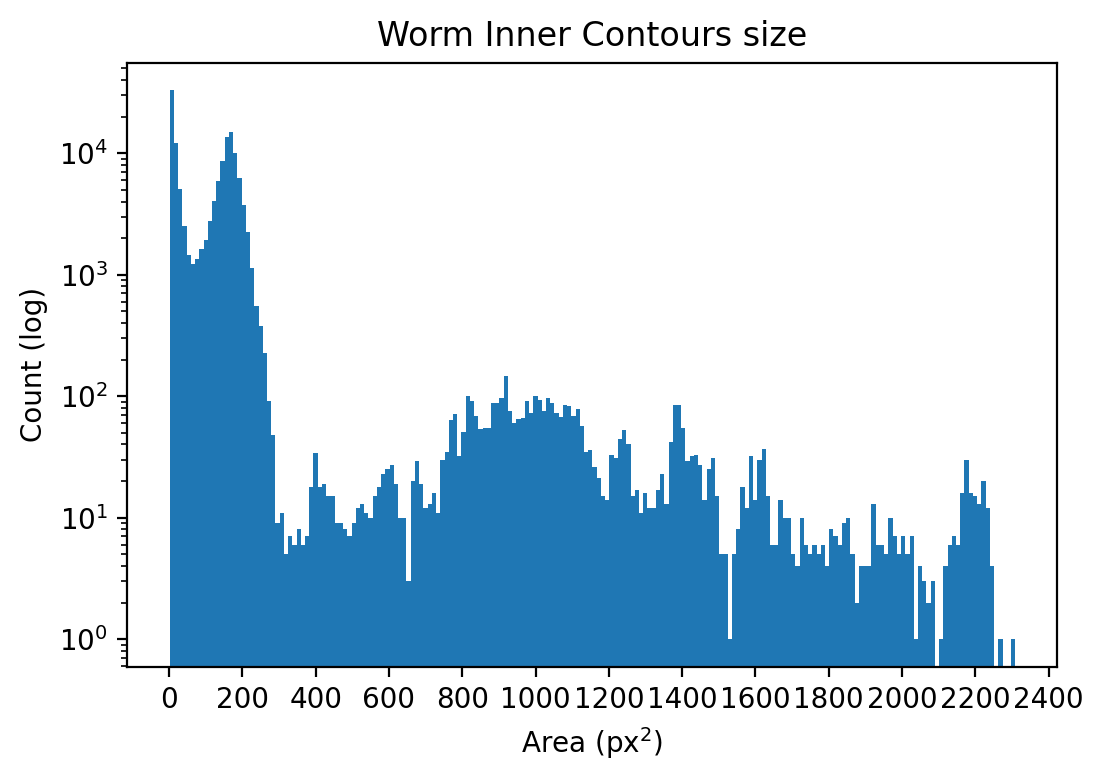

In [56]:
plt.figure(dpi=200)
plt.hist(inside_areas,200, log=True)
plt.ylabel('Count (log)')
plt.xlabel(r'Area (px$^{2}$)')
plt.xticks(np.arange(0,2500, 200))
plt.title('Worm Inner Contours size')

In [60]:
#df.to_csv('/groups/zimmer/Ulises/code/dataframe.csv', index=True)

img001.tif


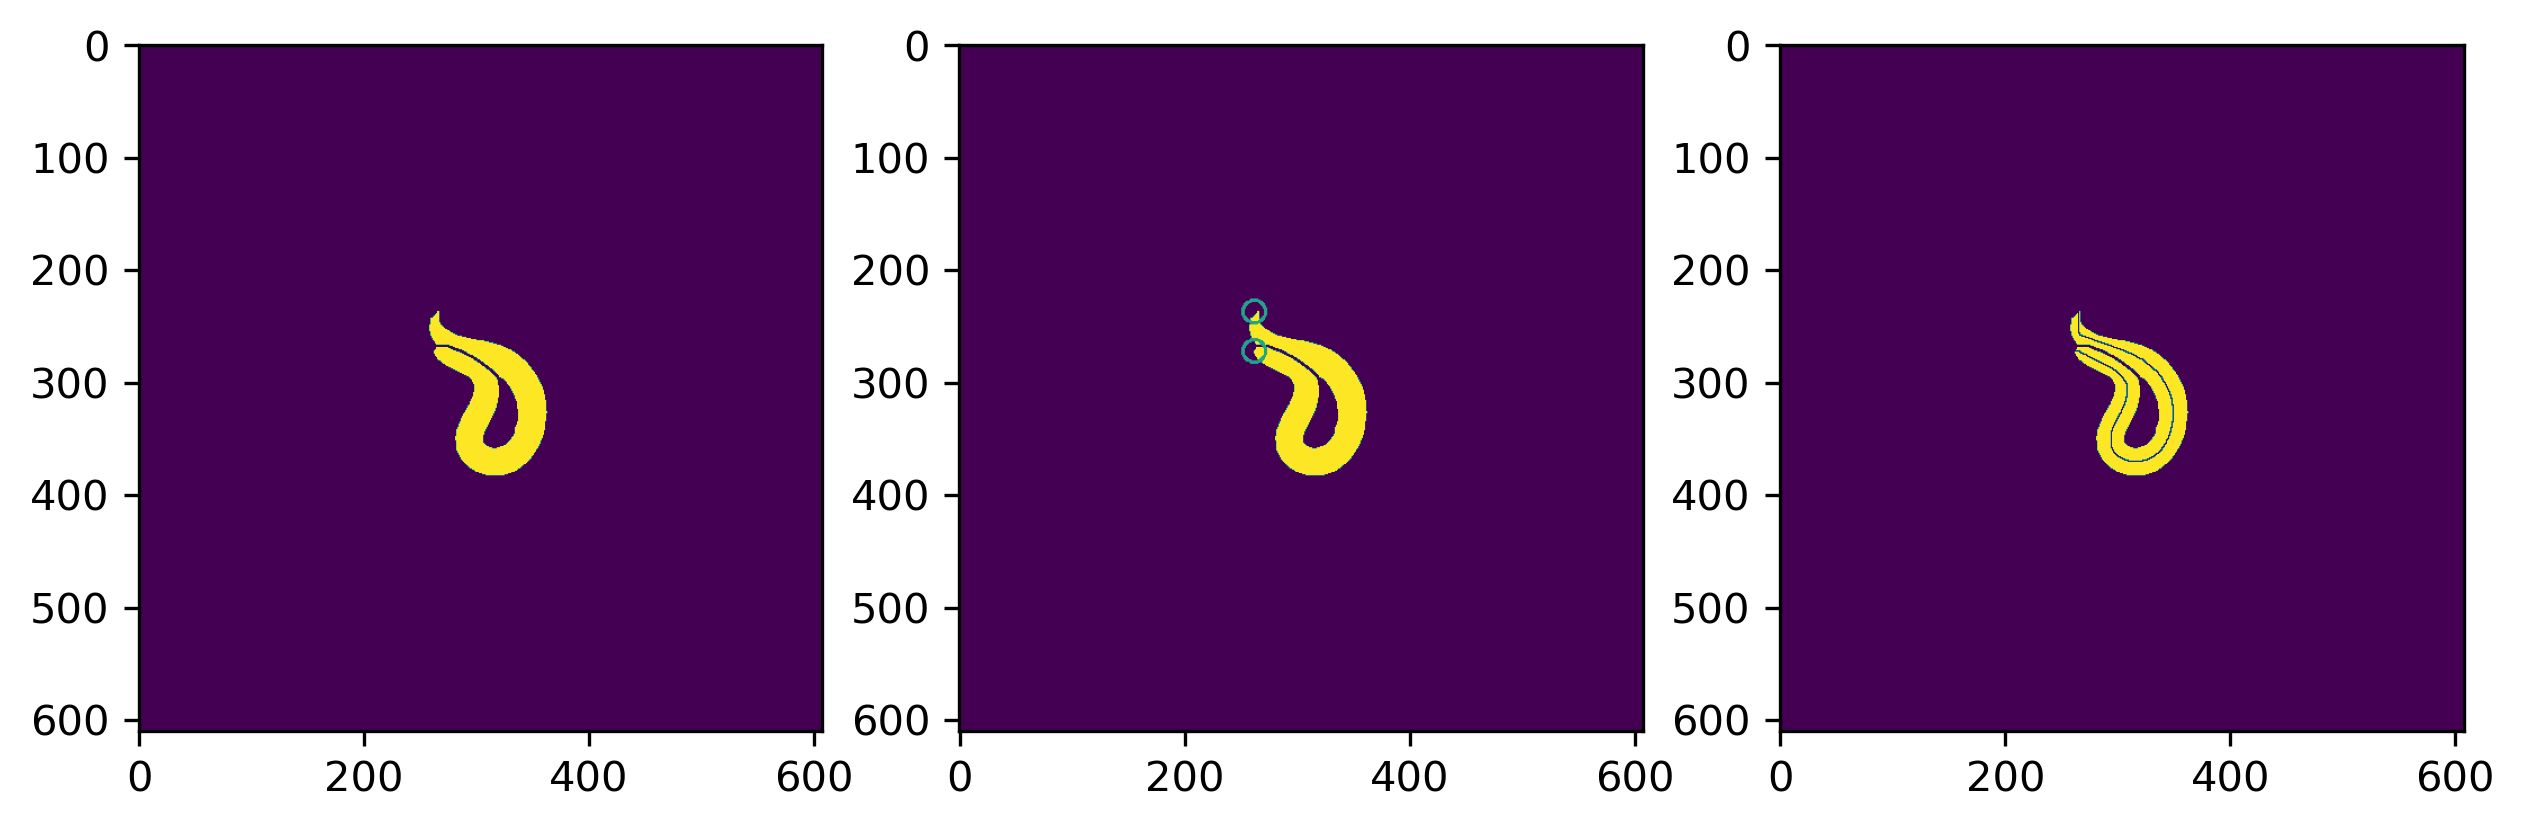

img067.tif
head and tail were too close, no centerline could be created
img106.tif


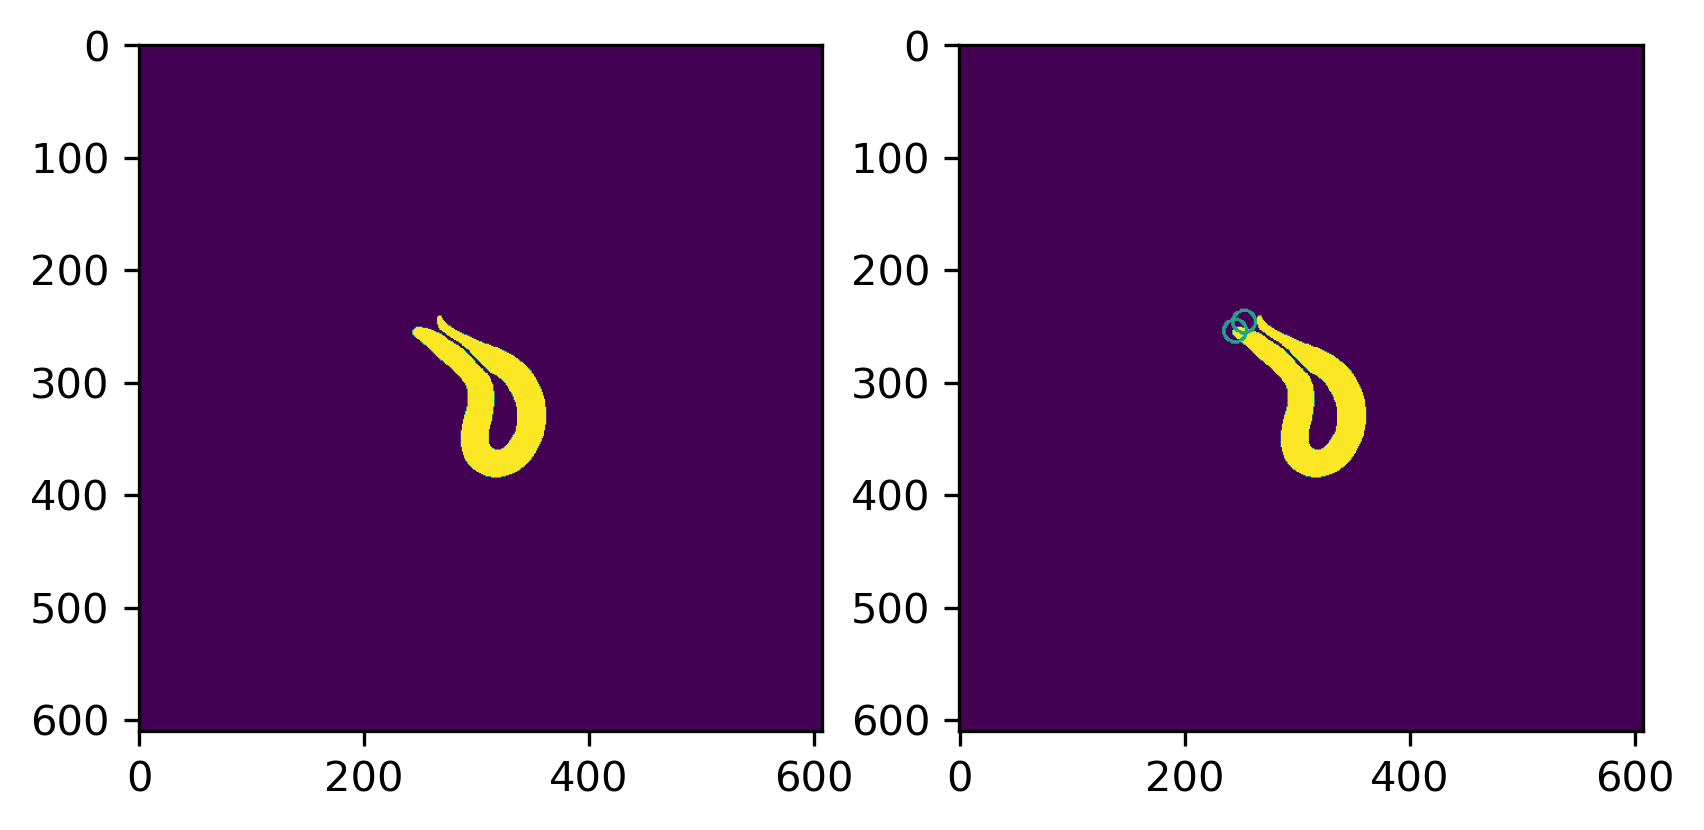

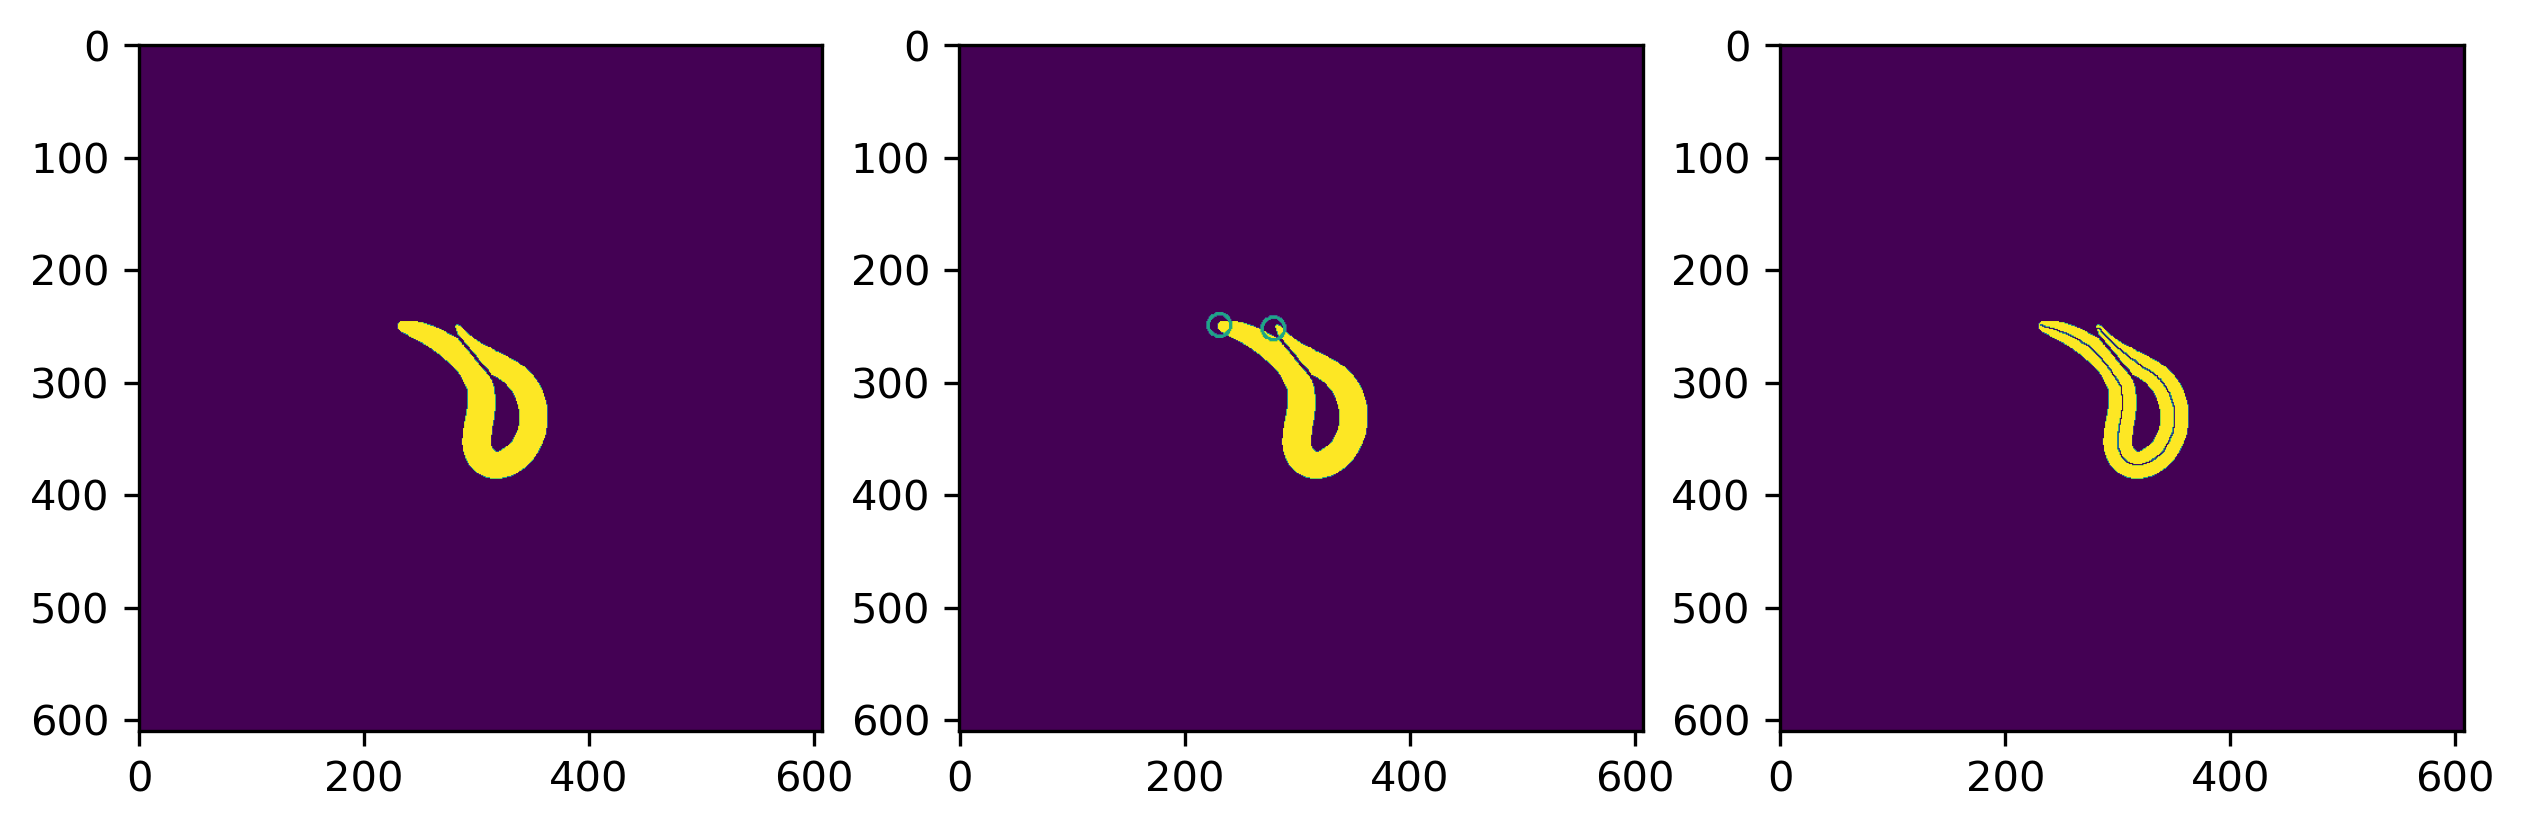

img140.tif
head and tail were too close, no centerline could be created
img174.tif


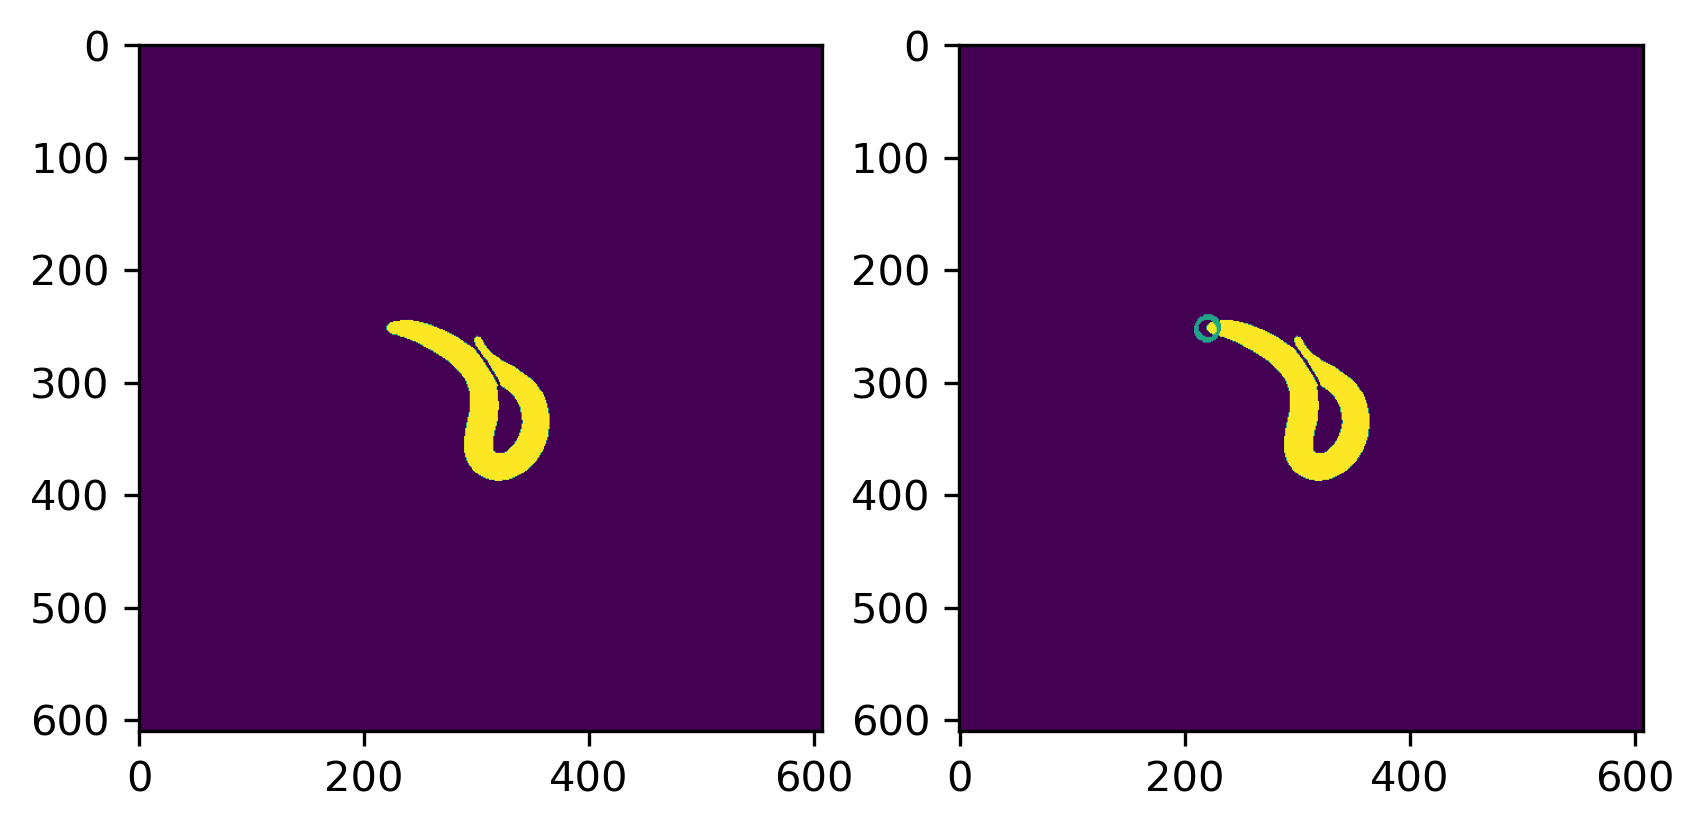

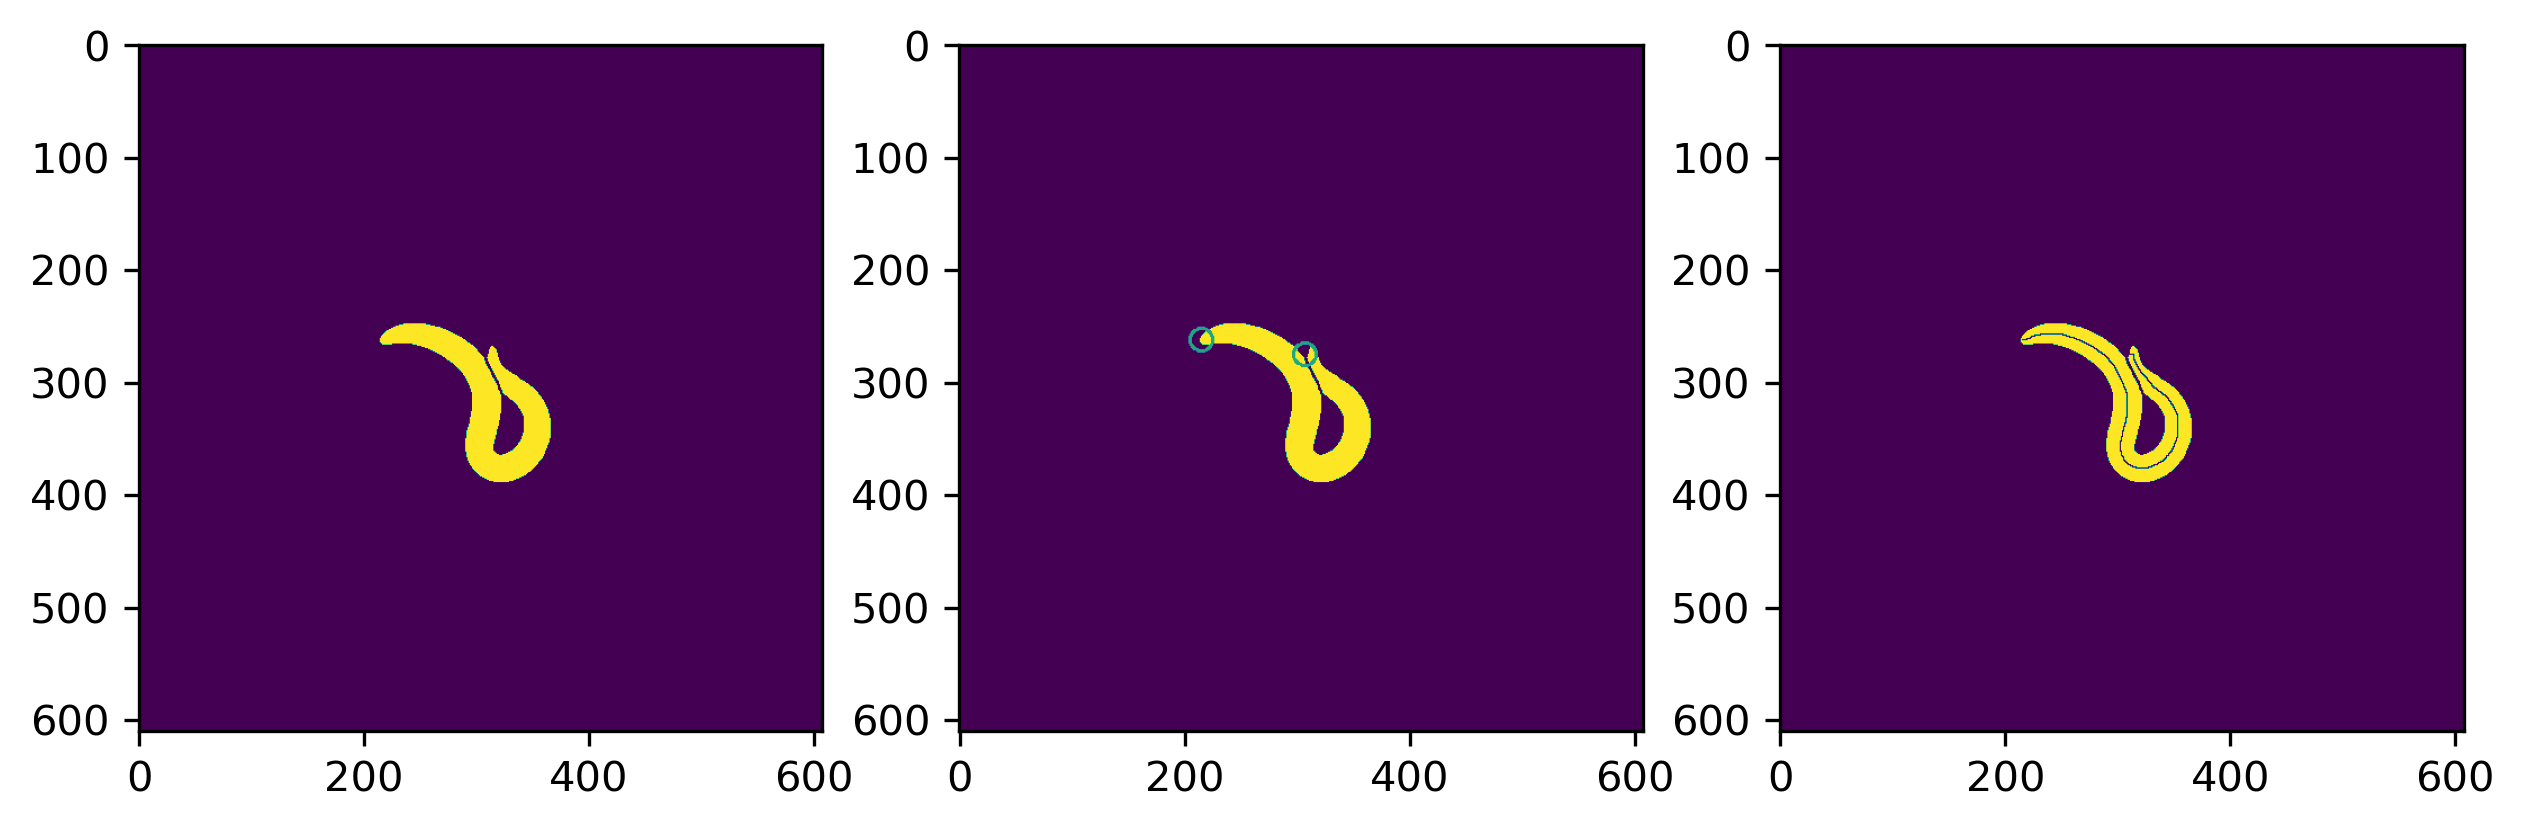

img207.tif


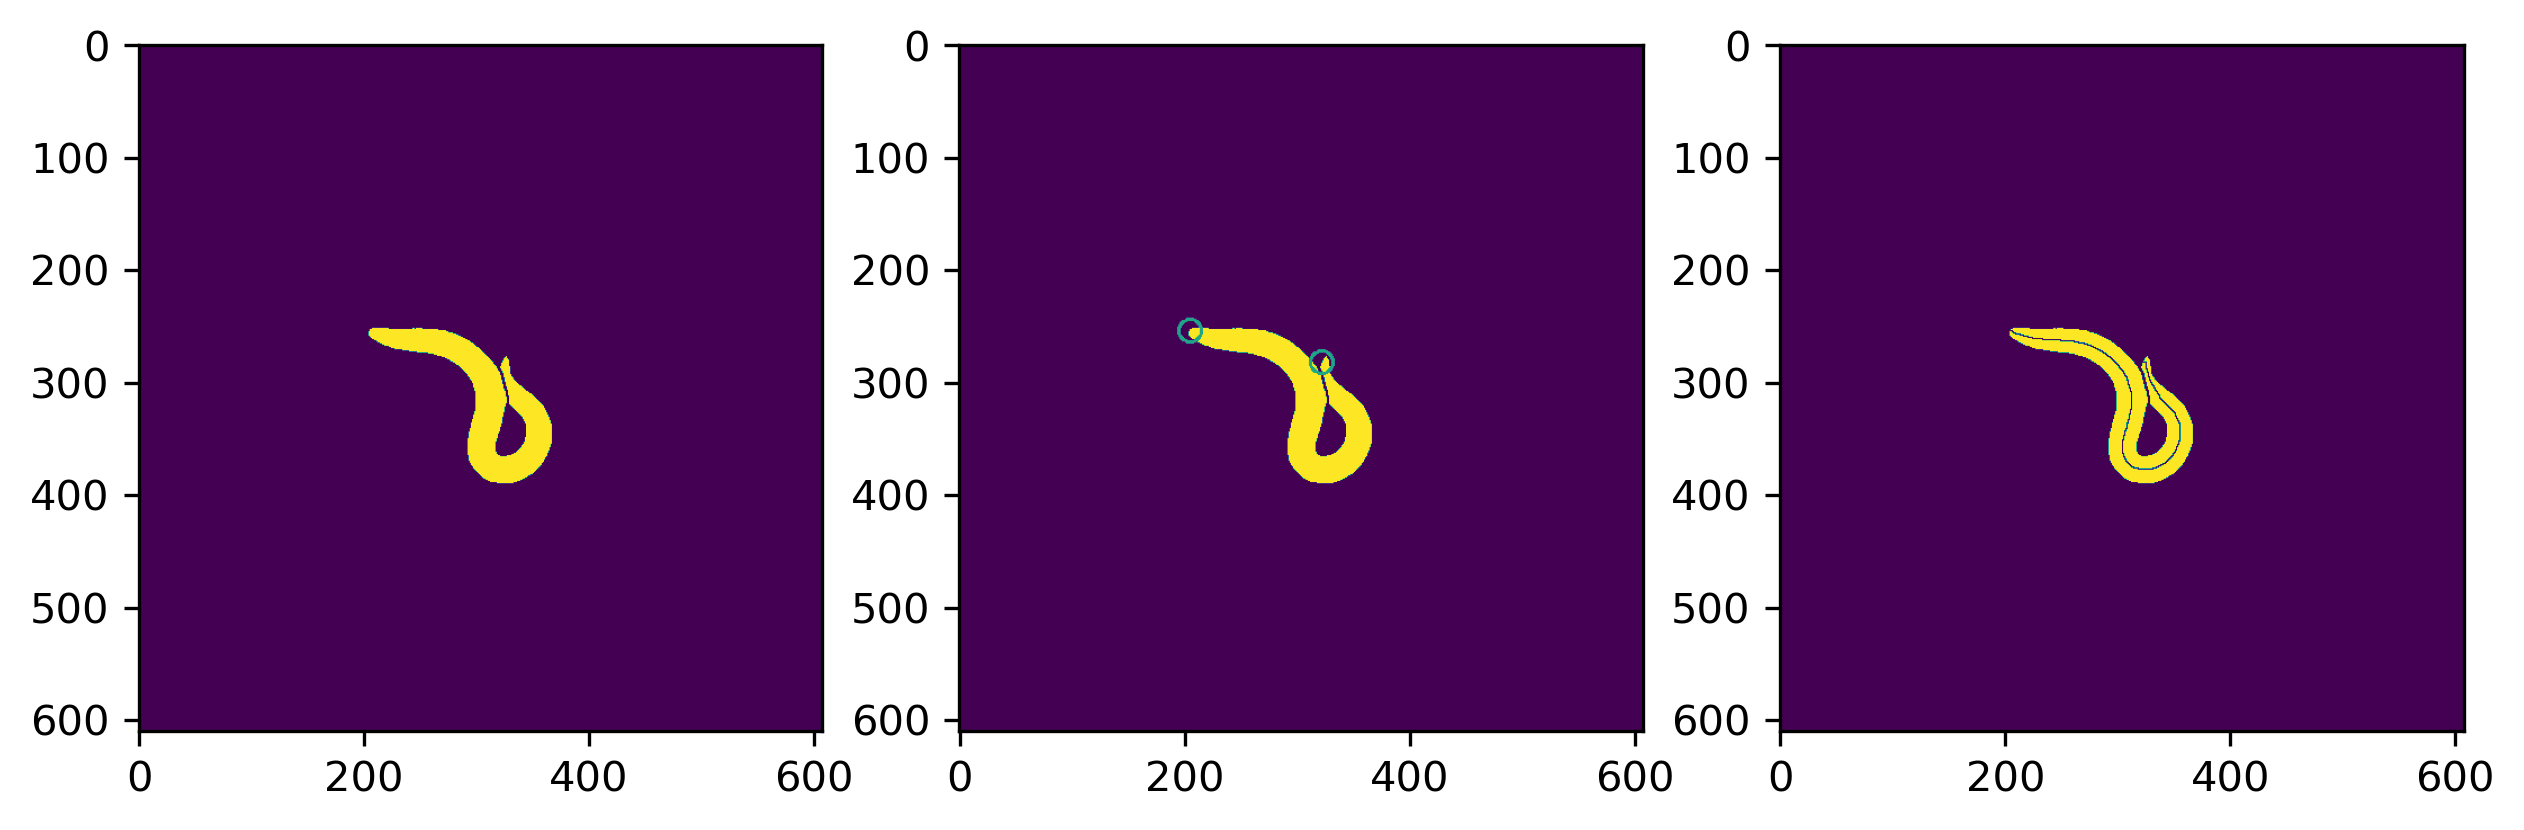

img245.tif


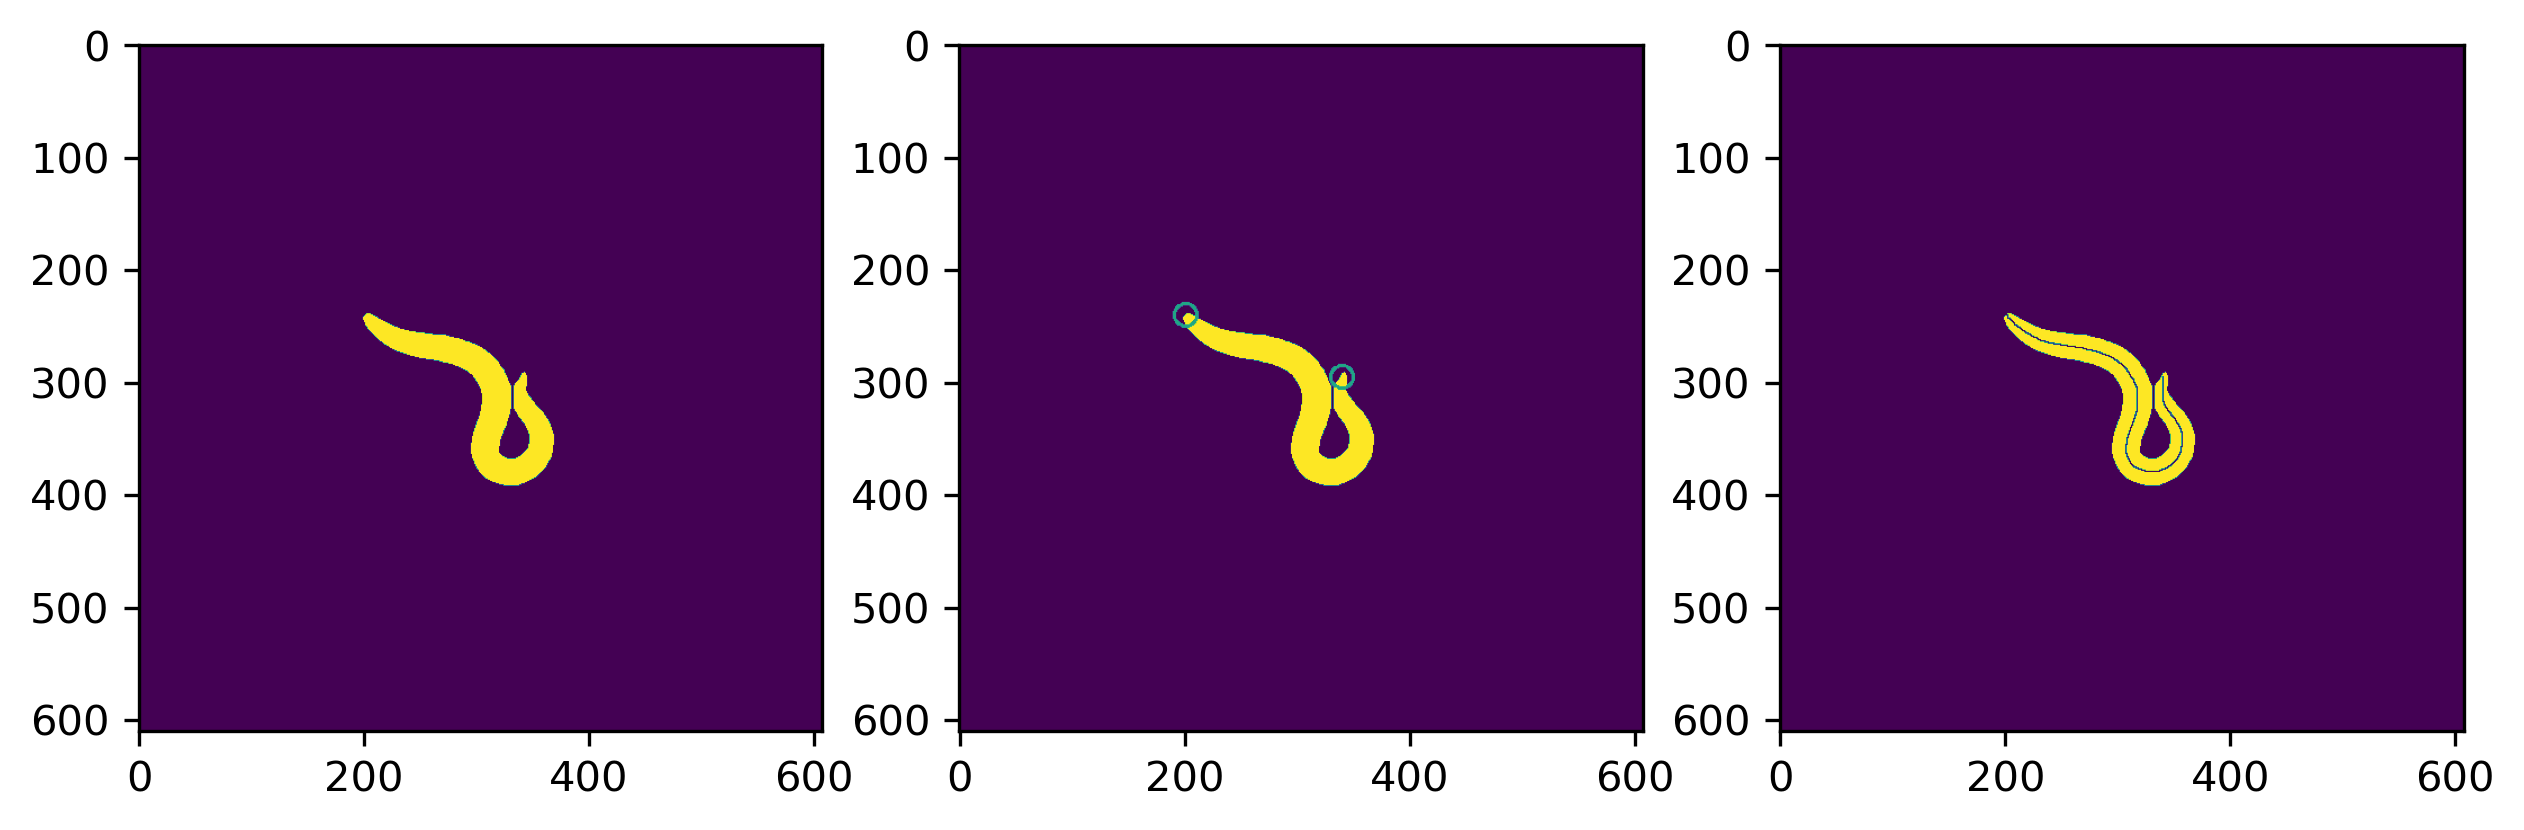

img256.tif


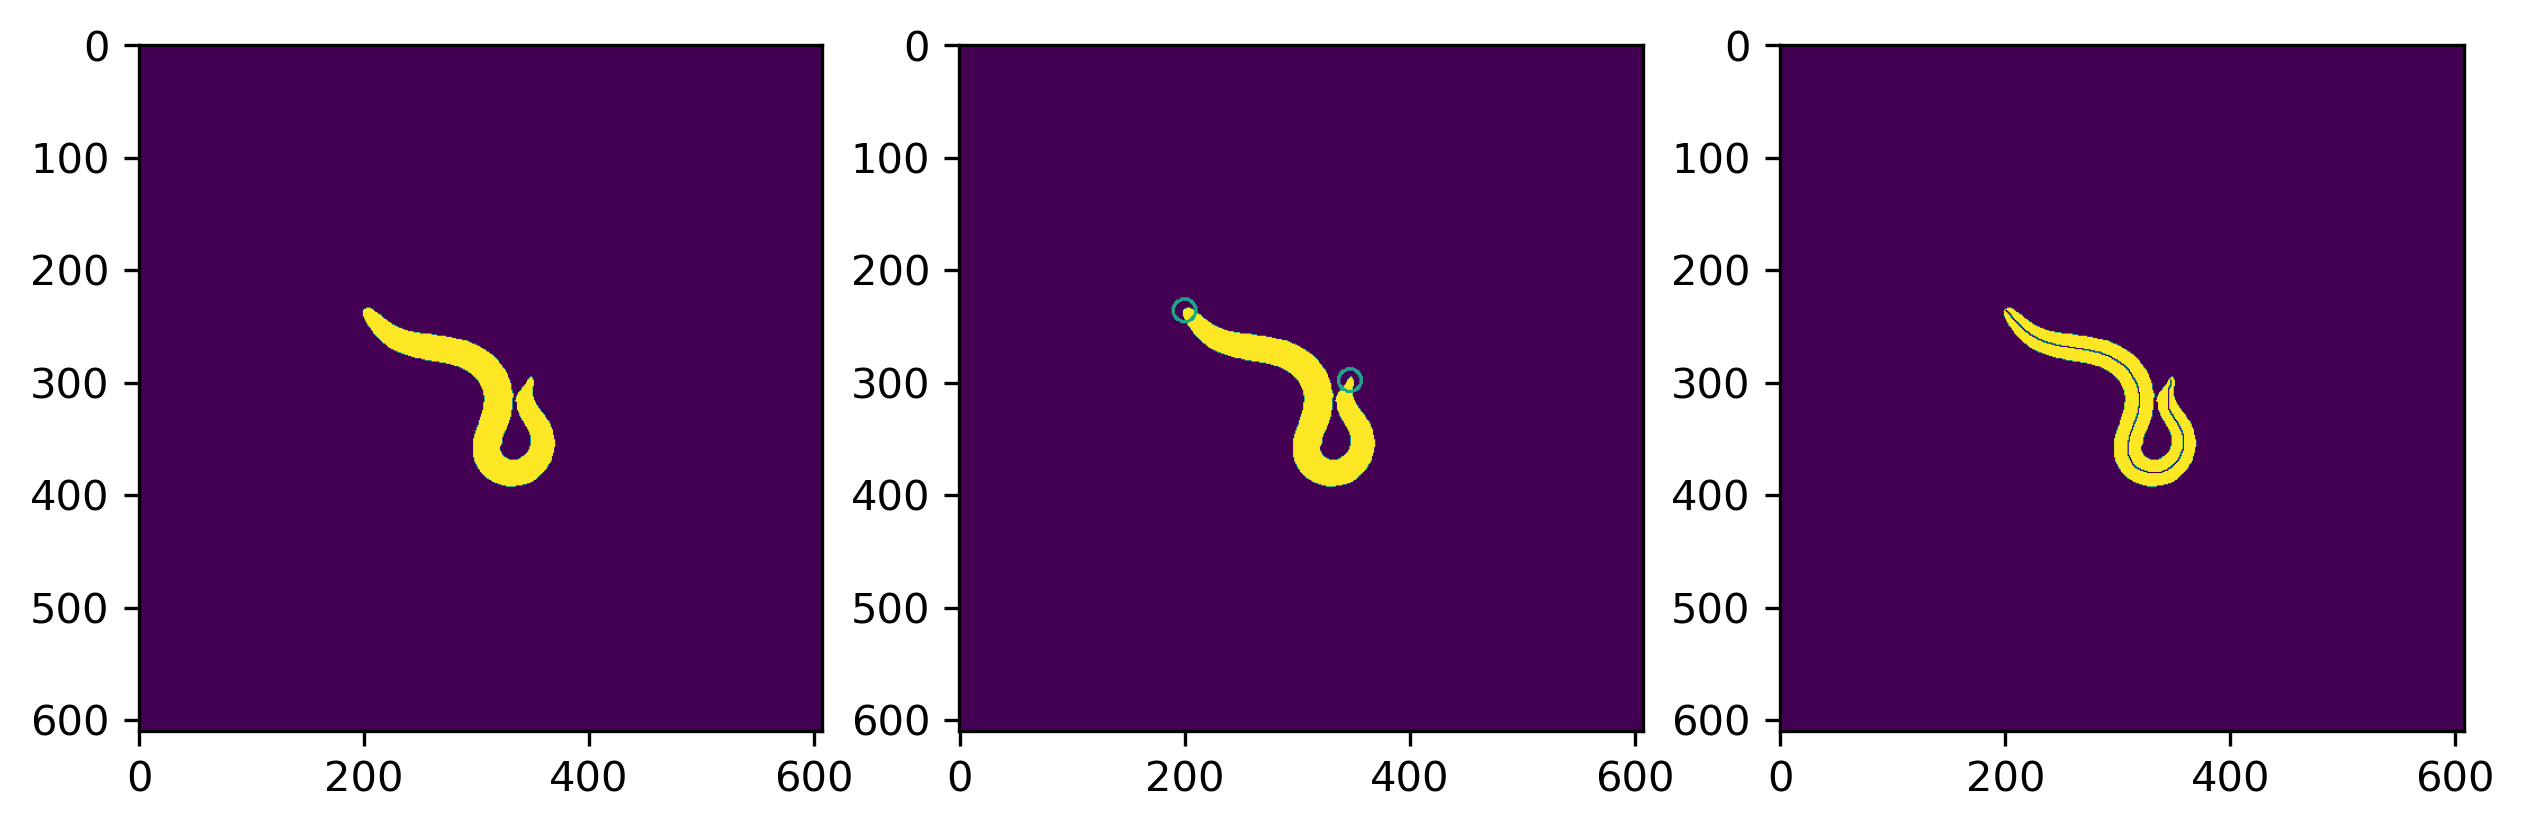

img2739.tif


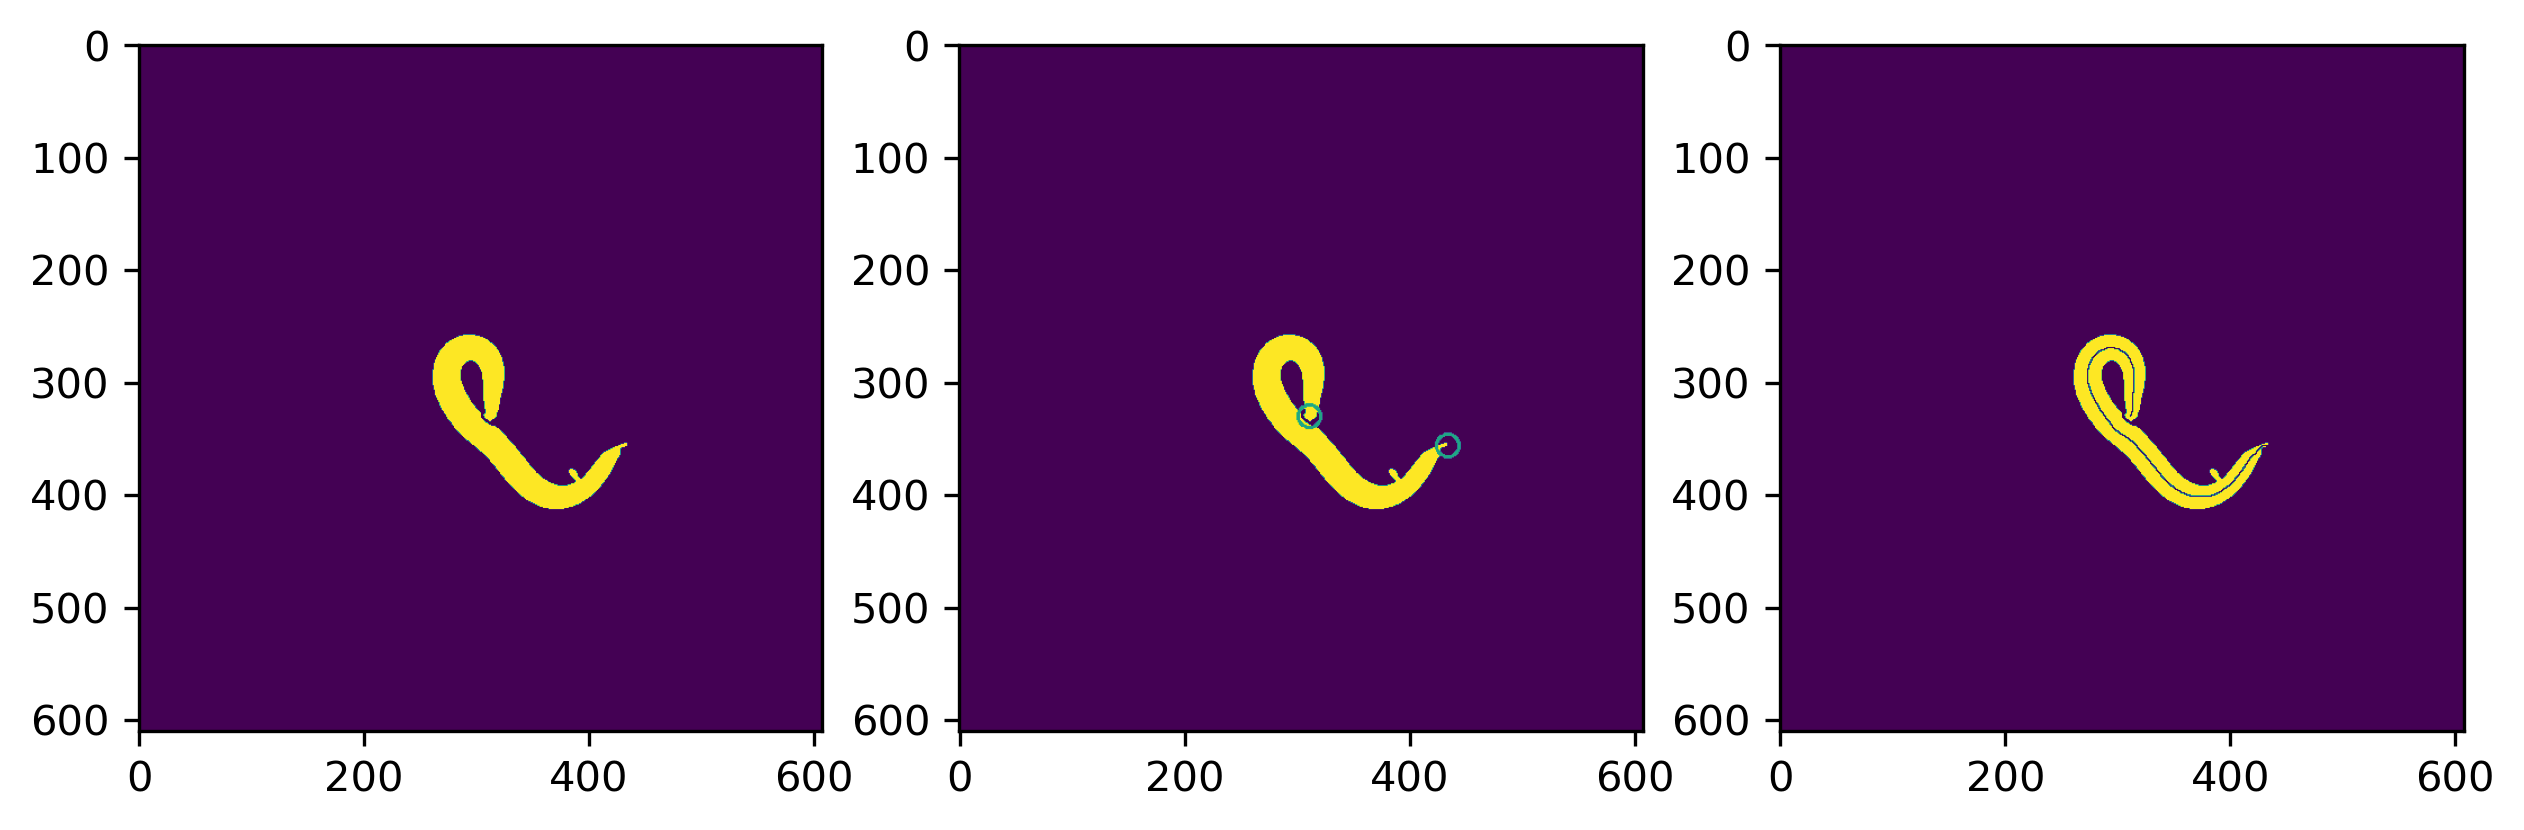

img2754.tif


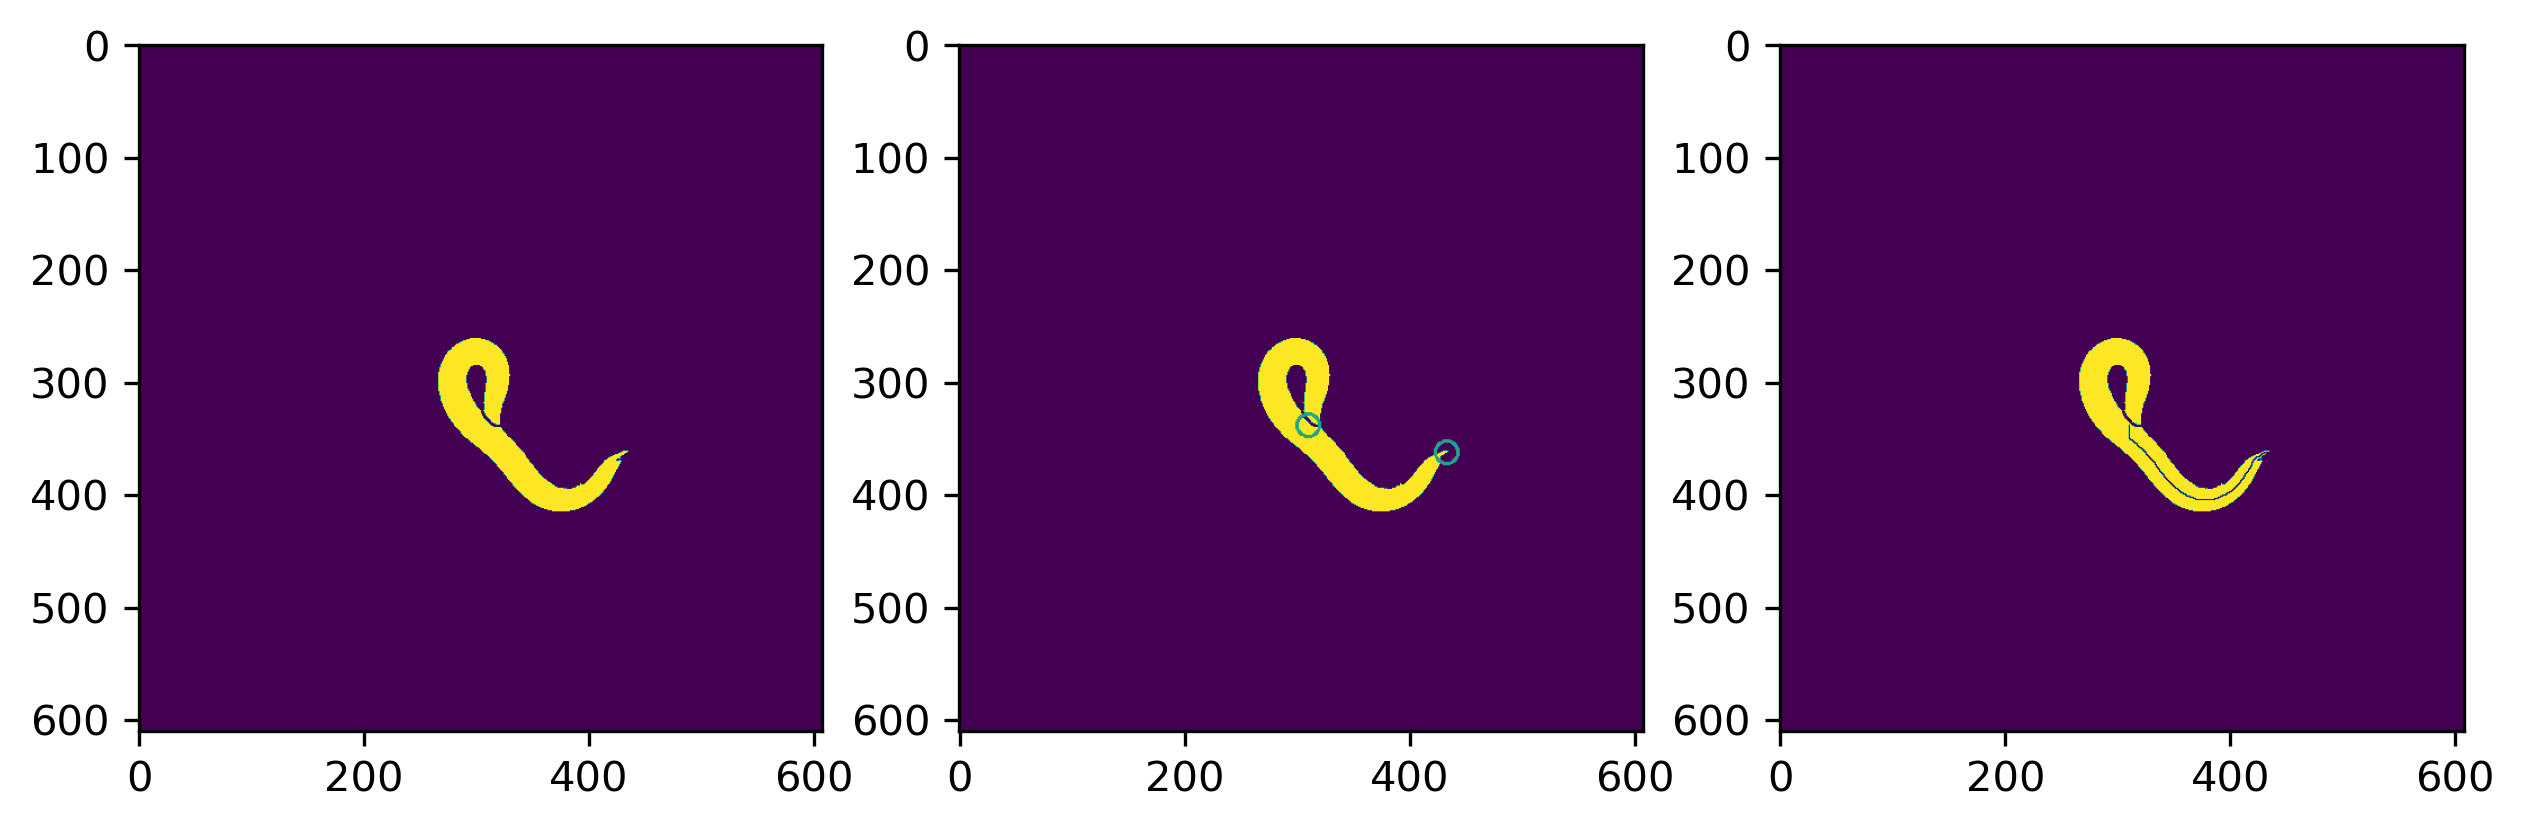

img2775.tif


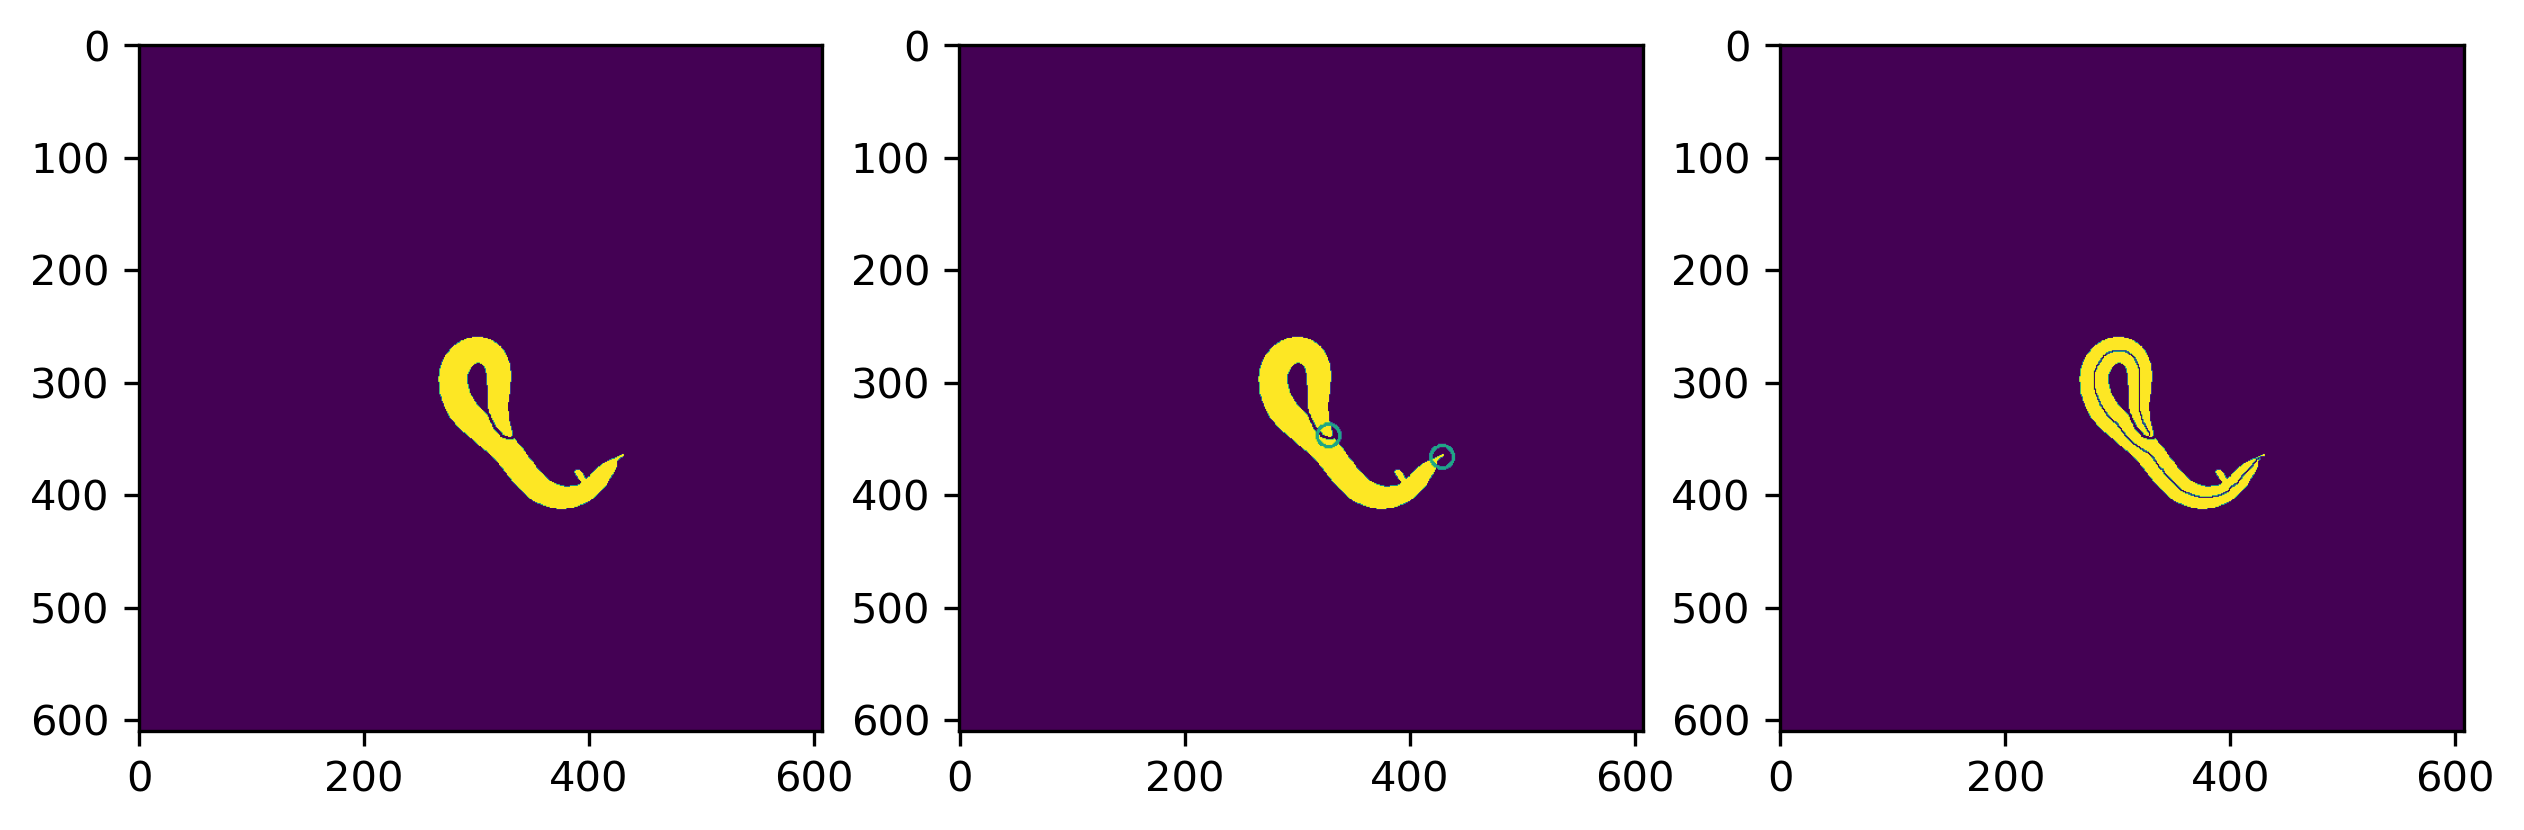

img2798.tif
head and tail were too close, no centerline could be created
img2809.tif


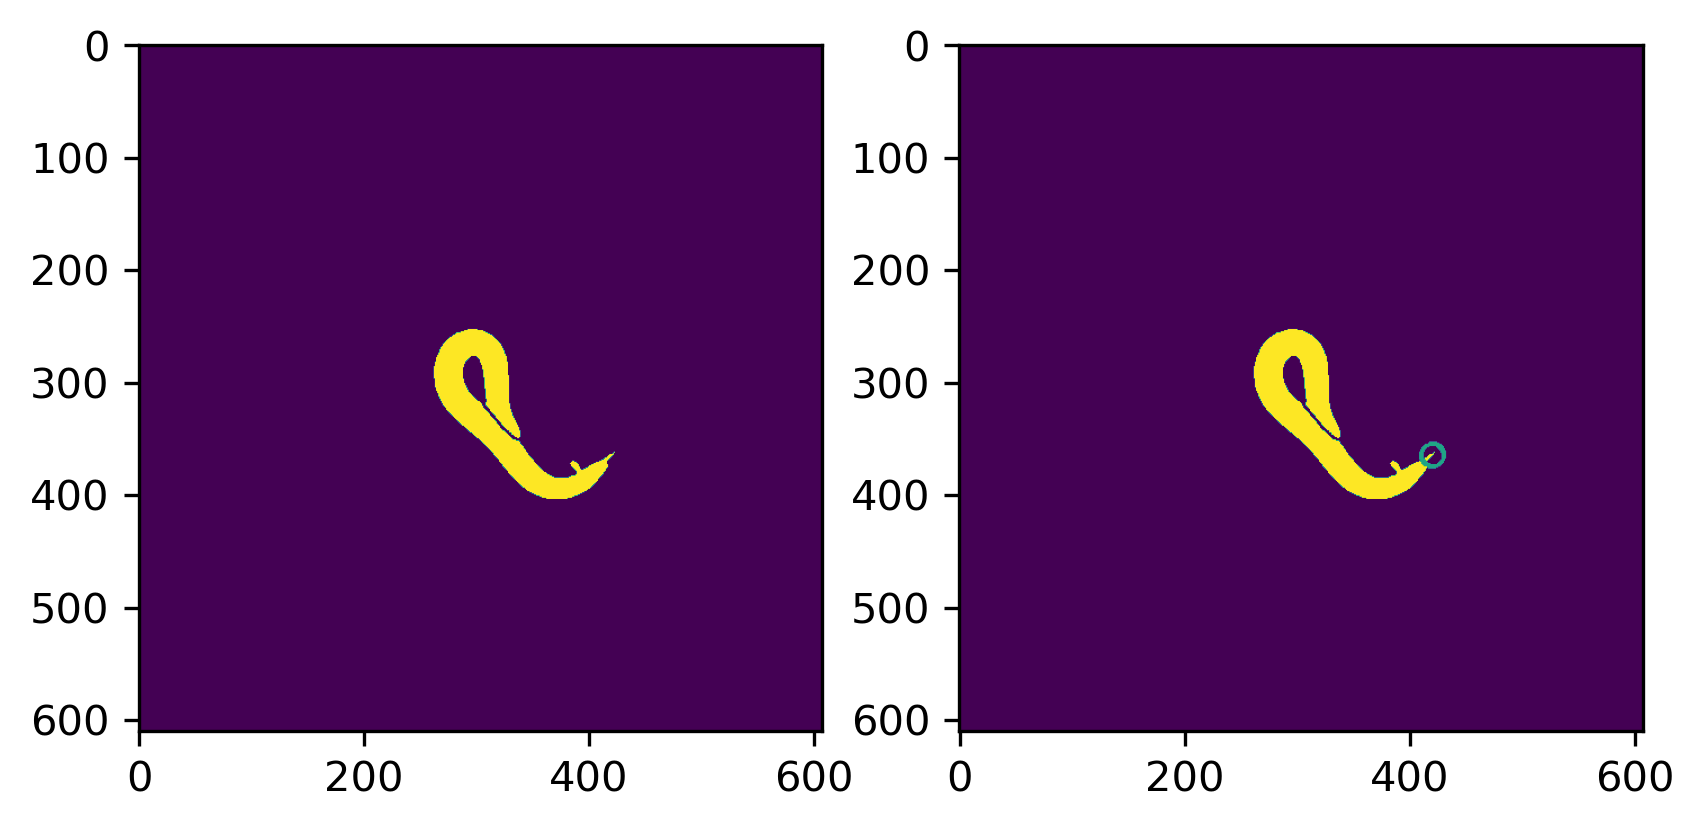

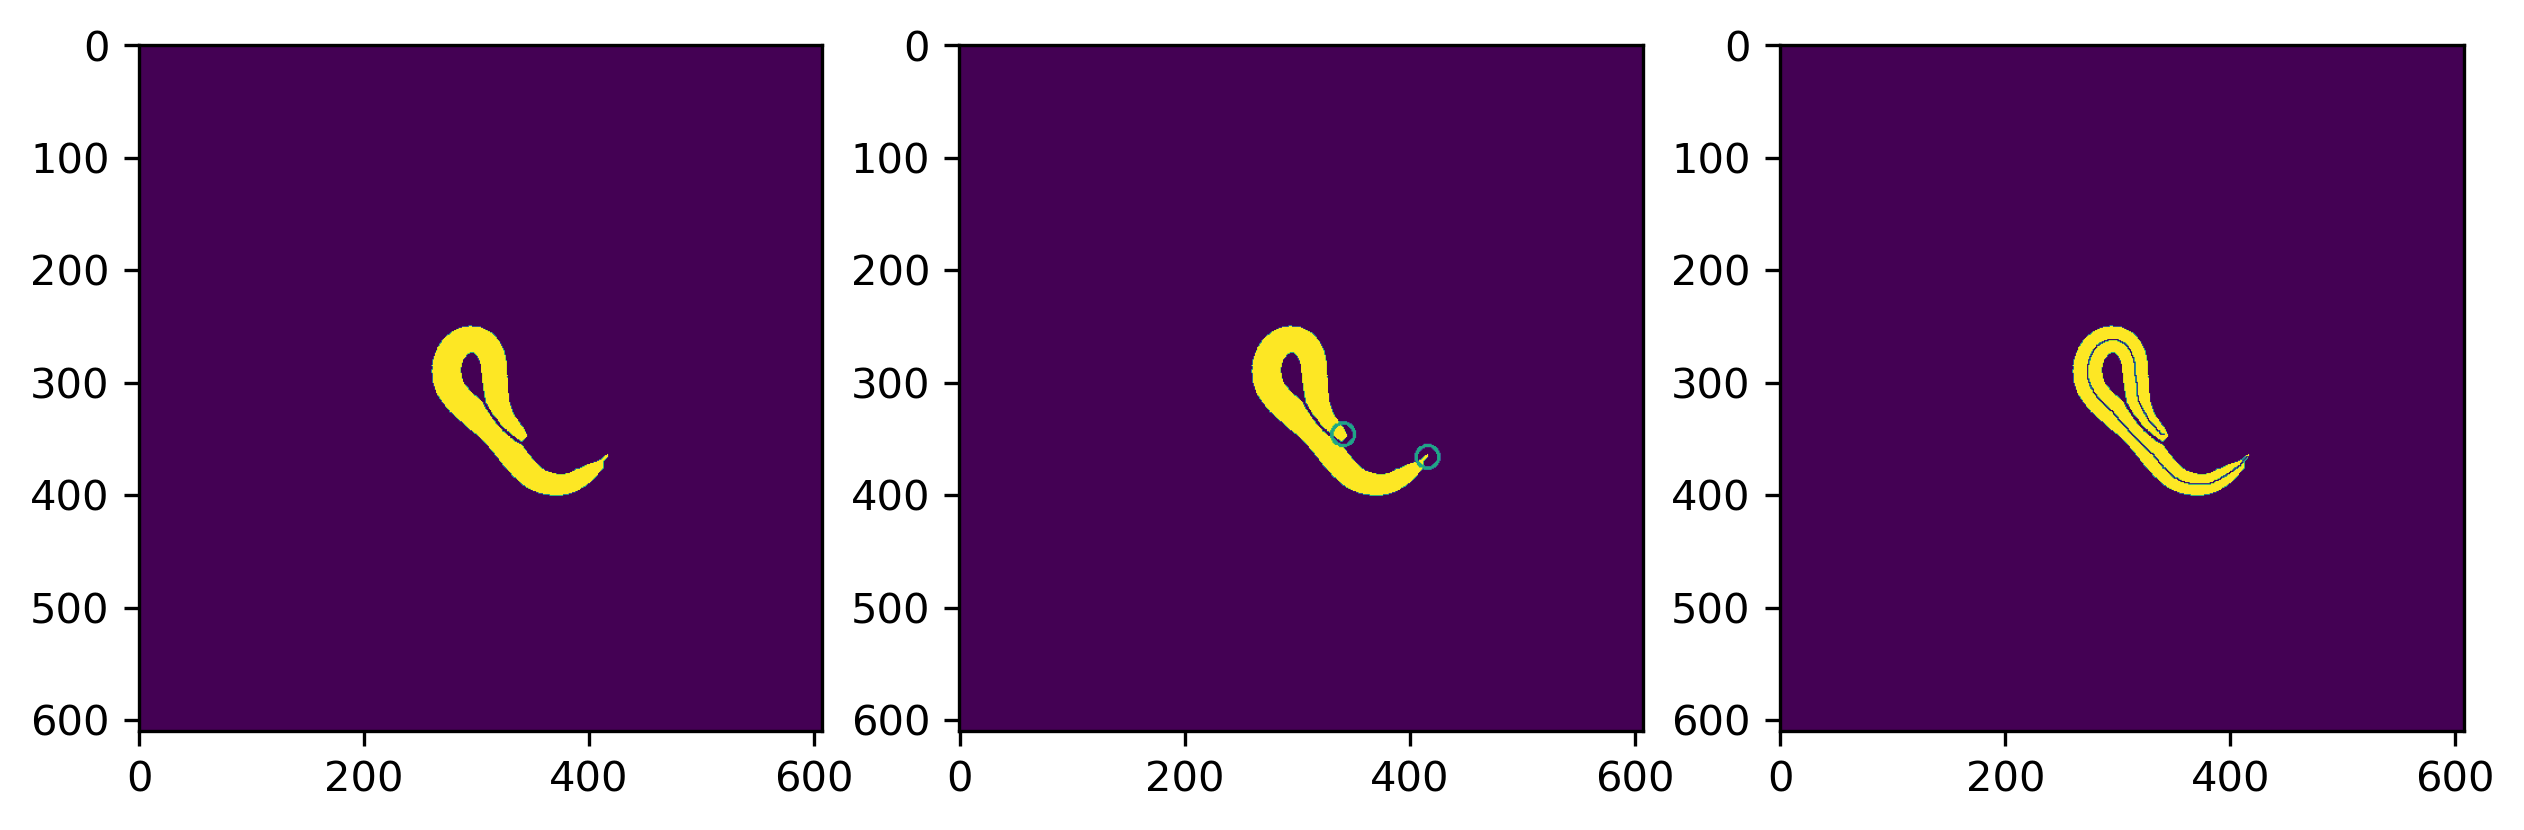

img2820.tif


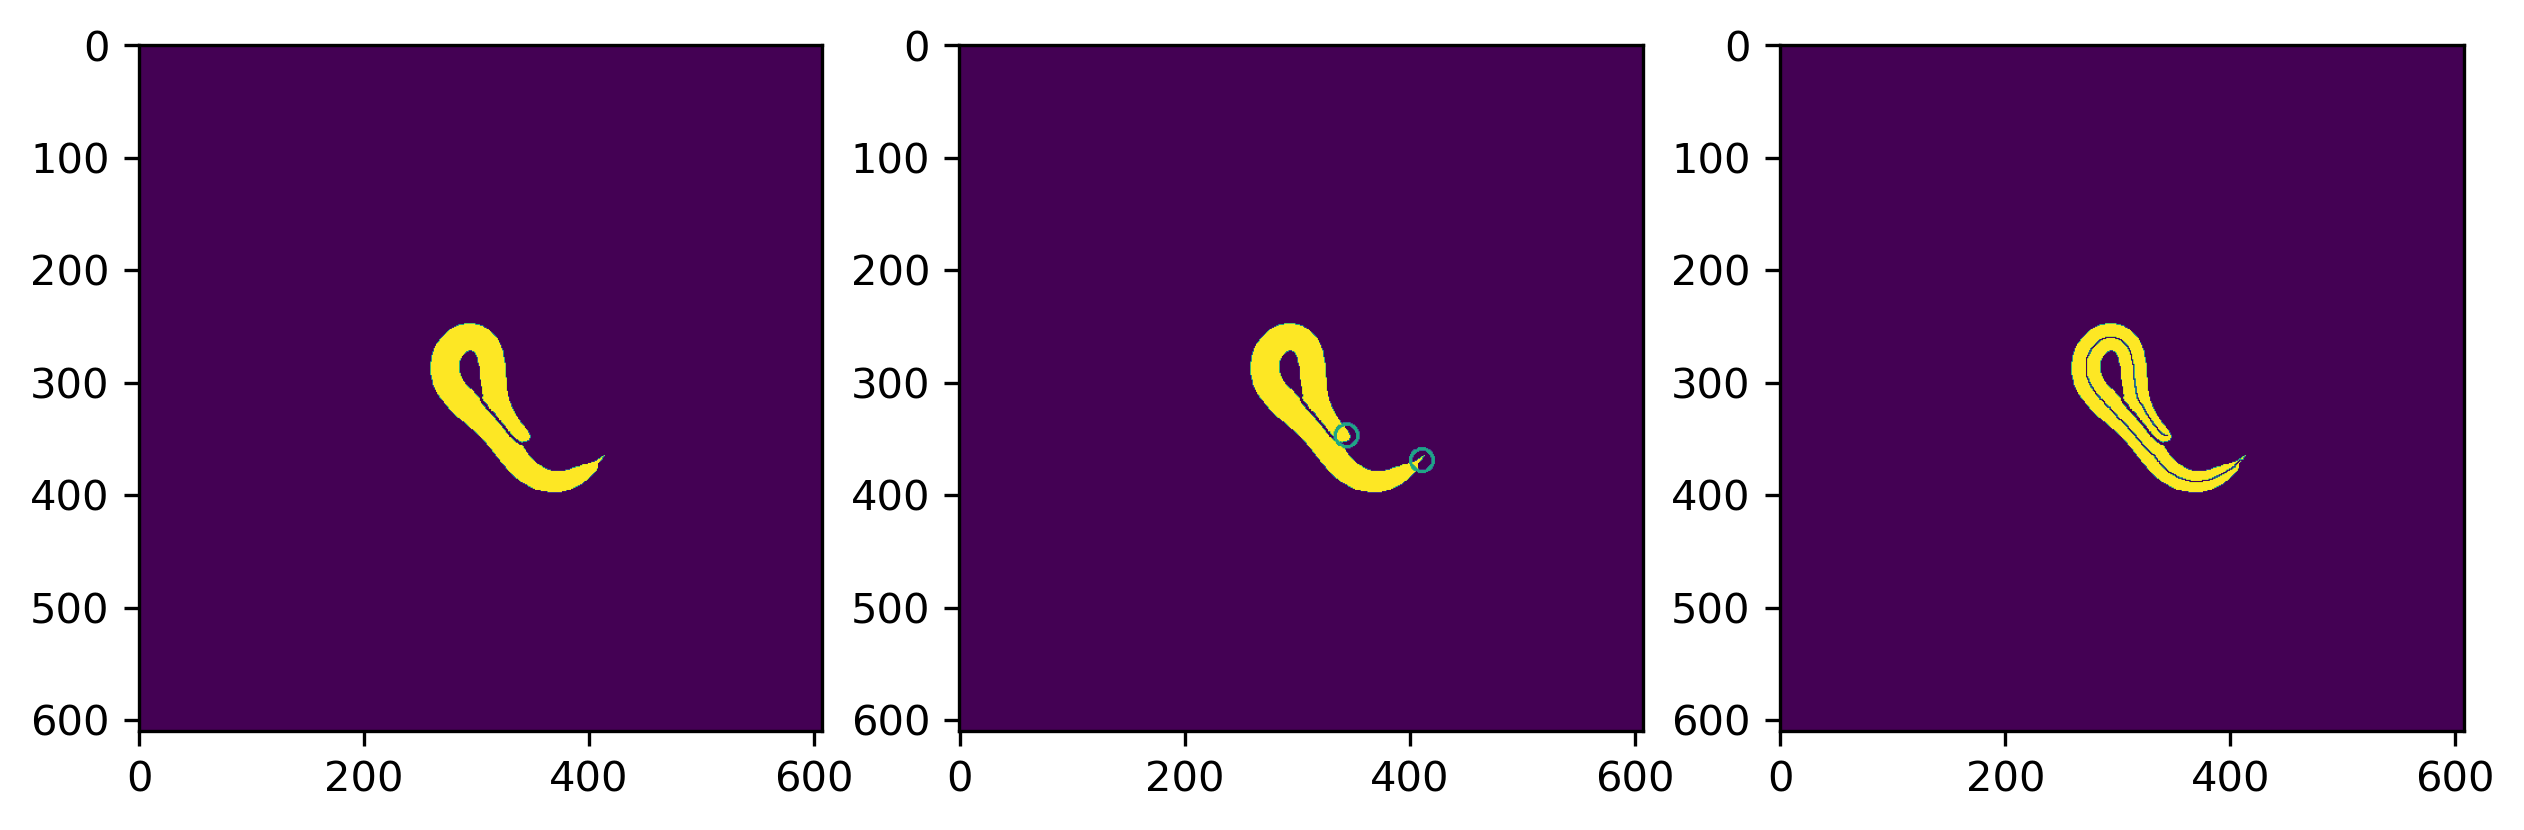

img2840.tif


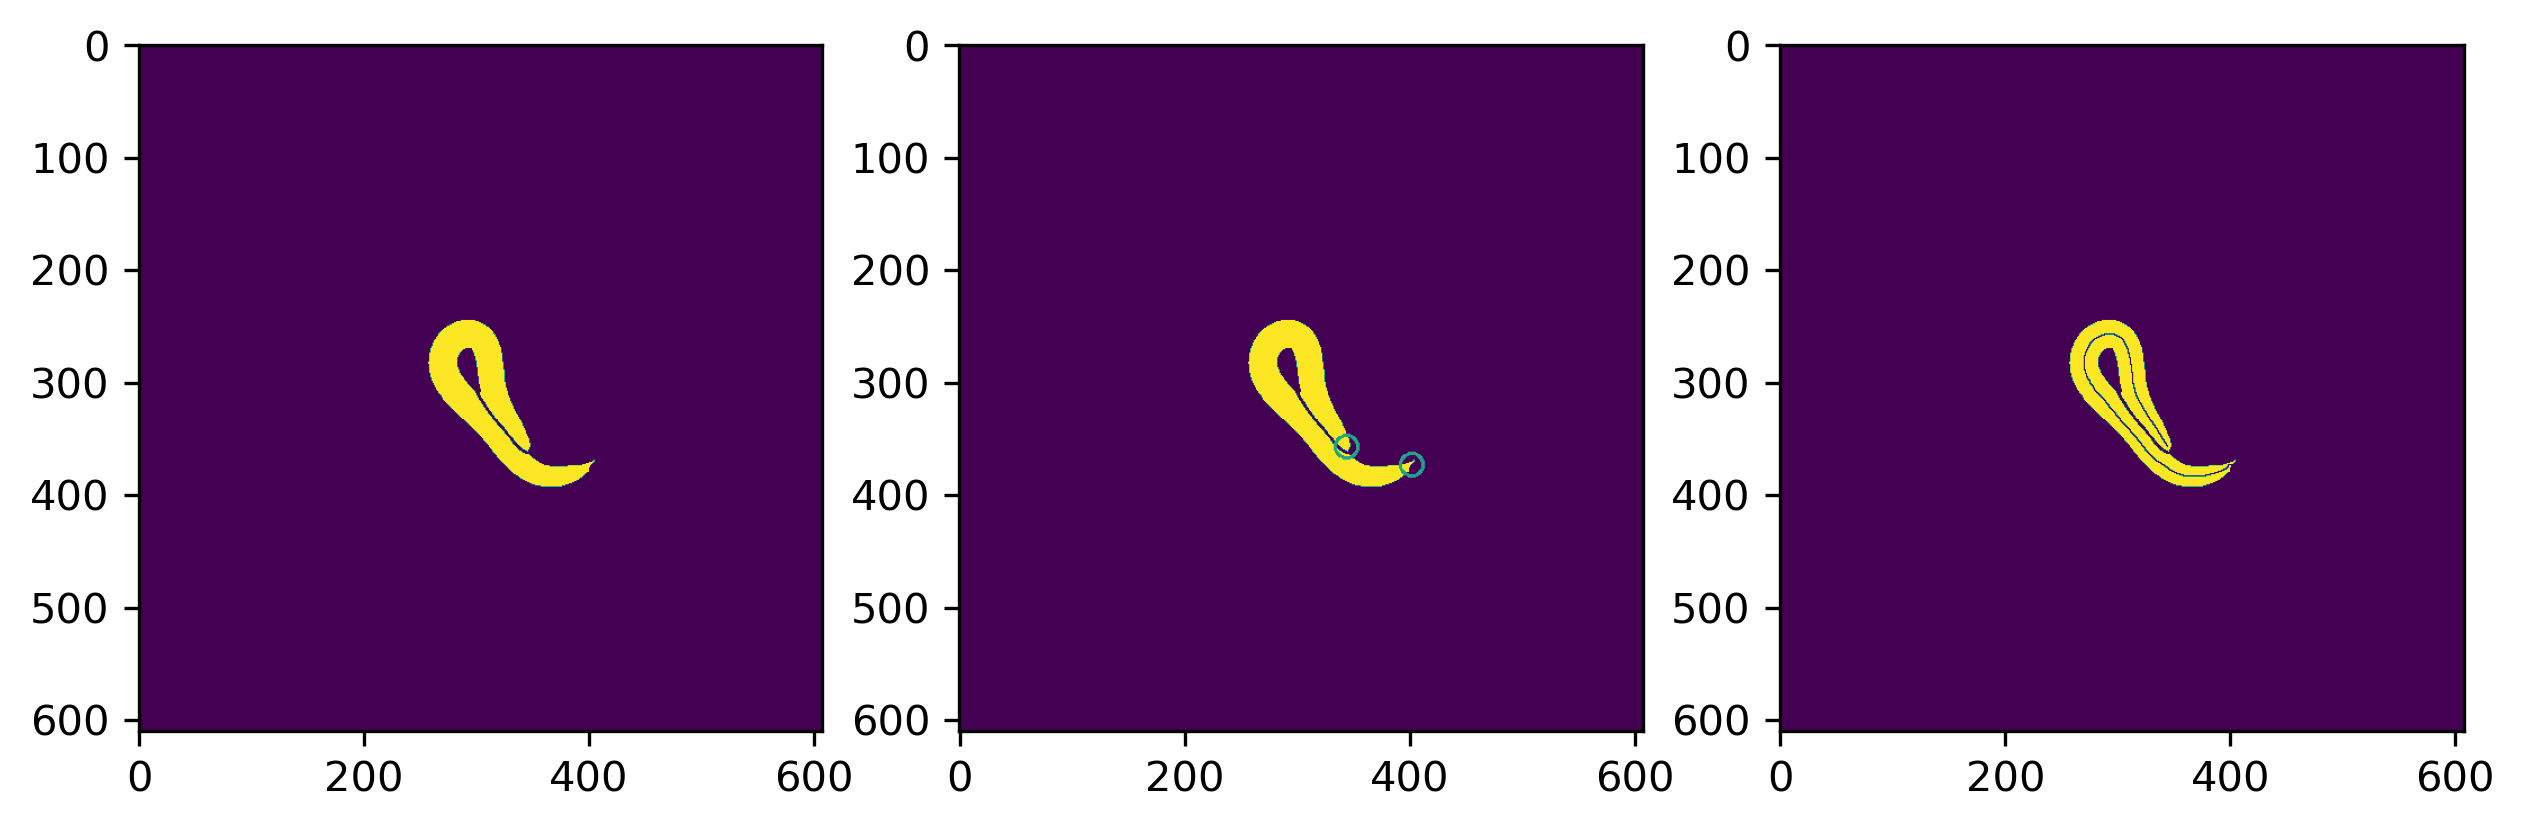

img2842.tif


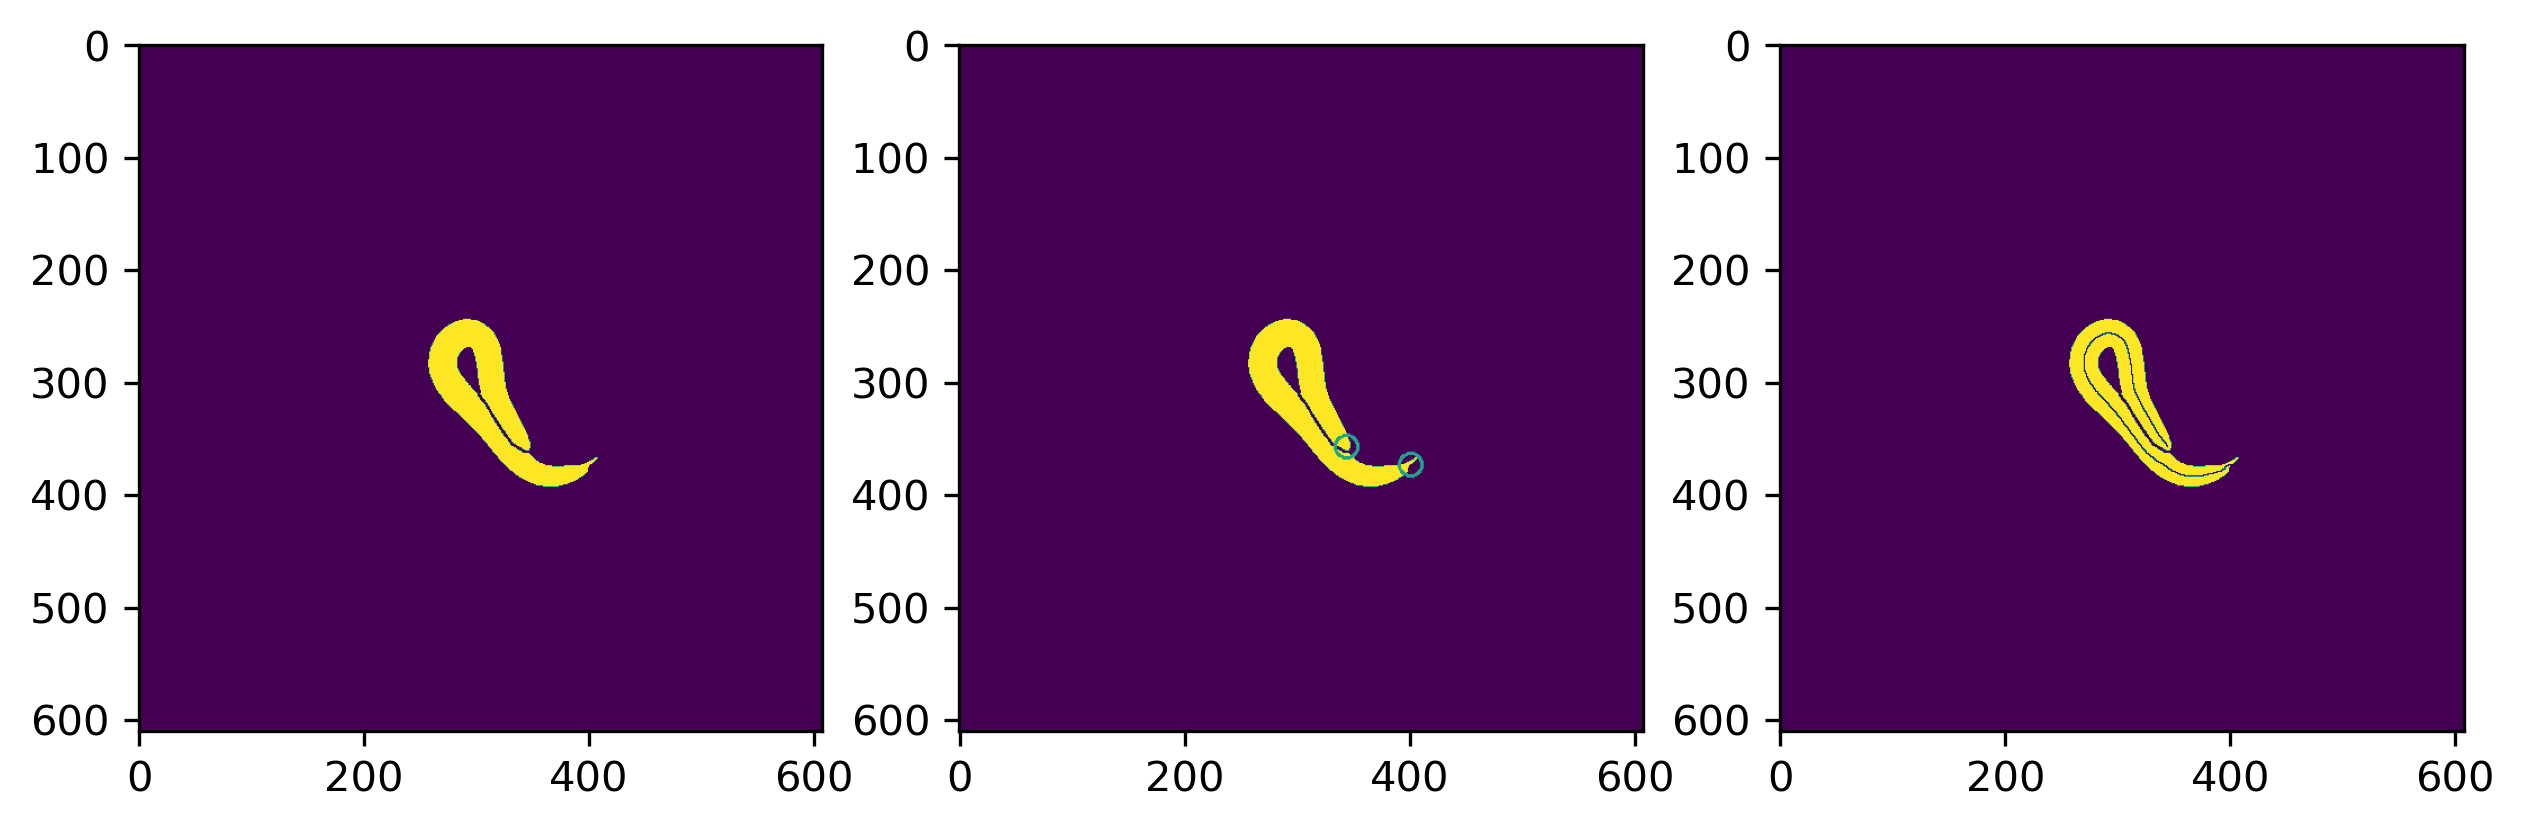

img2865.tif
head and tail were too close, no centerline could be created
img2889.tif
head and tail were too close, no centerline could be created
img2906.tif


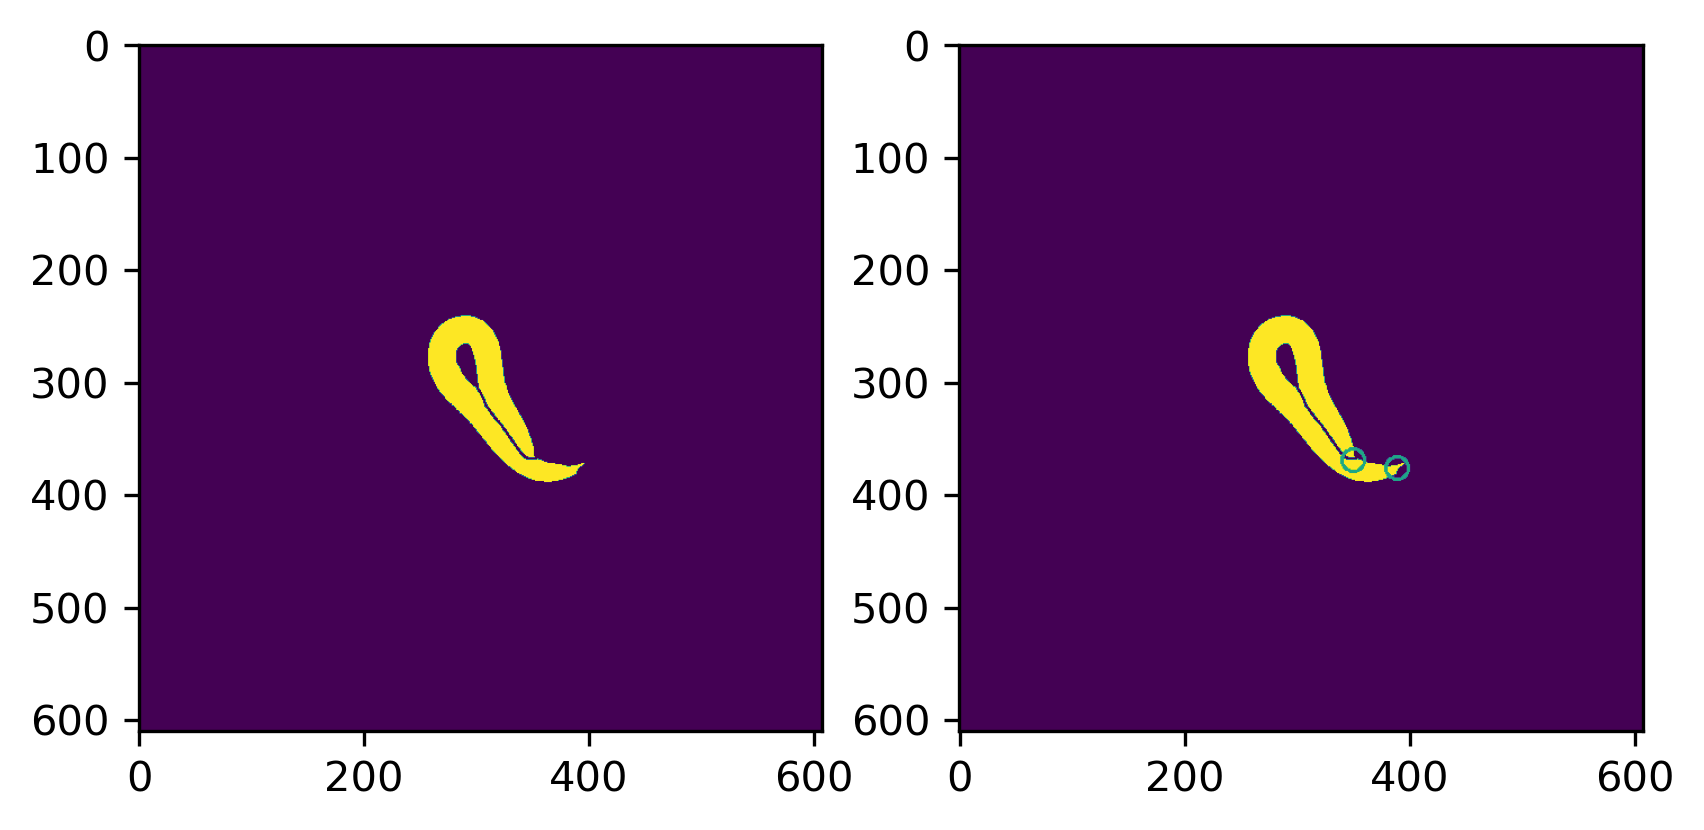

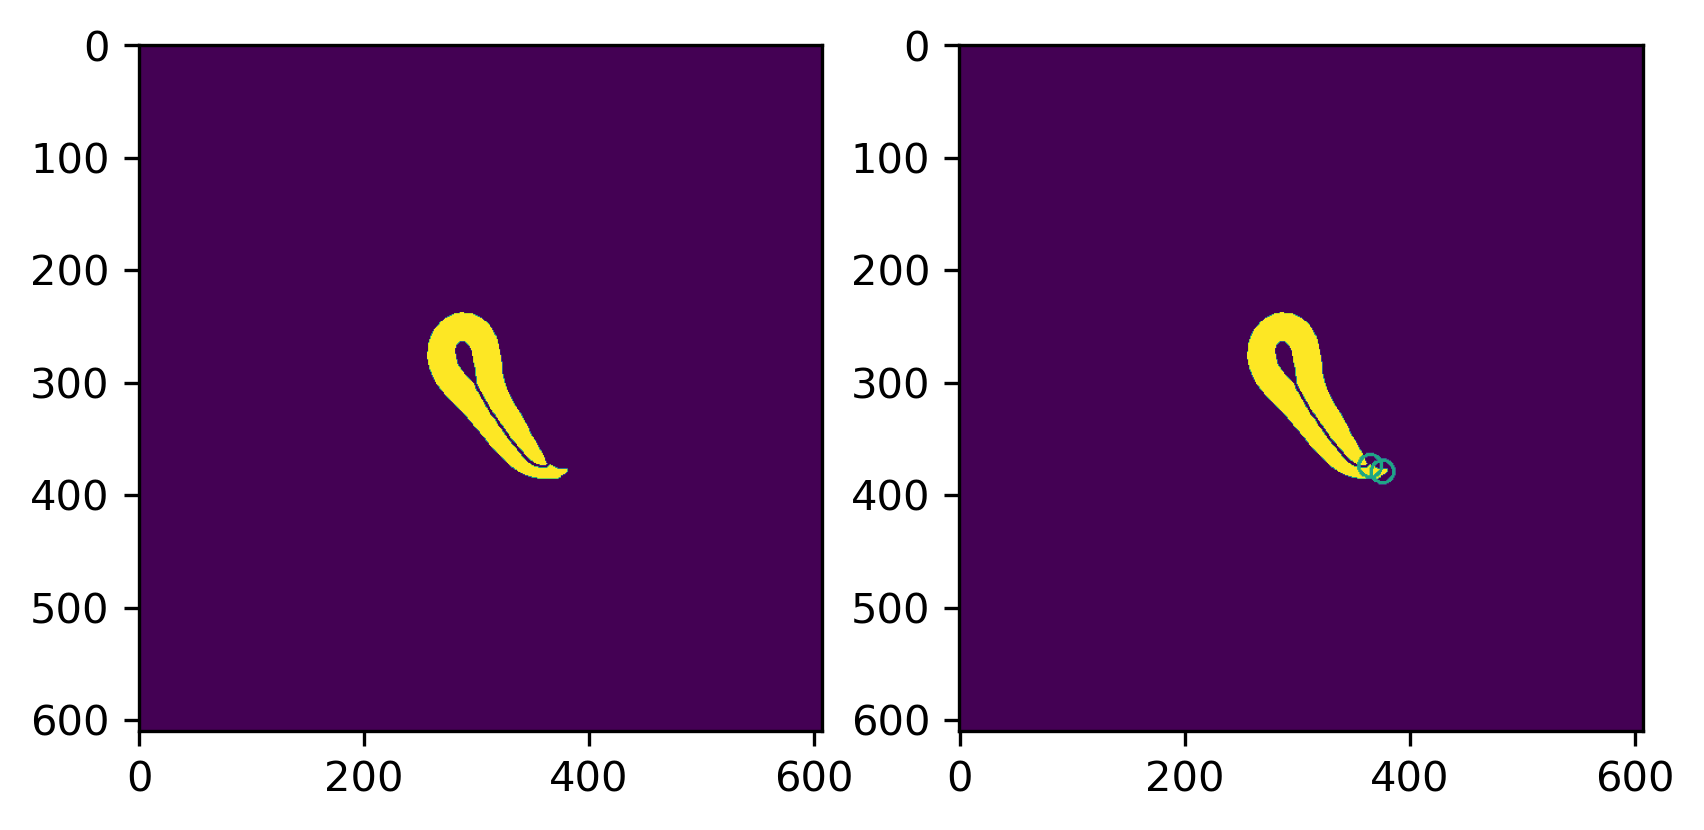

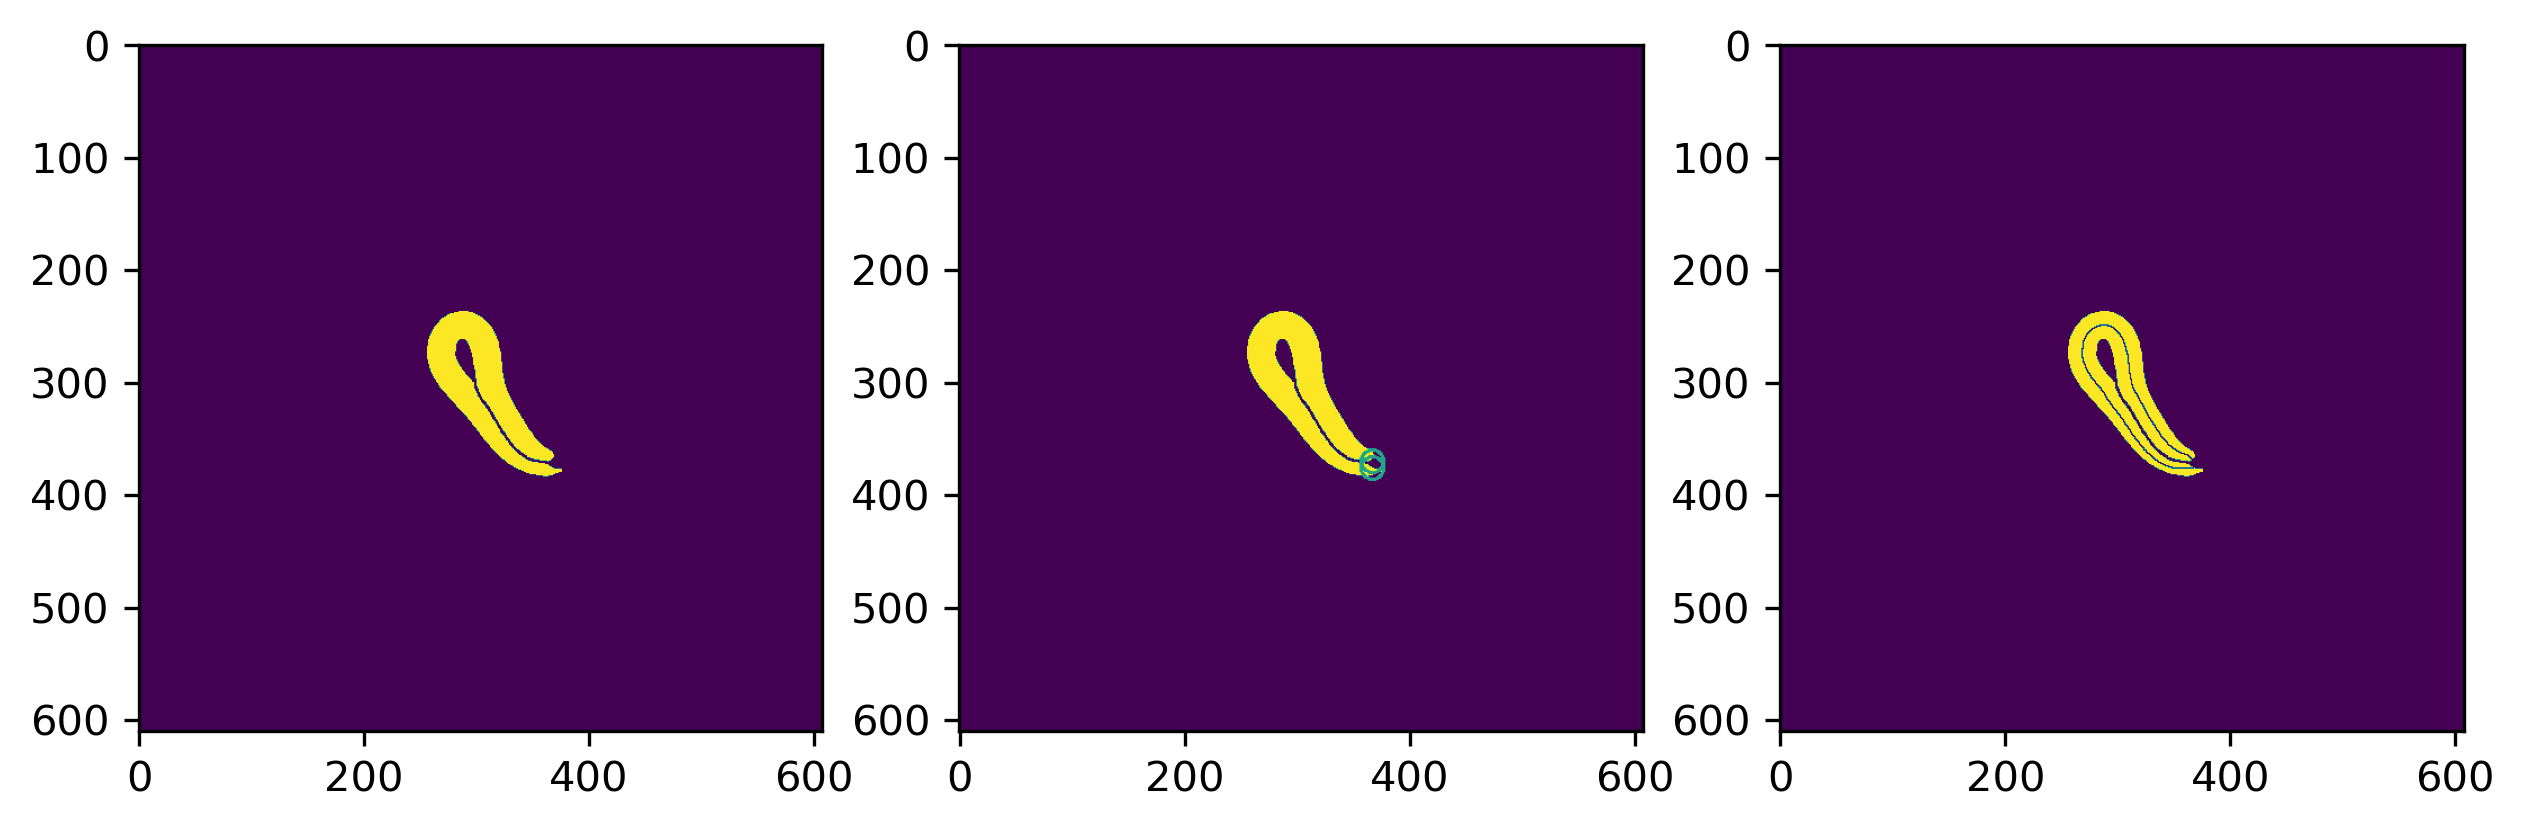

img2924.tif
head and tail were too close, no centerline could be created
img2948.tif
head and tail were too close, no centerline could be created
img2970.tif


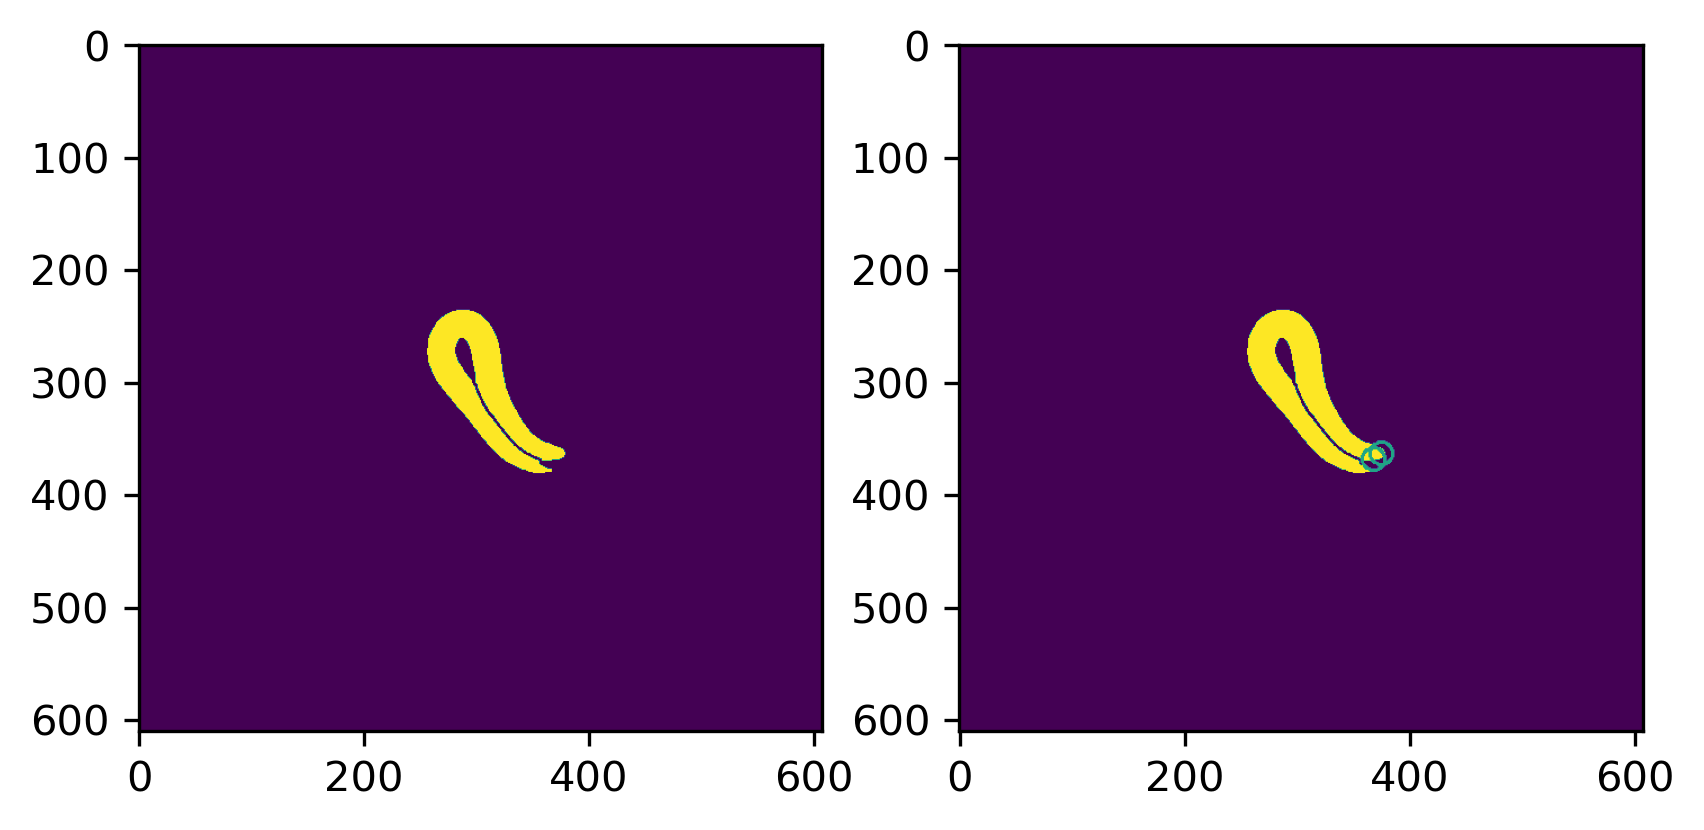

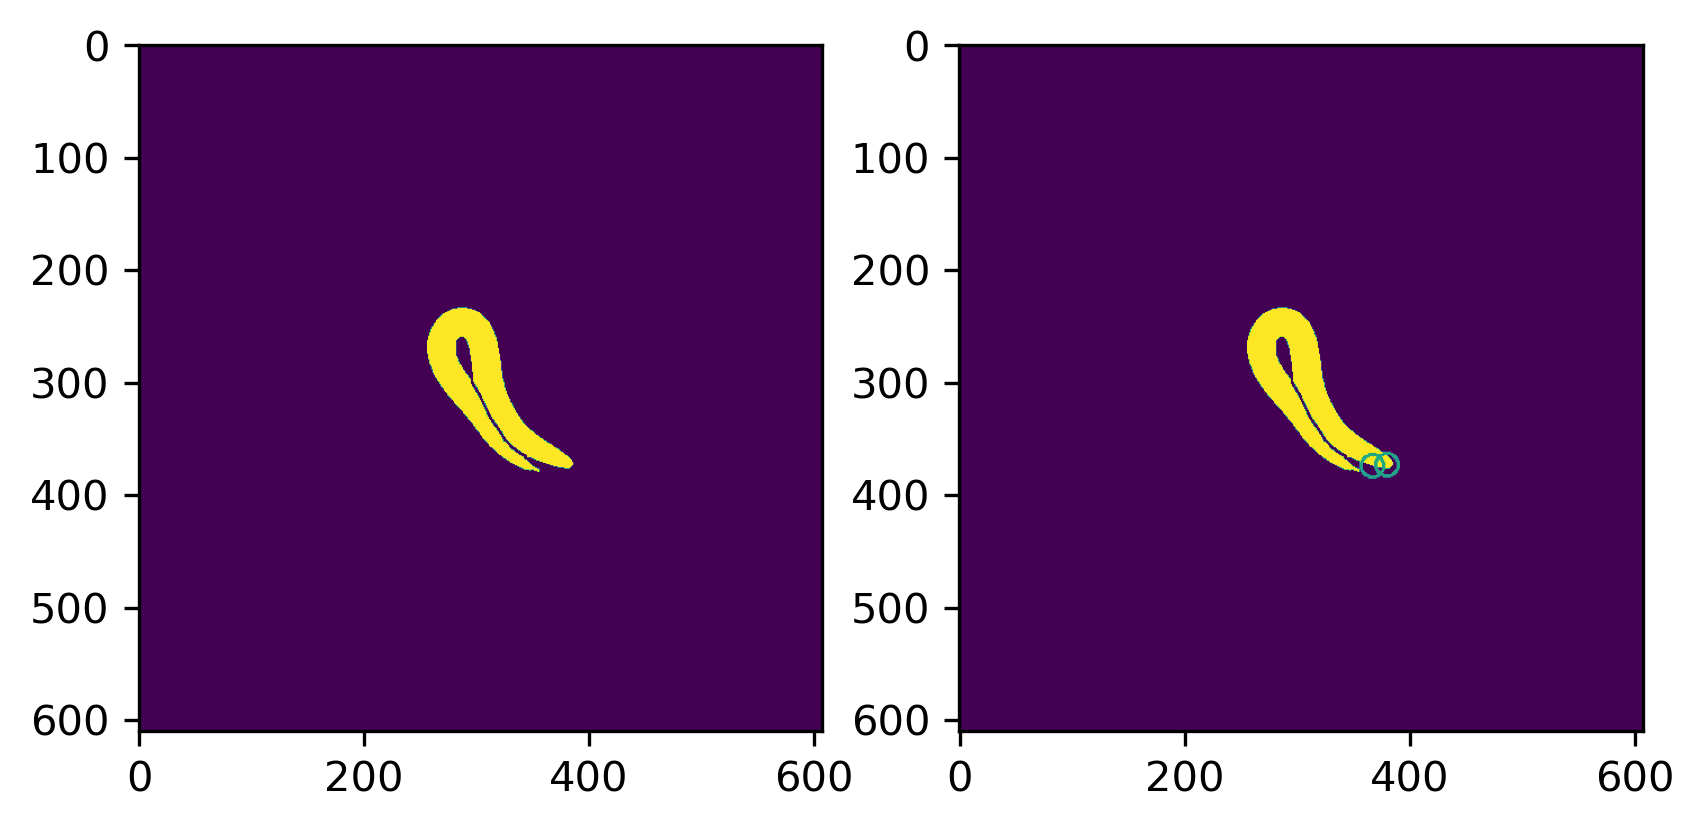

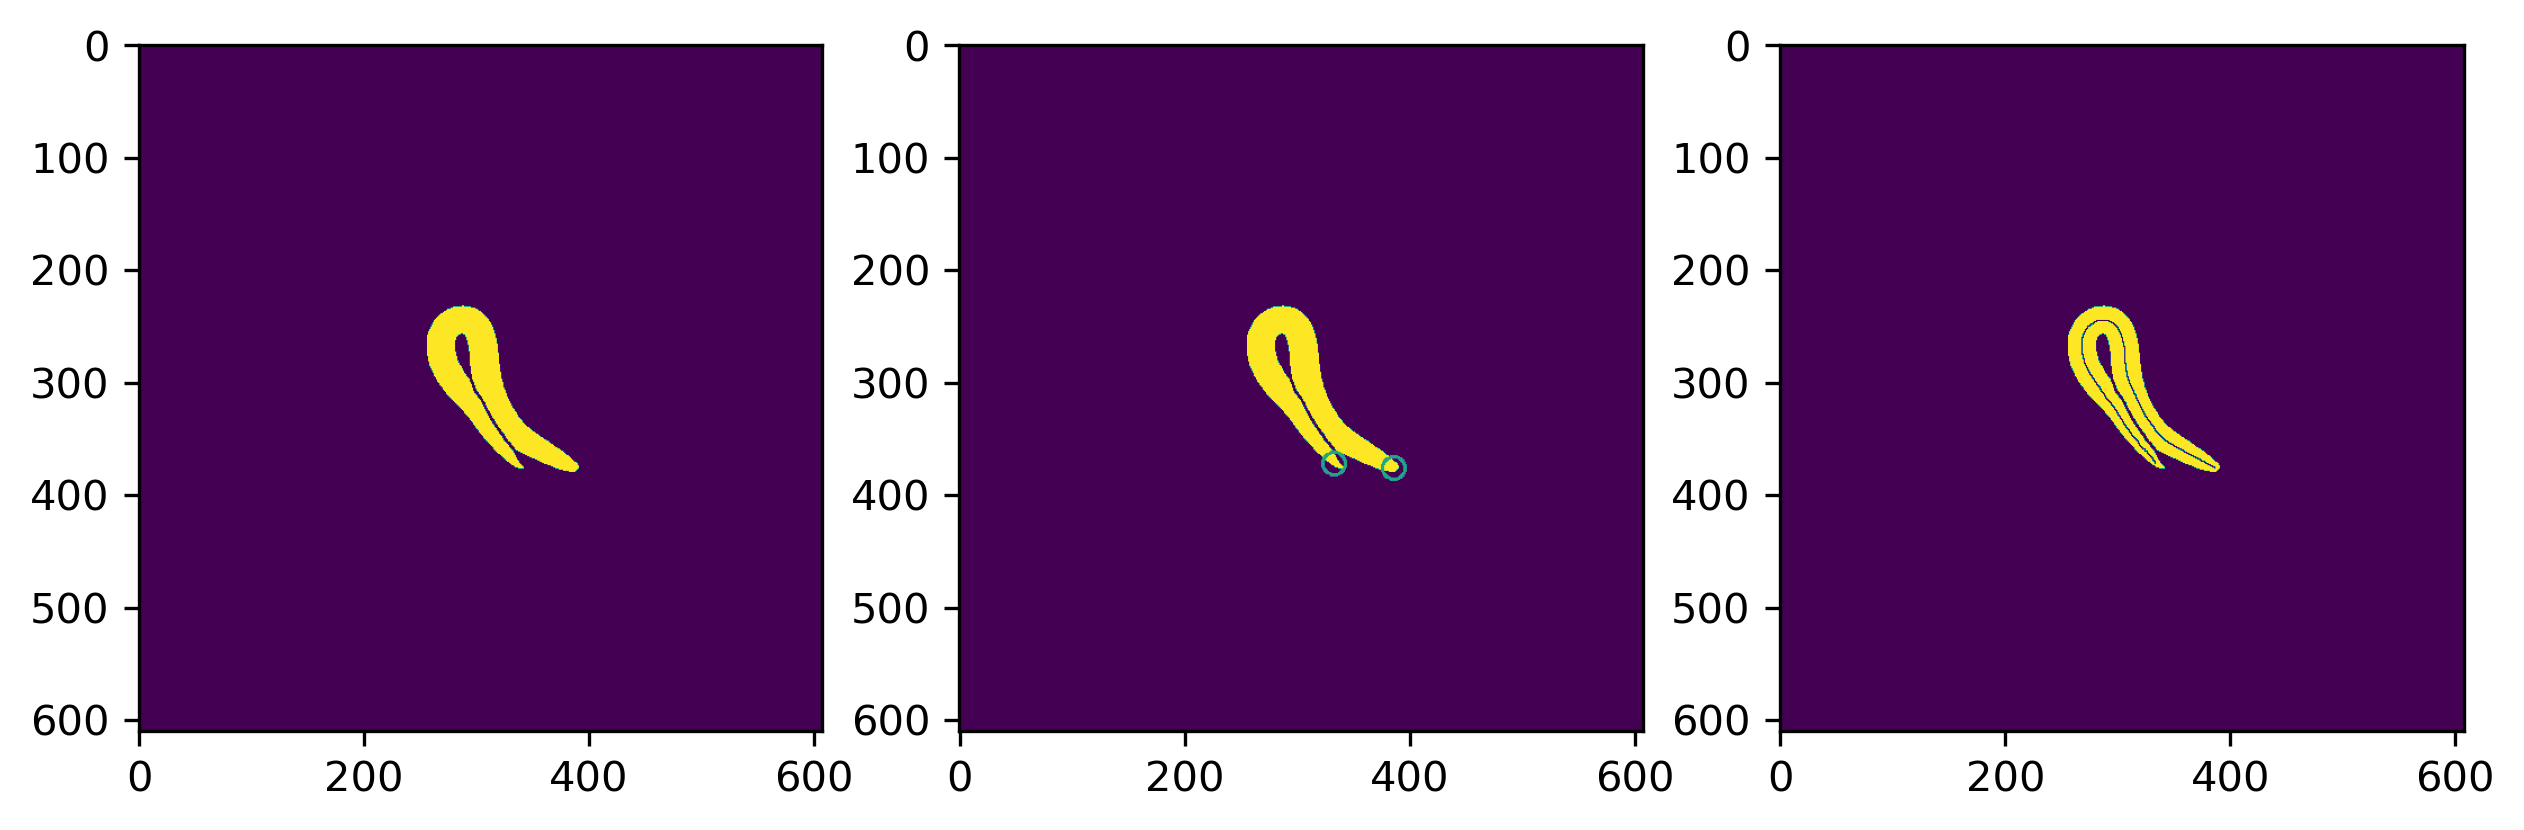

img3017.tif


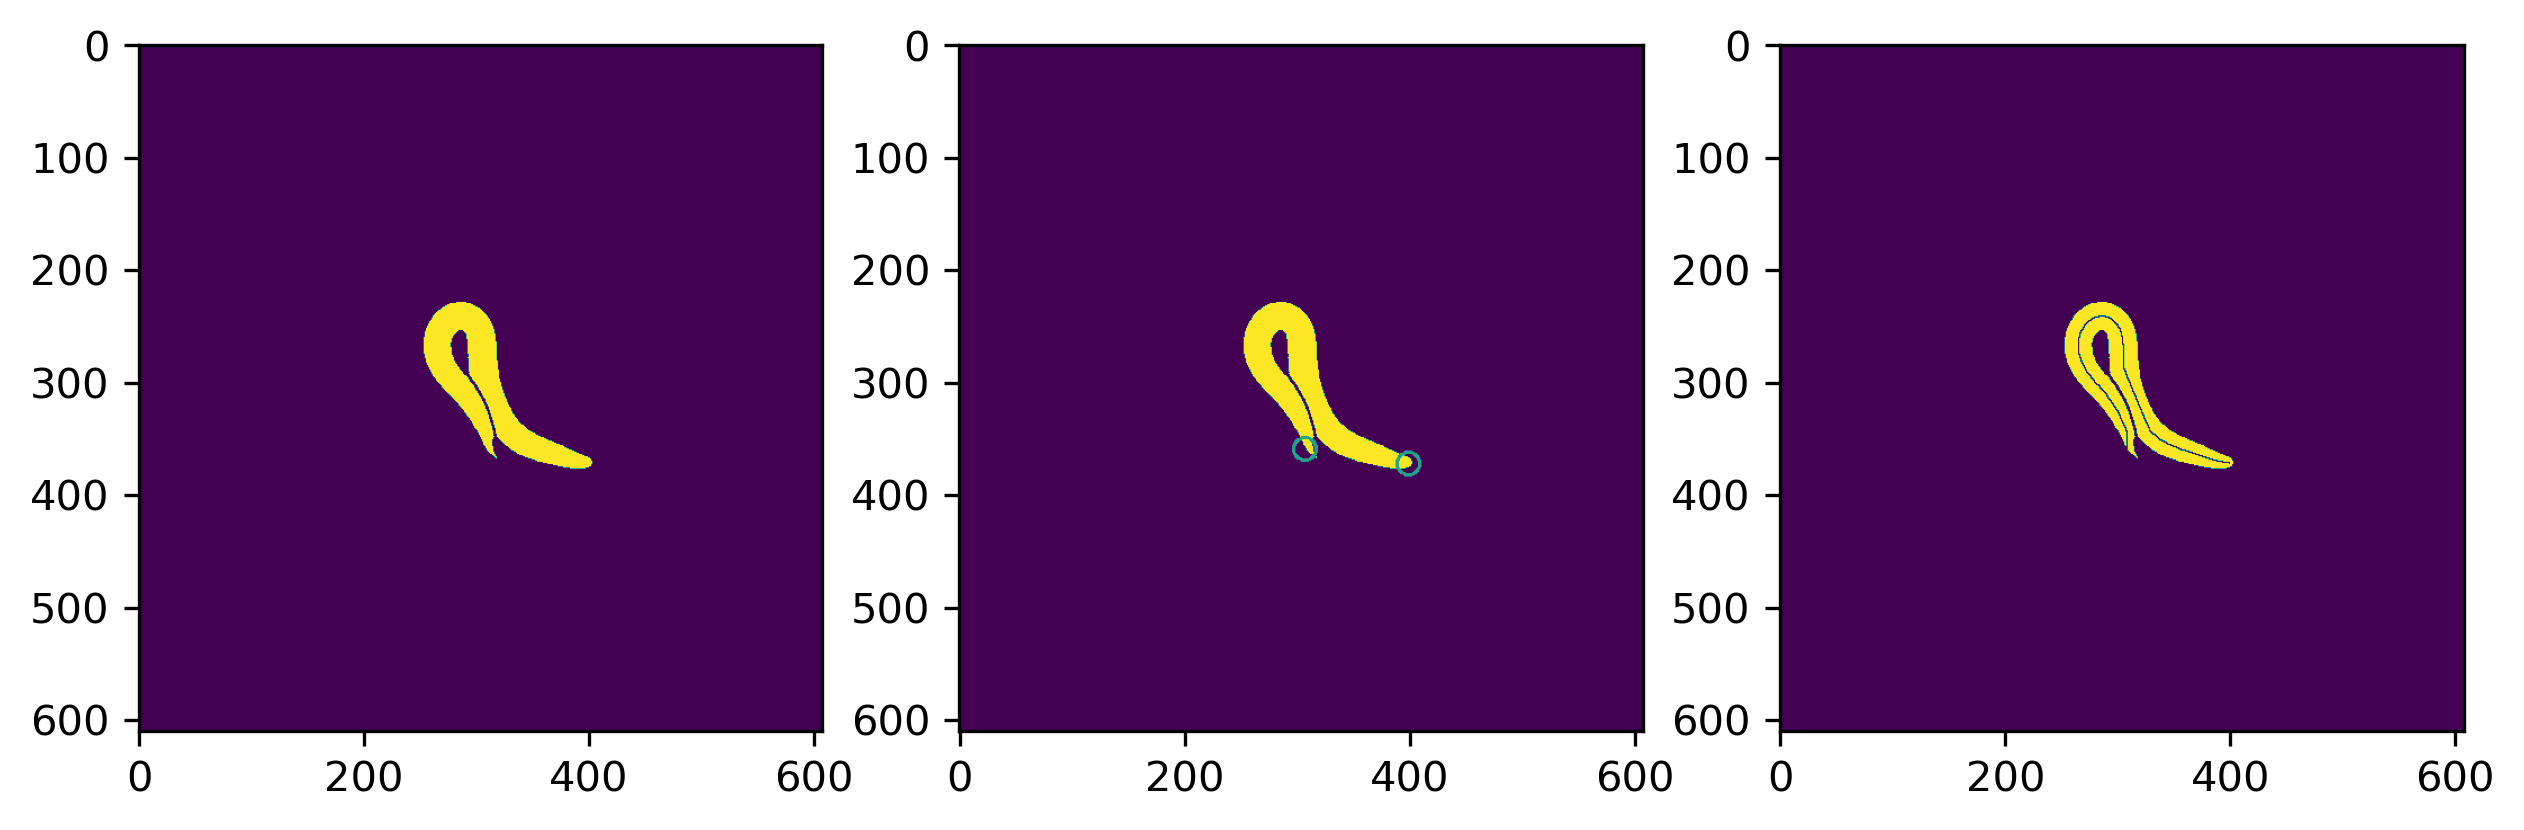

img3072.tif


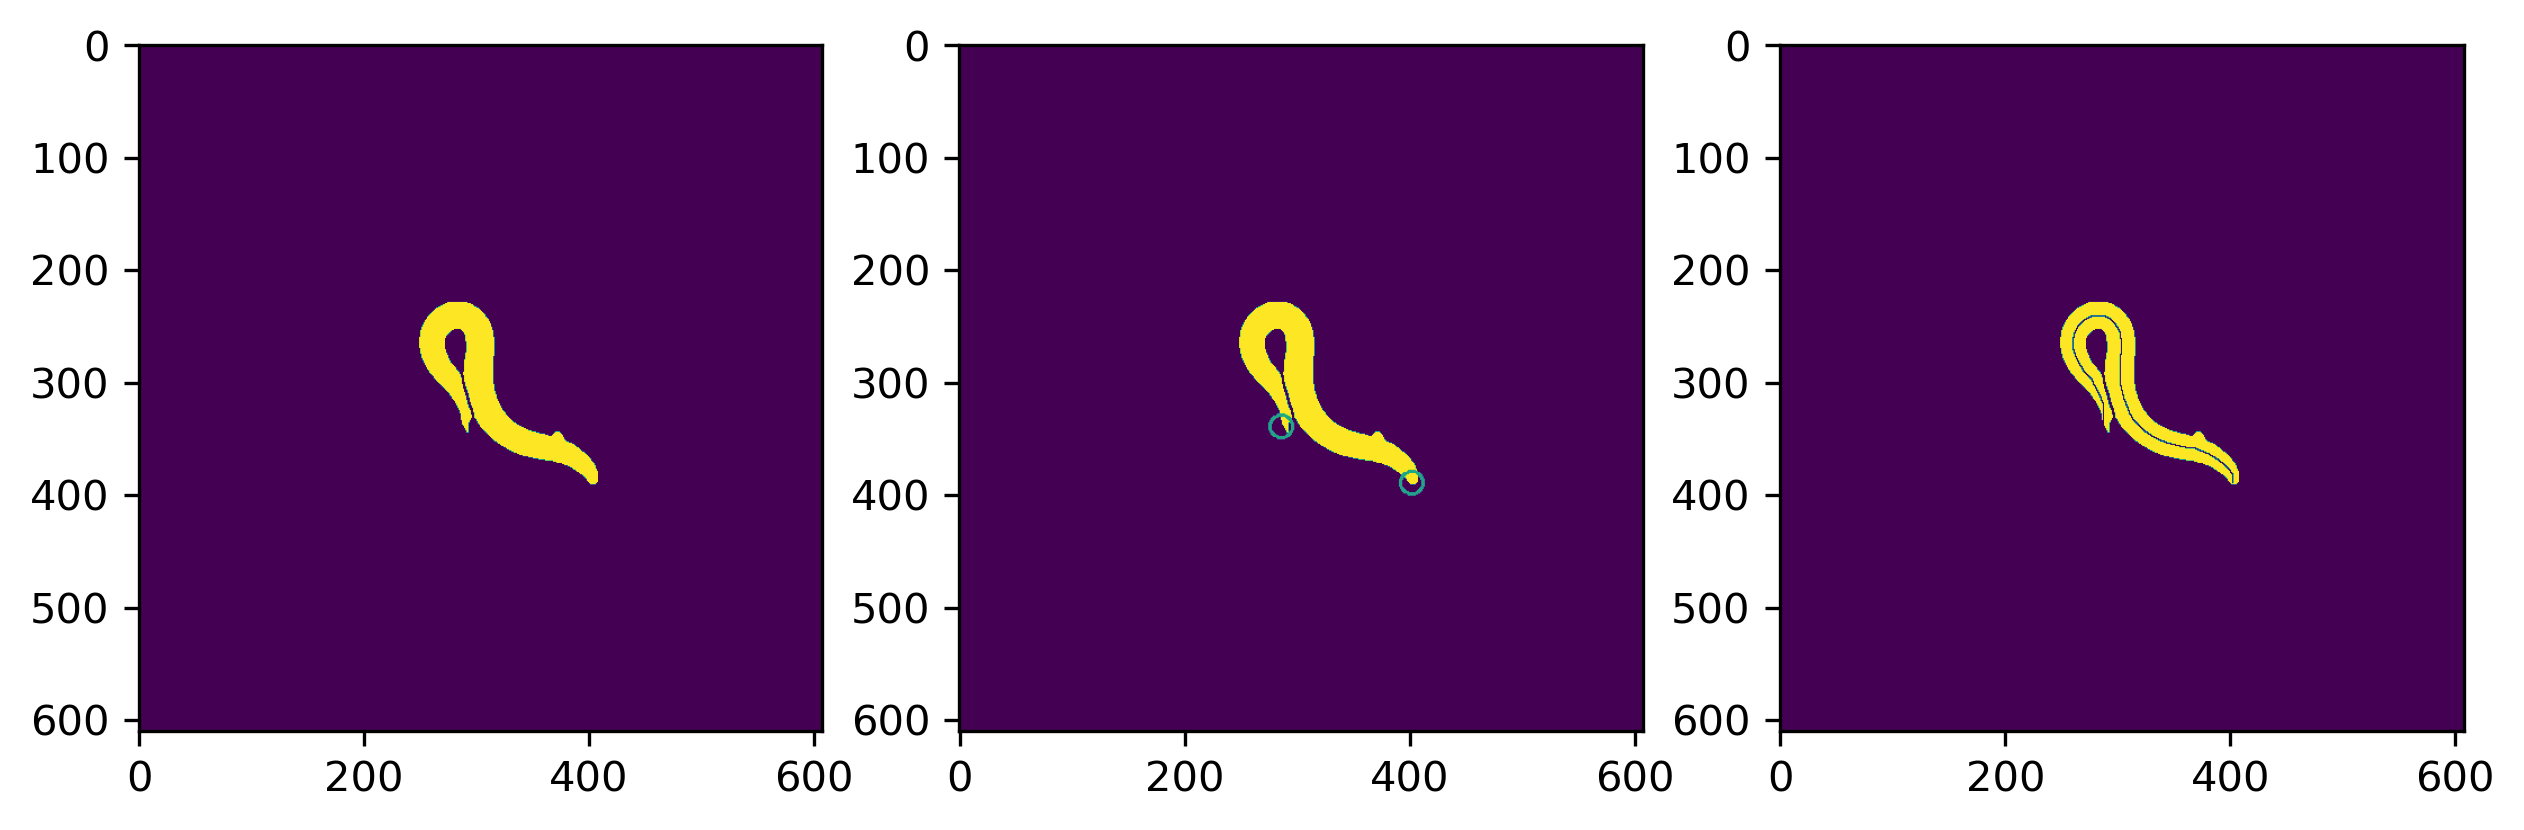

img3110.tif


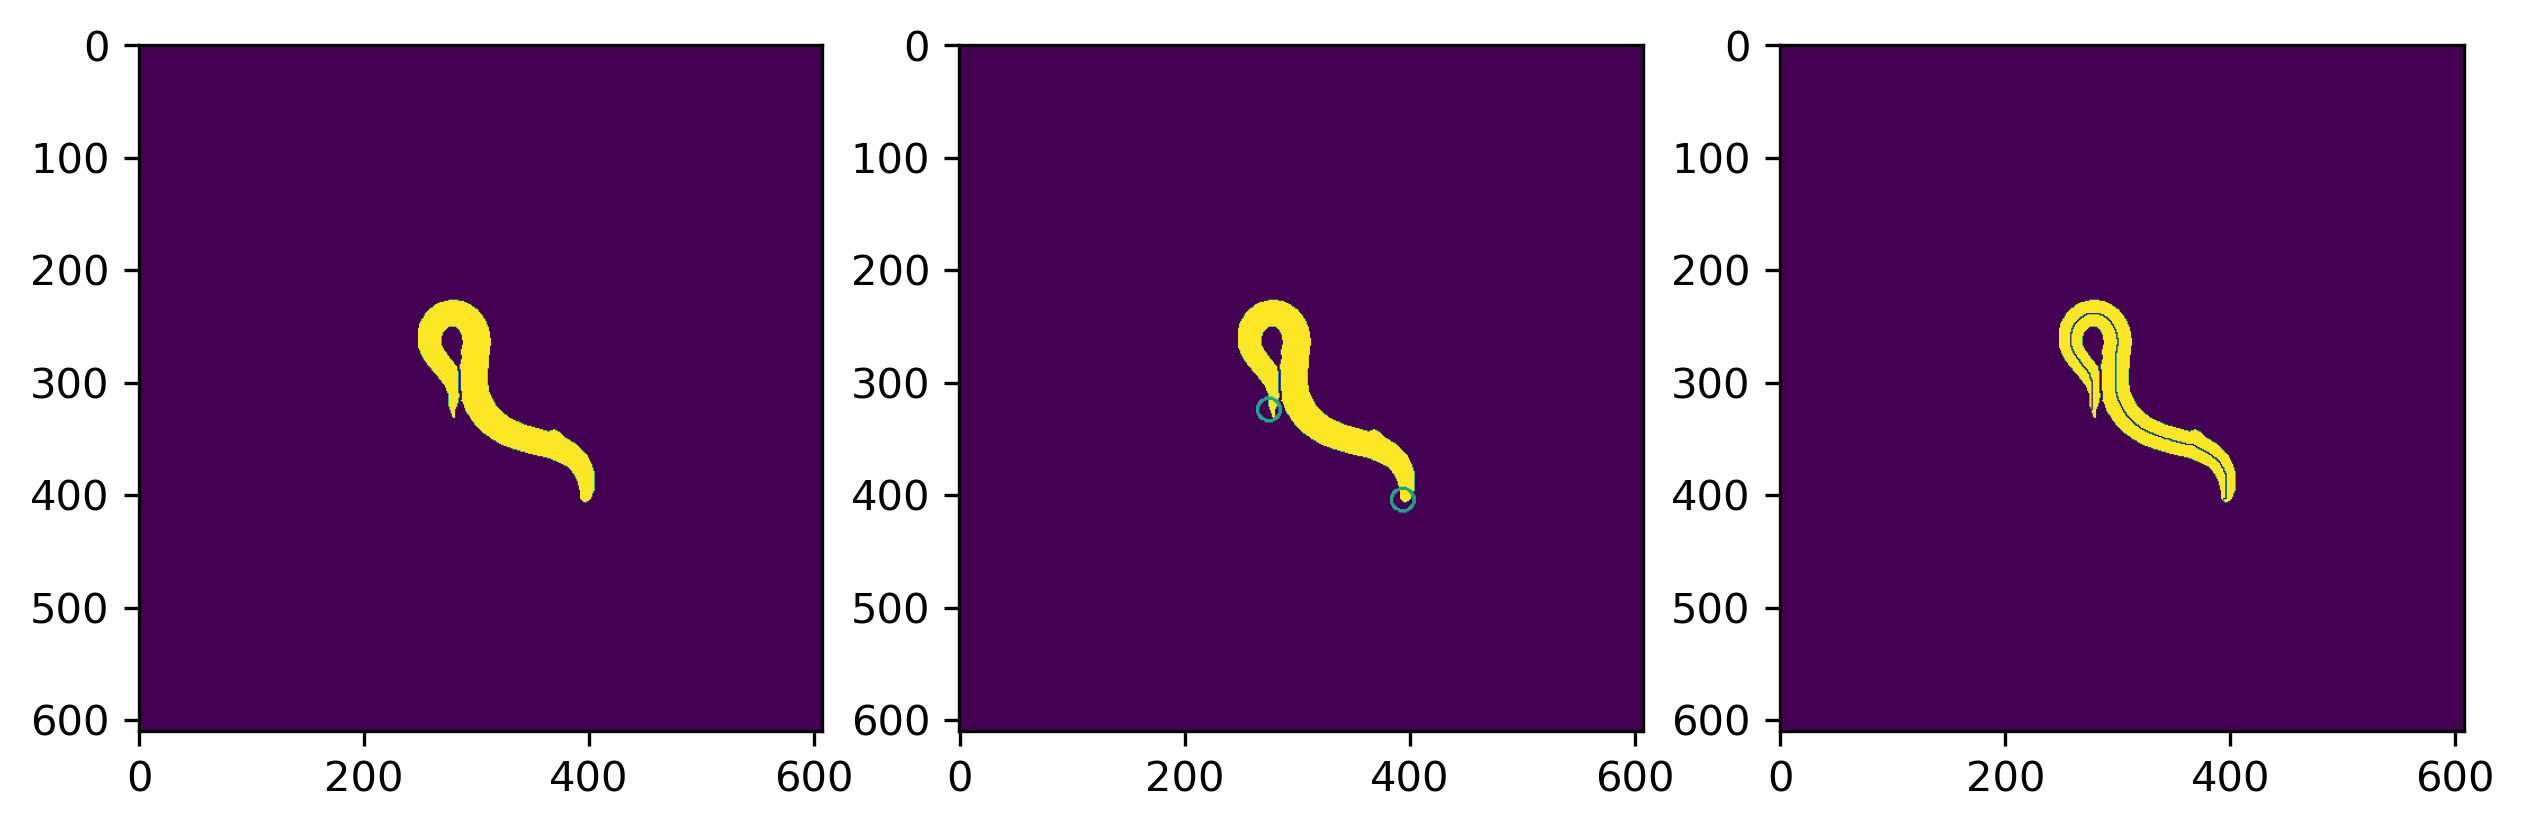

img3128.tif


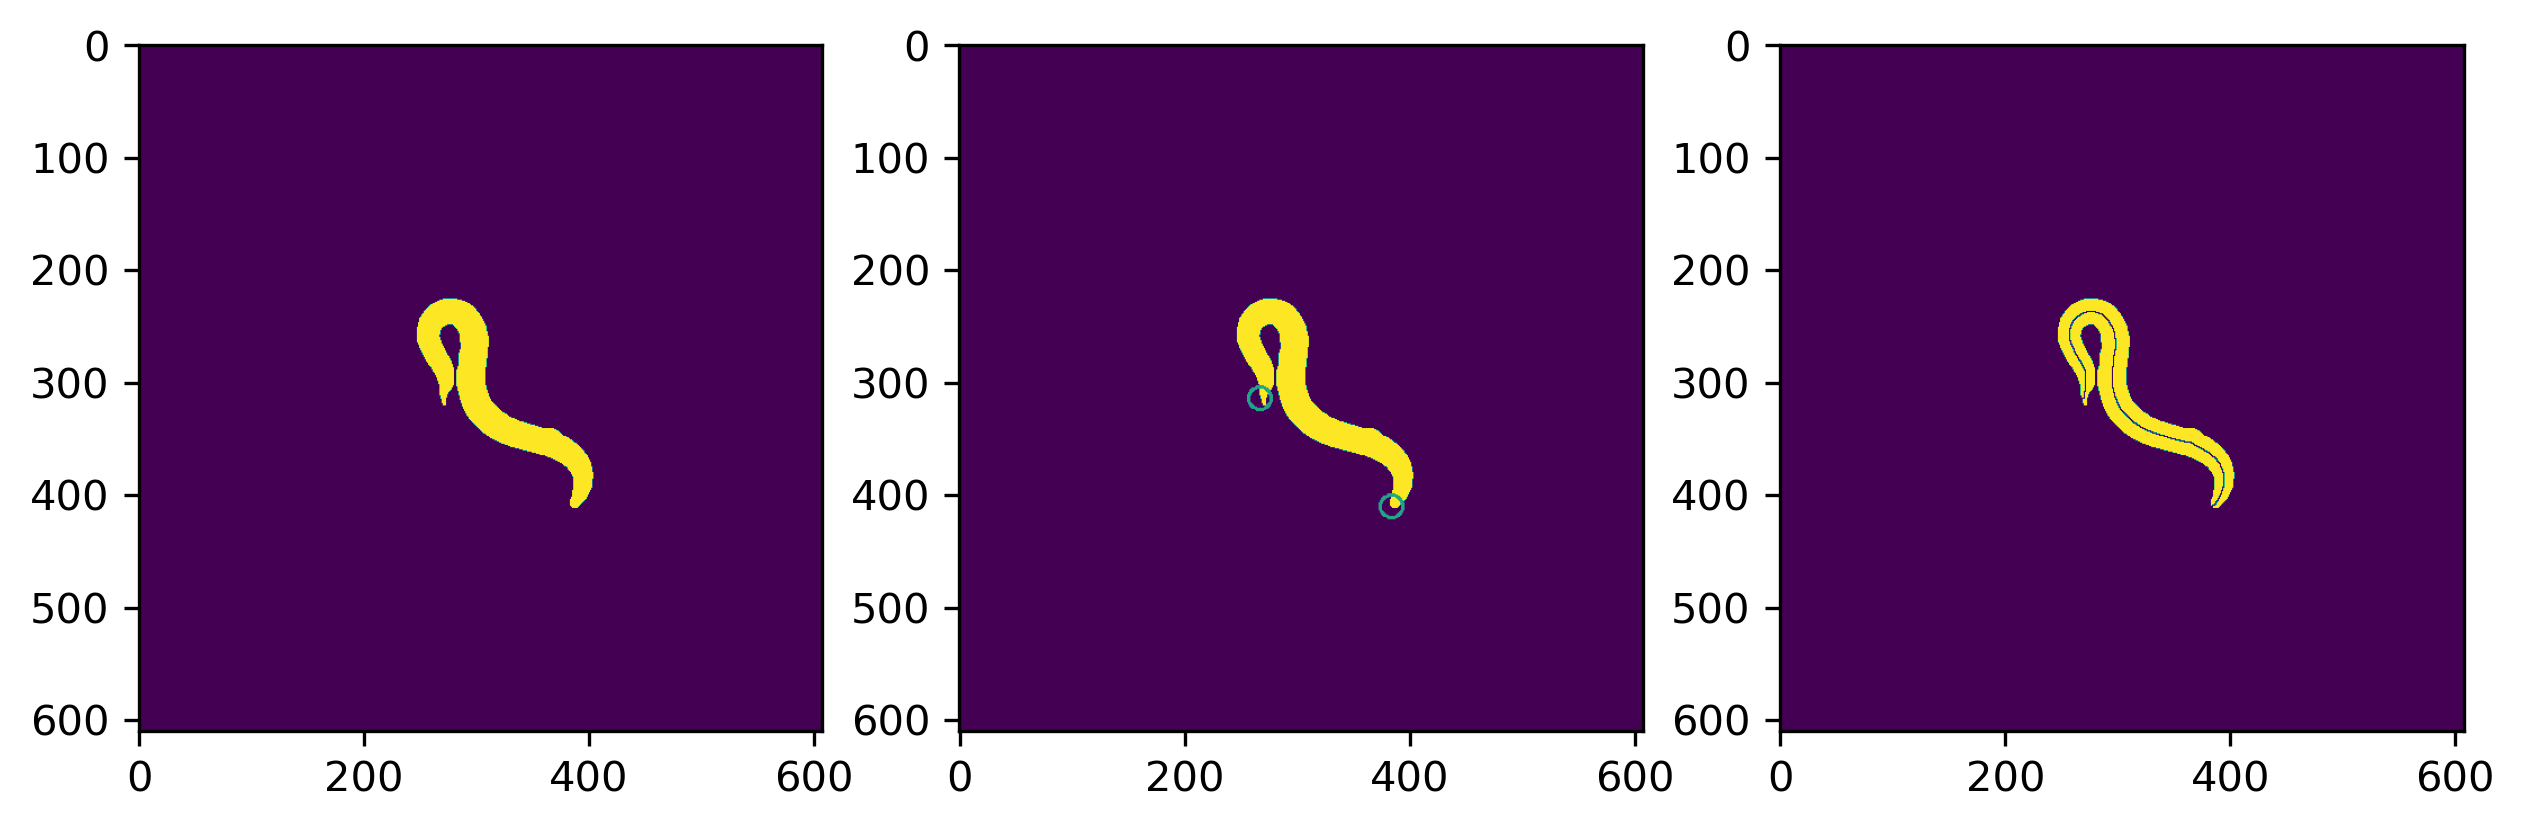

img5174.tif
head and tail were too close, no centerline could be created
img5202.tif
head and tail were too close, no centerline could be created
img5218.tif
head and tail were too close, no centerline could be created
img5243.tif


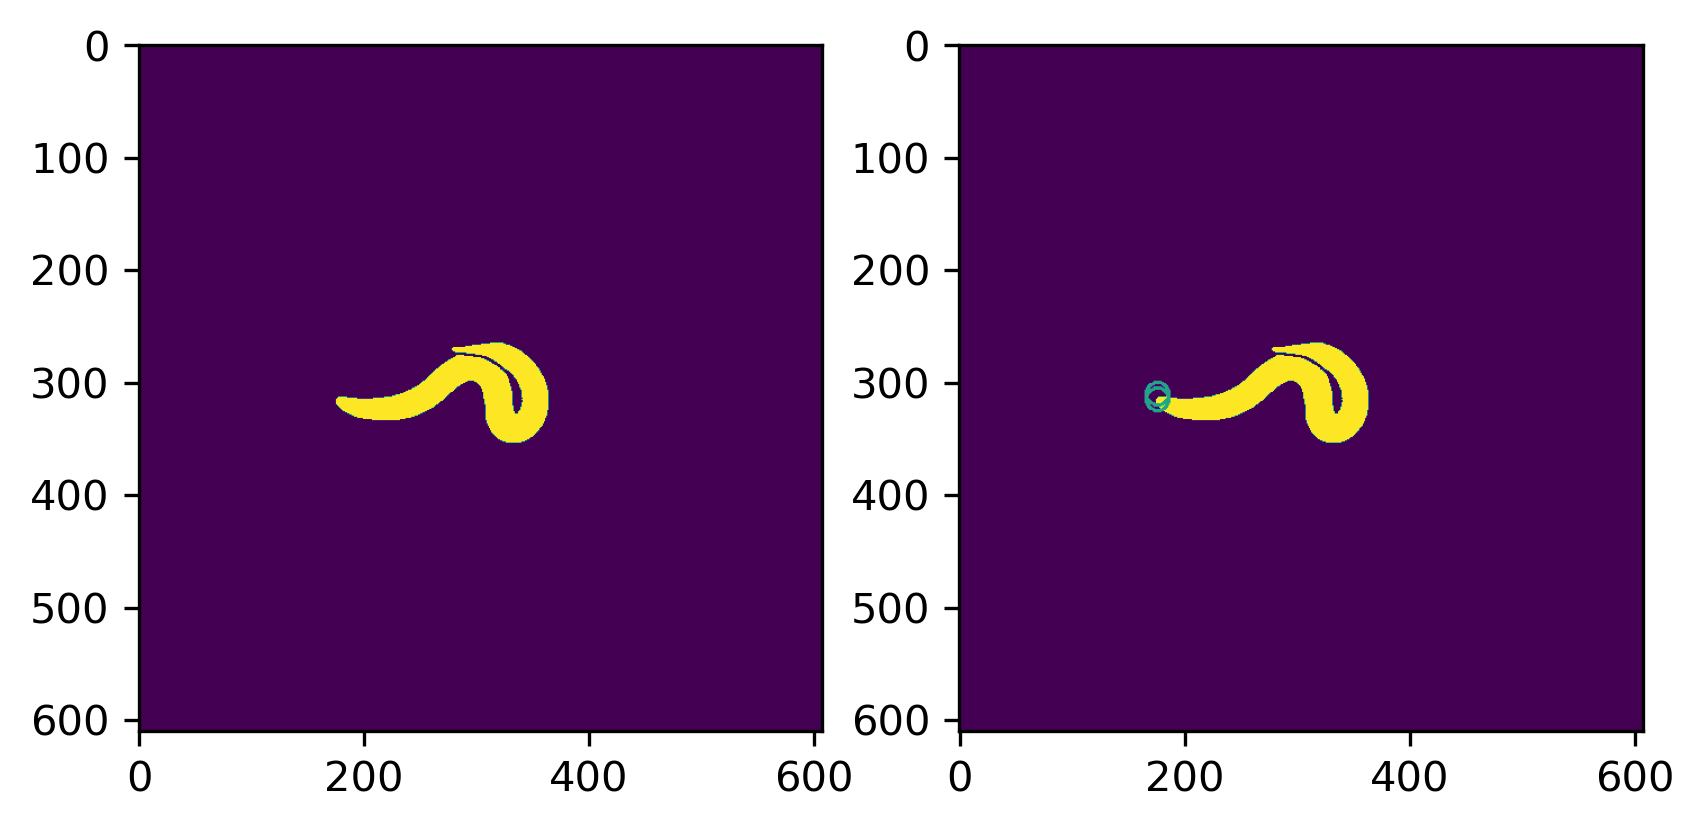

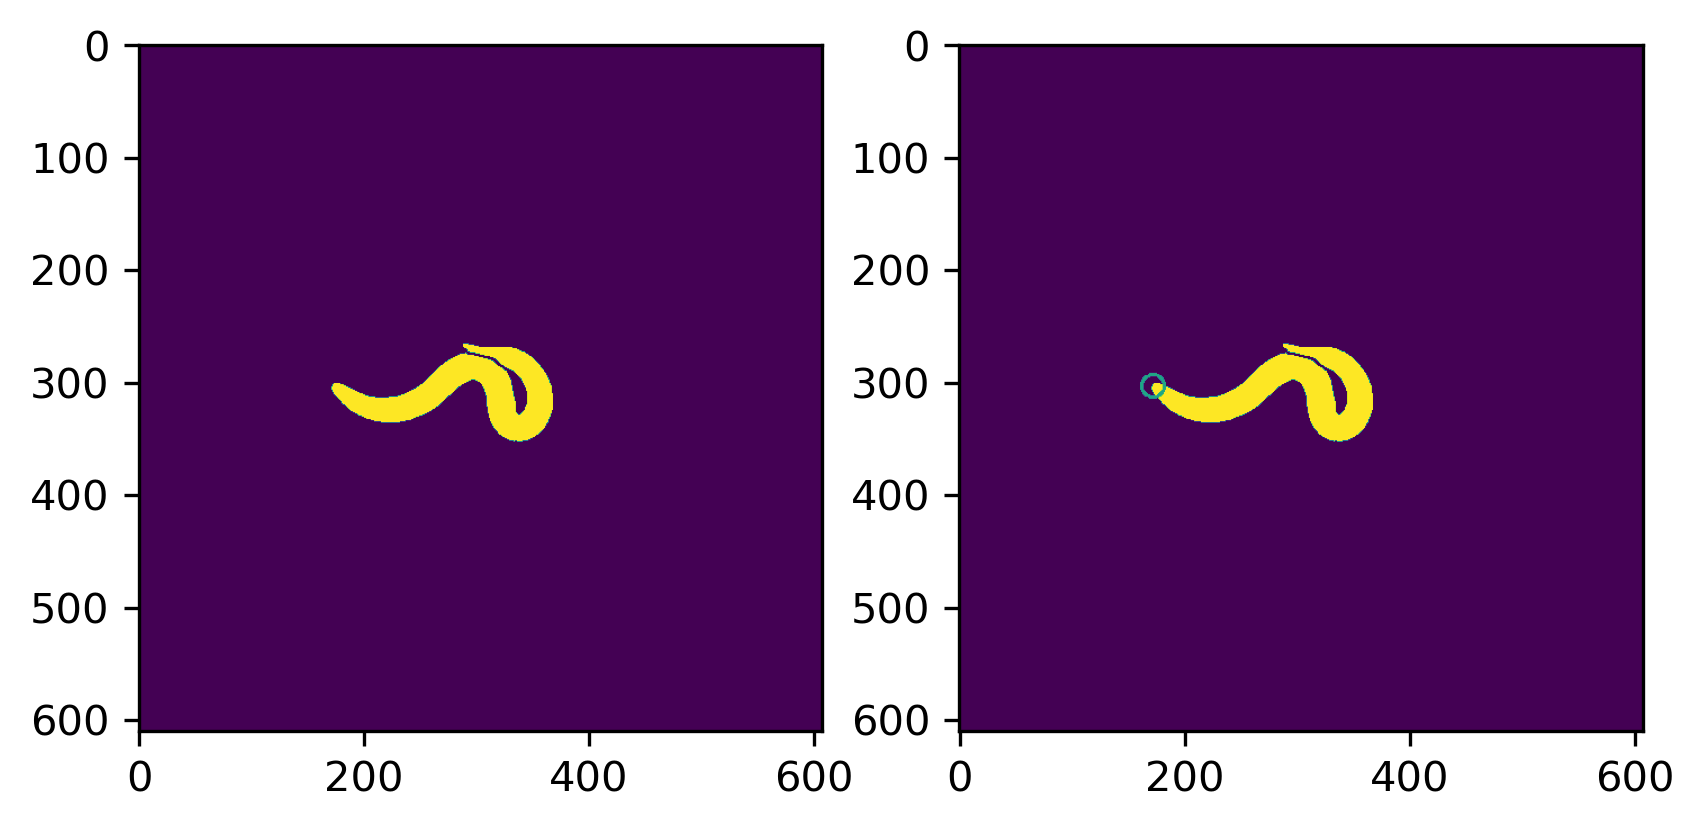

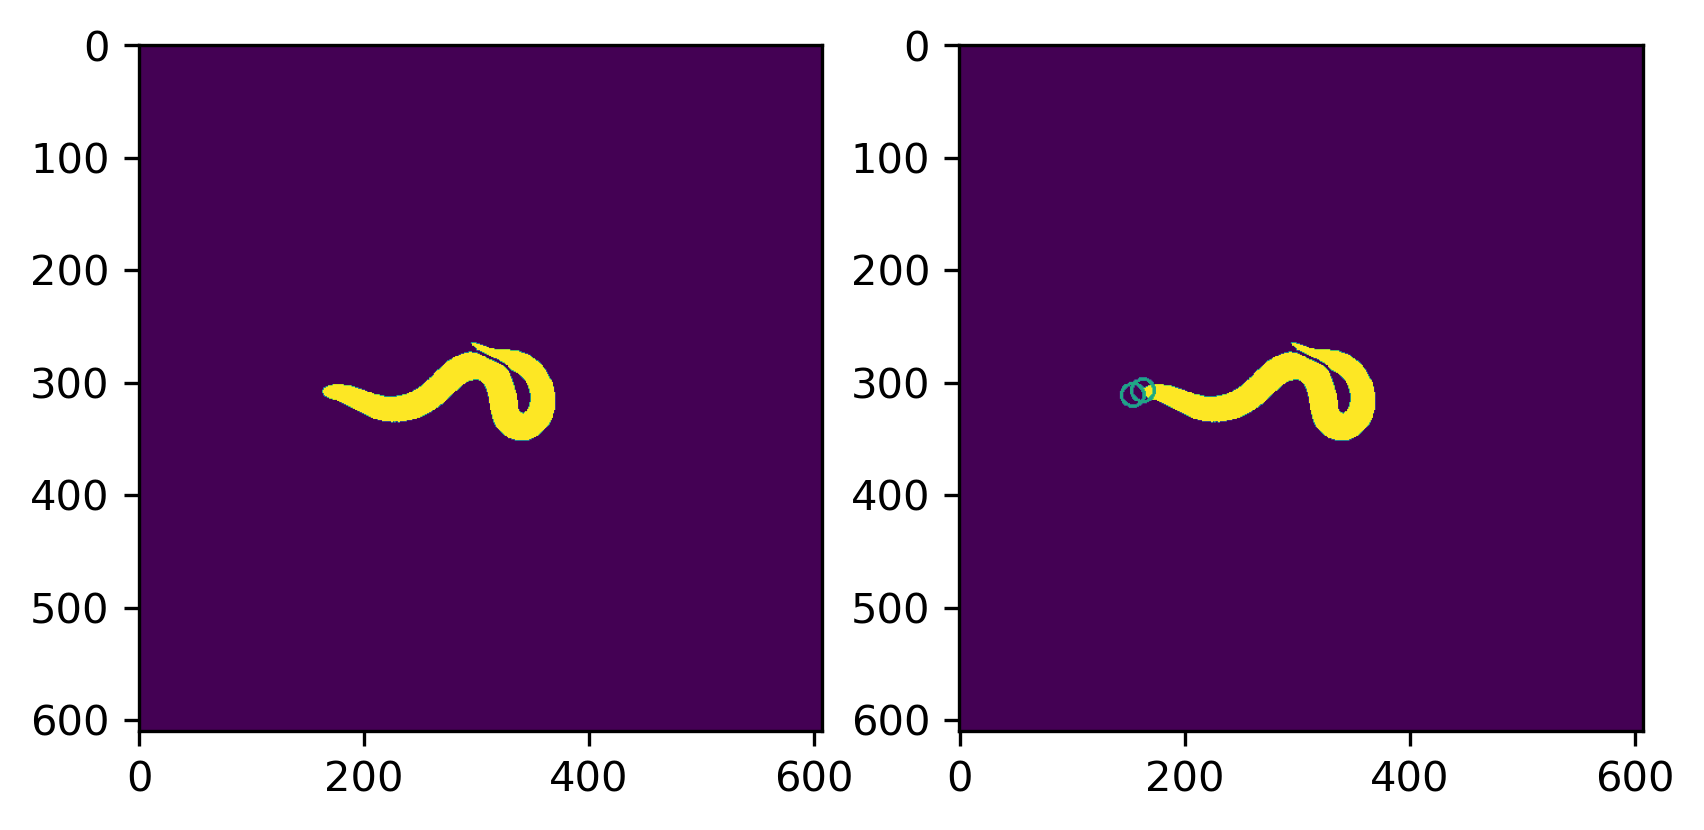

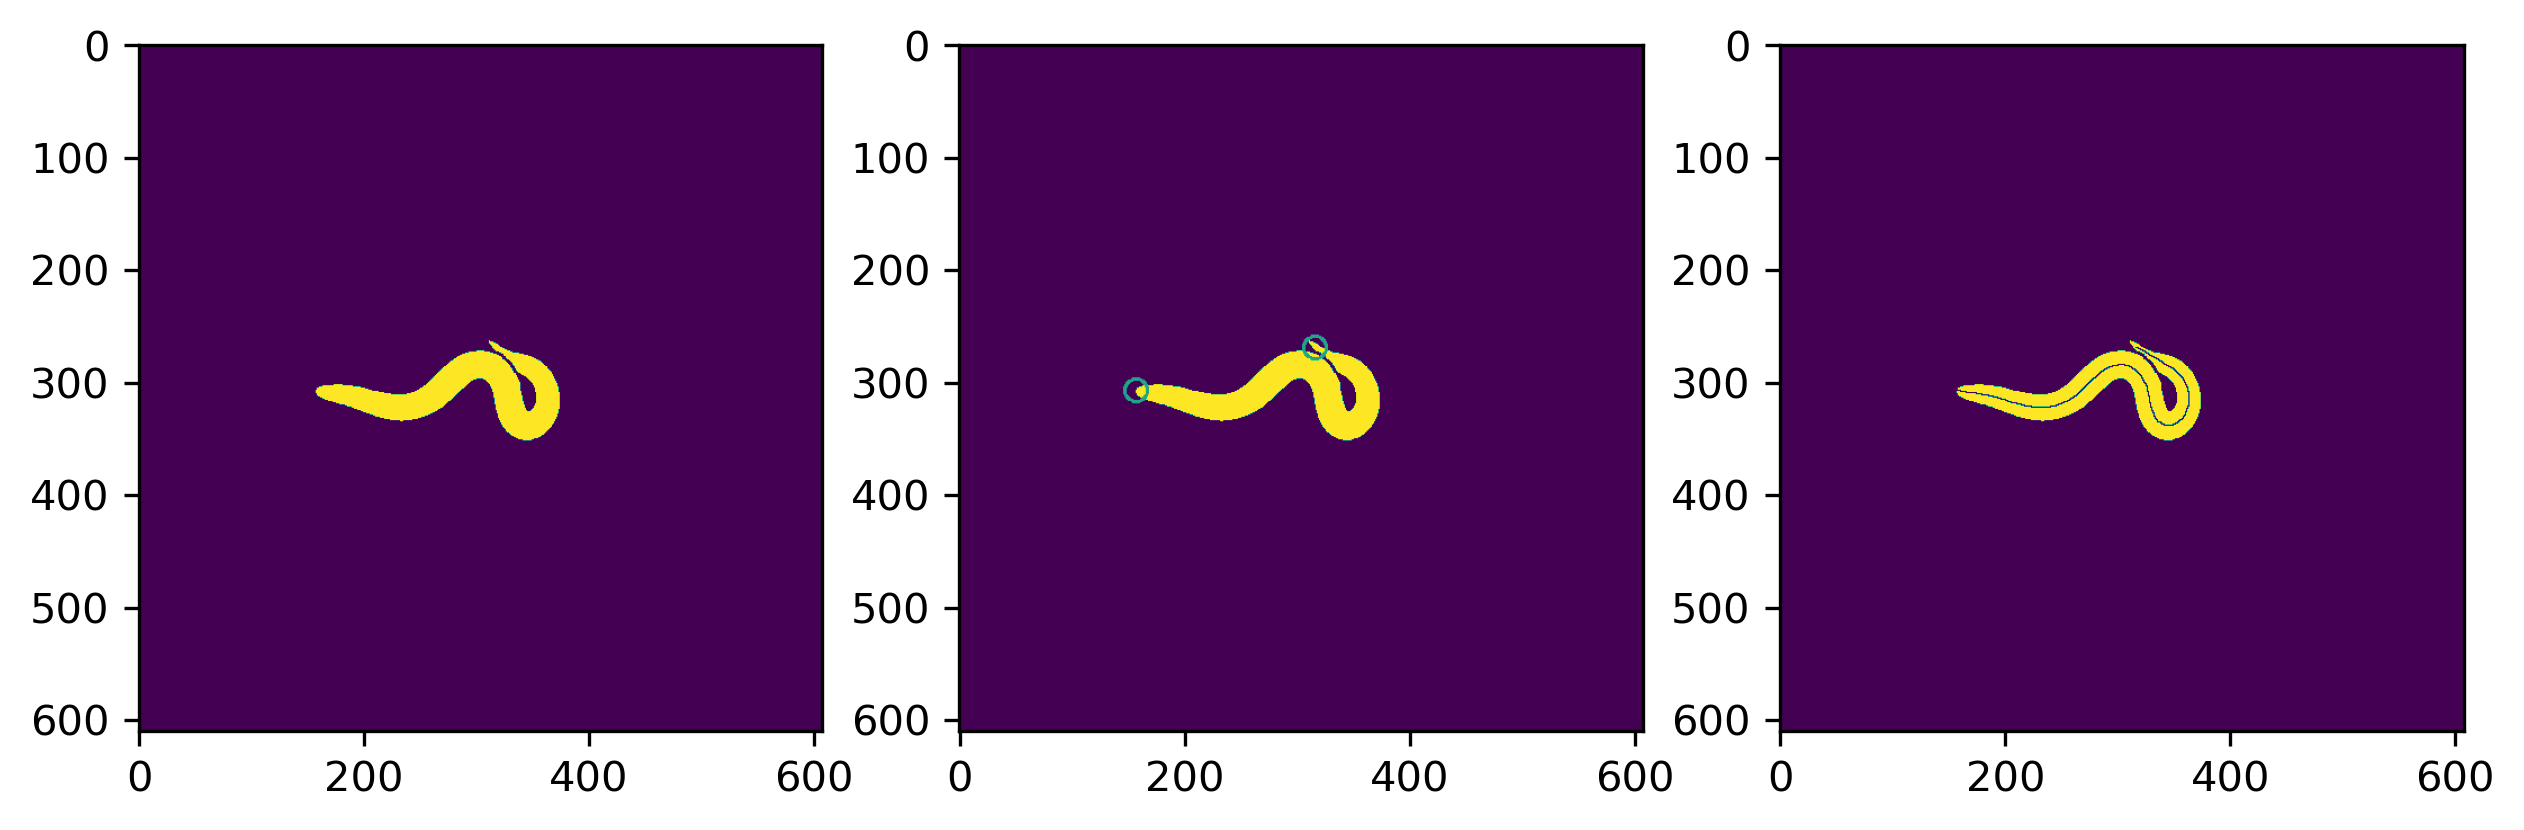

img5259.tif


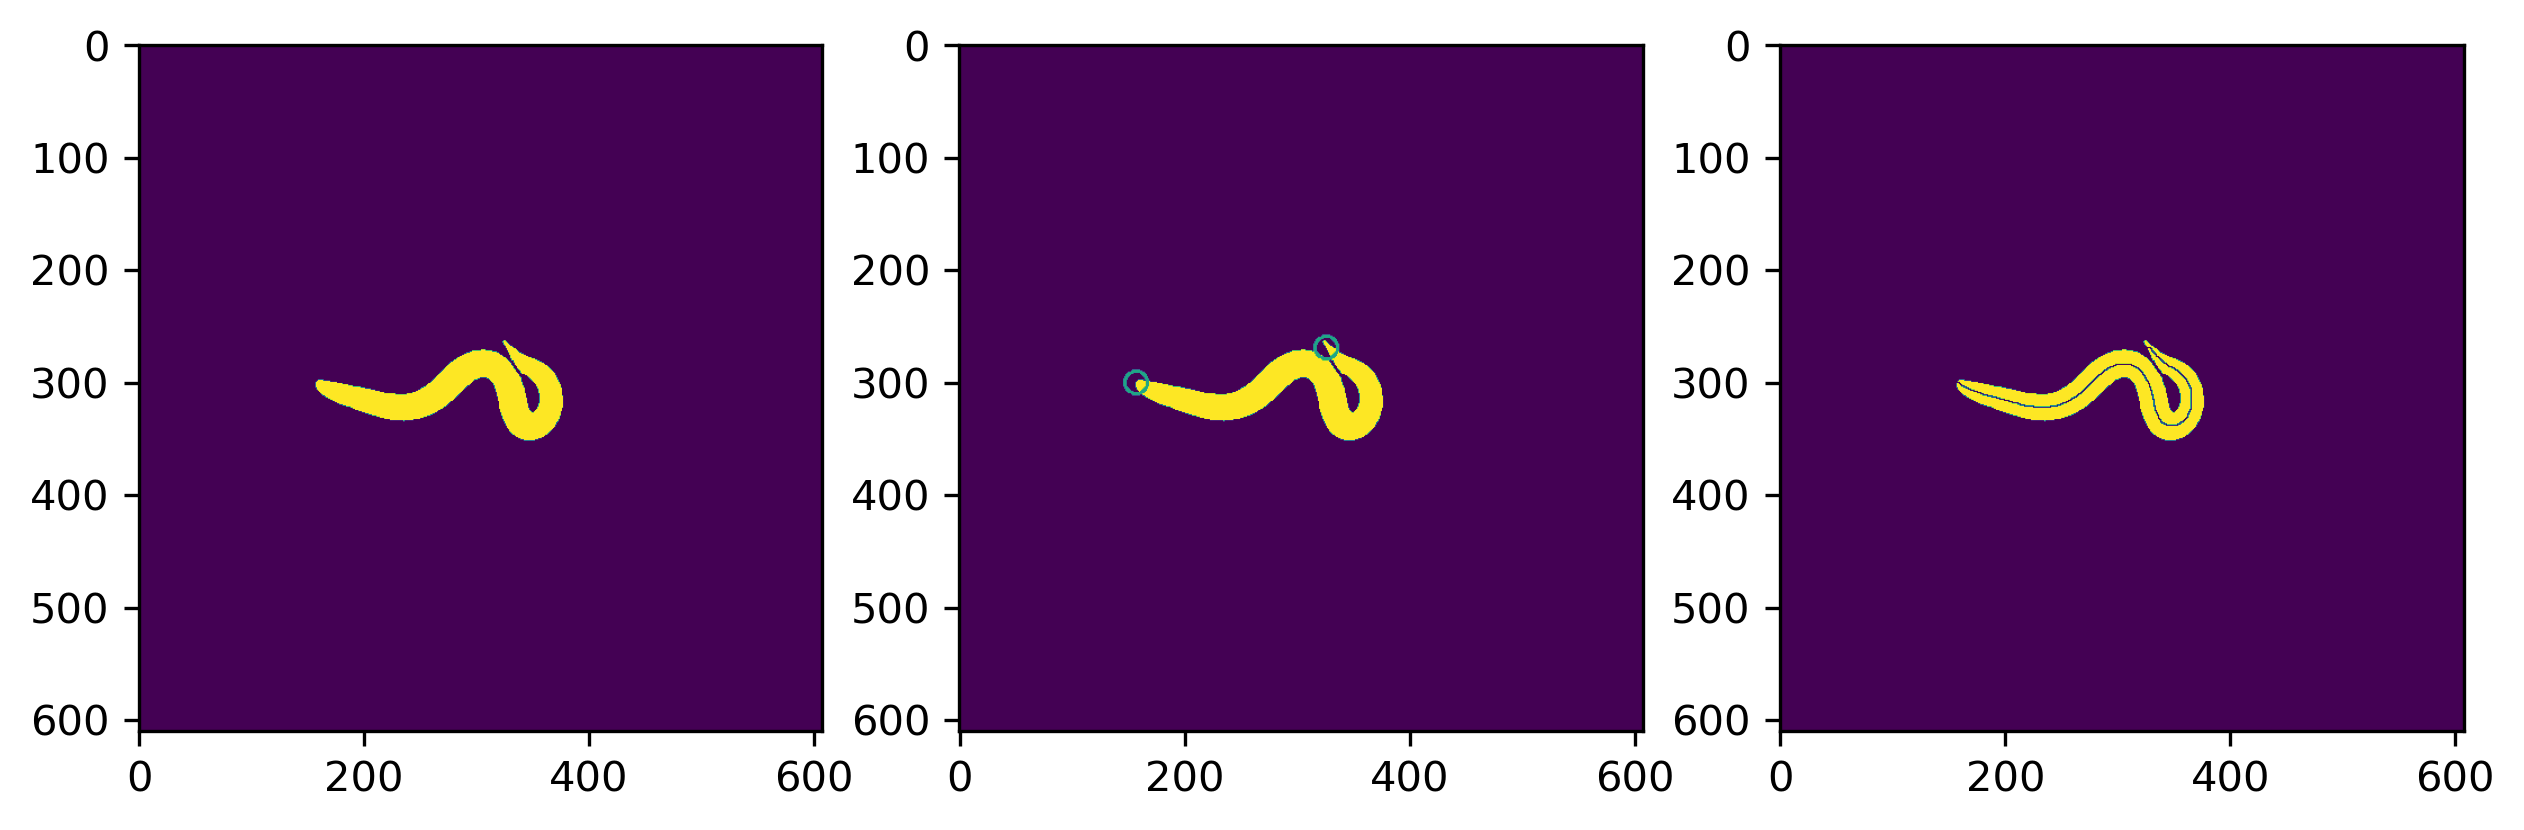

img6961.tif


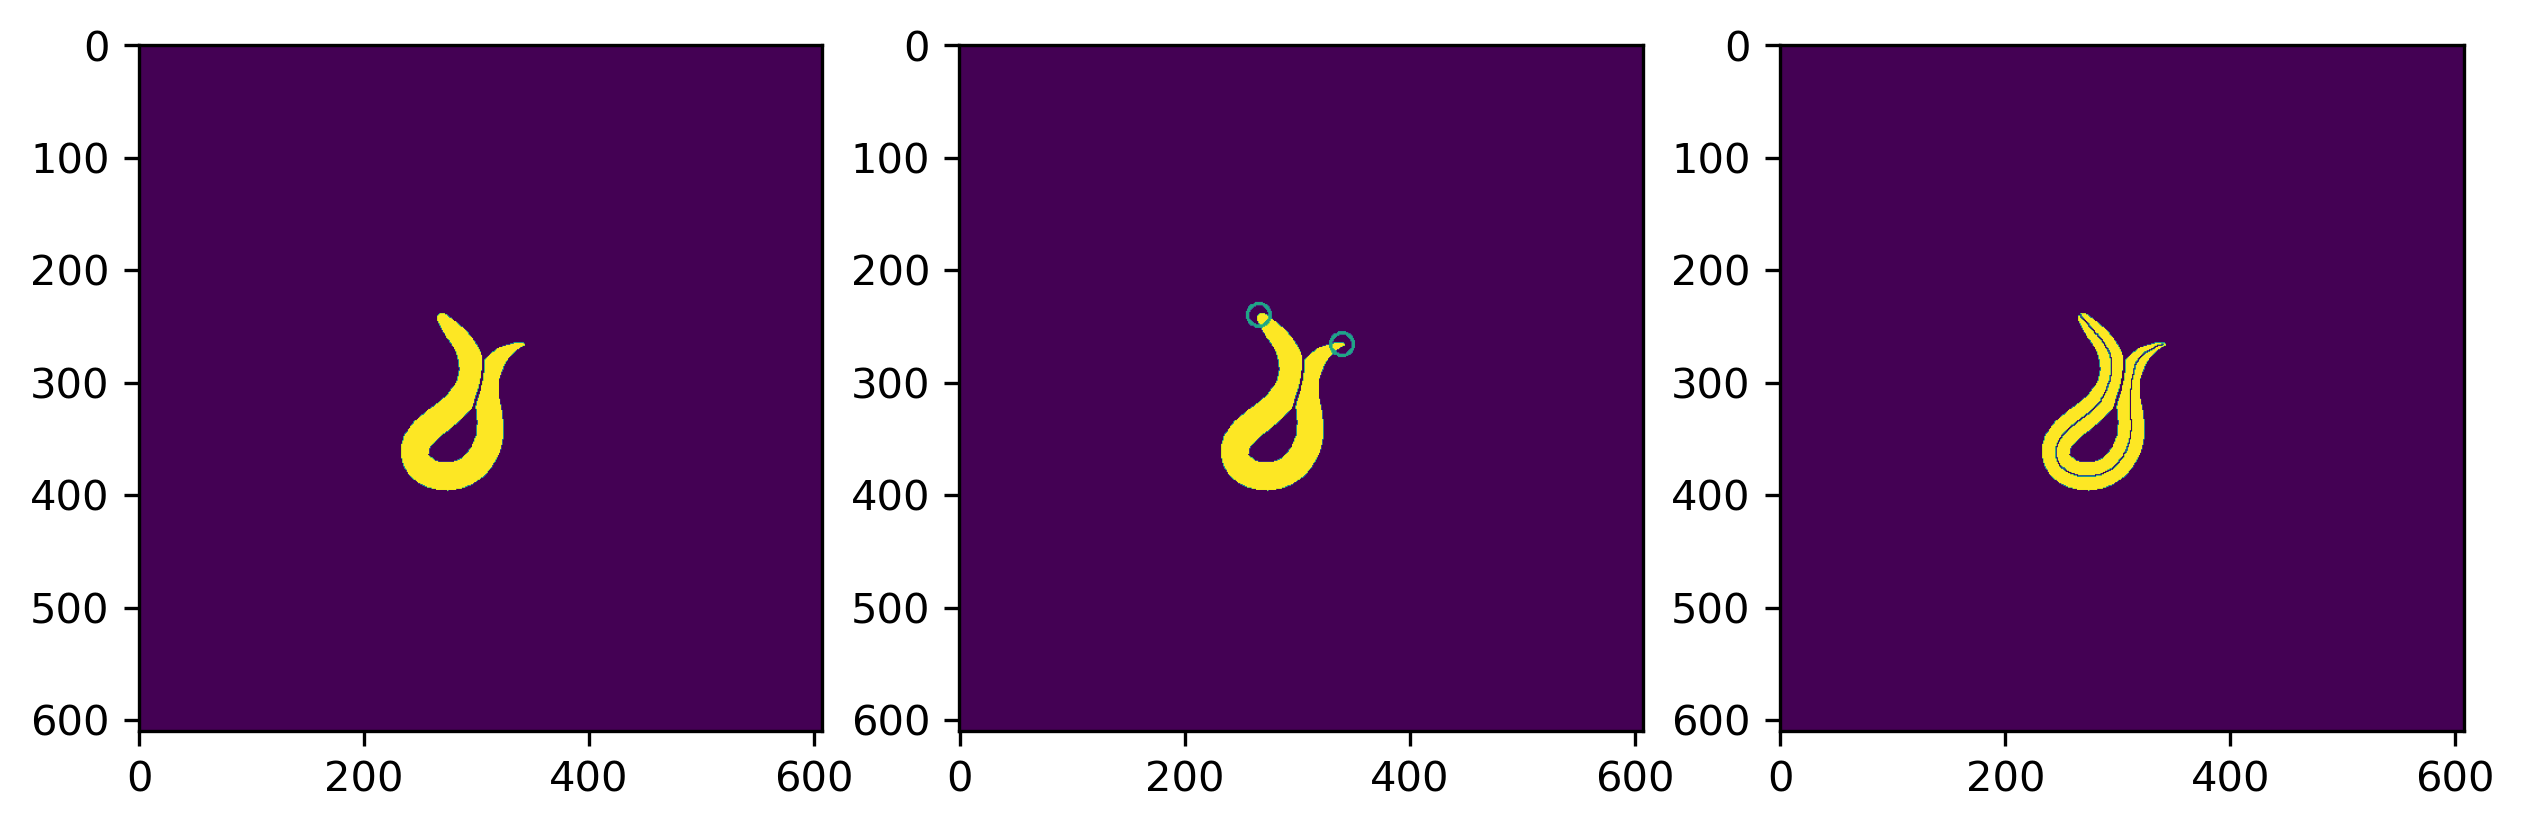

img6984.tif


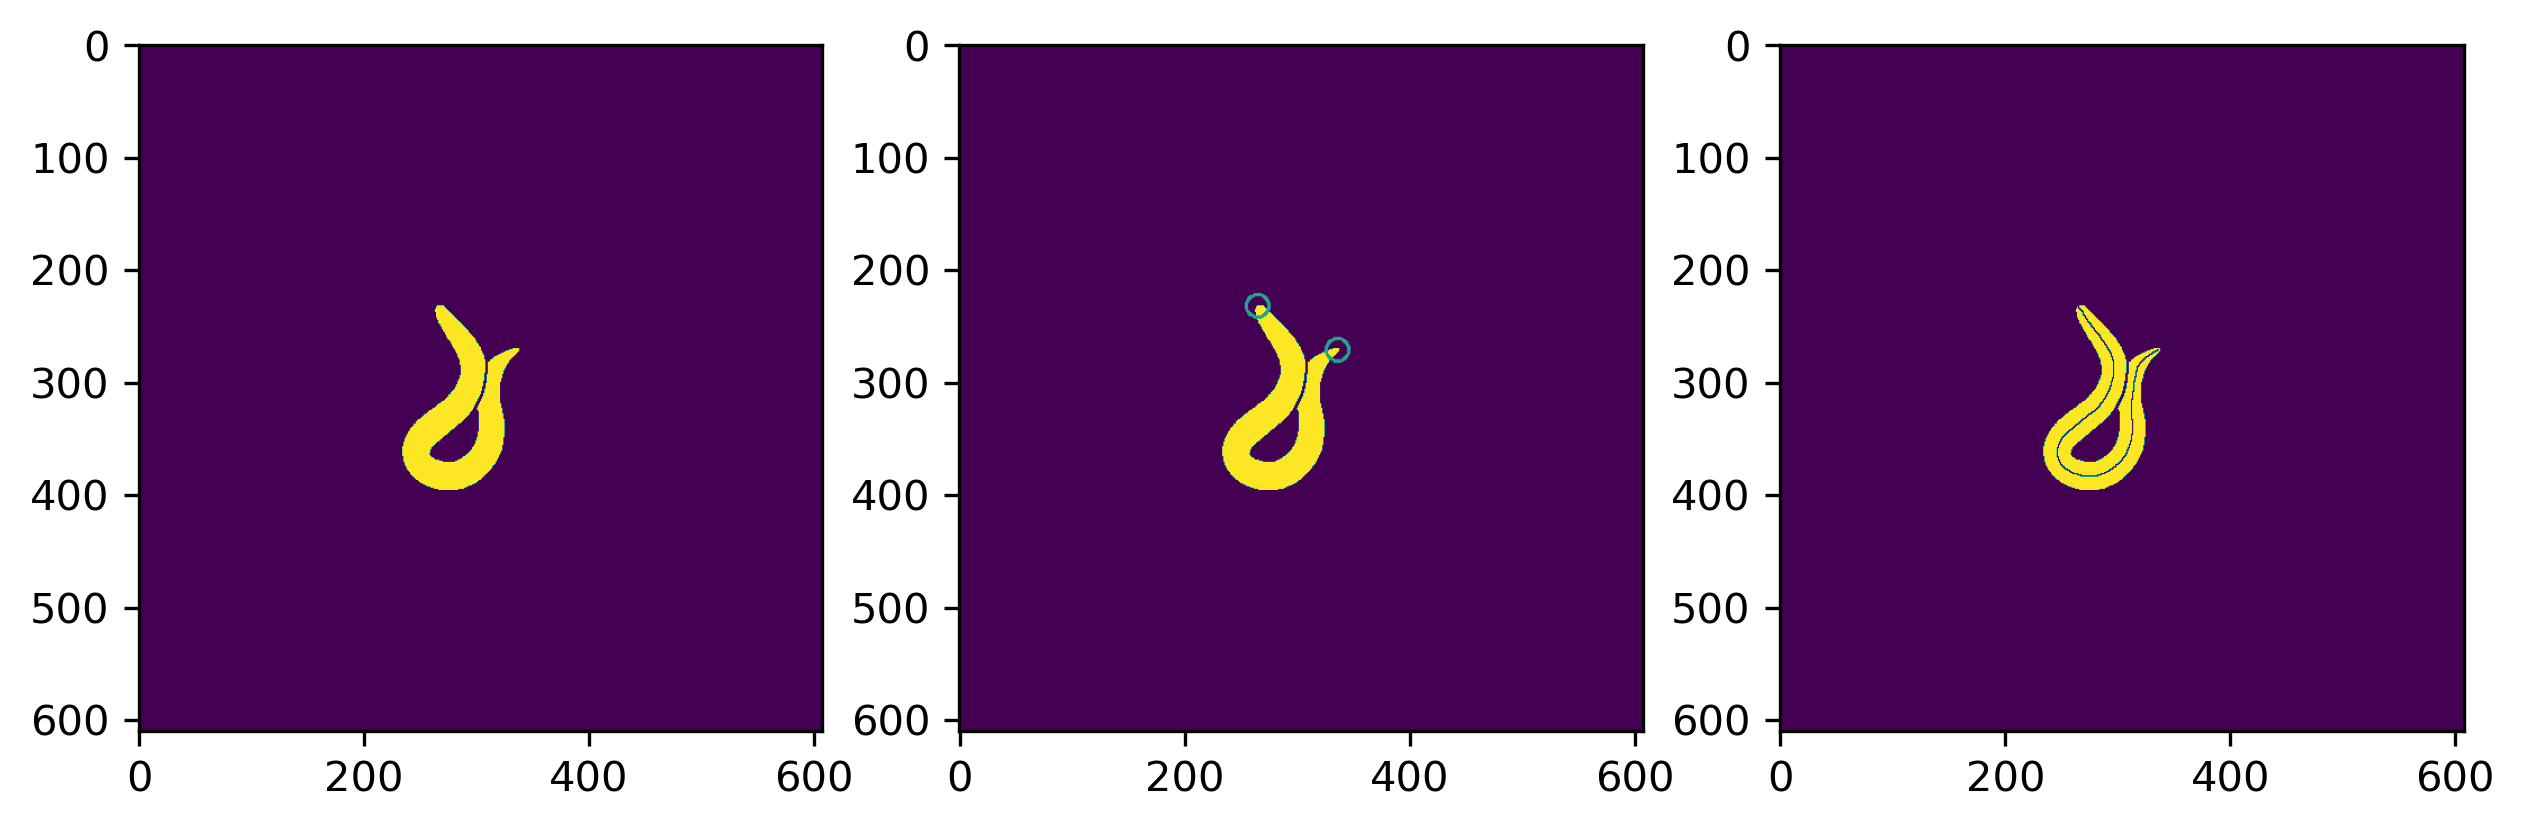

img7006.tif


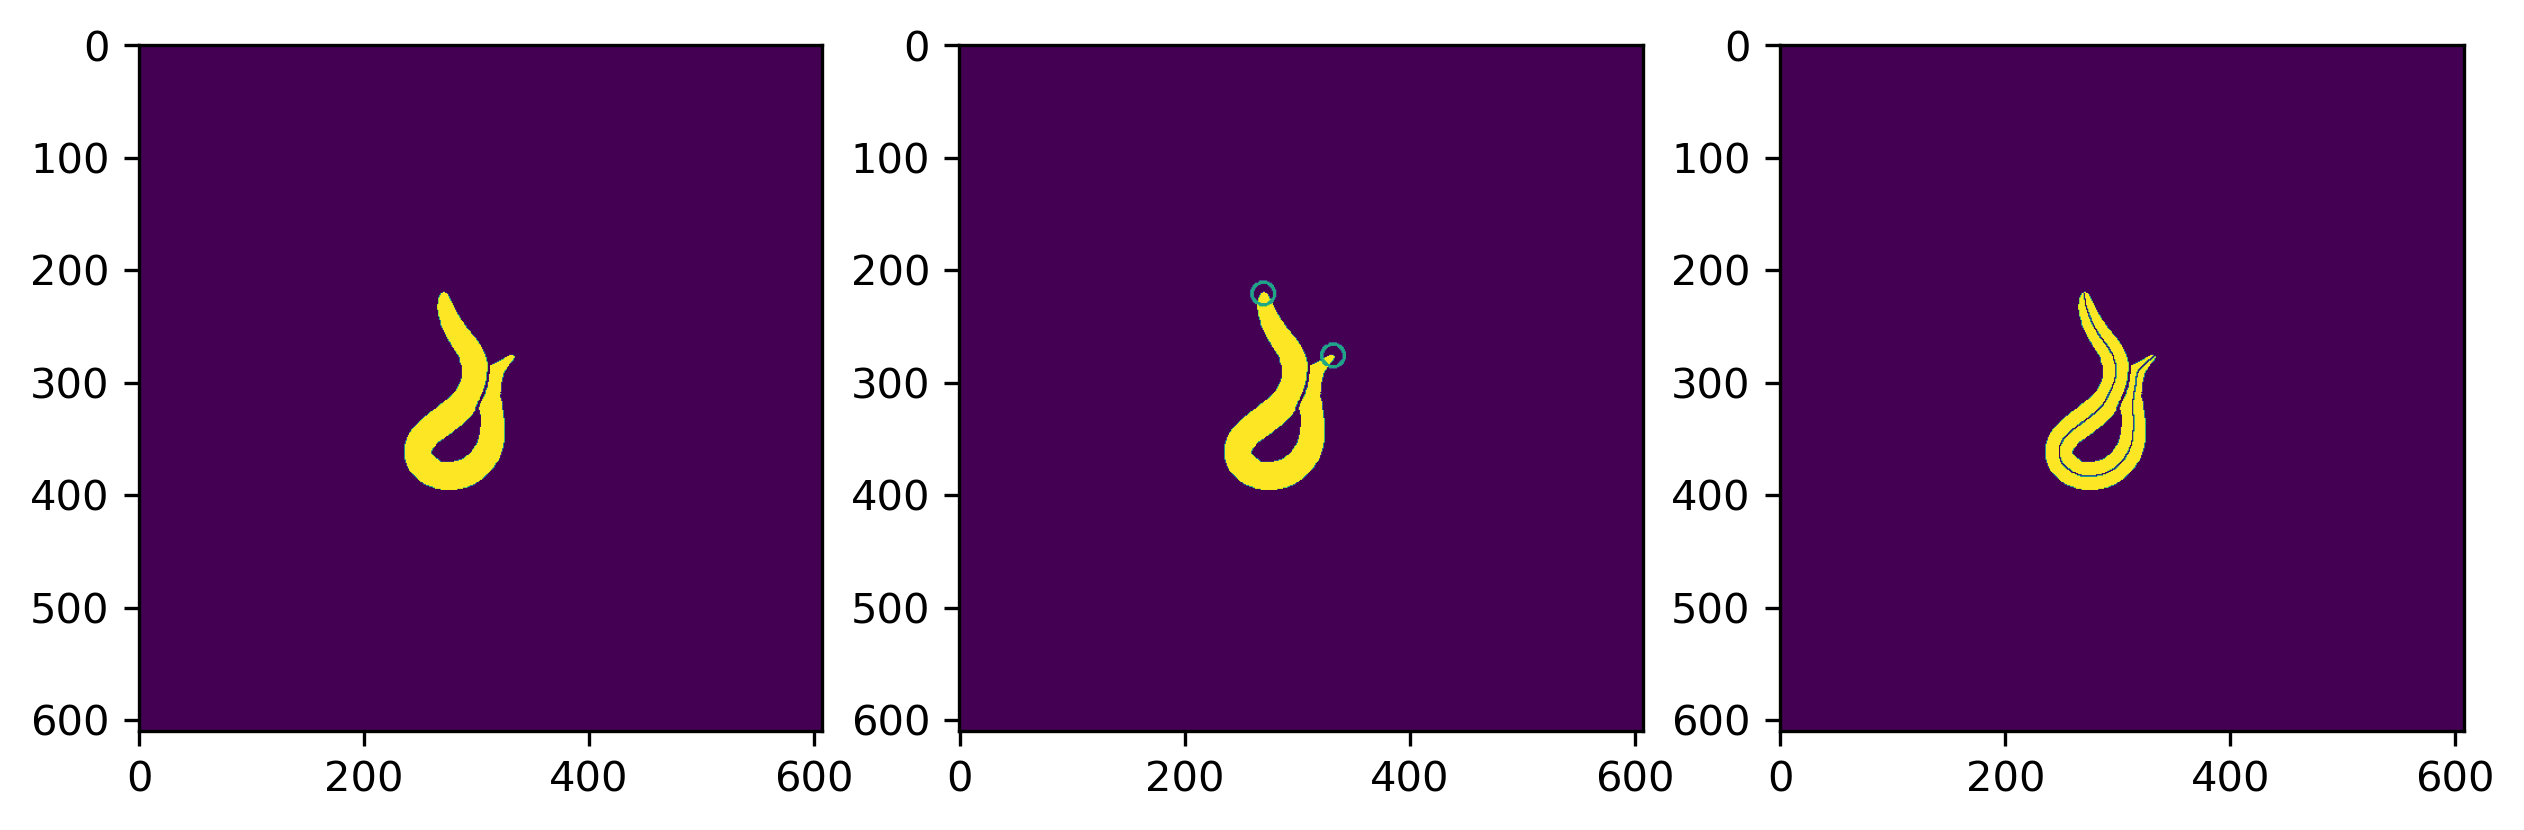

img7033.tif


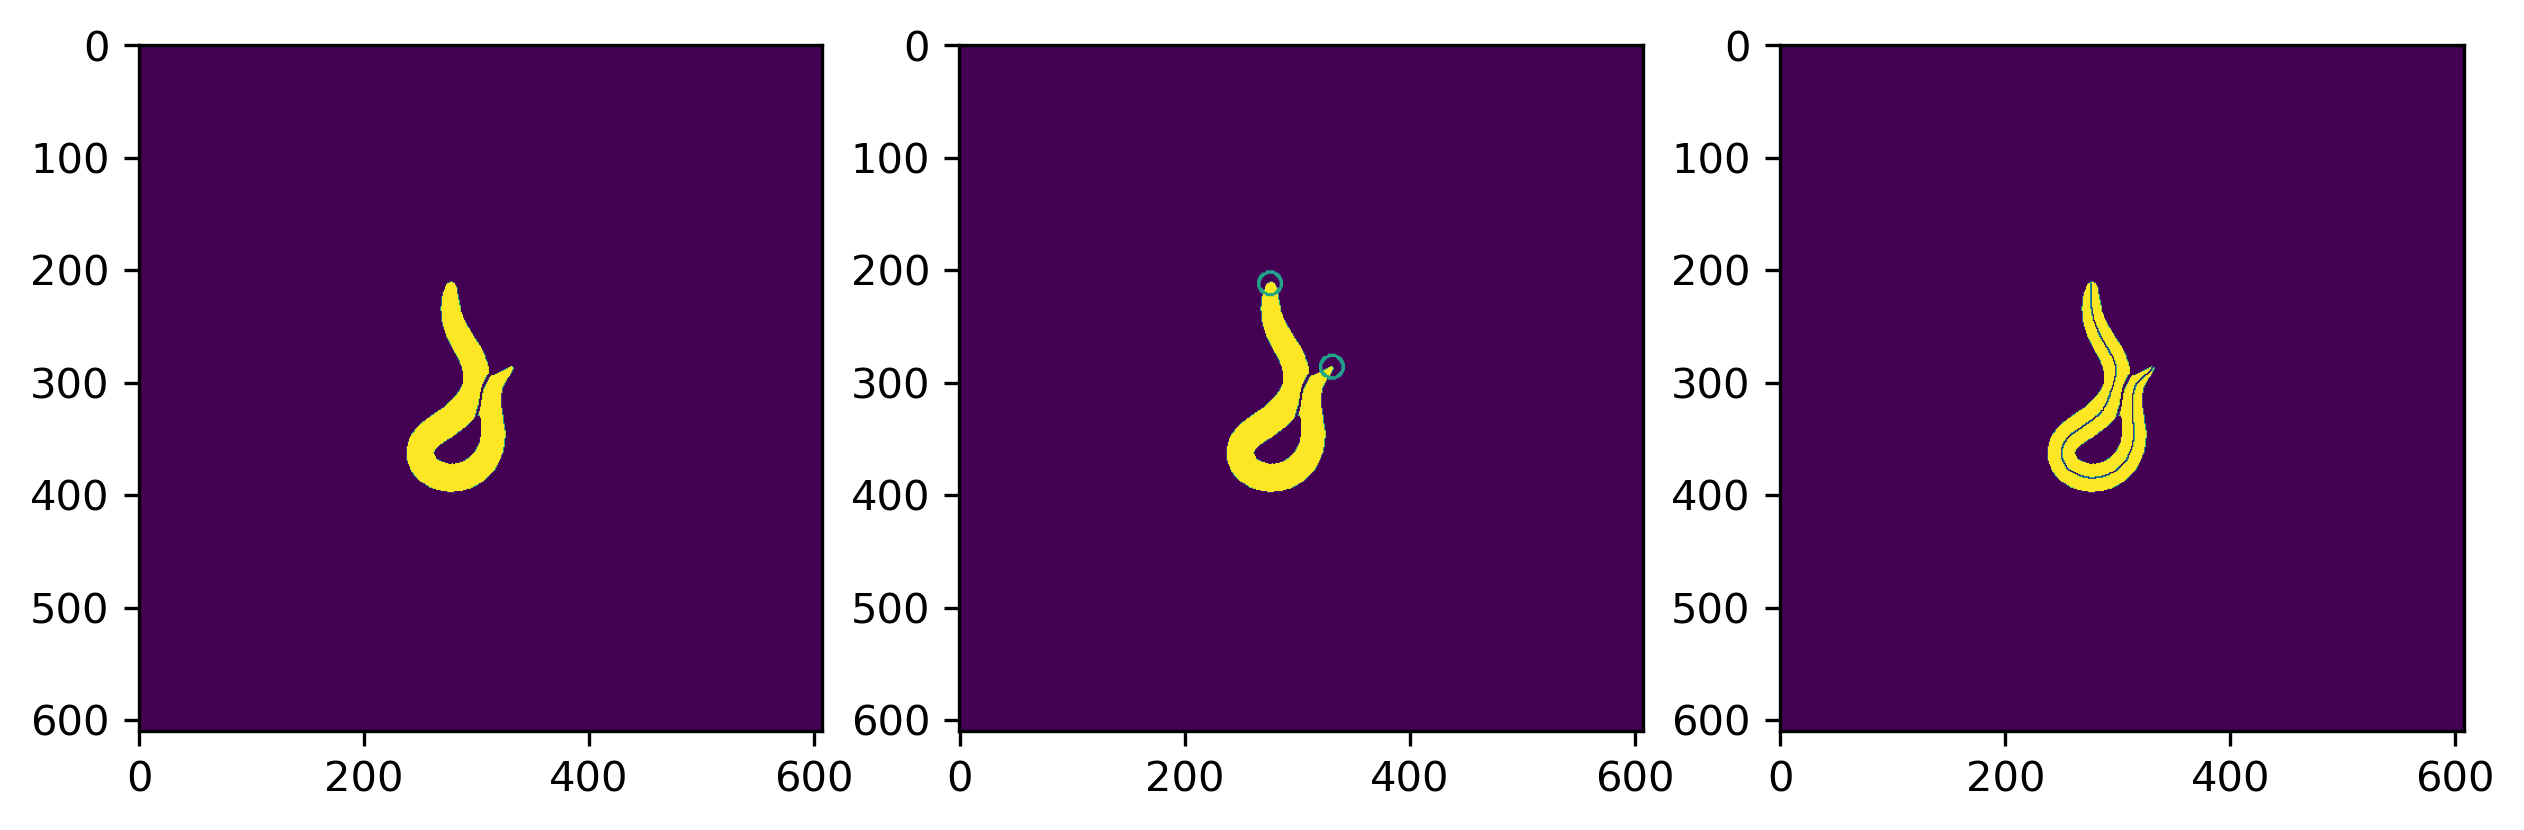

img7070.tif


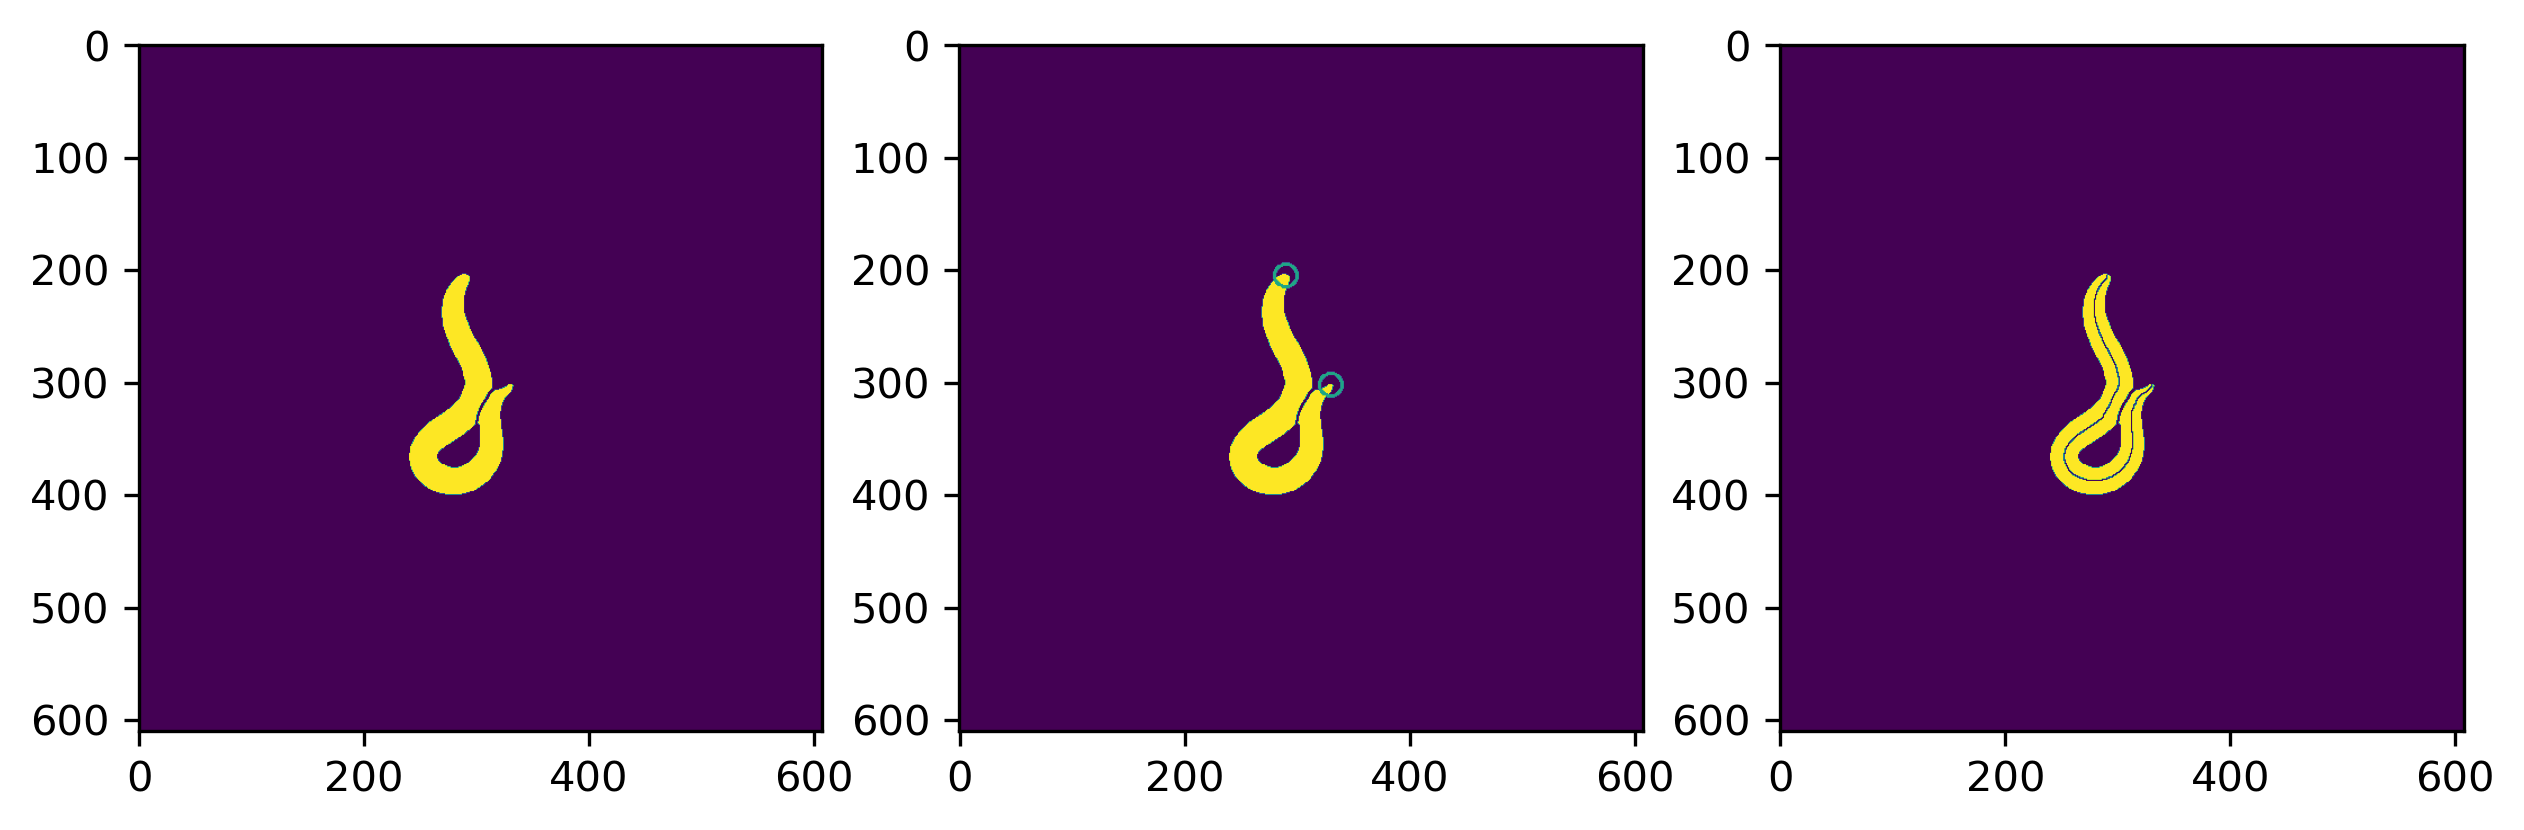

img7103.tif


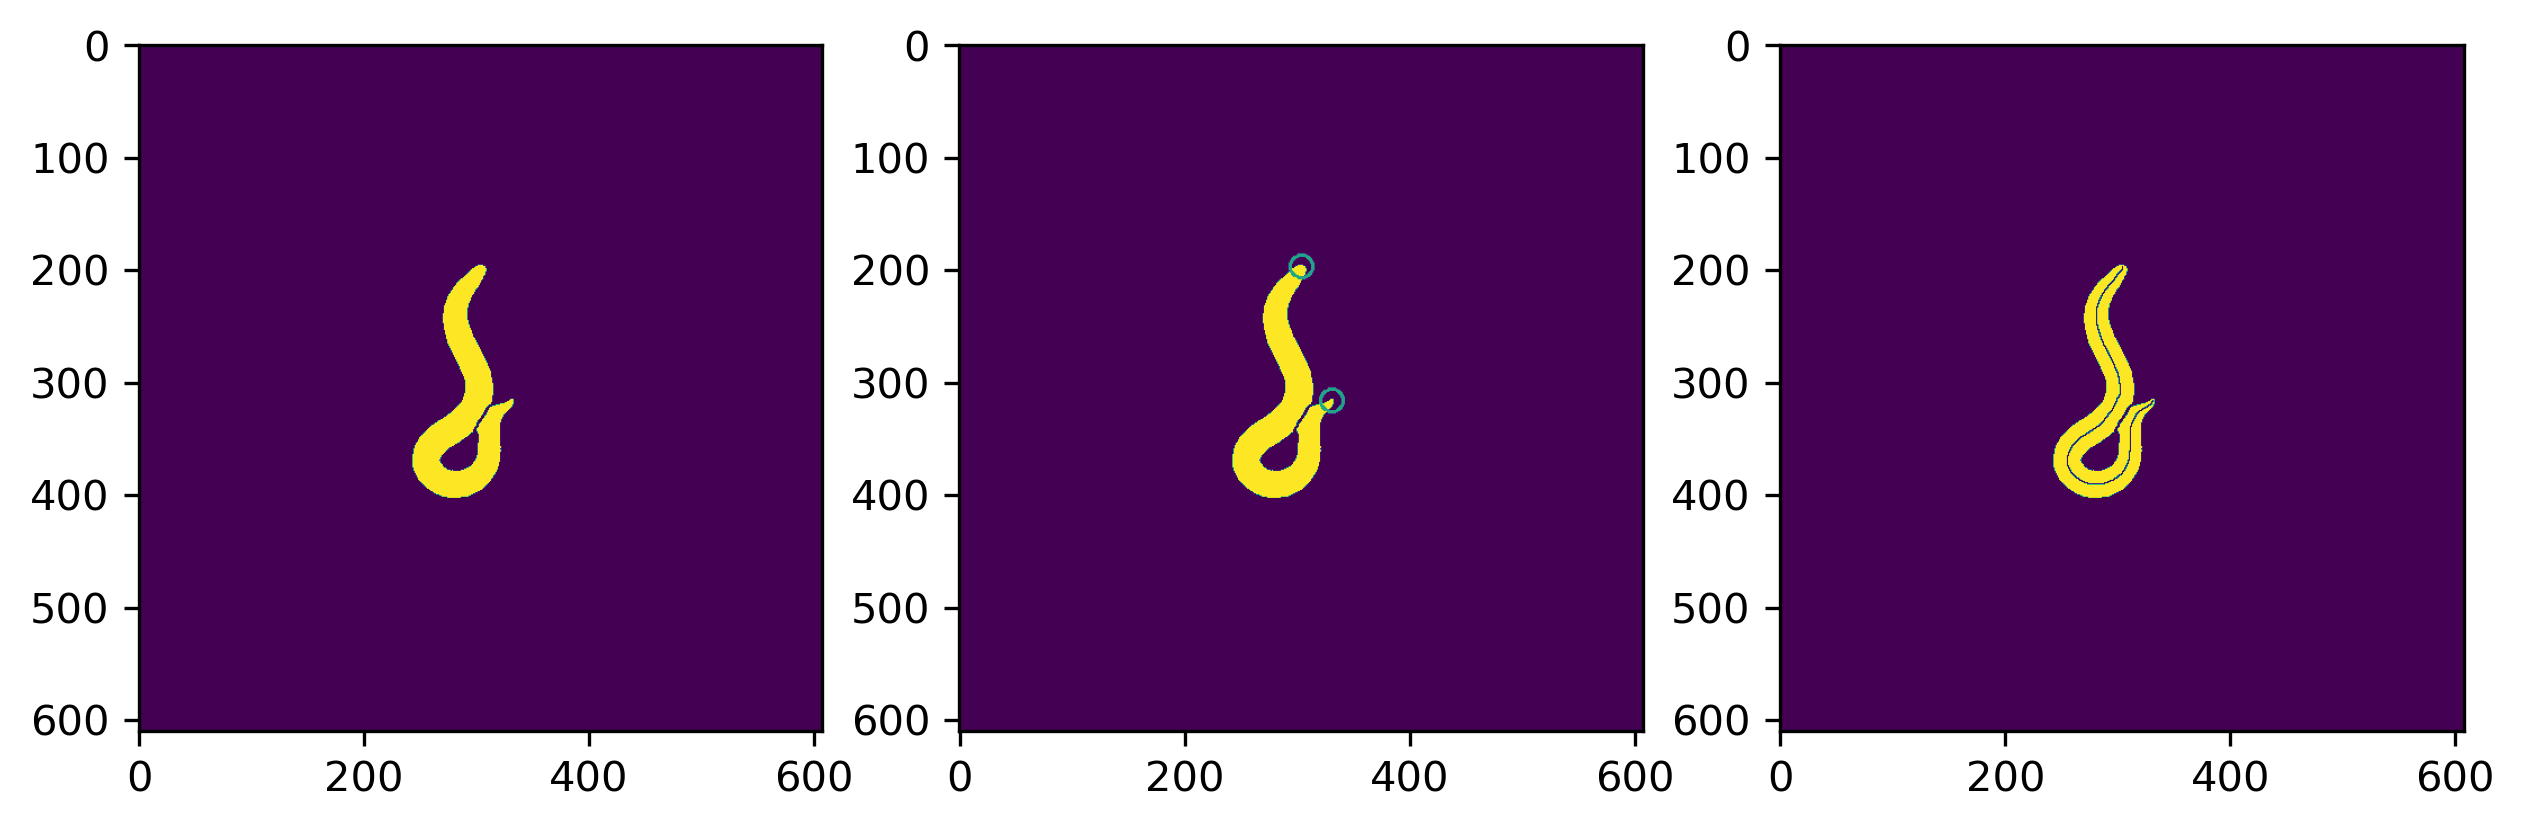

img7125.tif


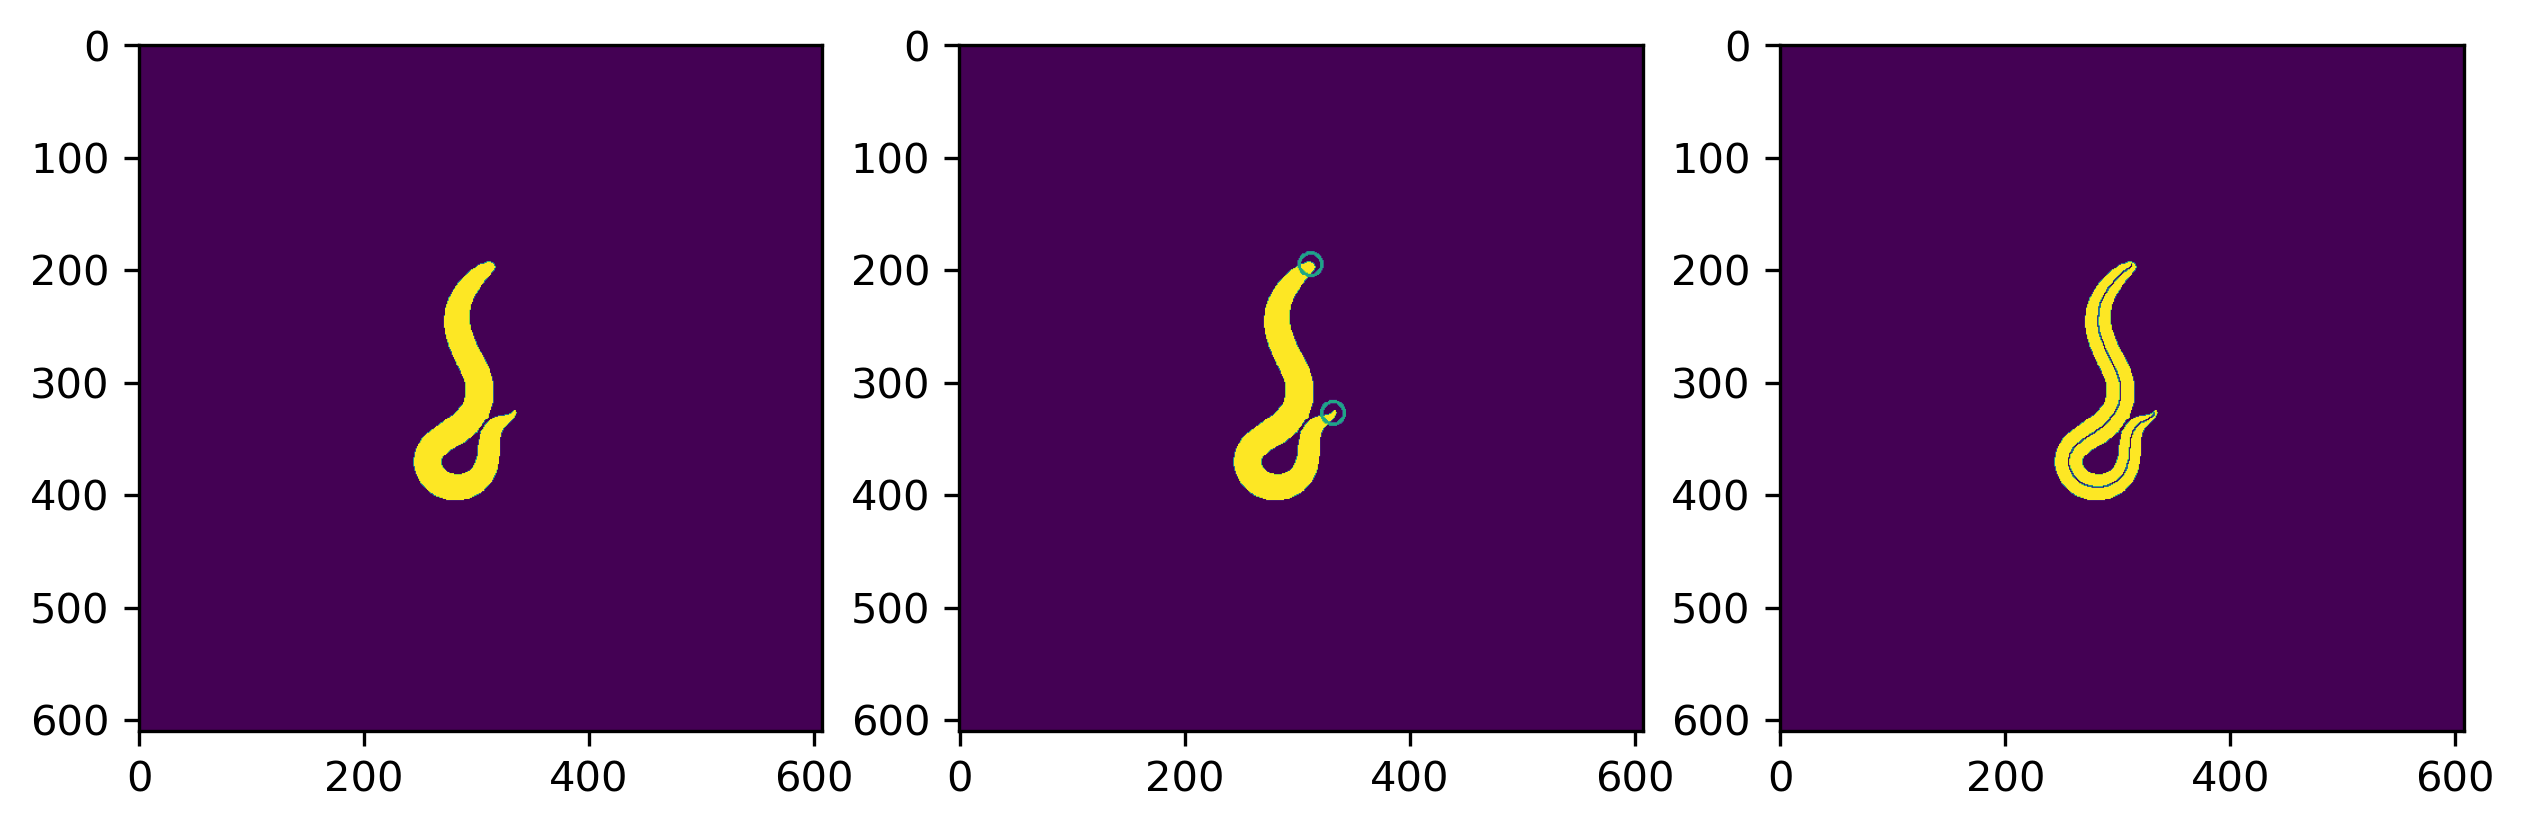

img21705.tif


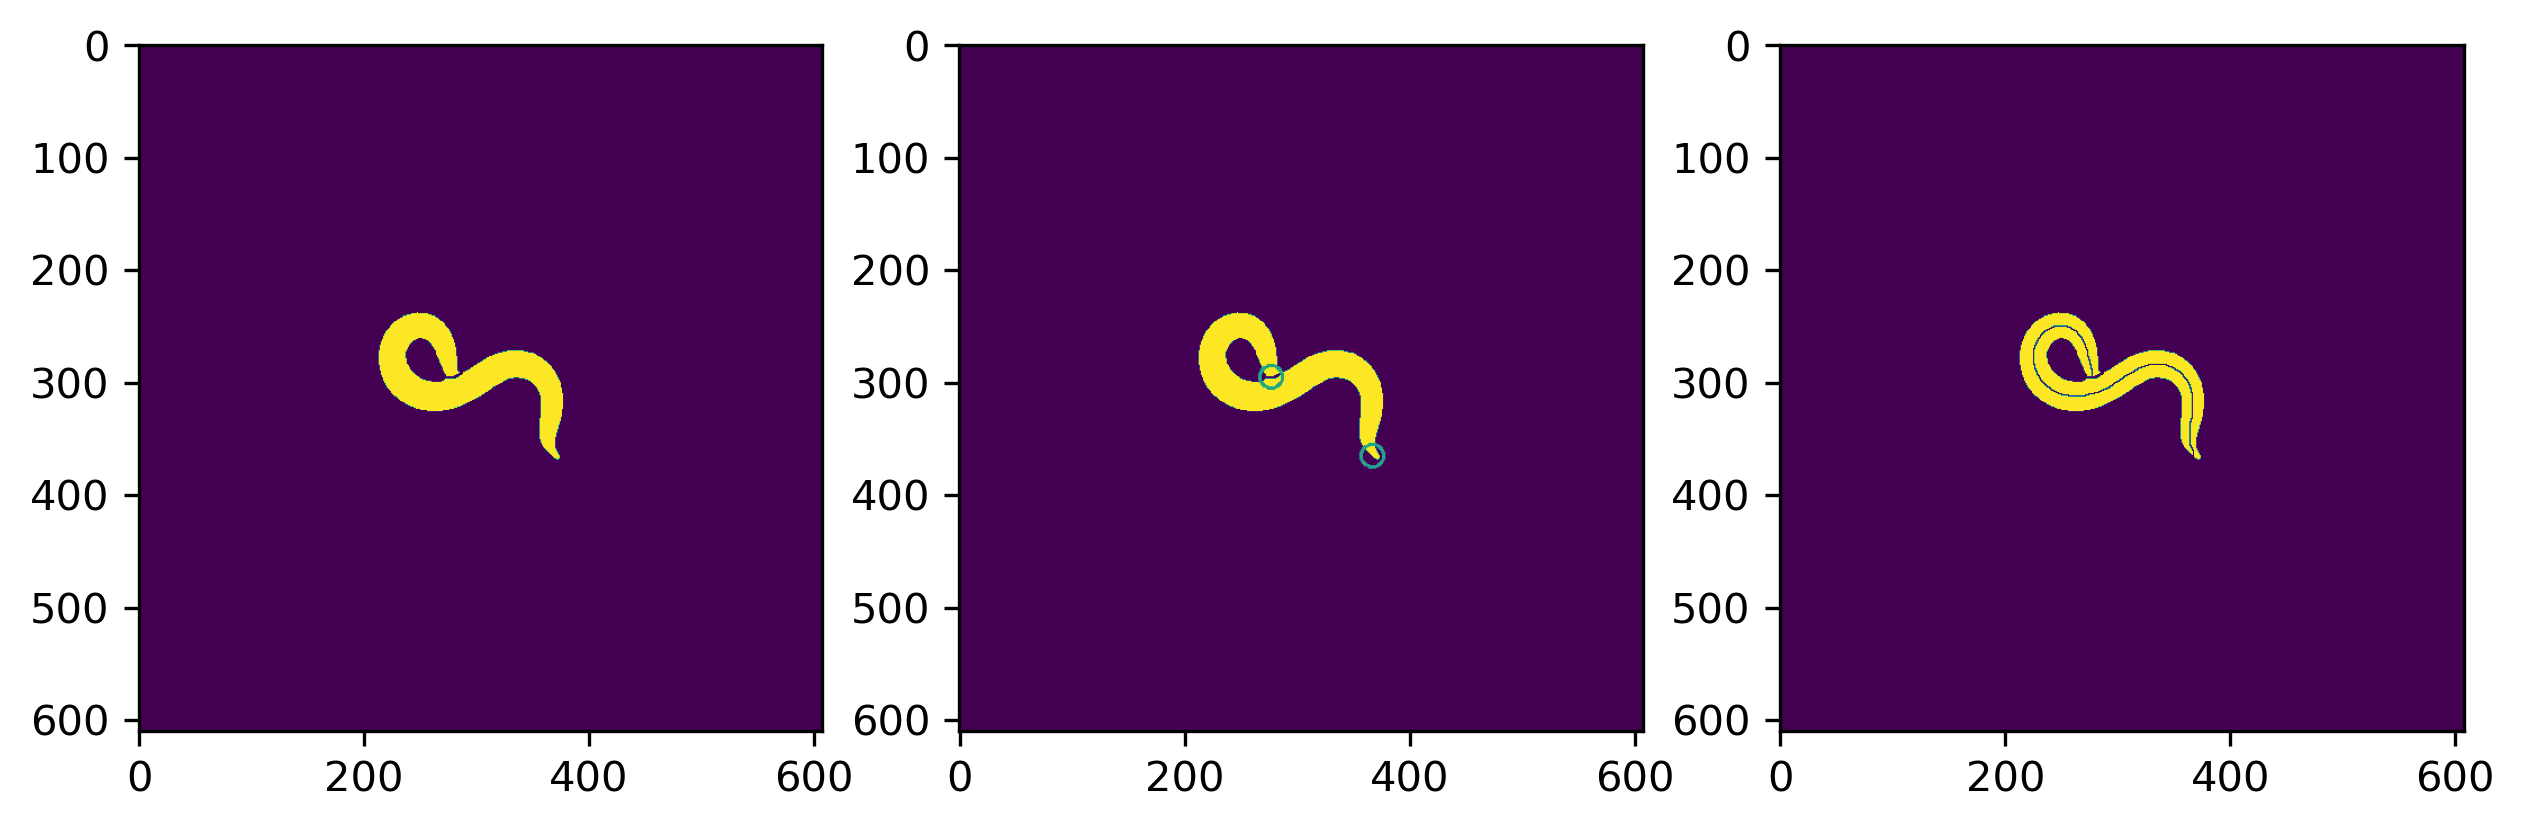

img21745.tif


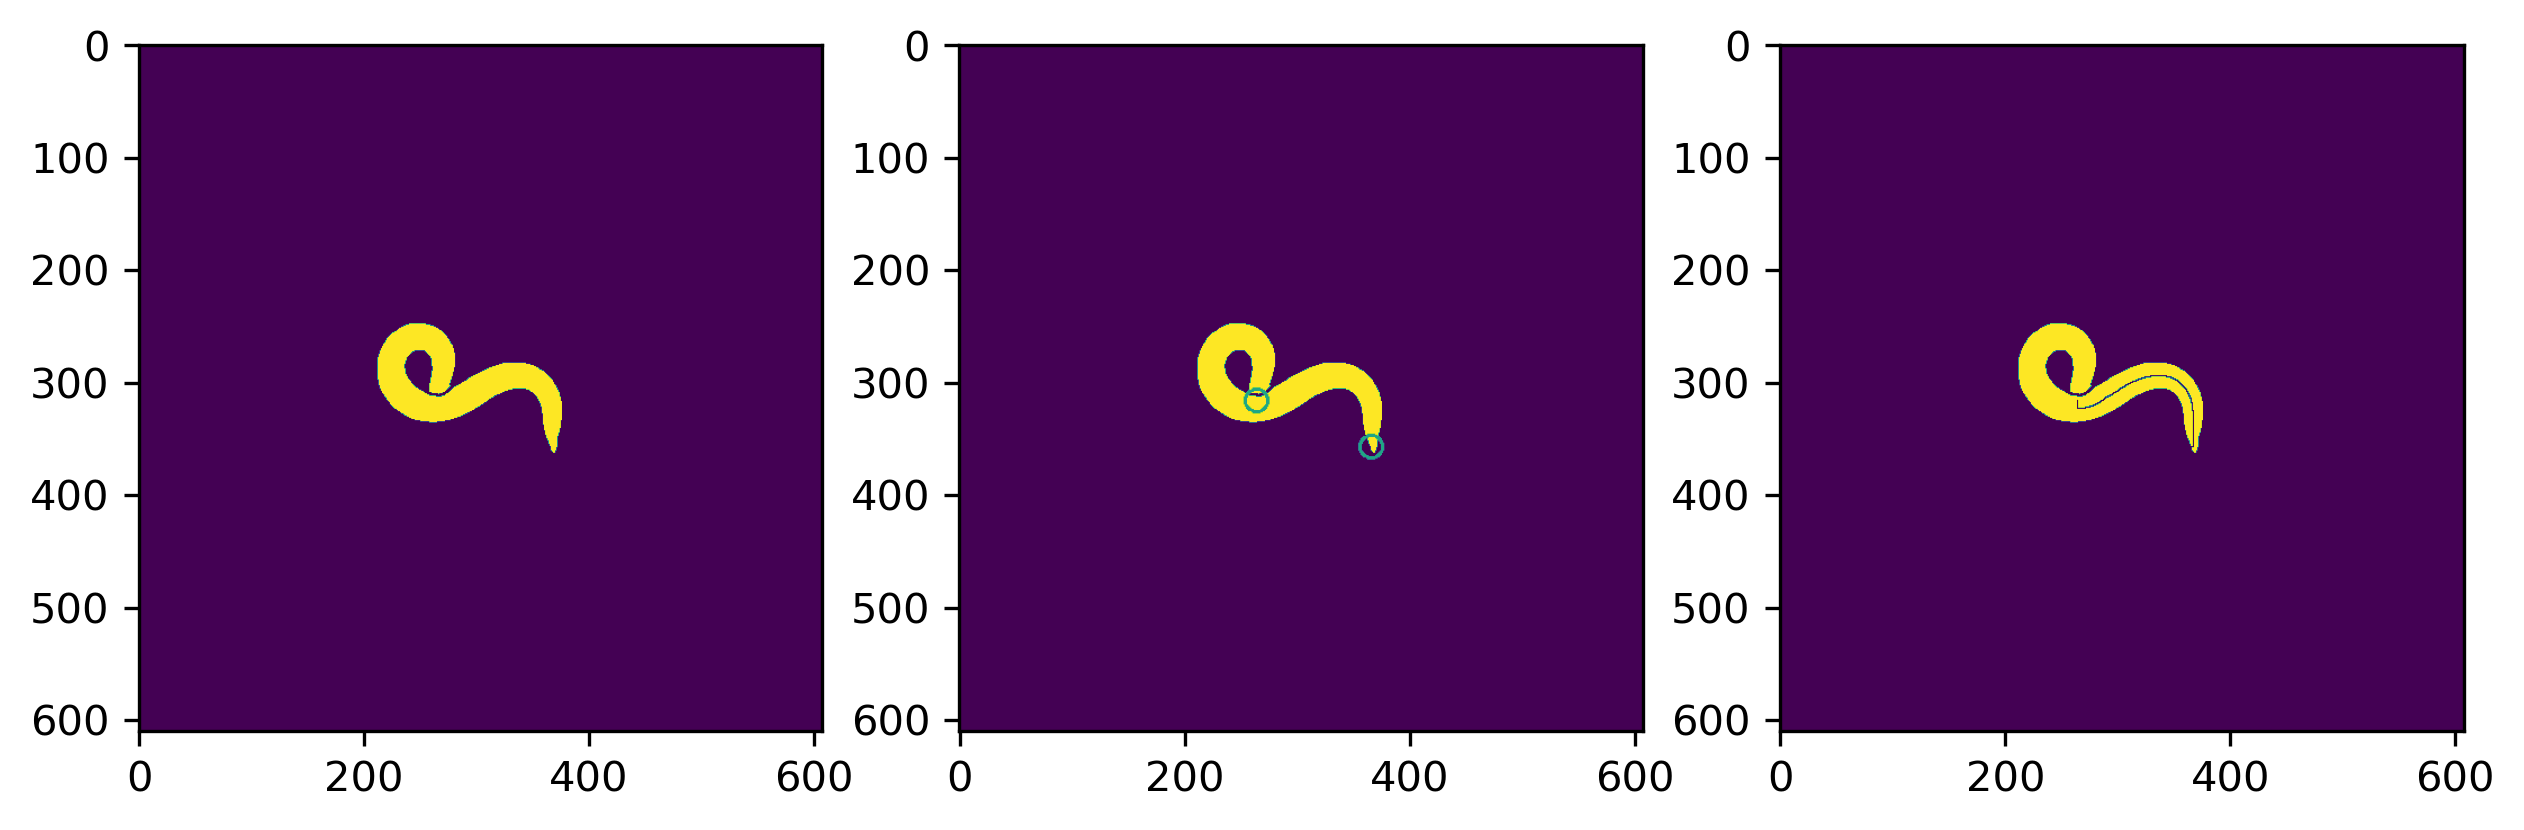

img21775.tif


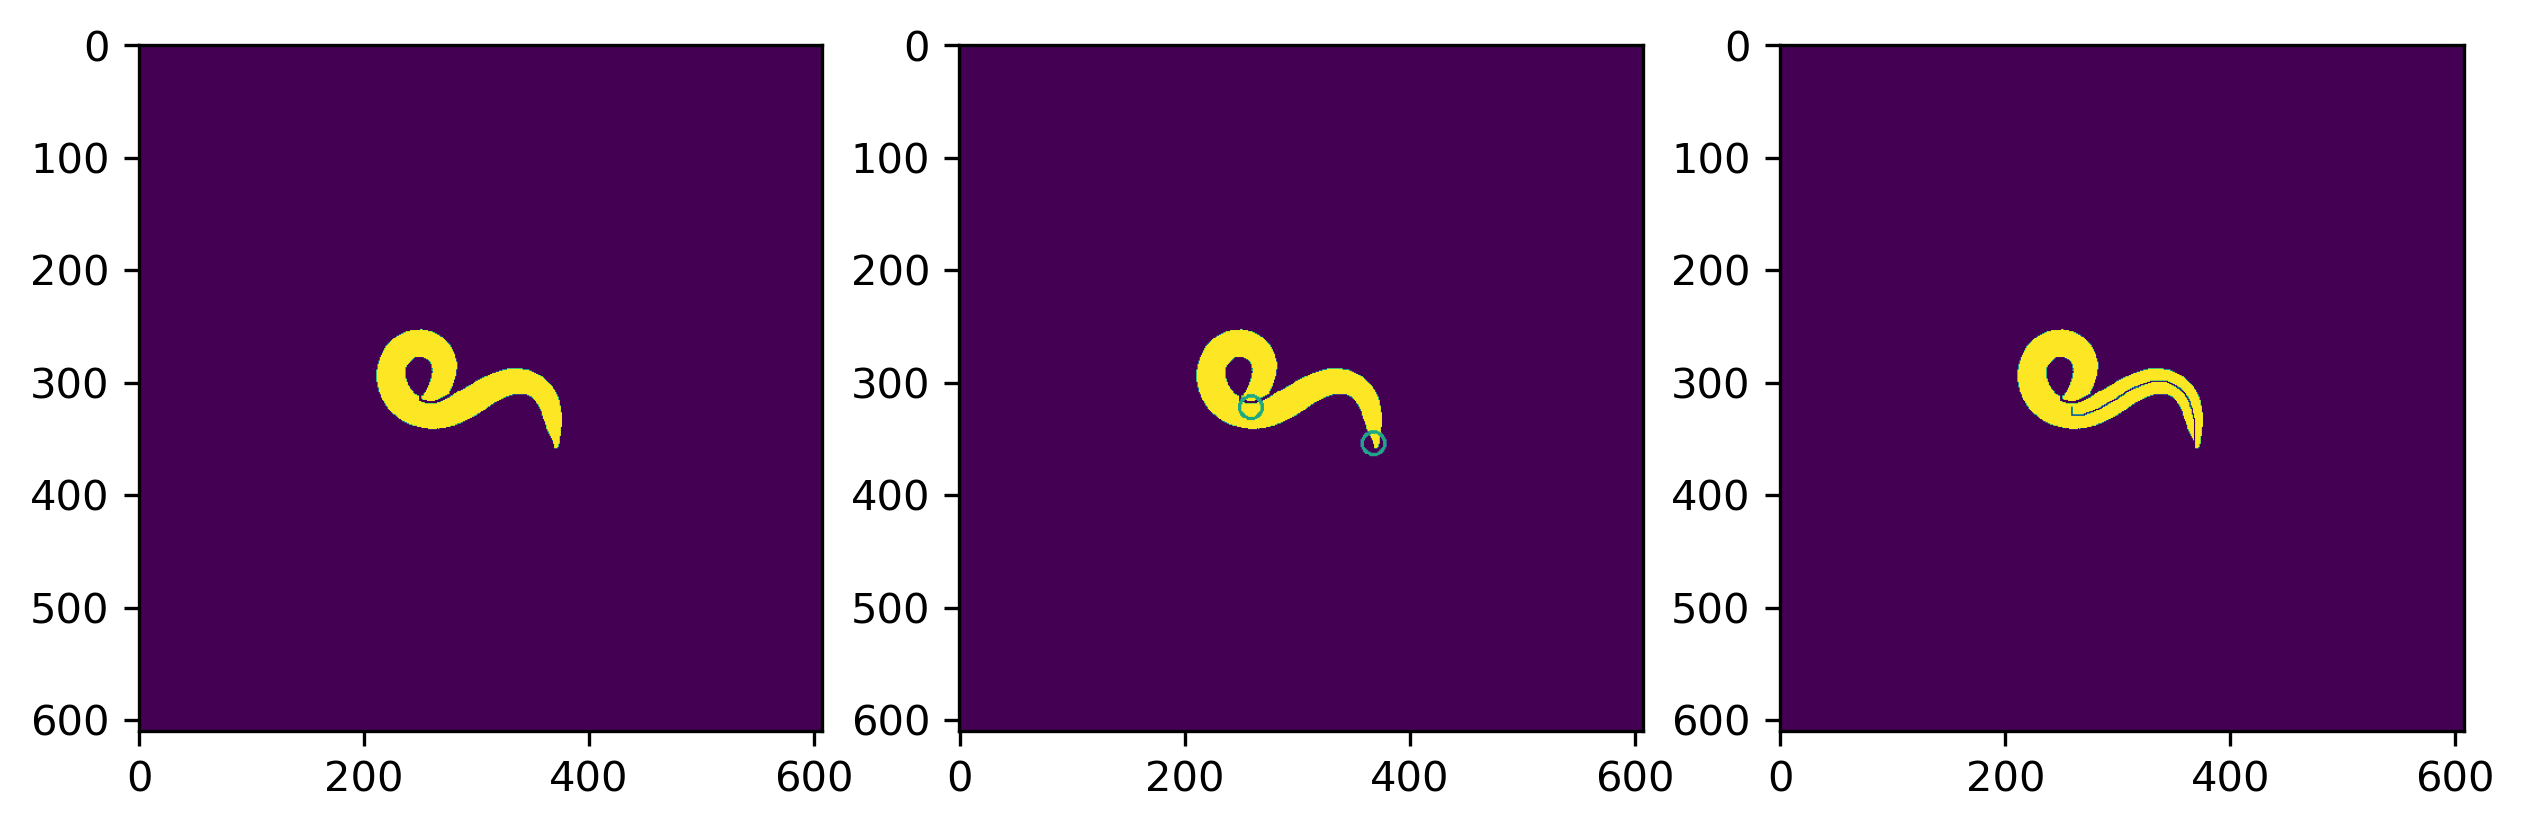

img21805.tif


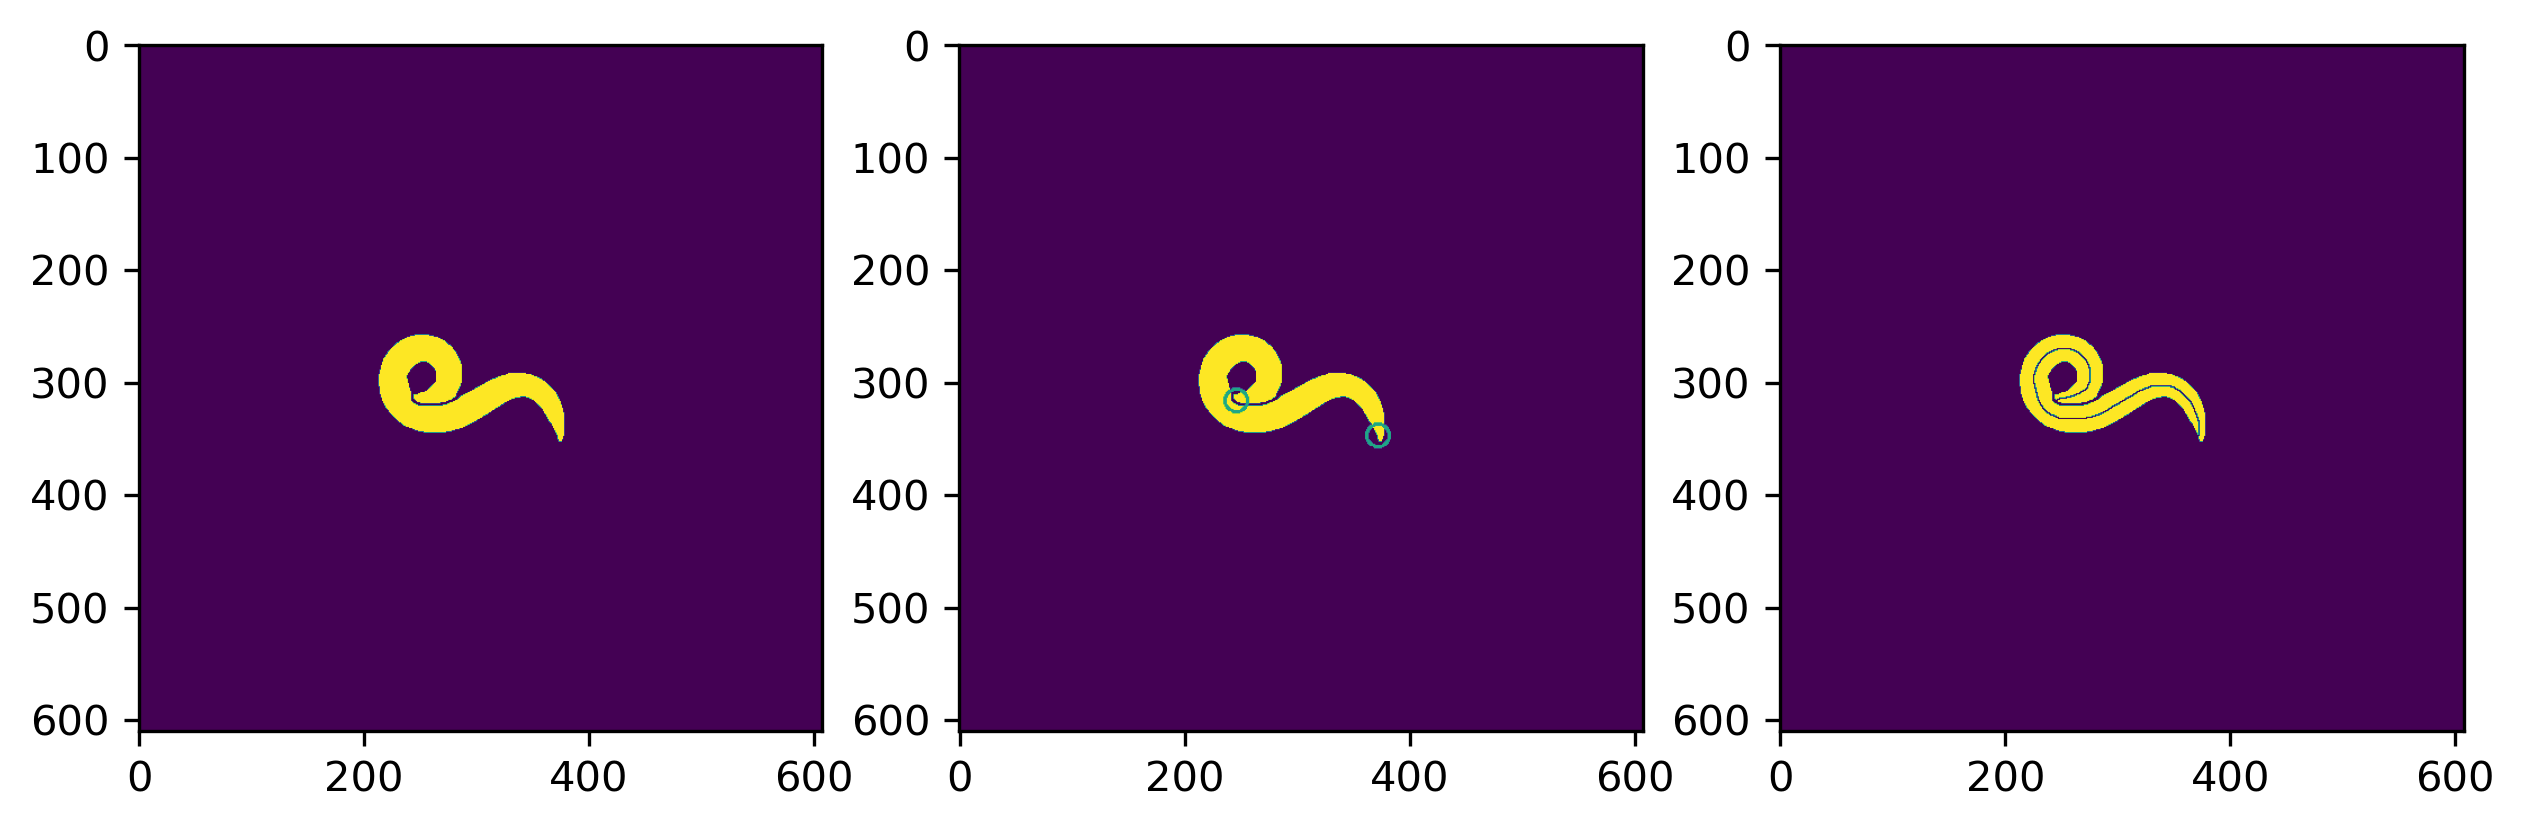

img21834.tif


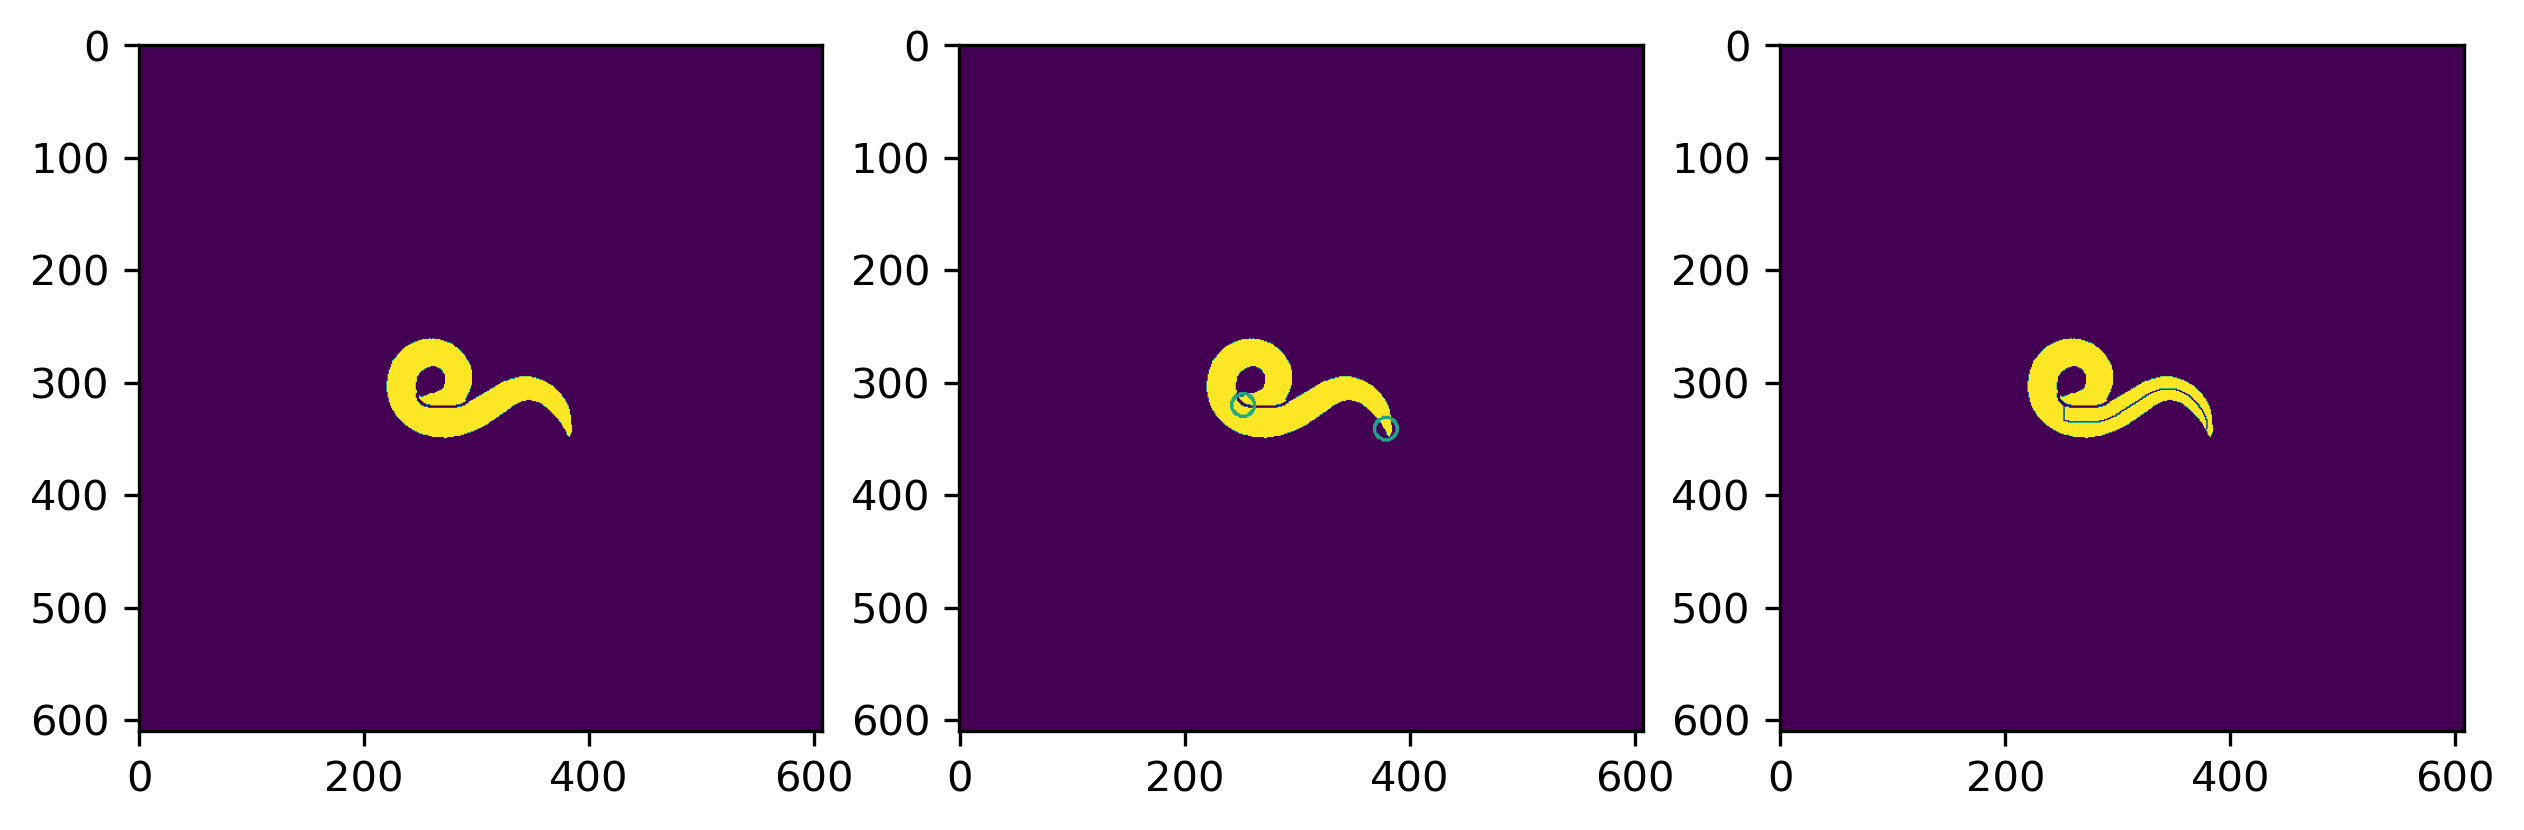

img21901.tif


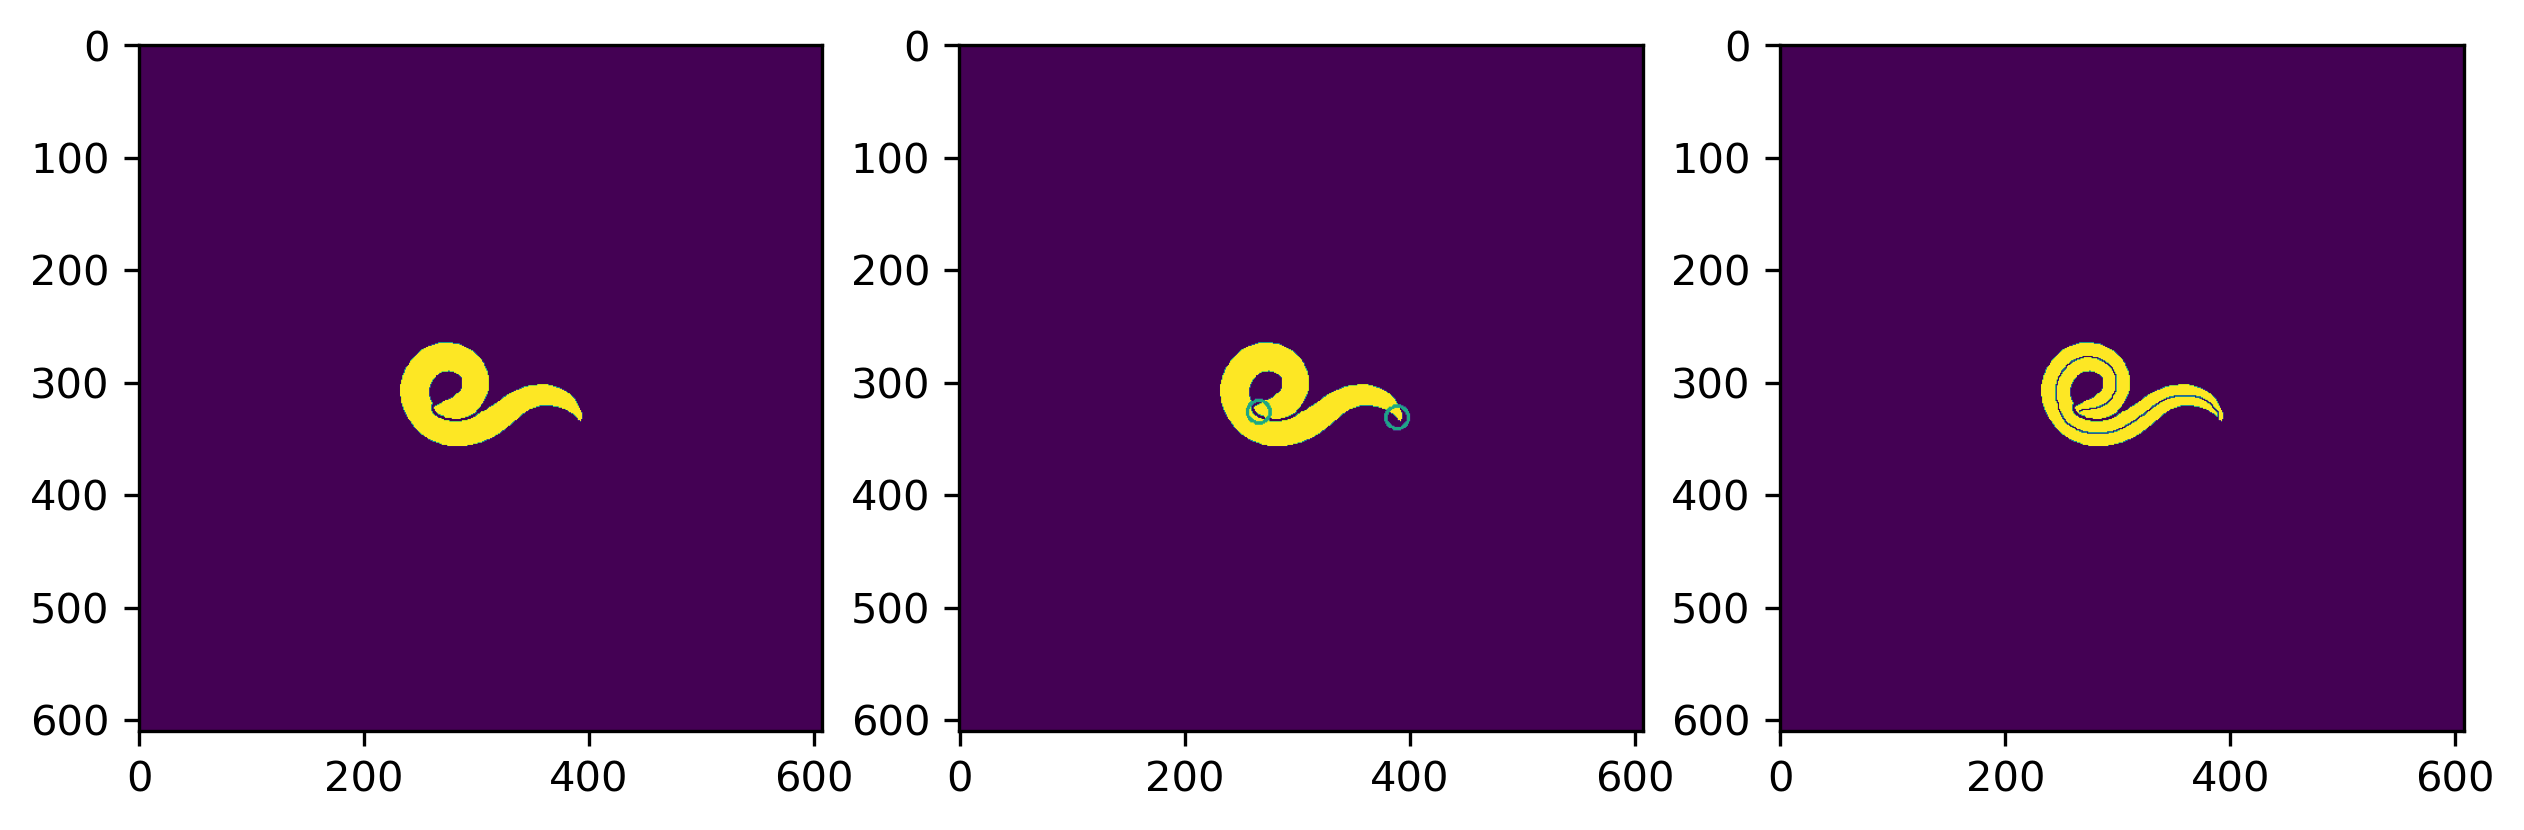

img21944.tif


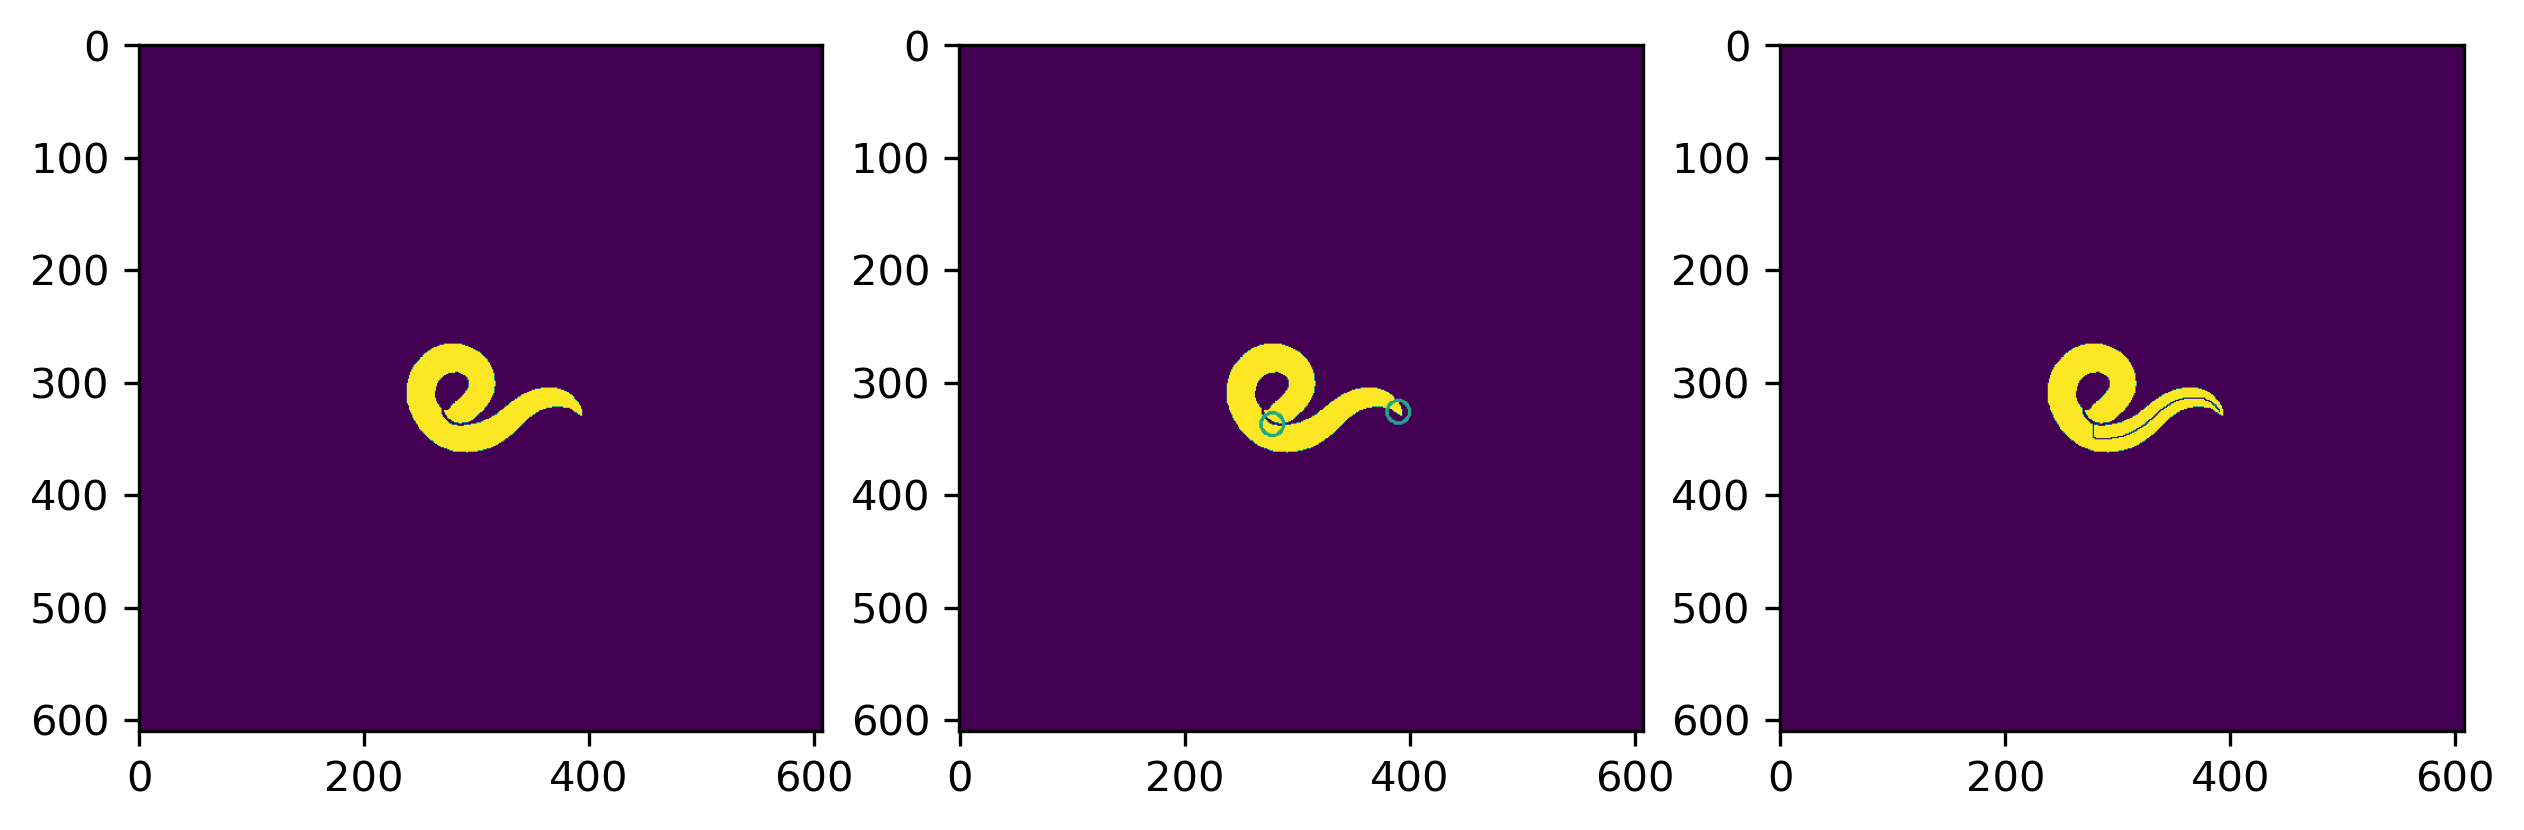

img21966.tif


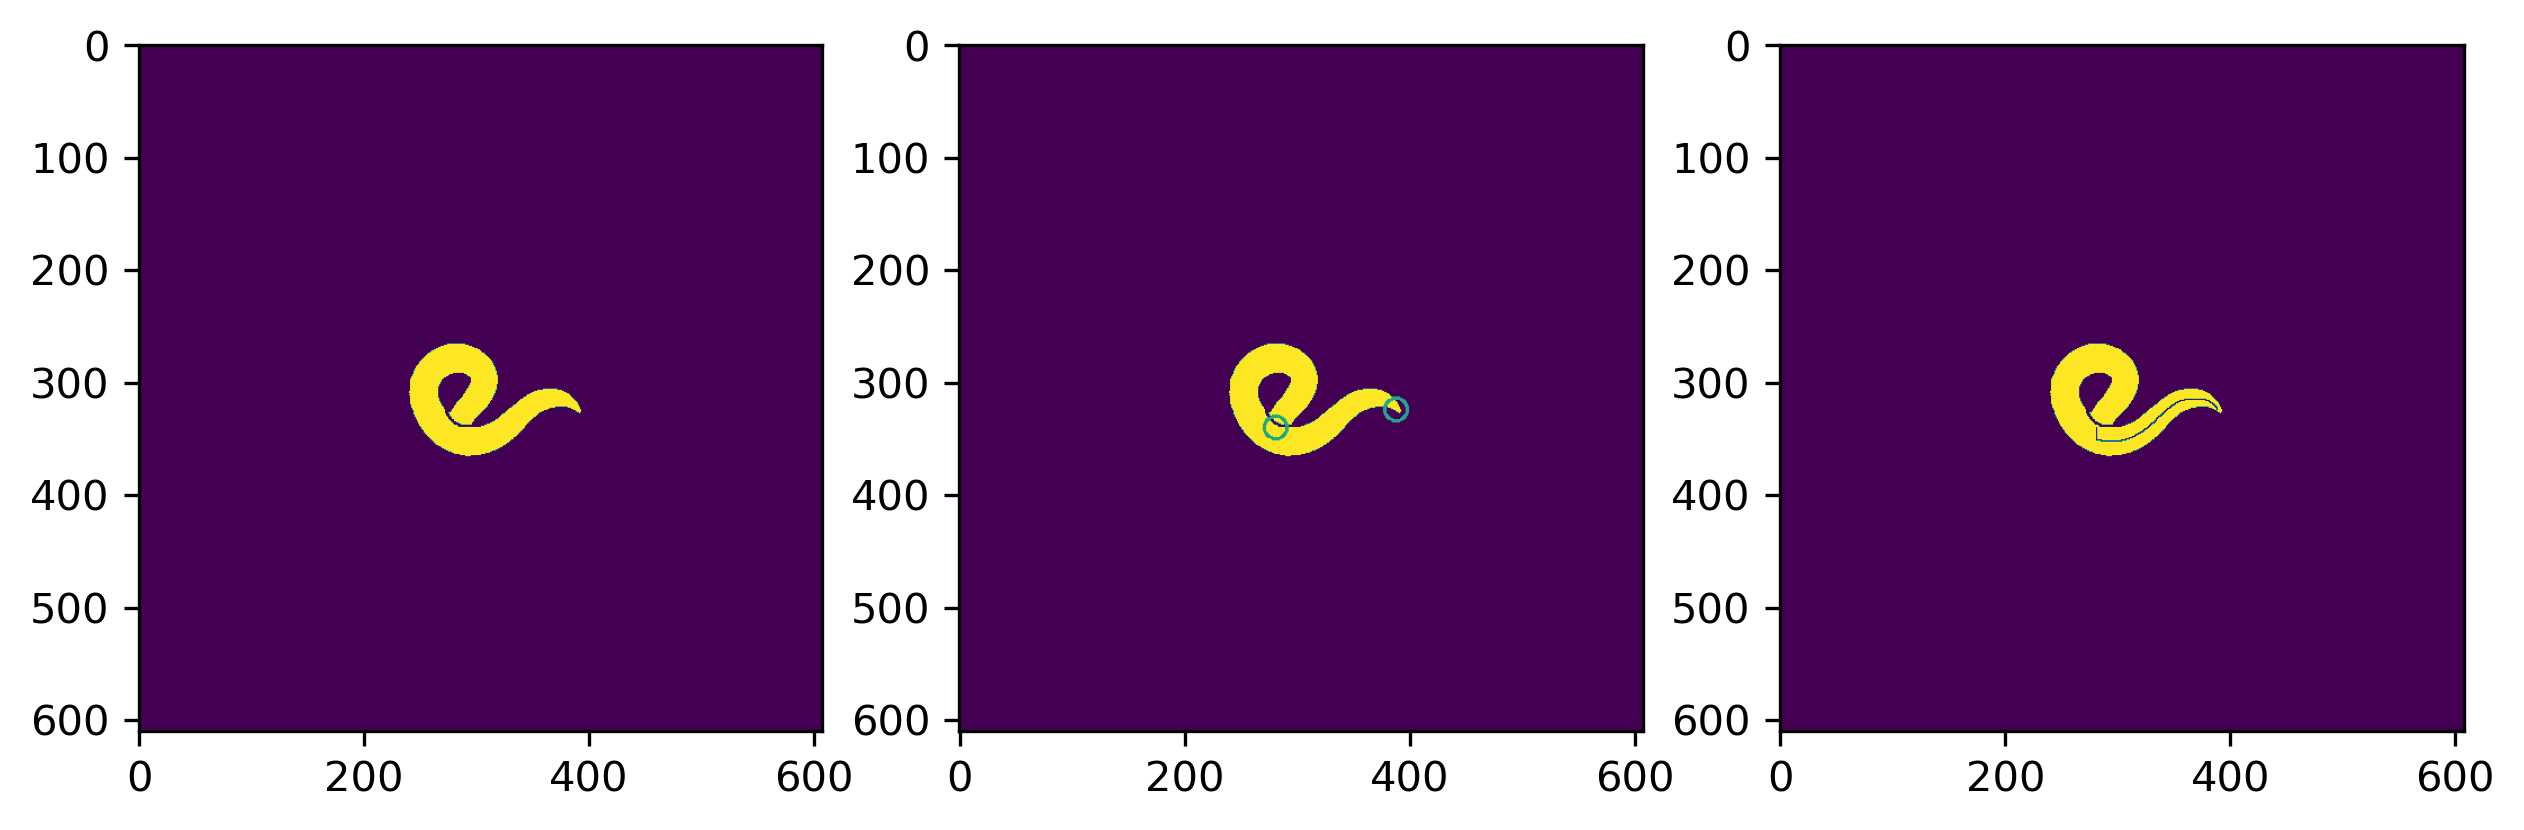

img21974.tif


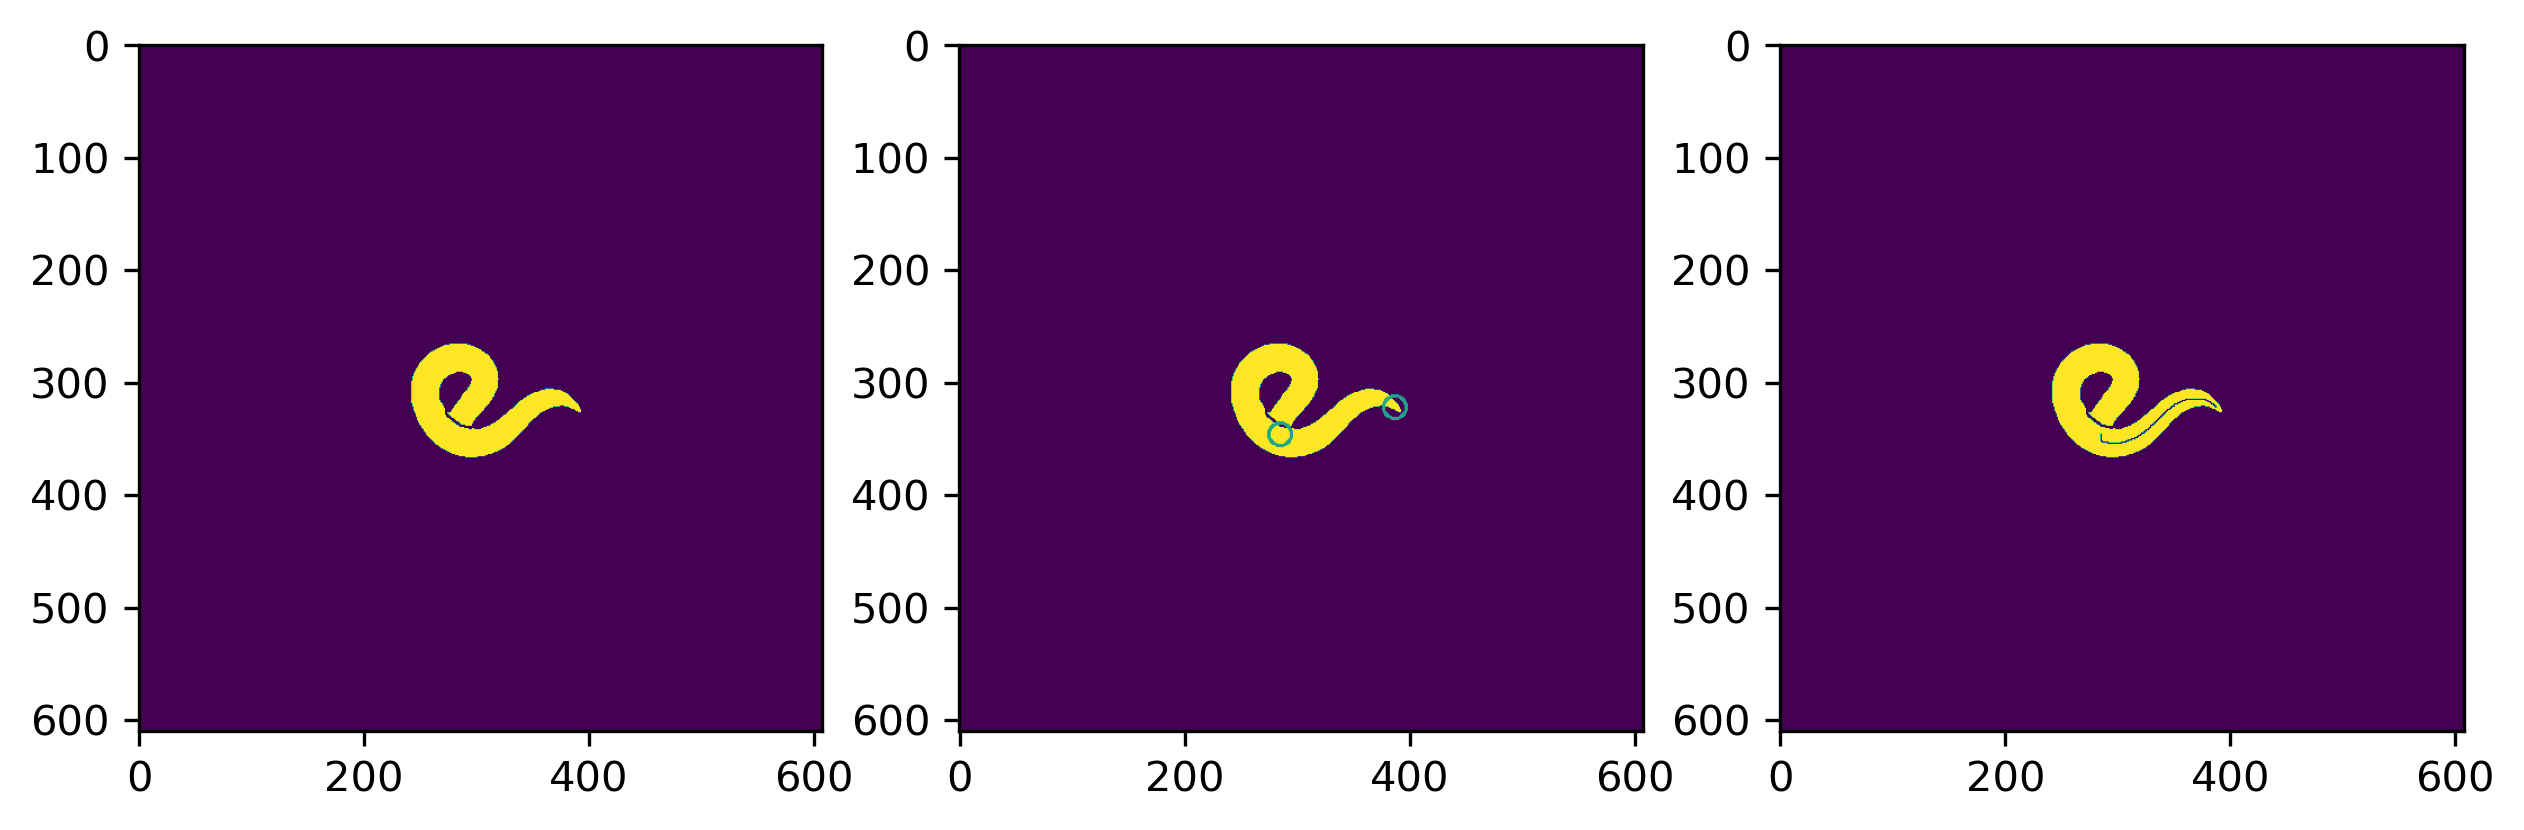

img22015.tif
head and tail were too close, no centerline could be created
img22029.tif


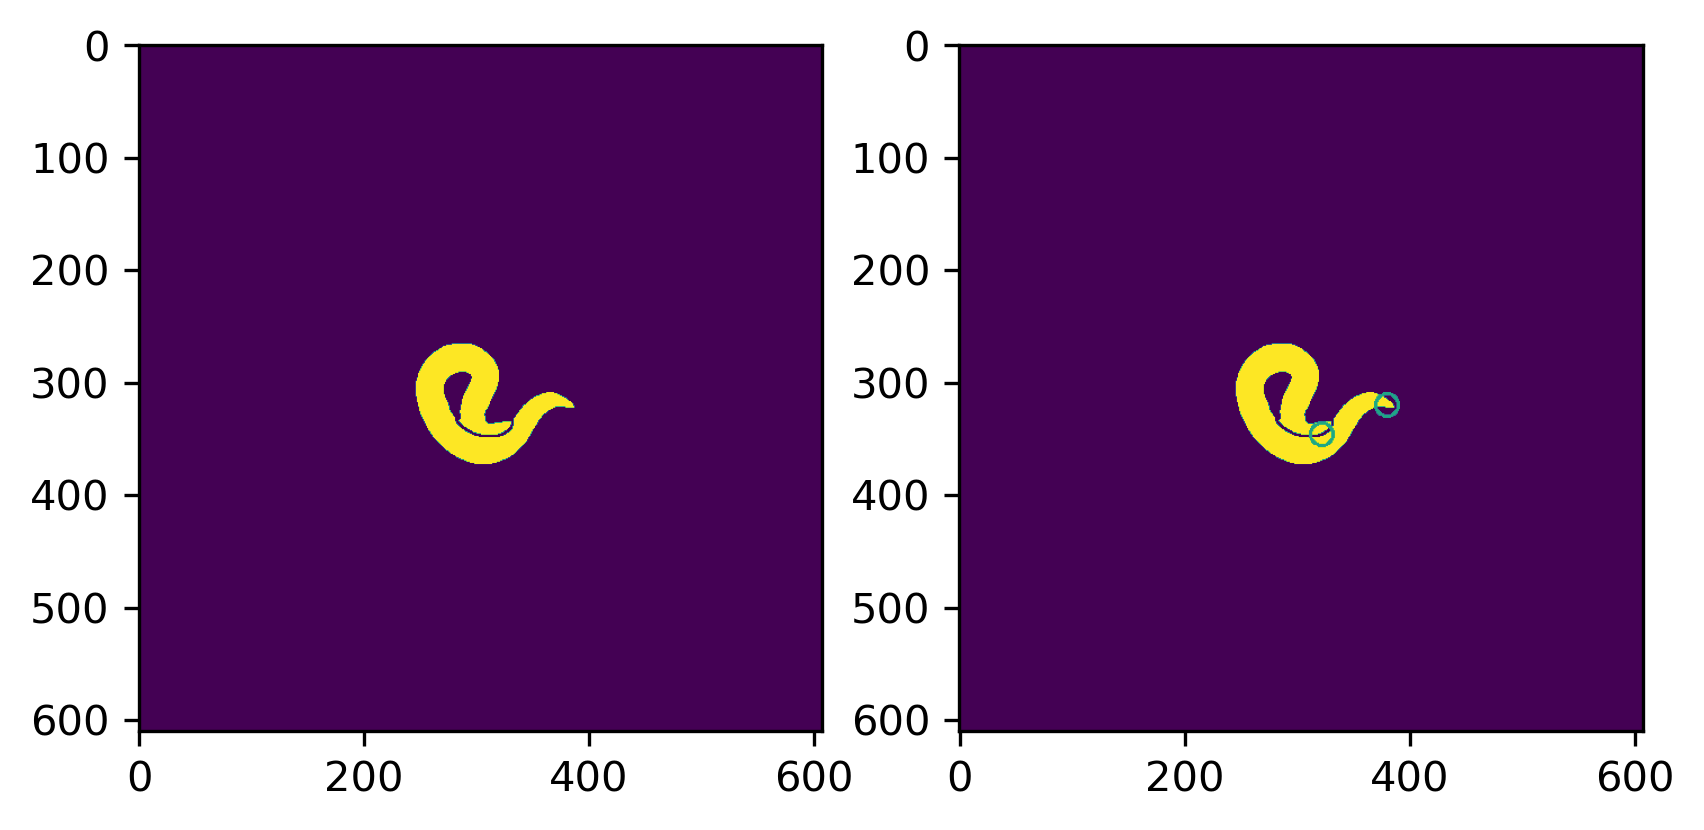

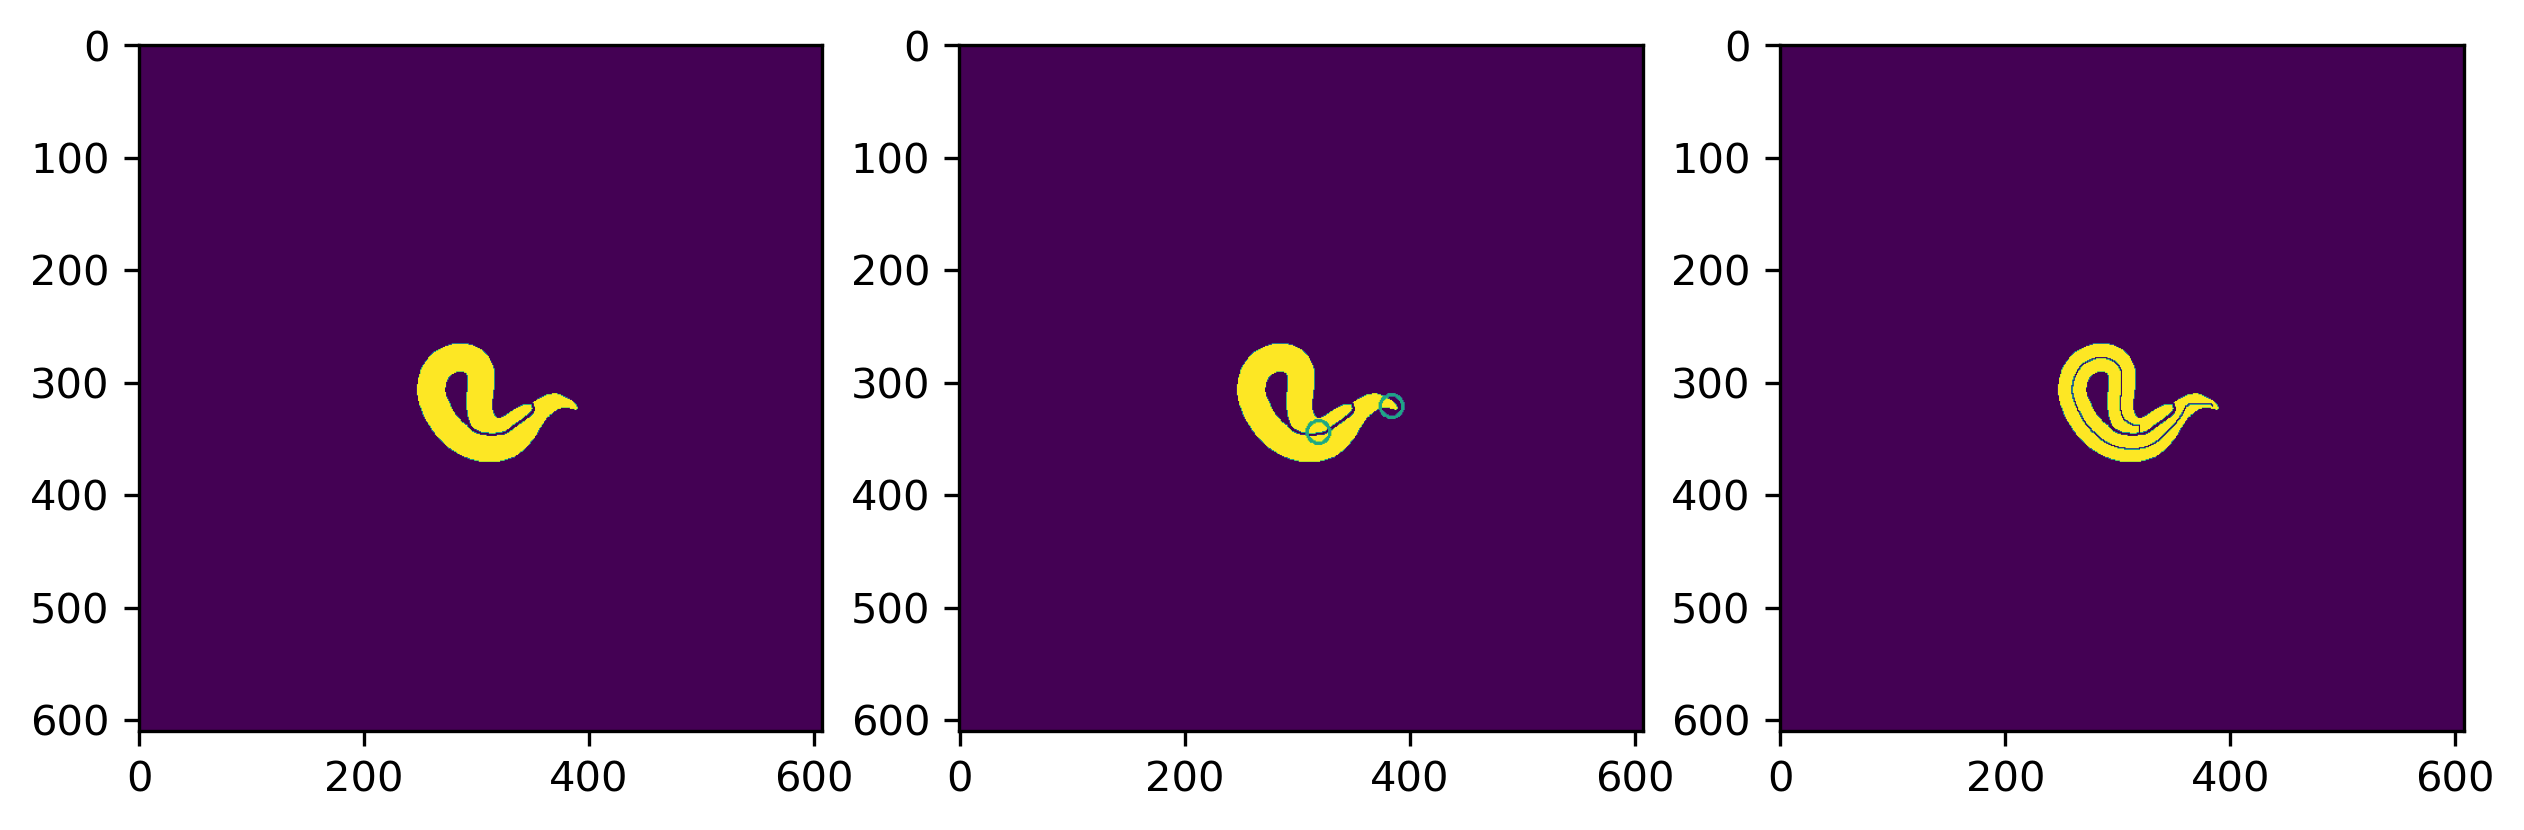

img22055.tif


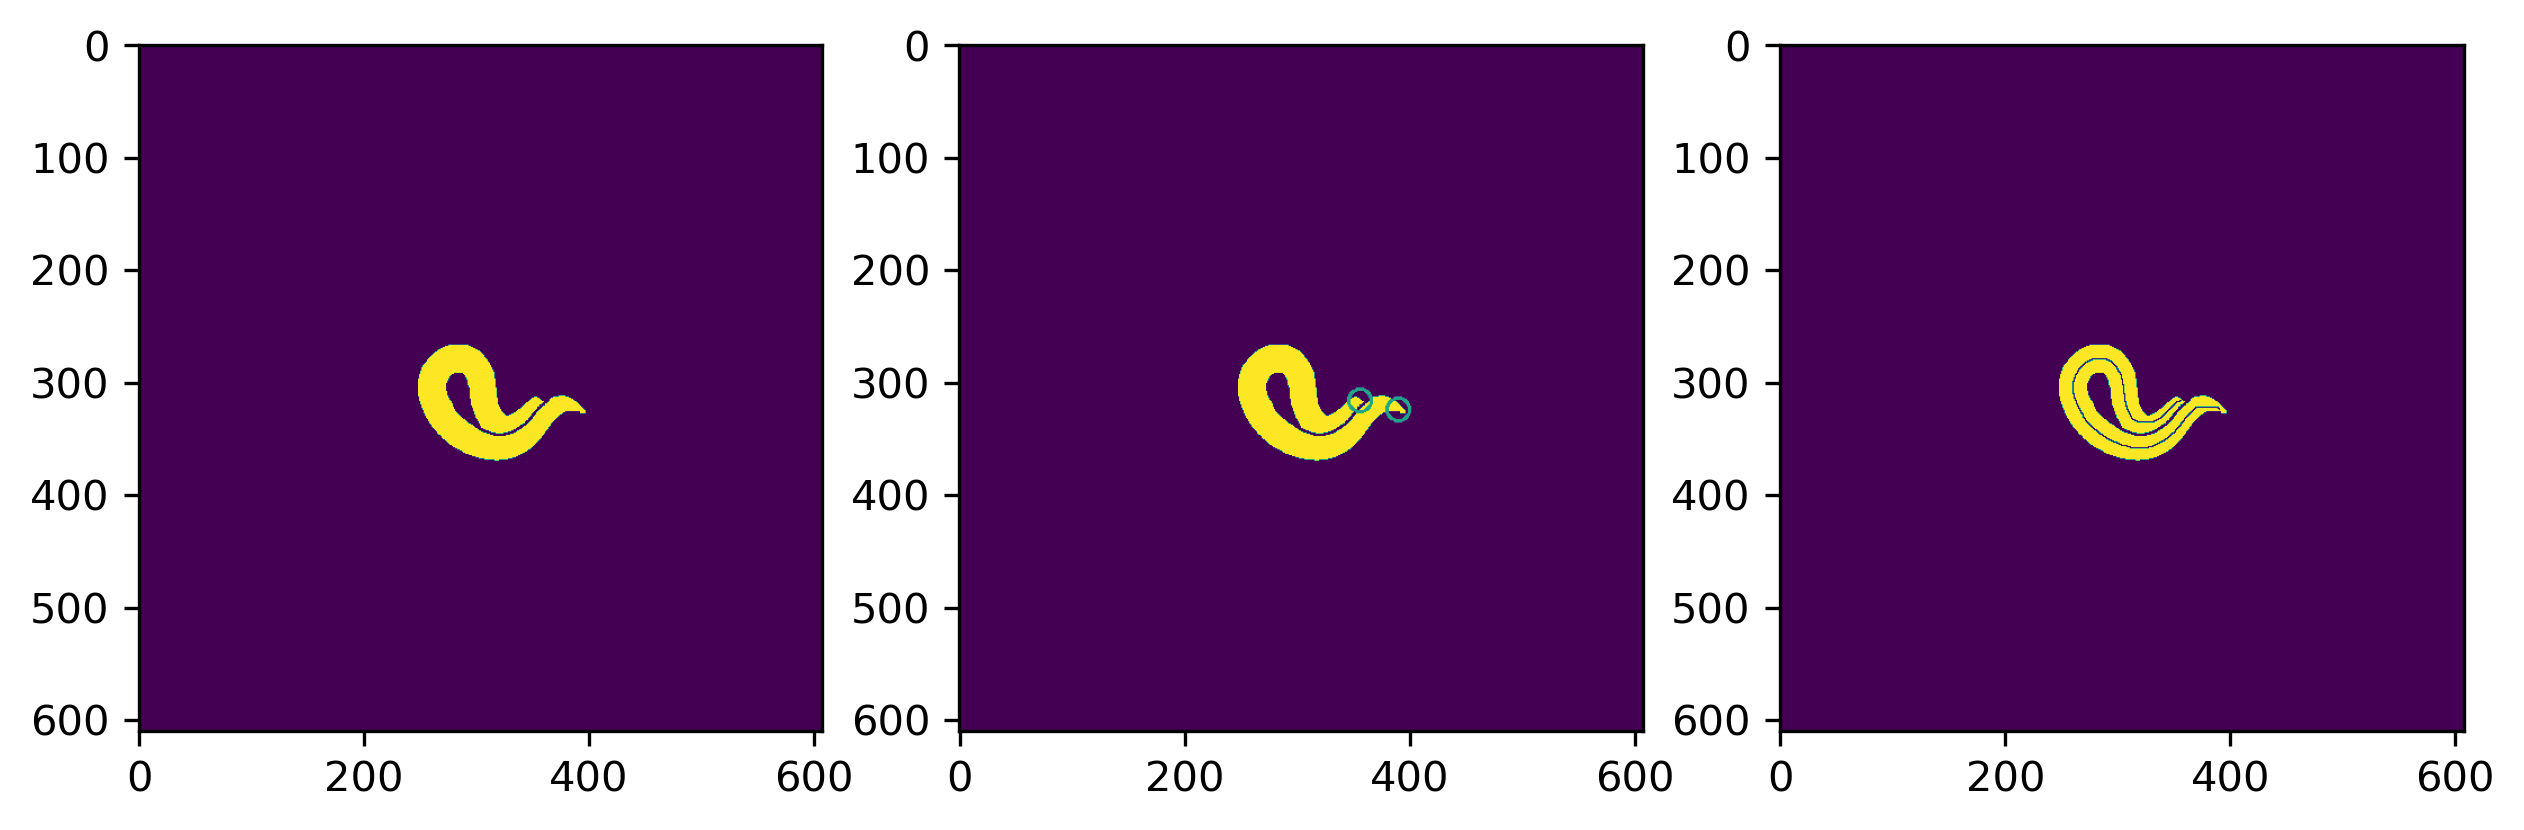

img22073.tif


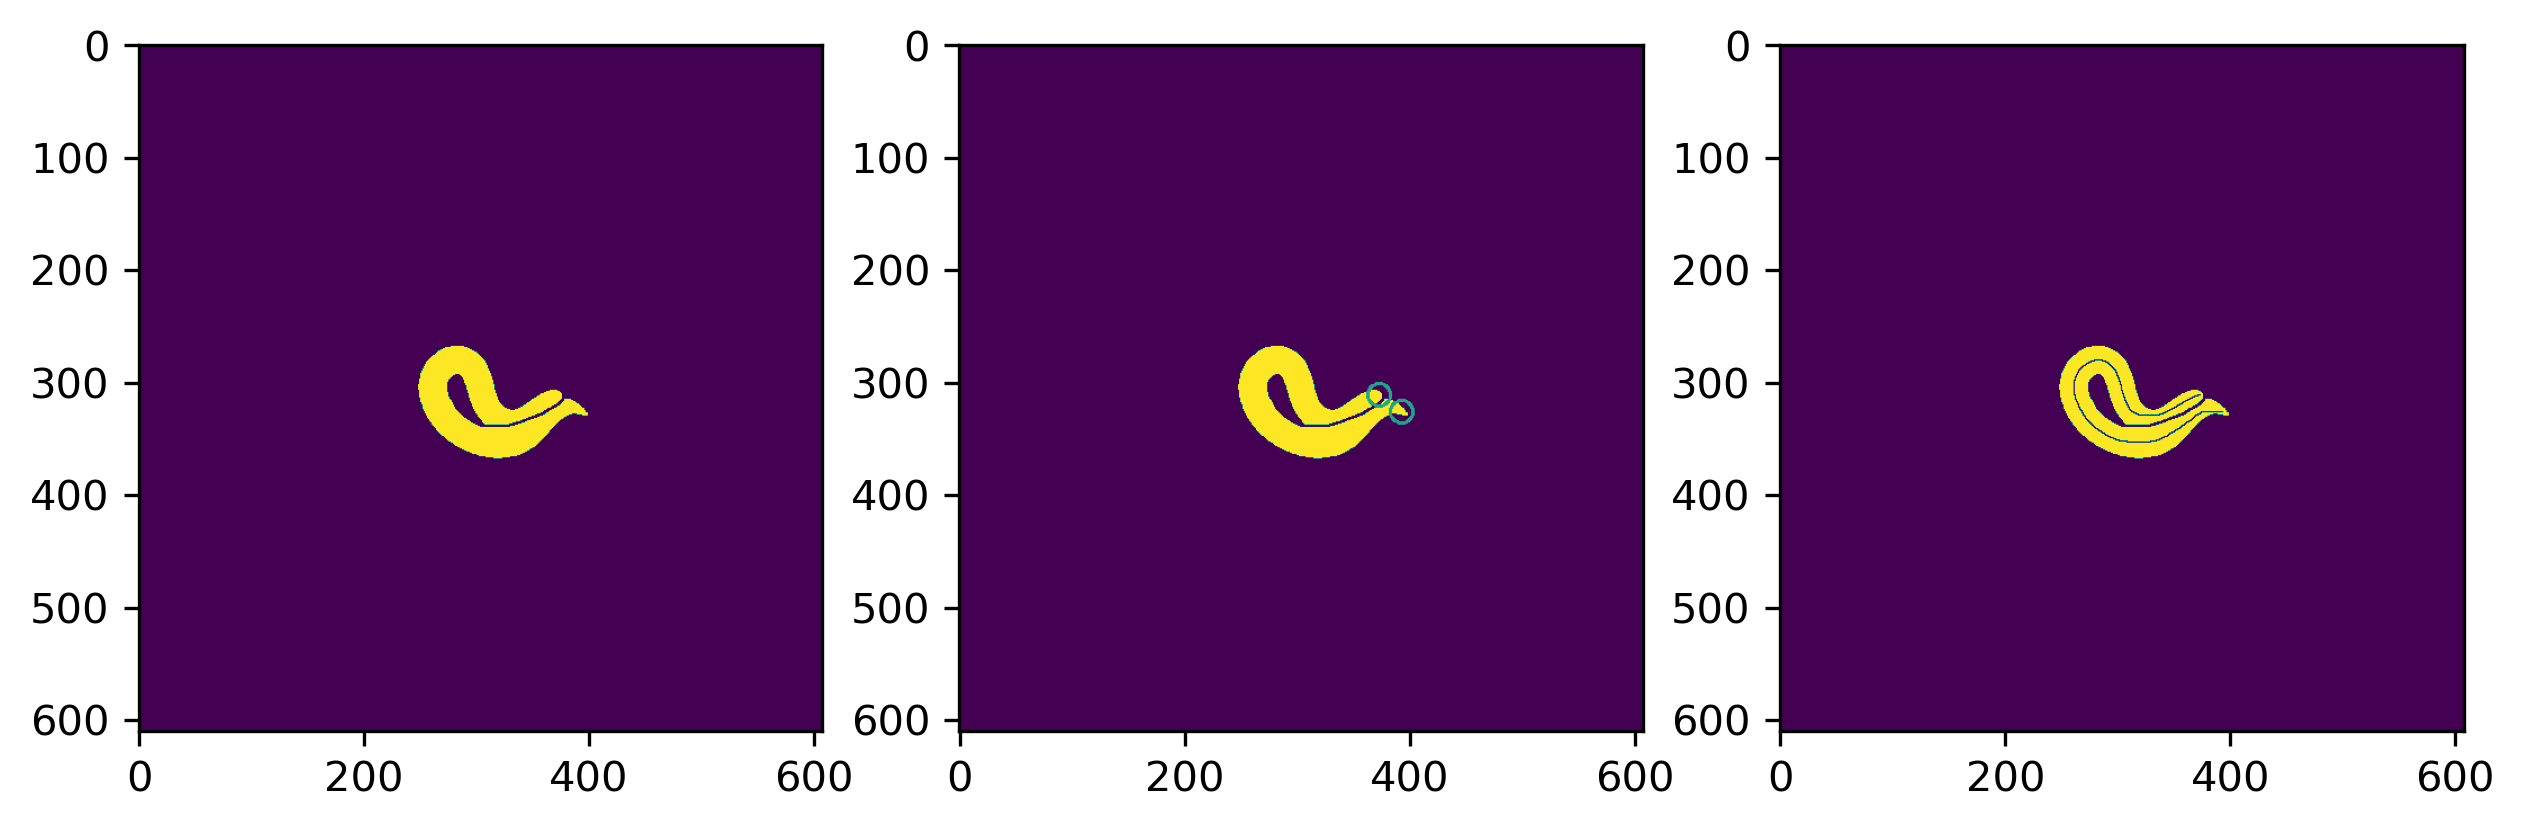

img22091.tif


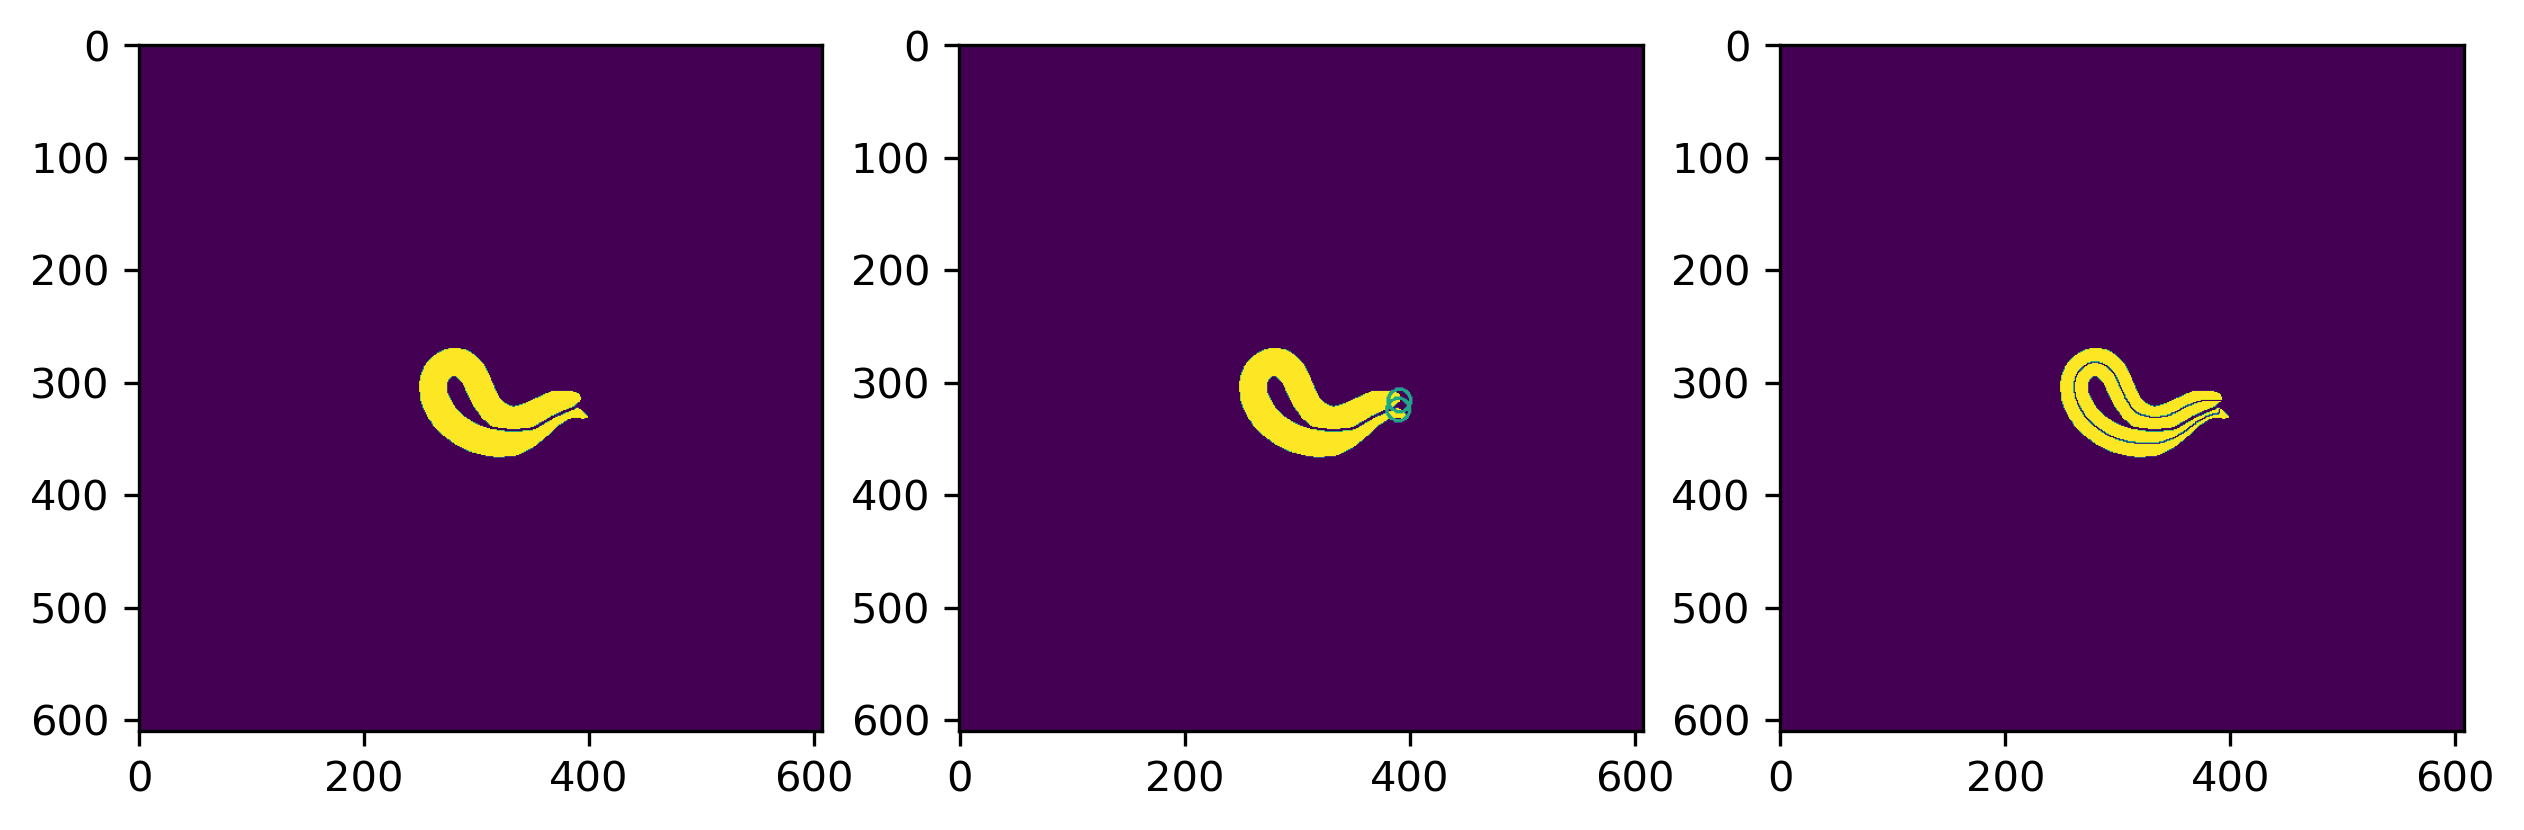

img22111.tif
head and tail were too close, no centerline could be created
img22157.tif


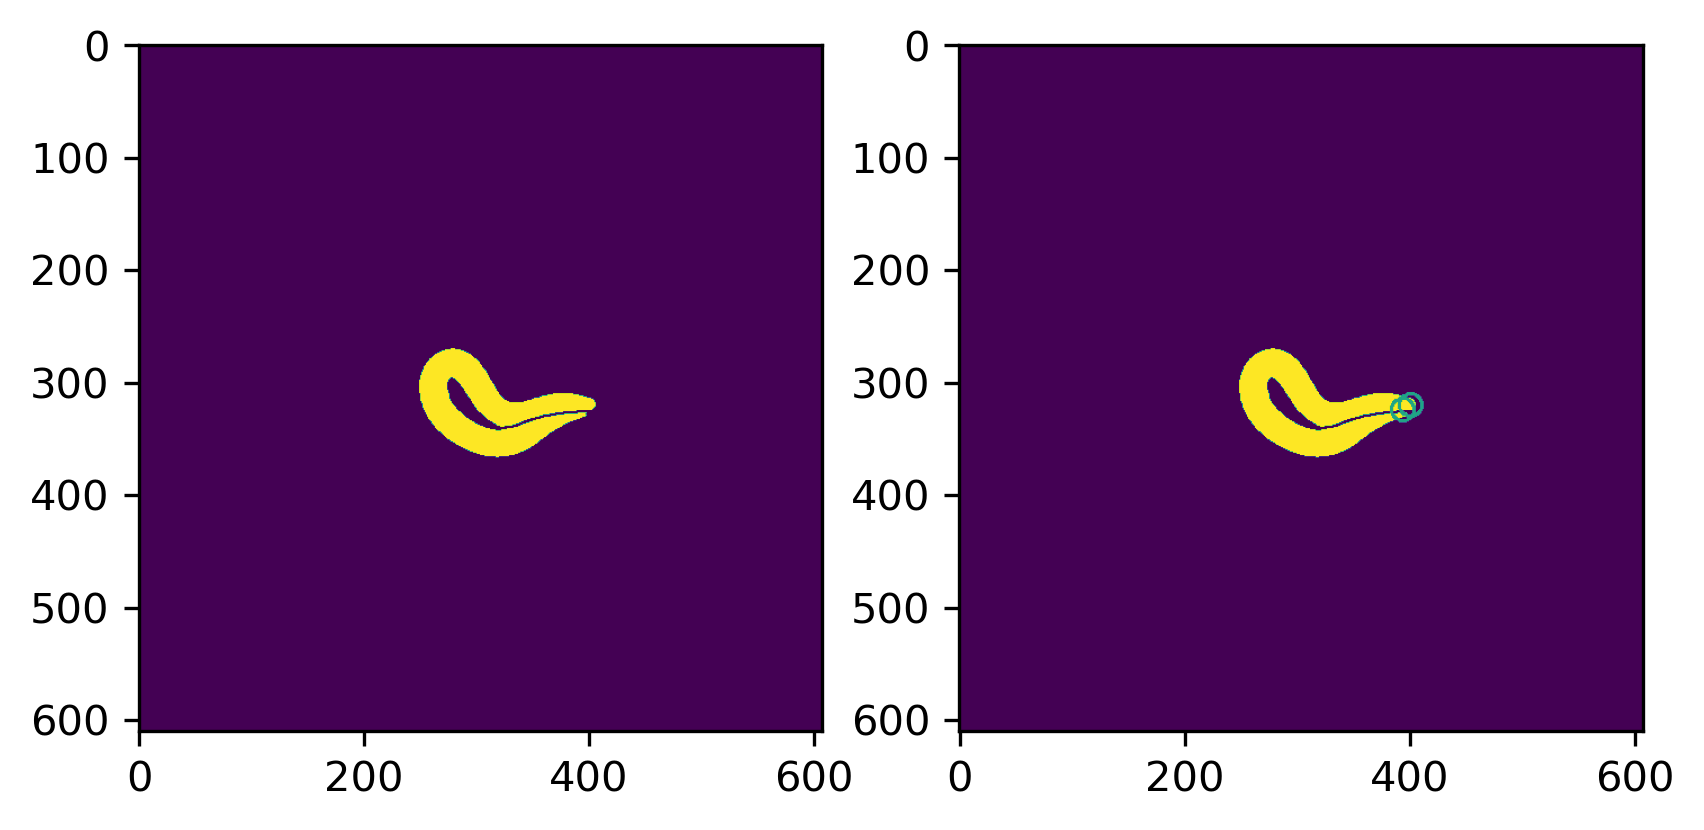

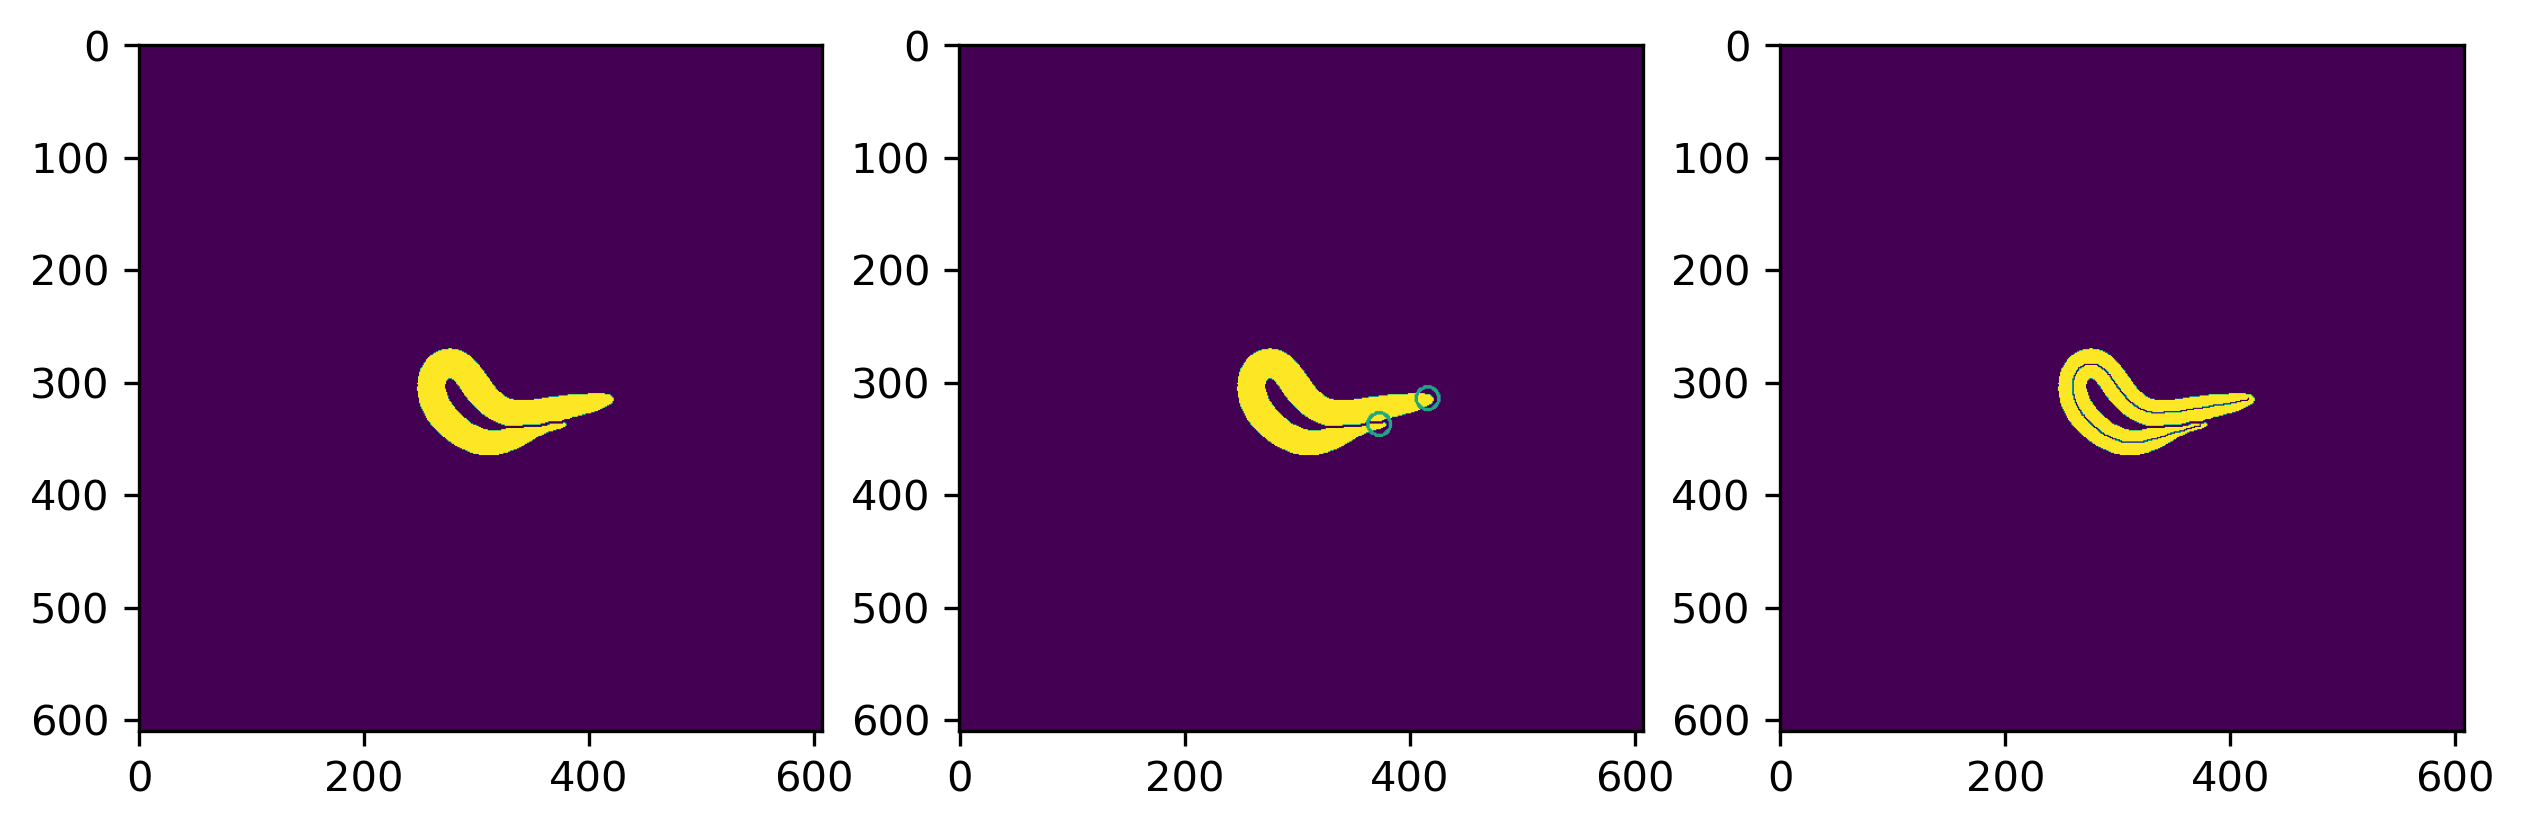

img22182.tif


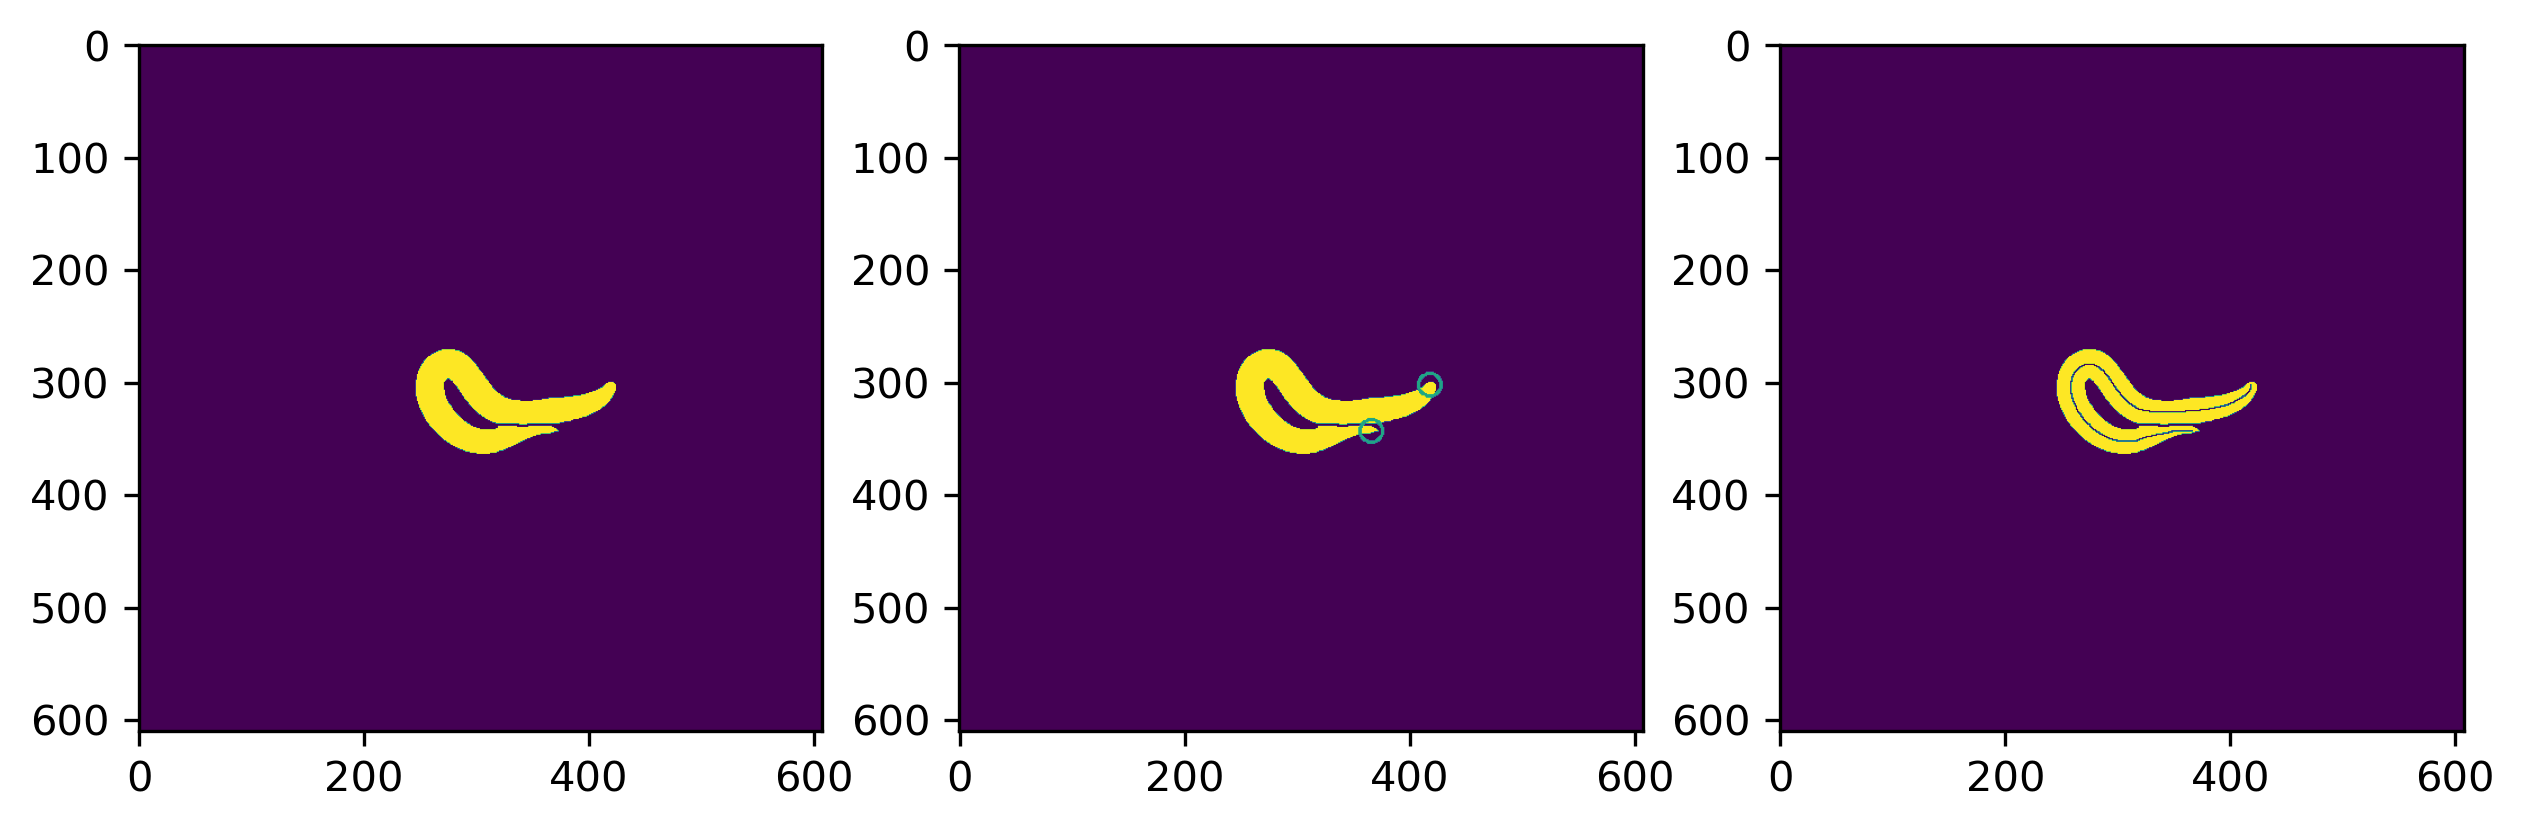

img22250.tif
head and tail were too close, no centerline could be created
img22286.tif


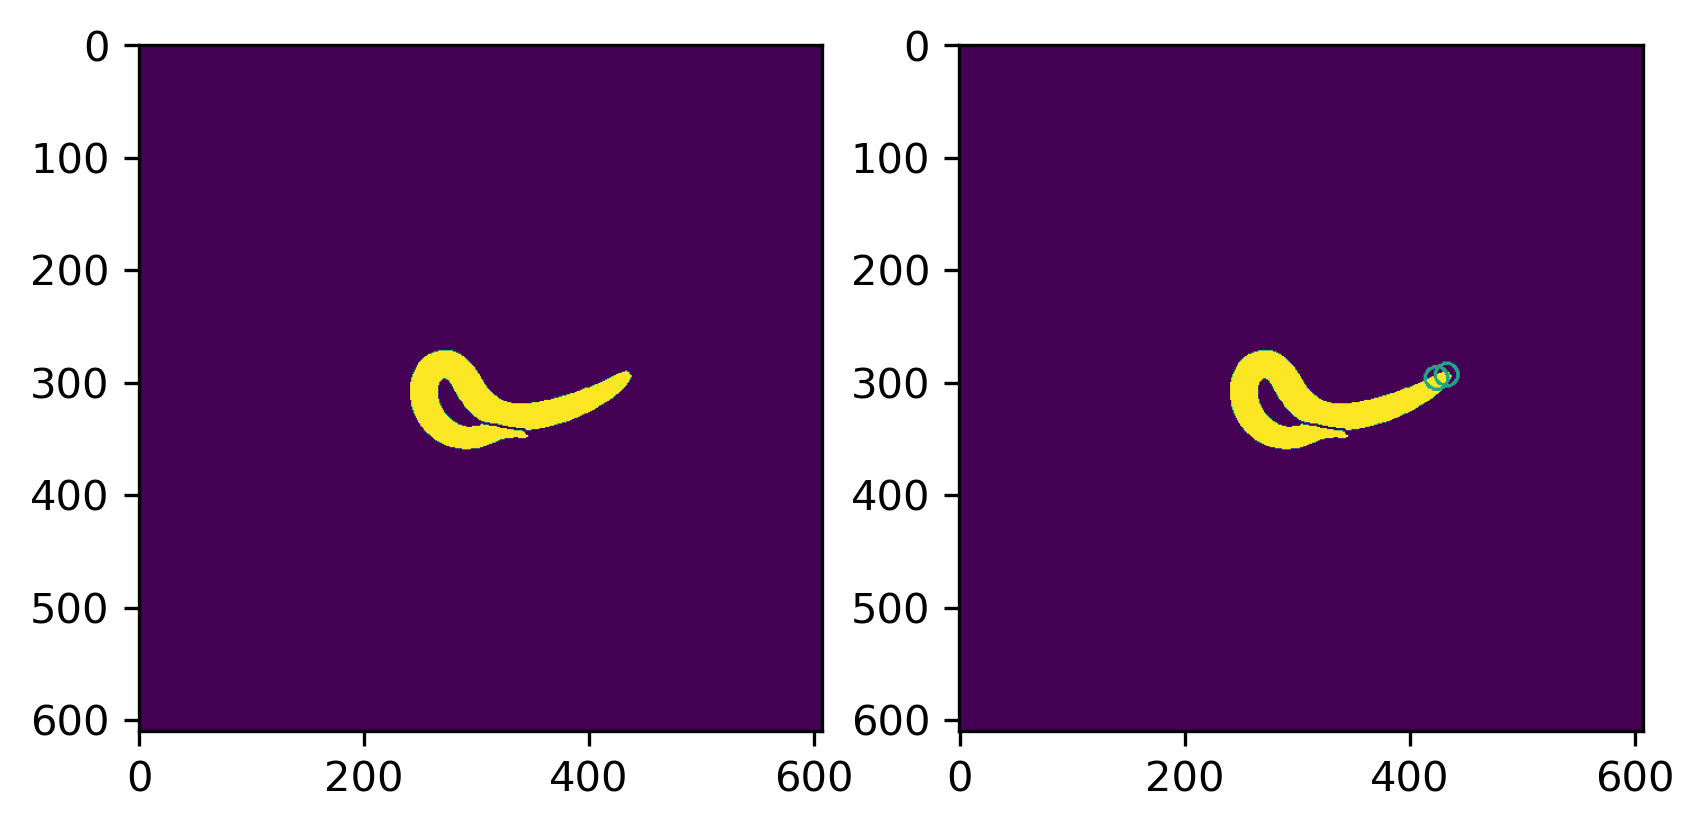

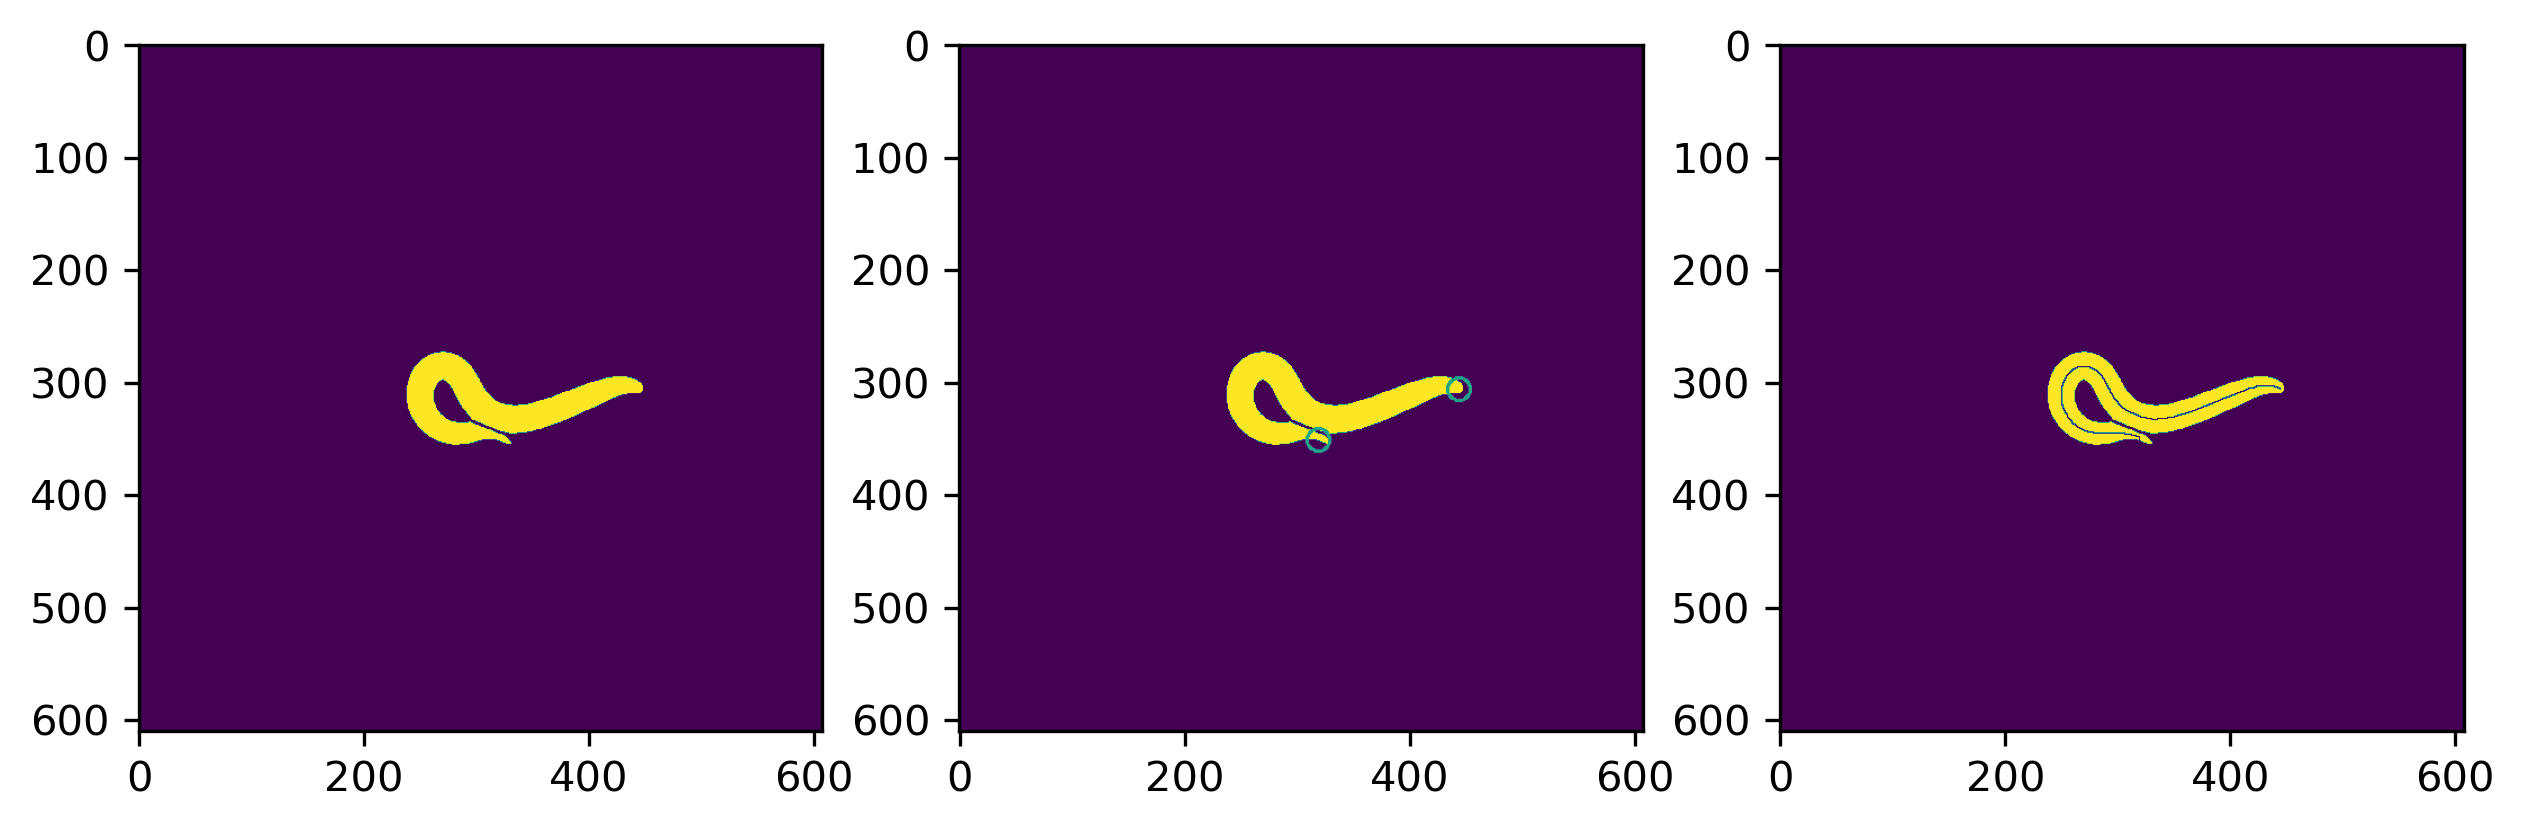

img22314.tif


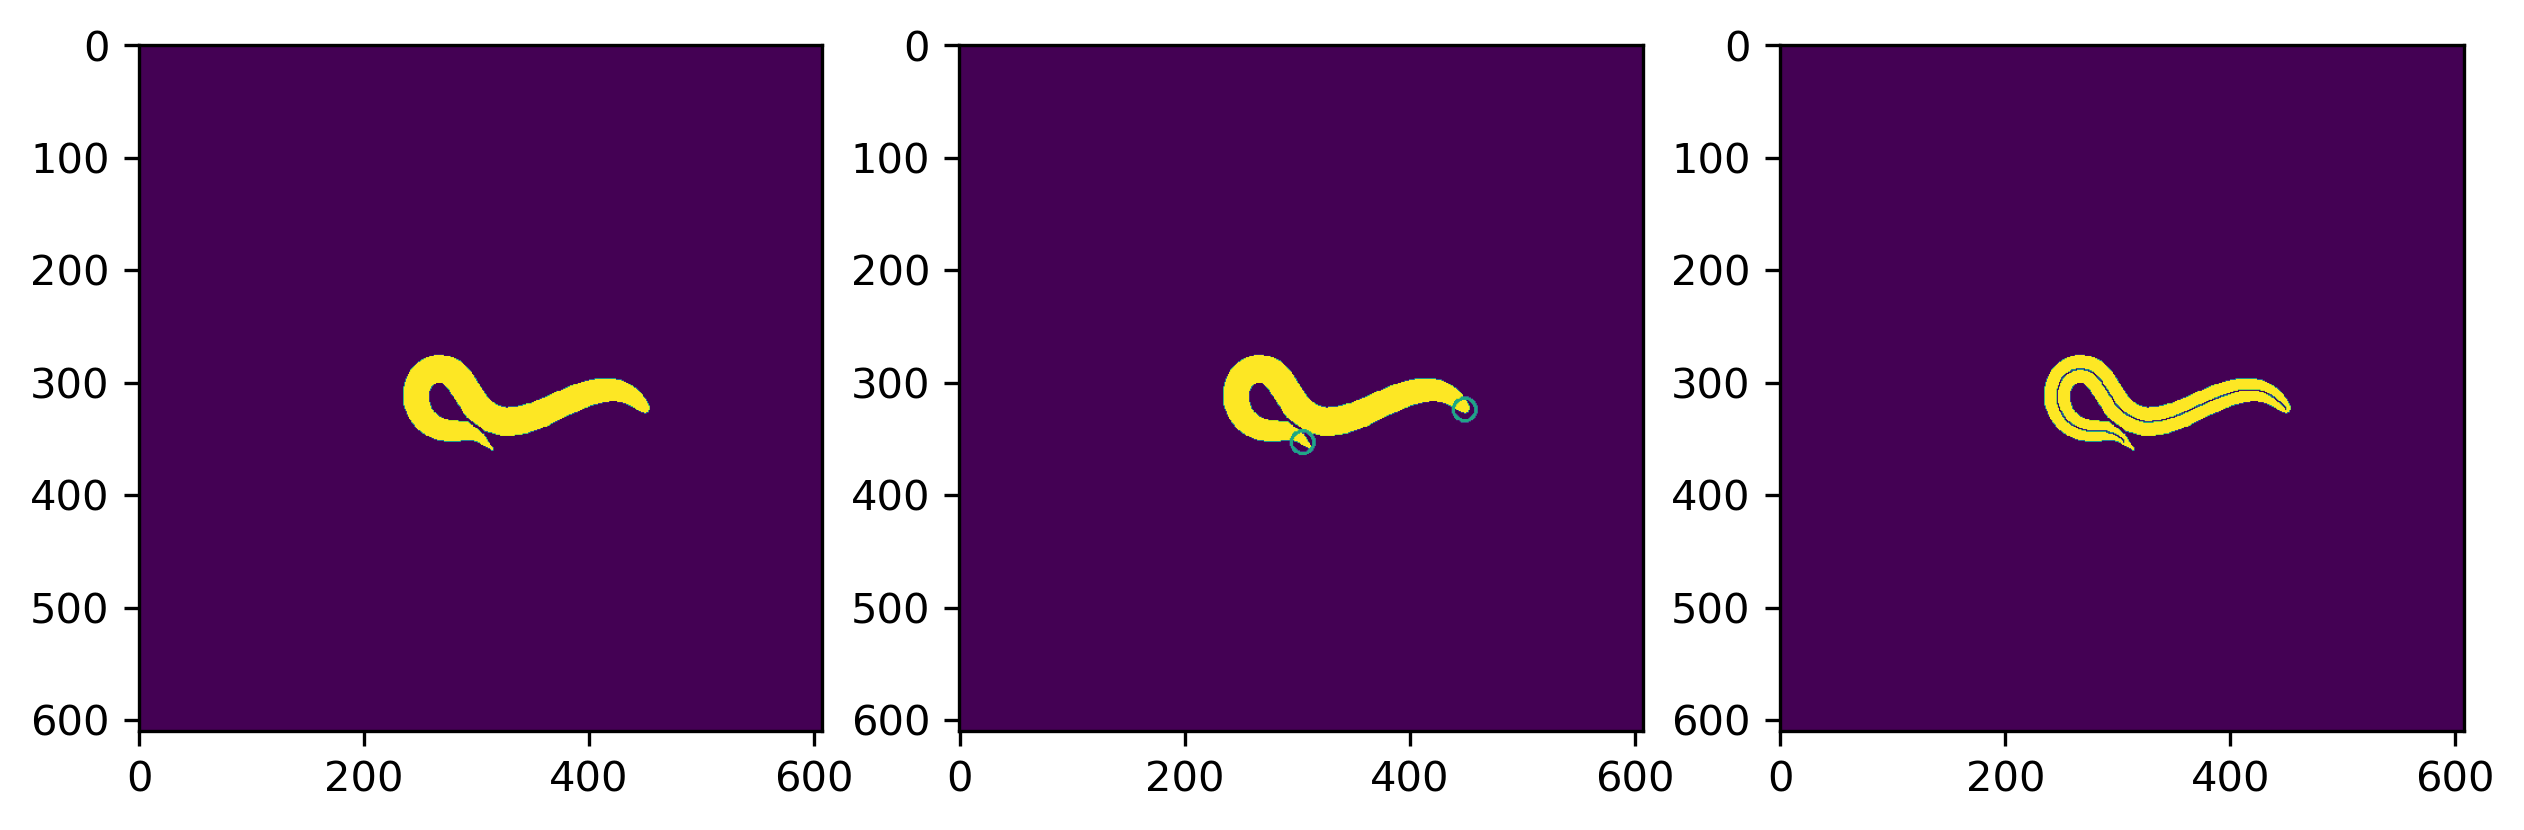

img24362.tif


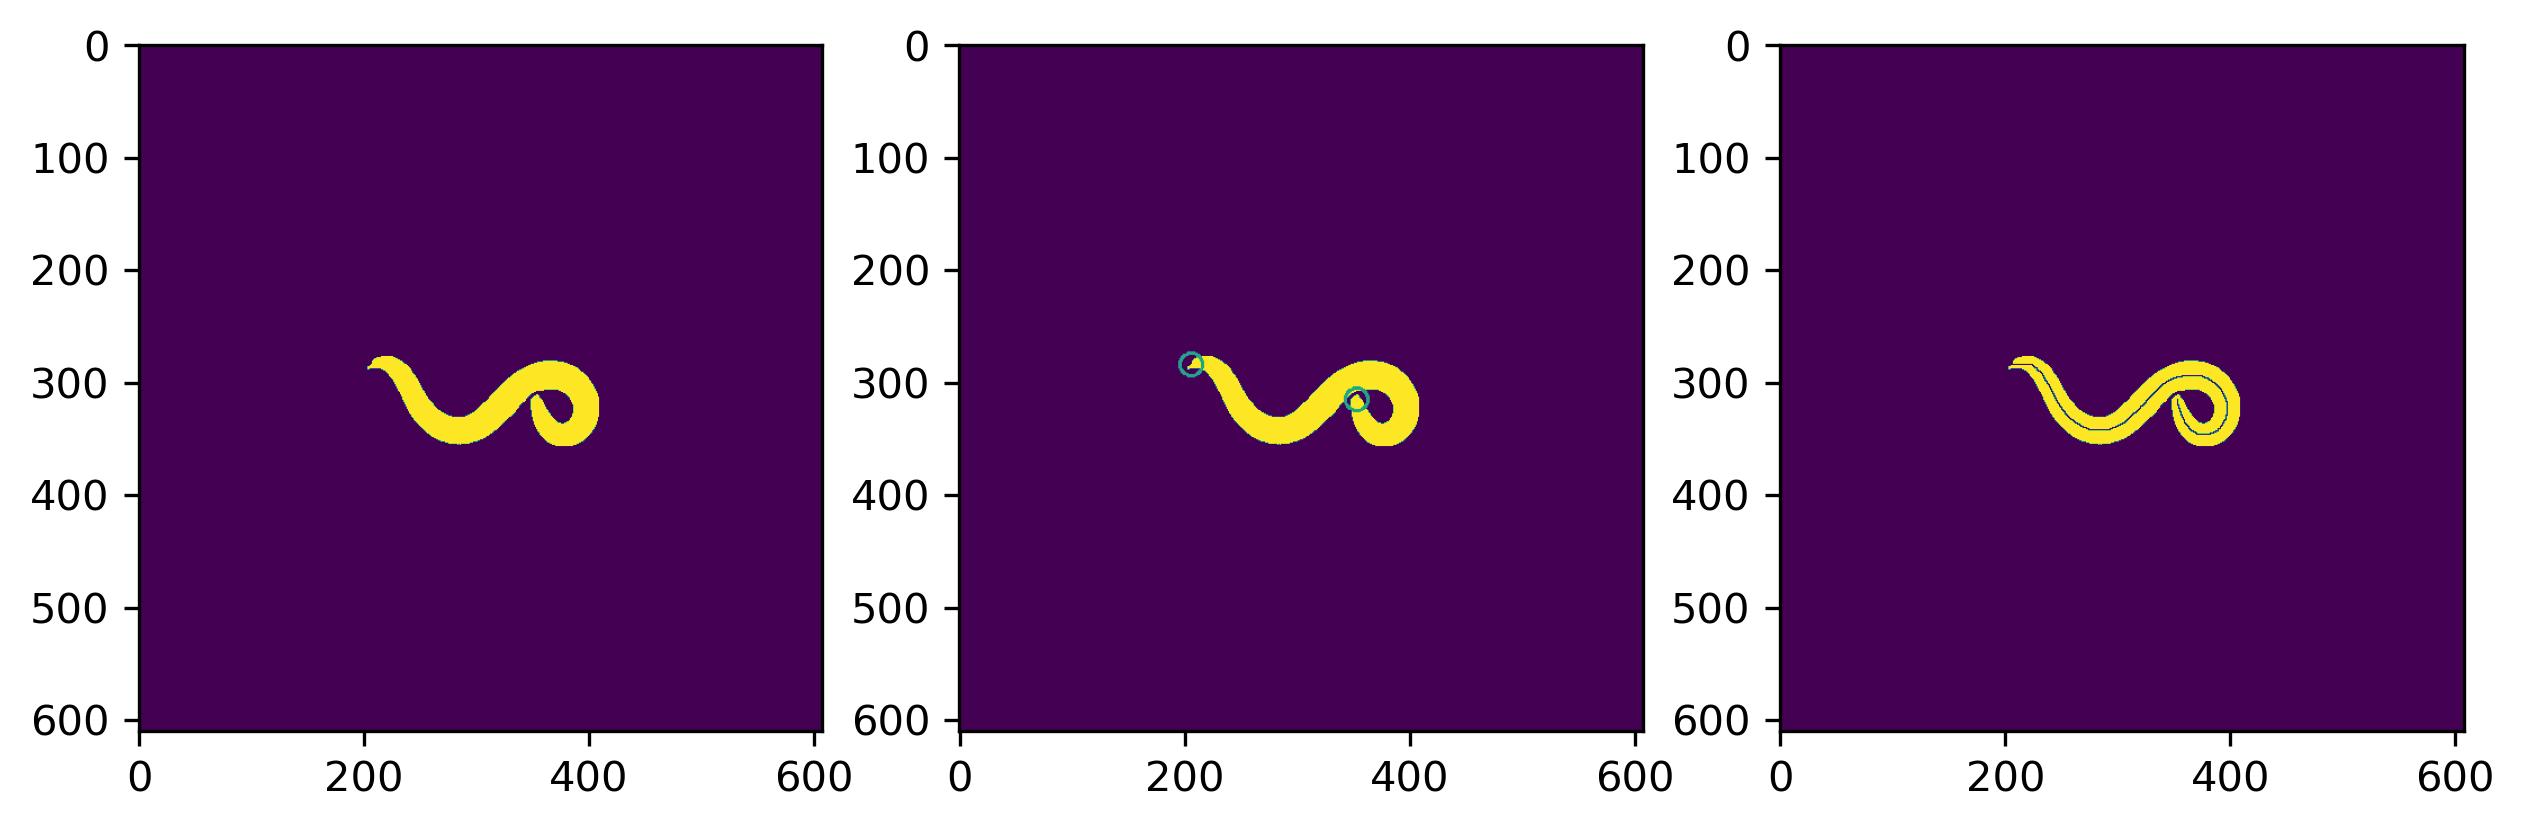

img24414.tif
head and tail were too close, no centerline could be created
img24444.tif
head and tail were too close, no centerline could be created
img24489.tif
head and tail were too close, no centerline could be created
img24563.tif
head and tail were too close, no centerline could be created
img24623.tif
head and tail were too close, no centerline could be created
img24683.tif
head and tail were too close, no centerline could be created
img24743.tif


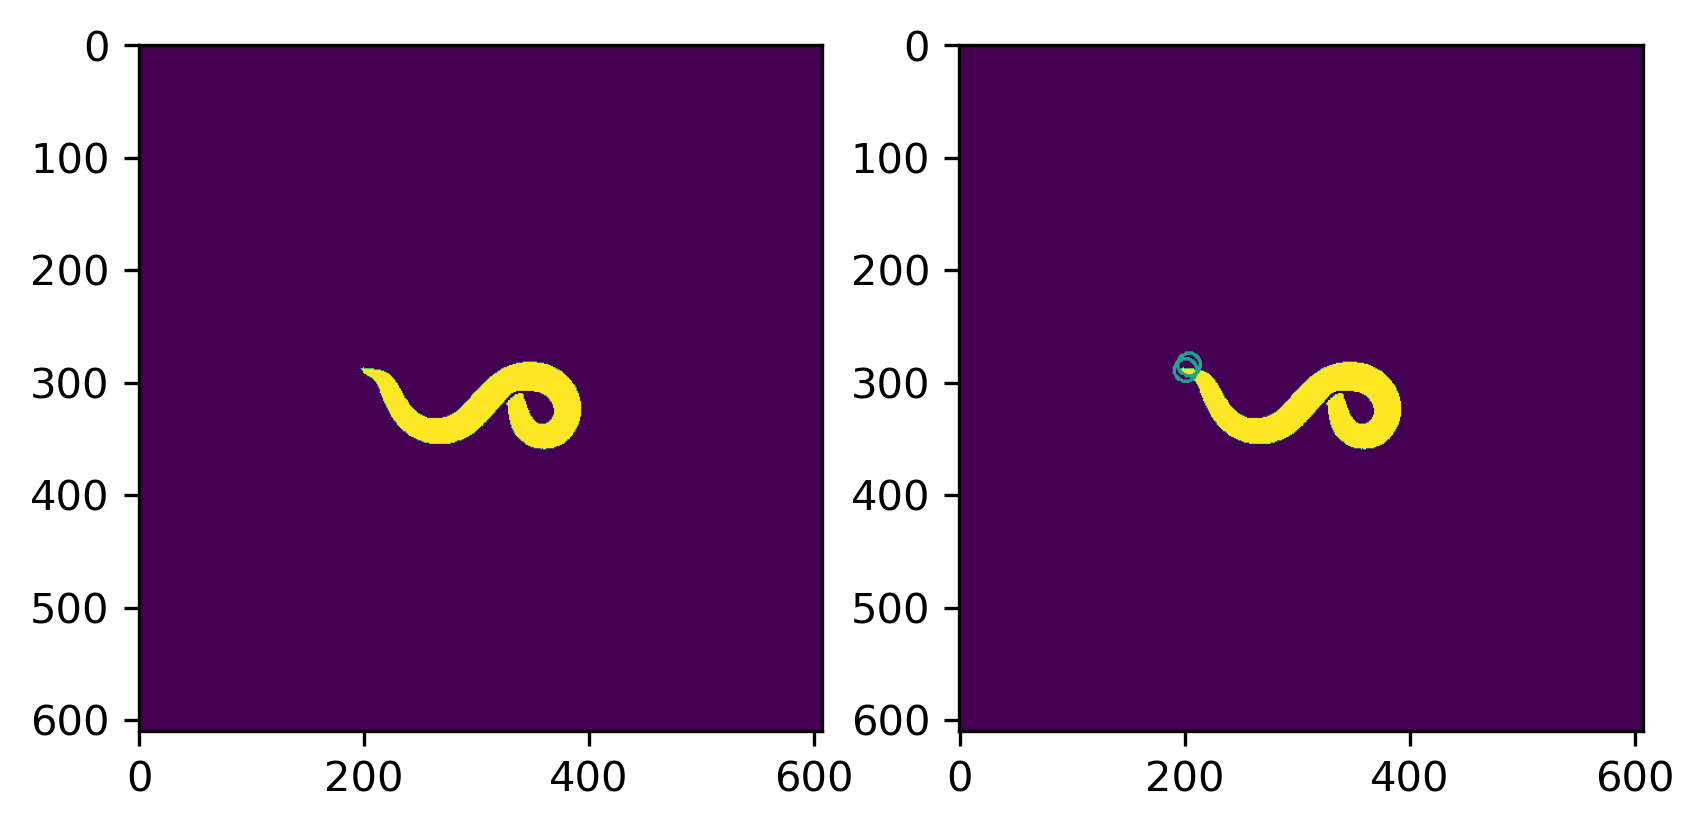

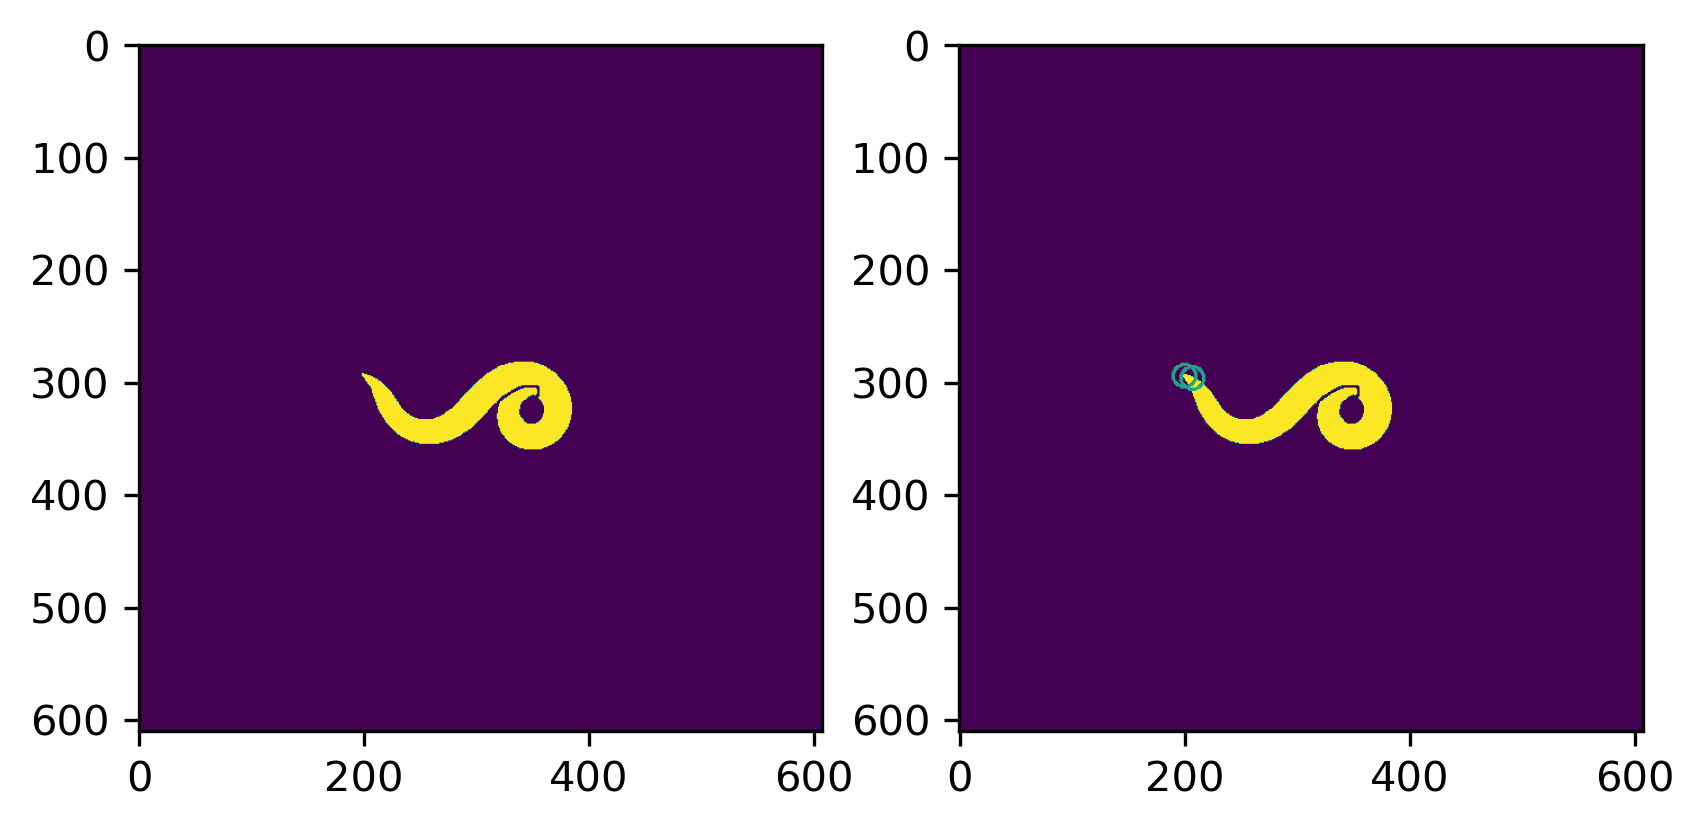

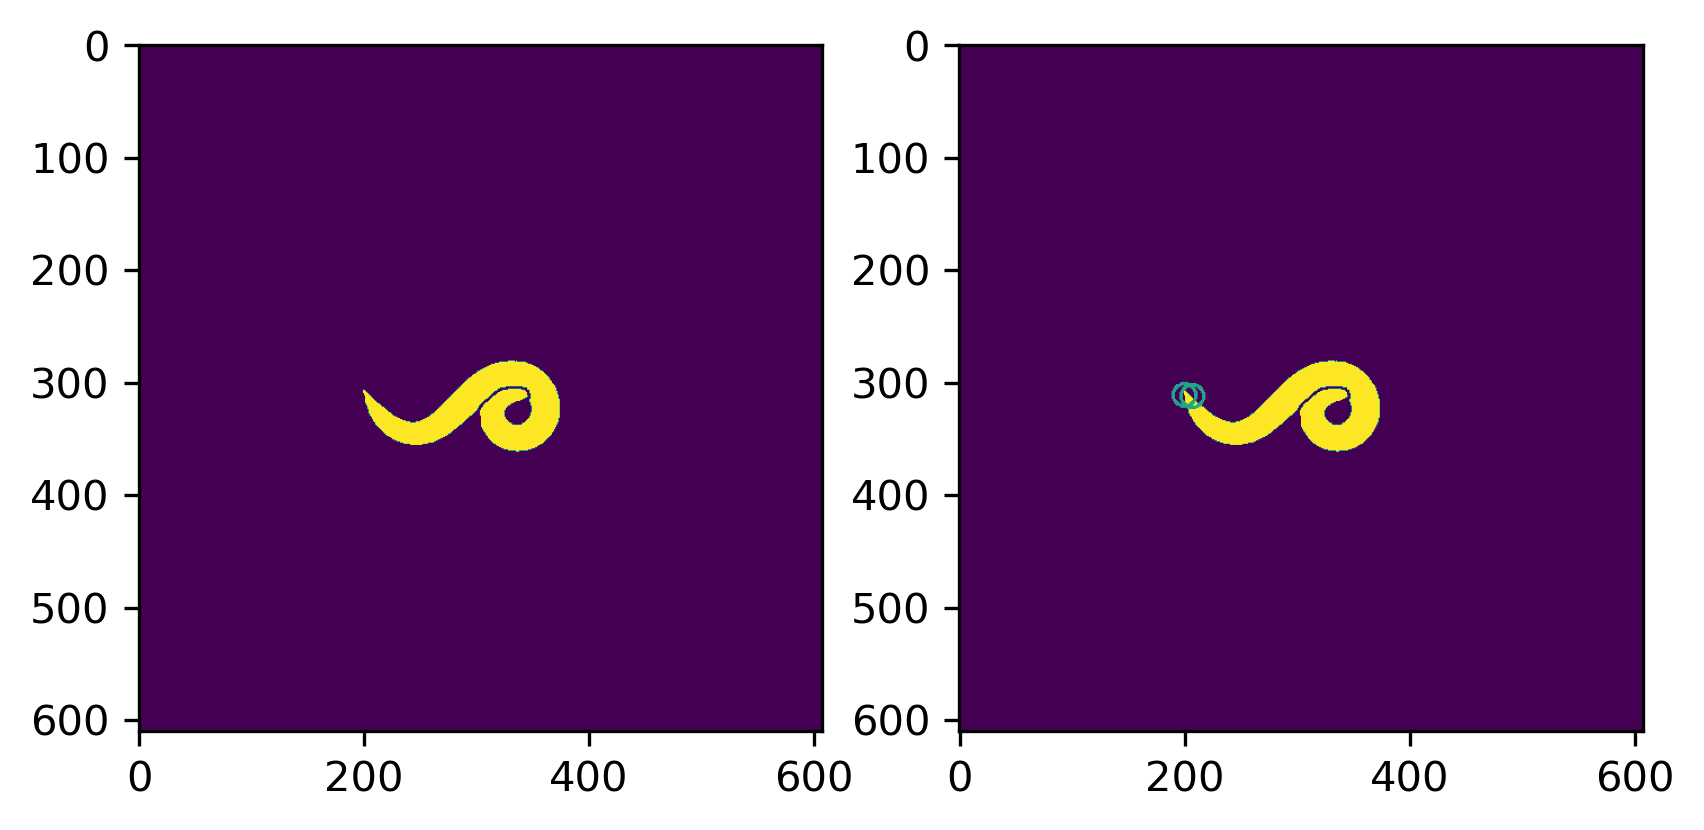

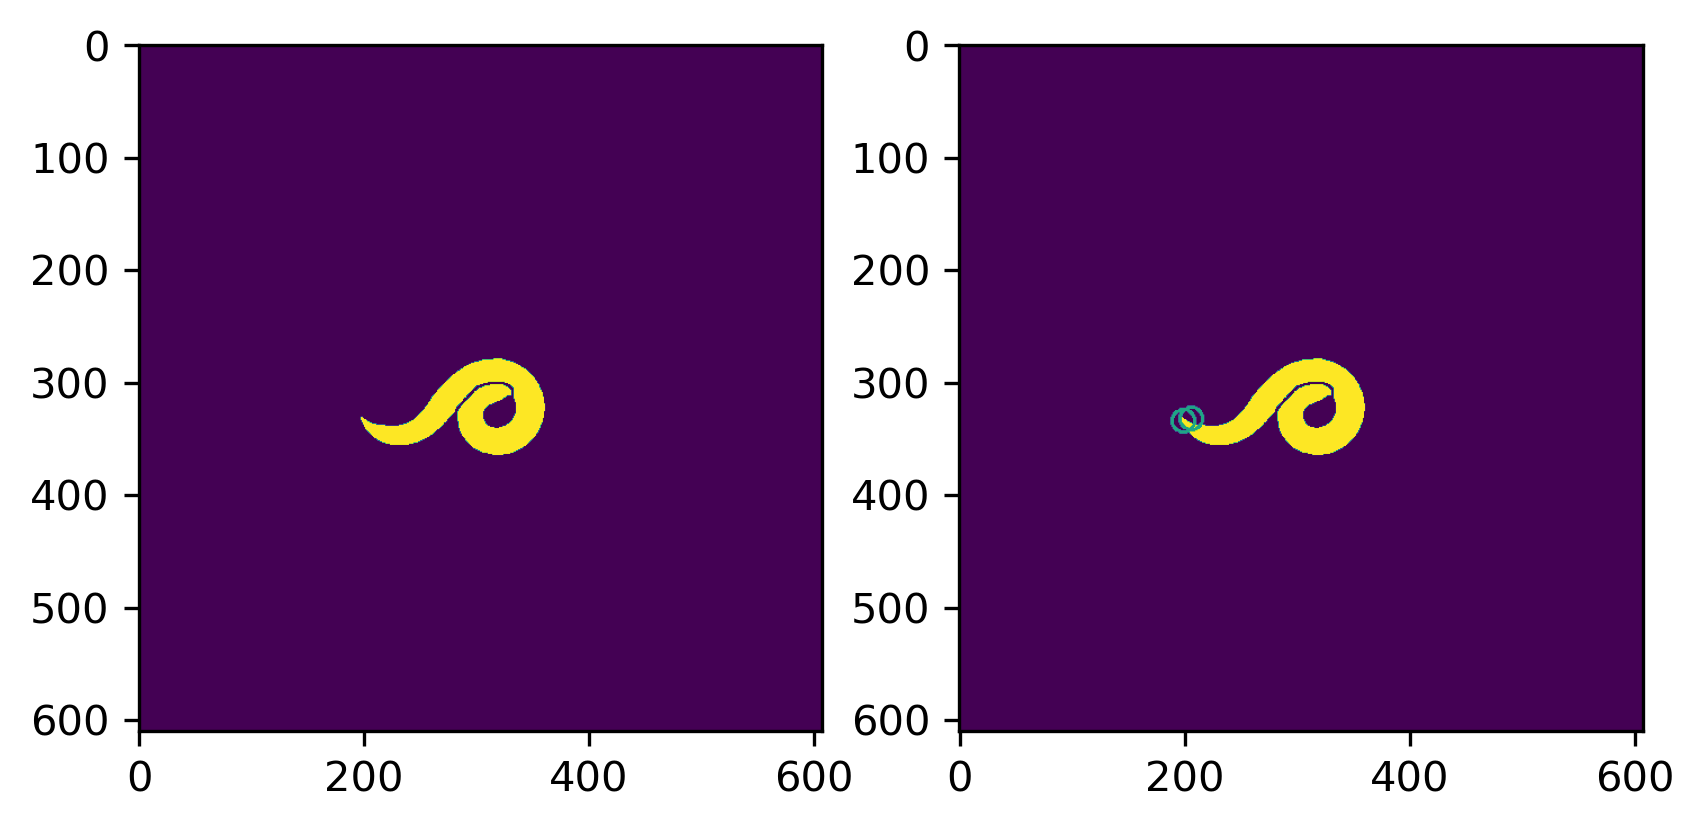

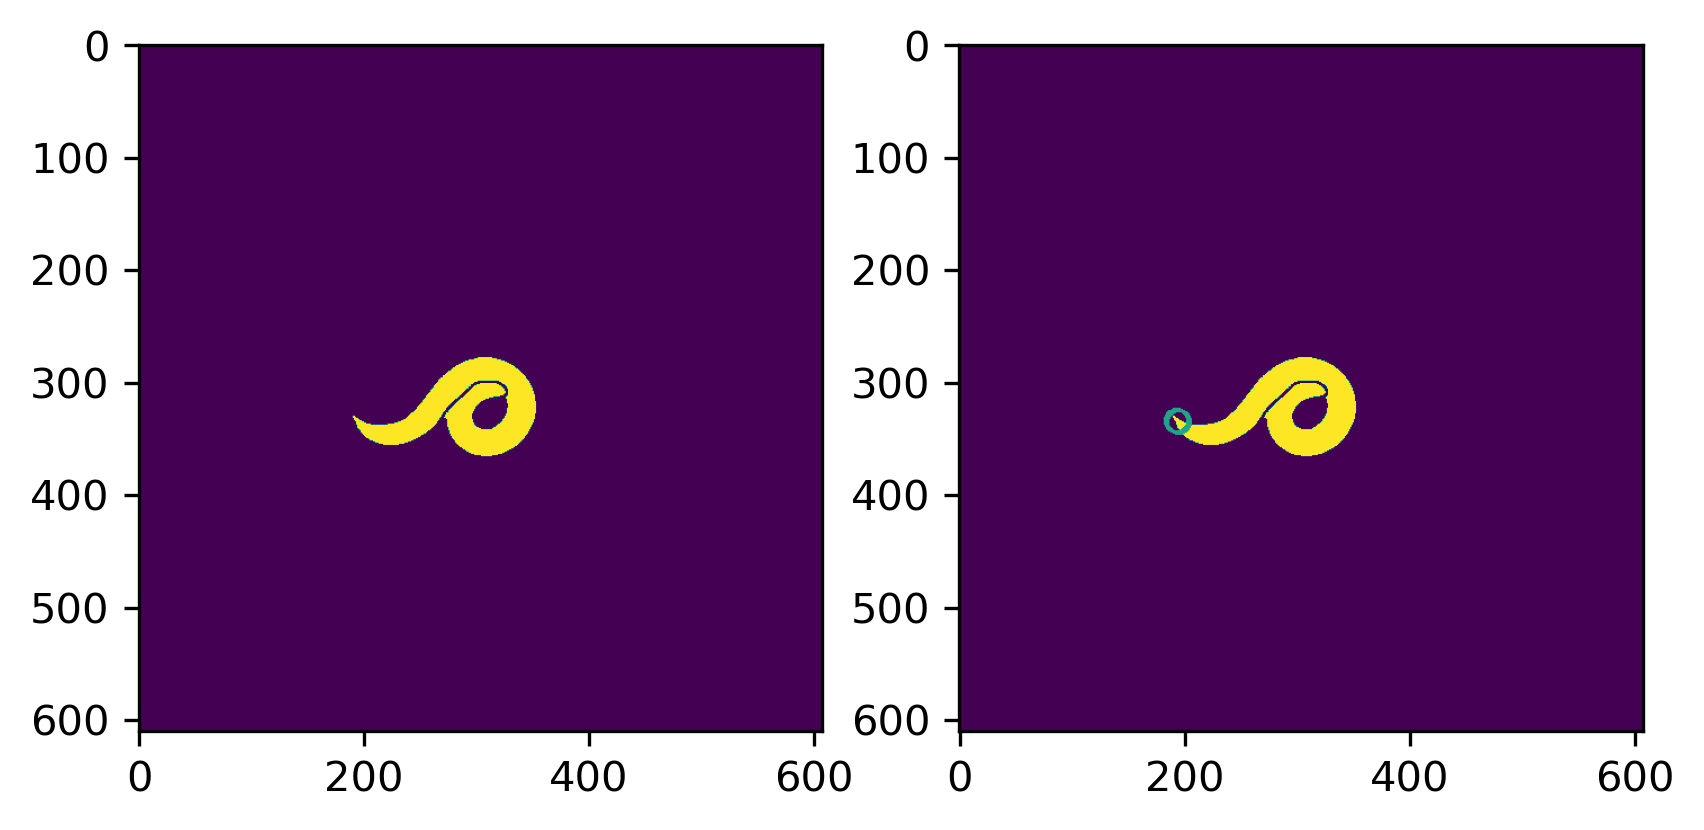

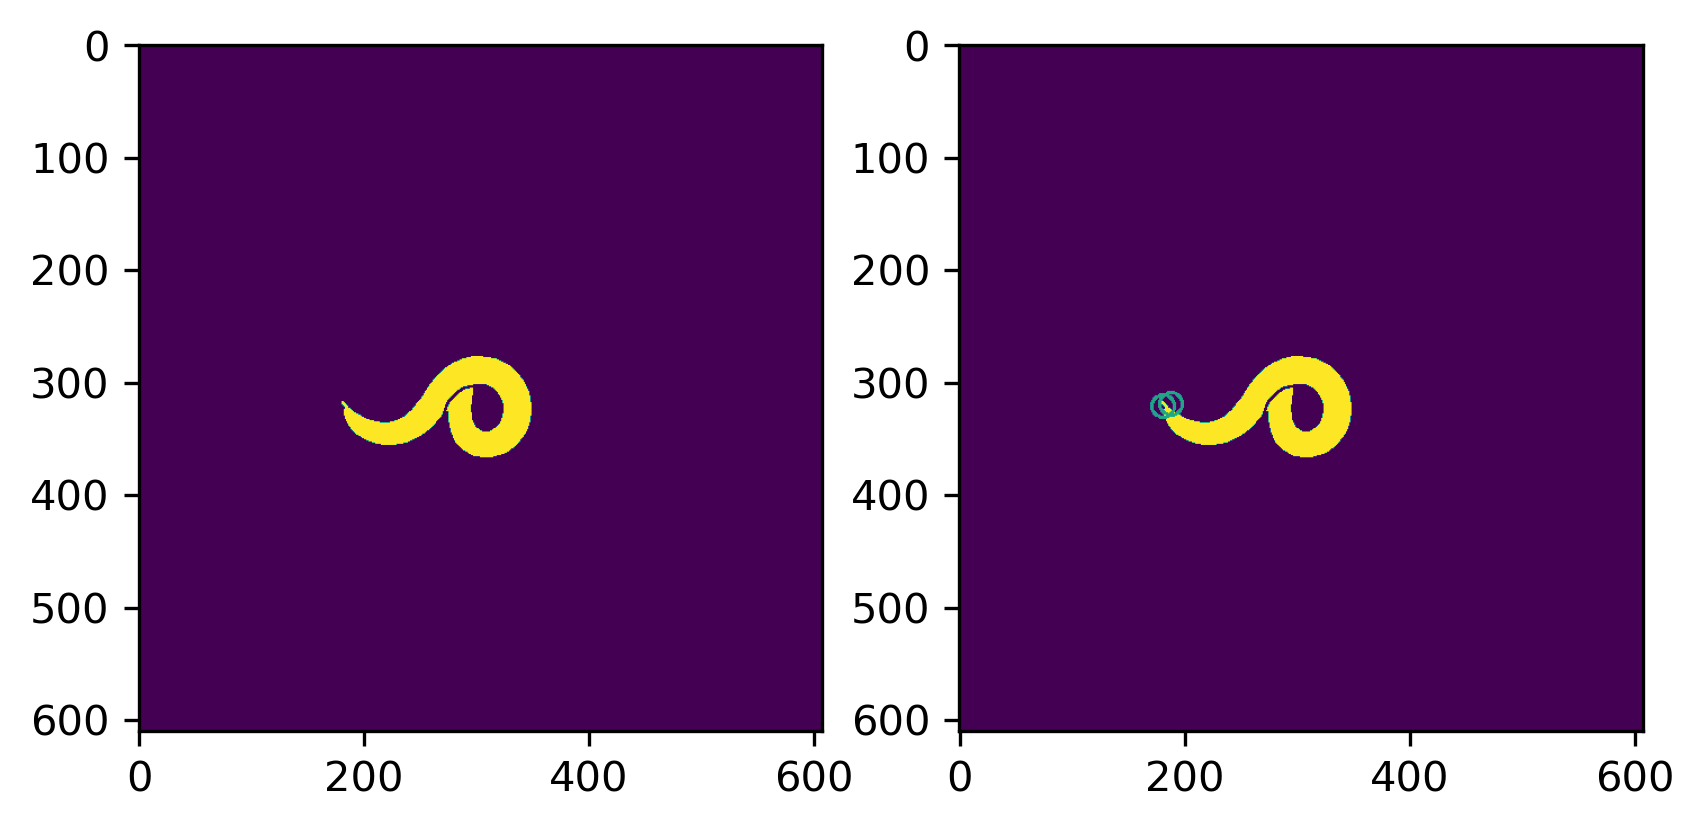

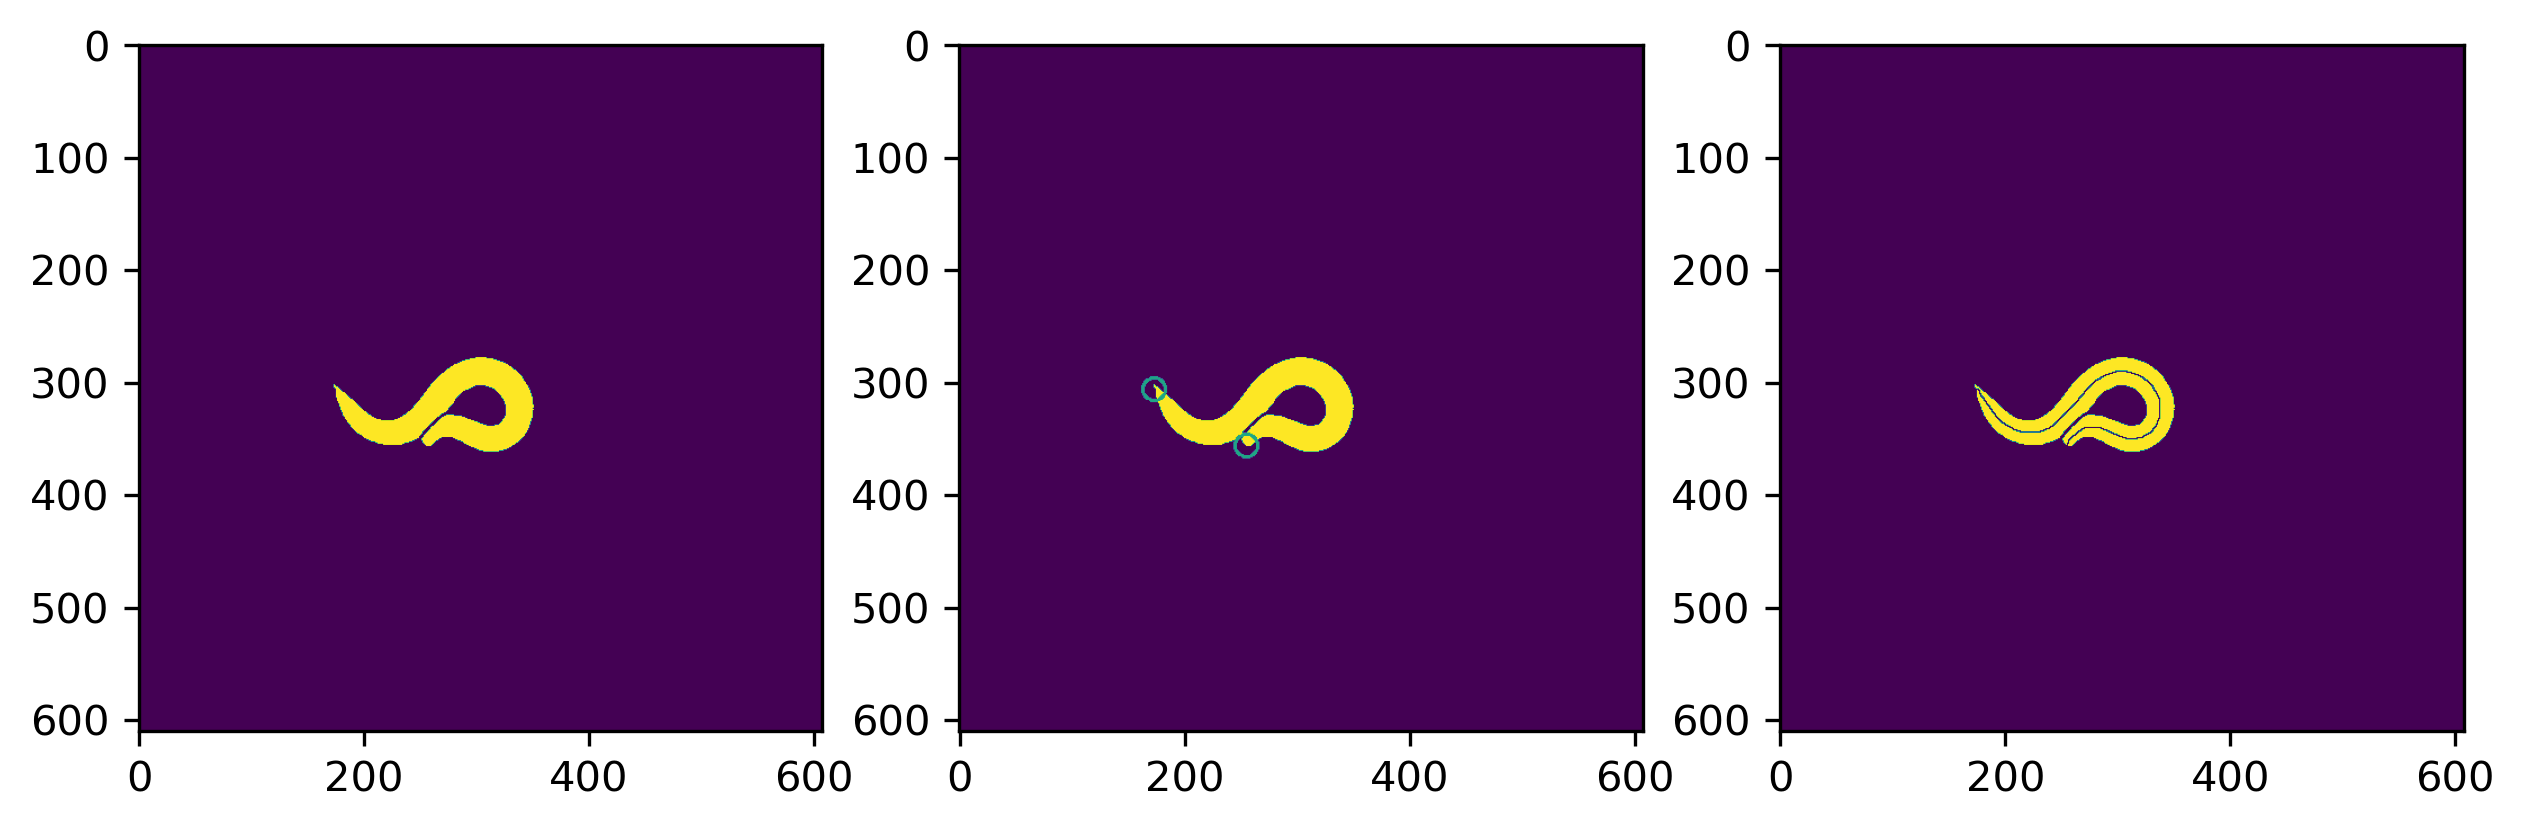

img24803.tif


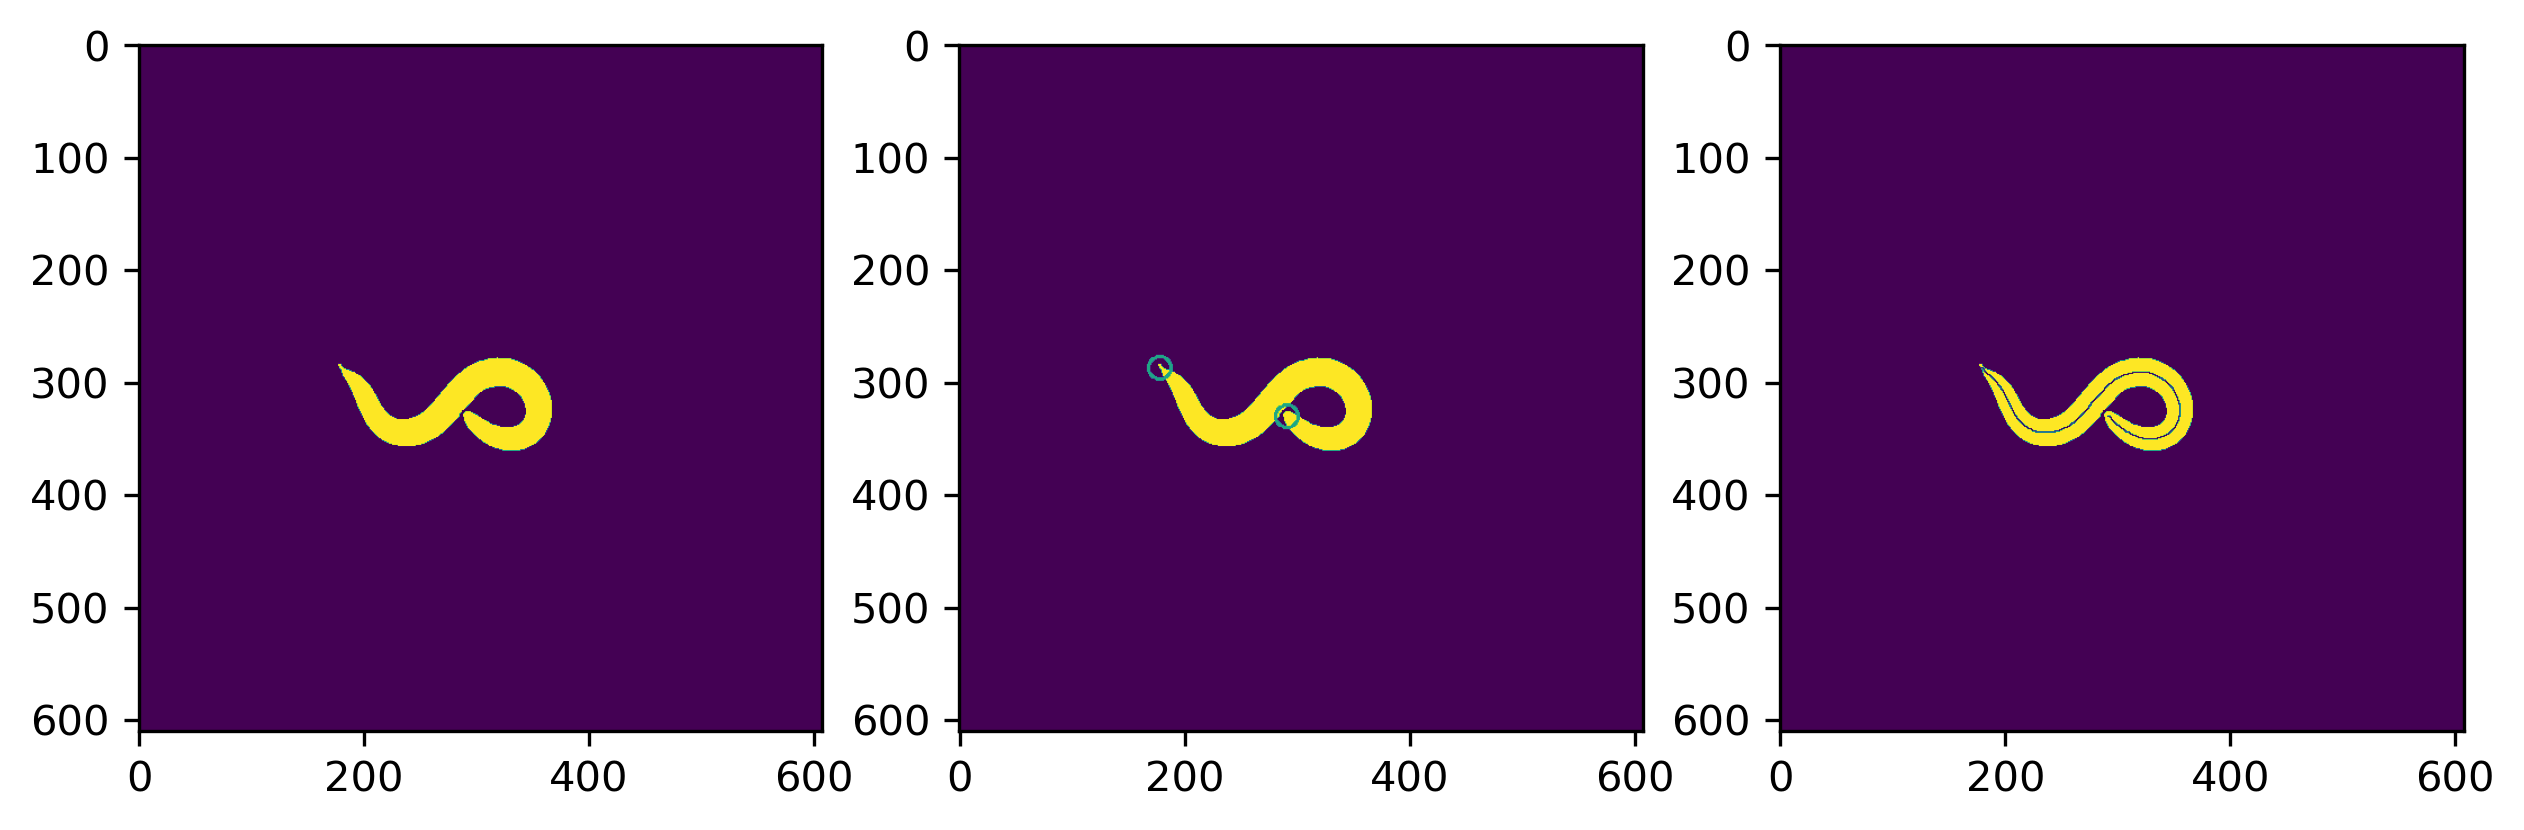

img27739.tif


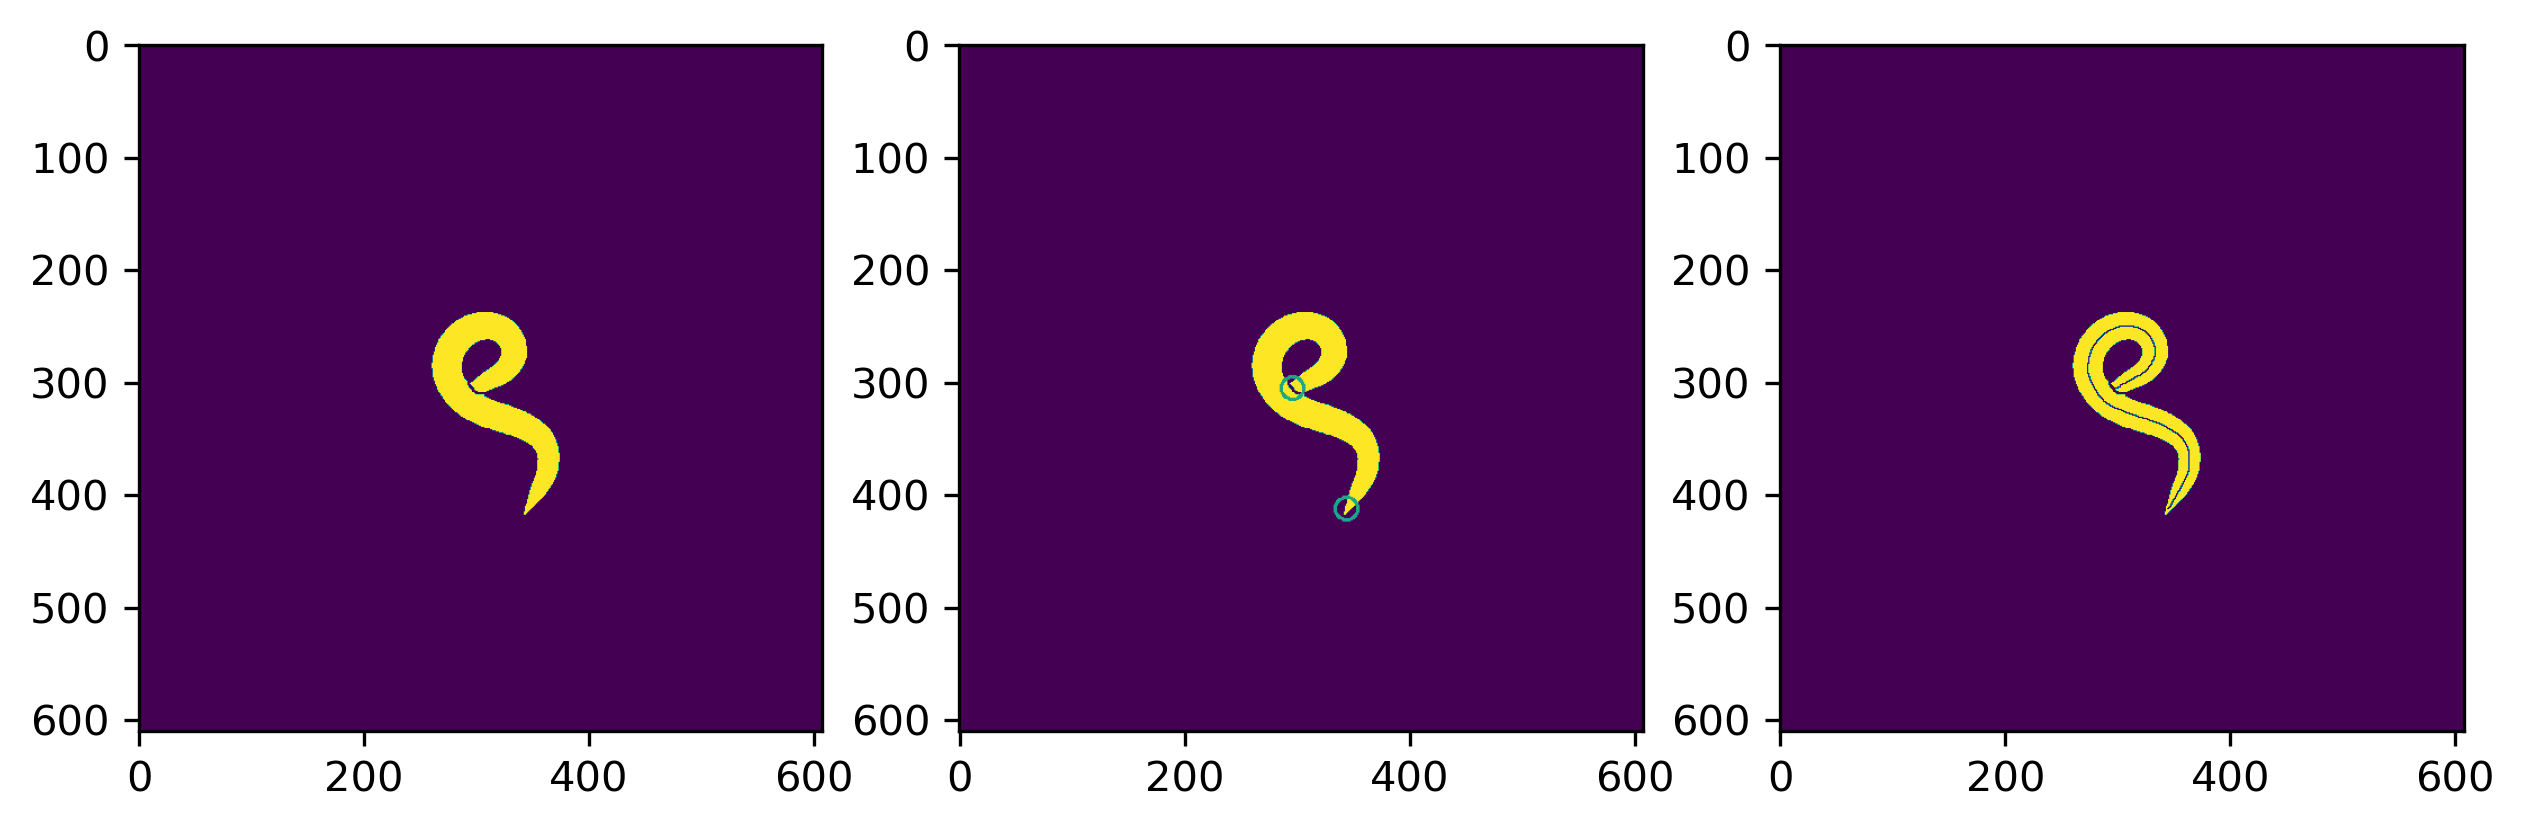

img27799.tif


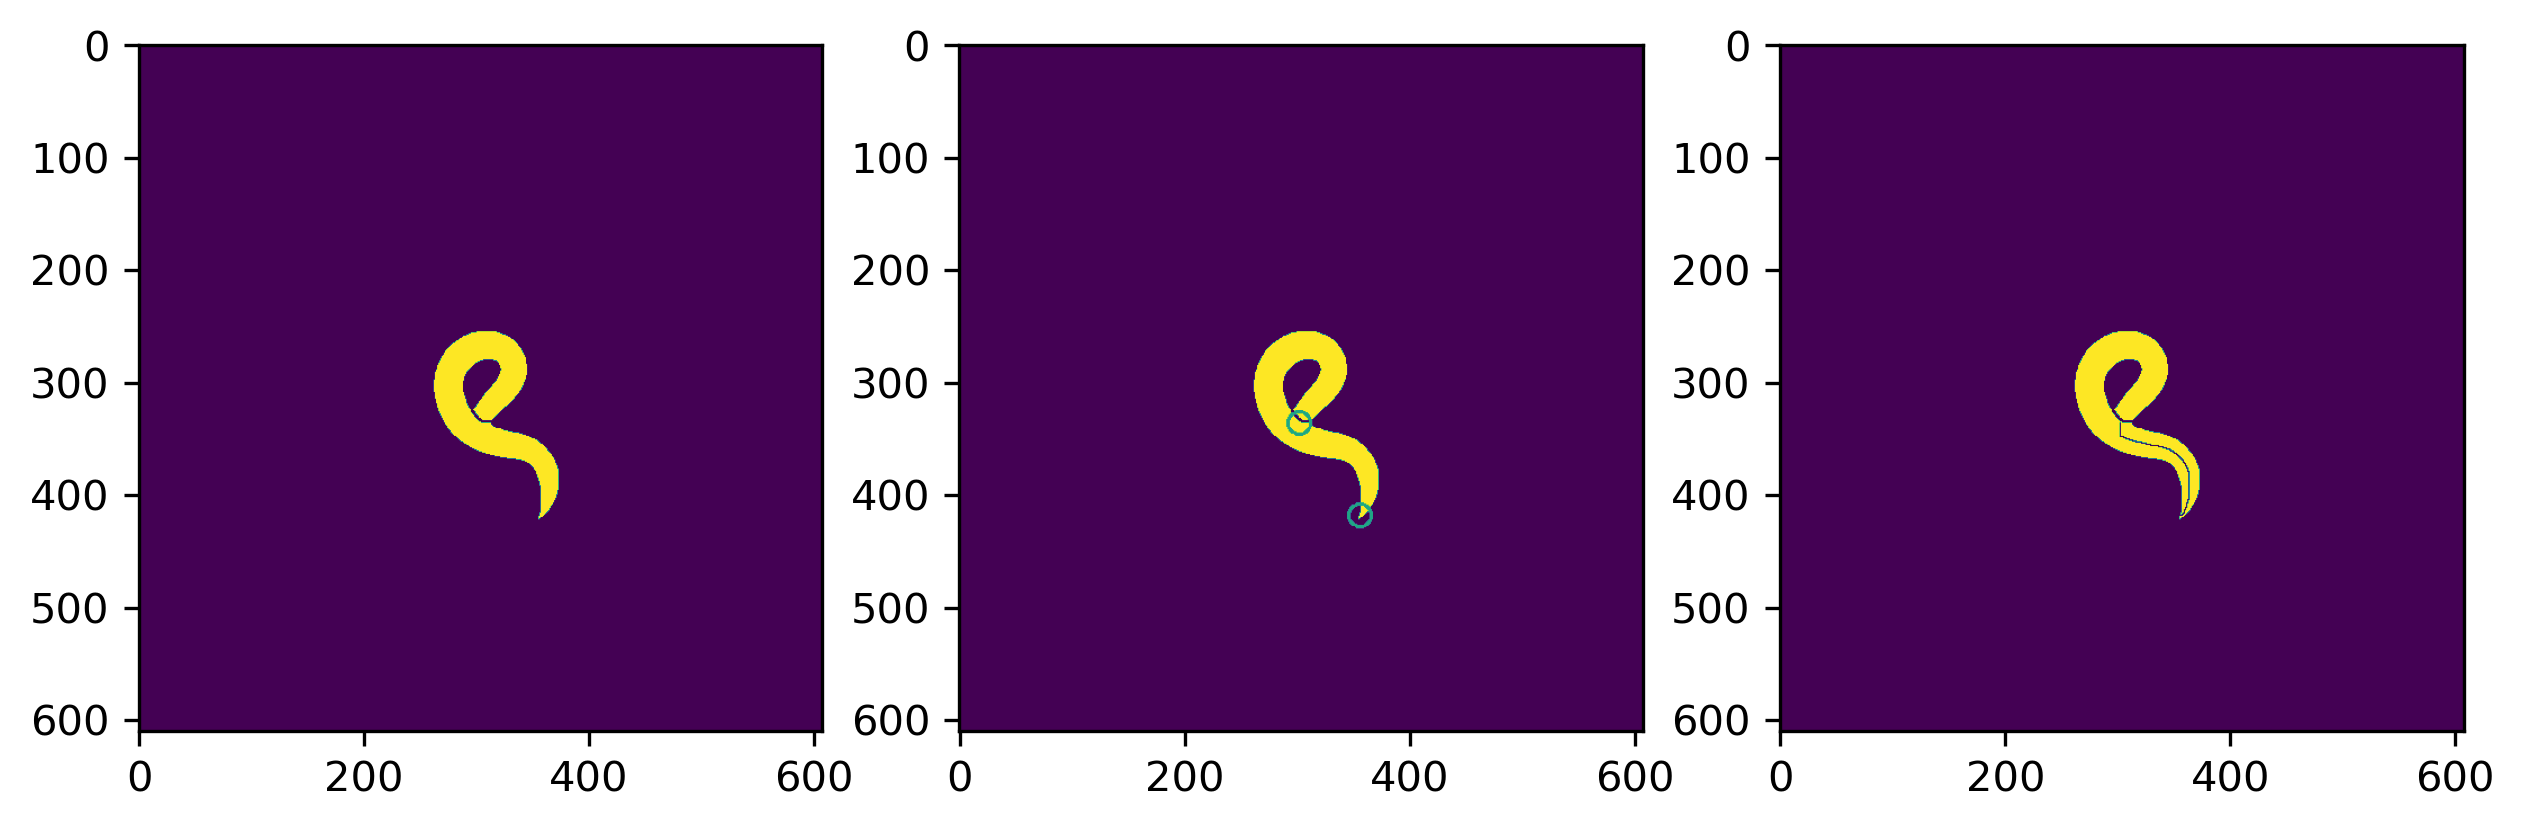

img27859.tif
head and tail were too close, no centerline could be created
img27919.tif


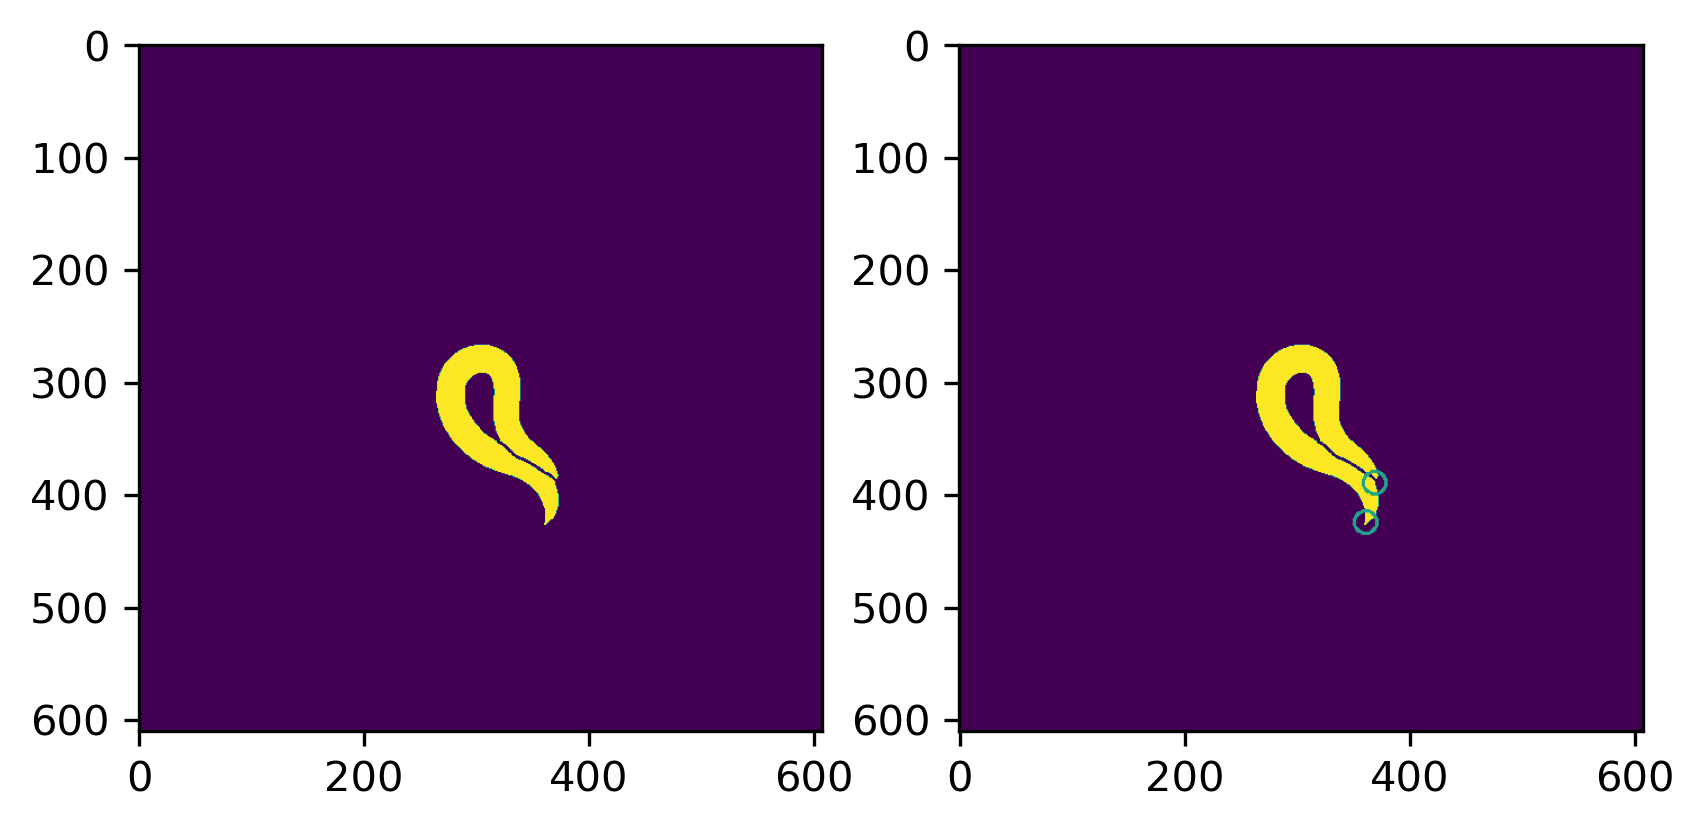

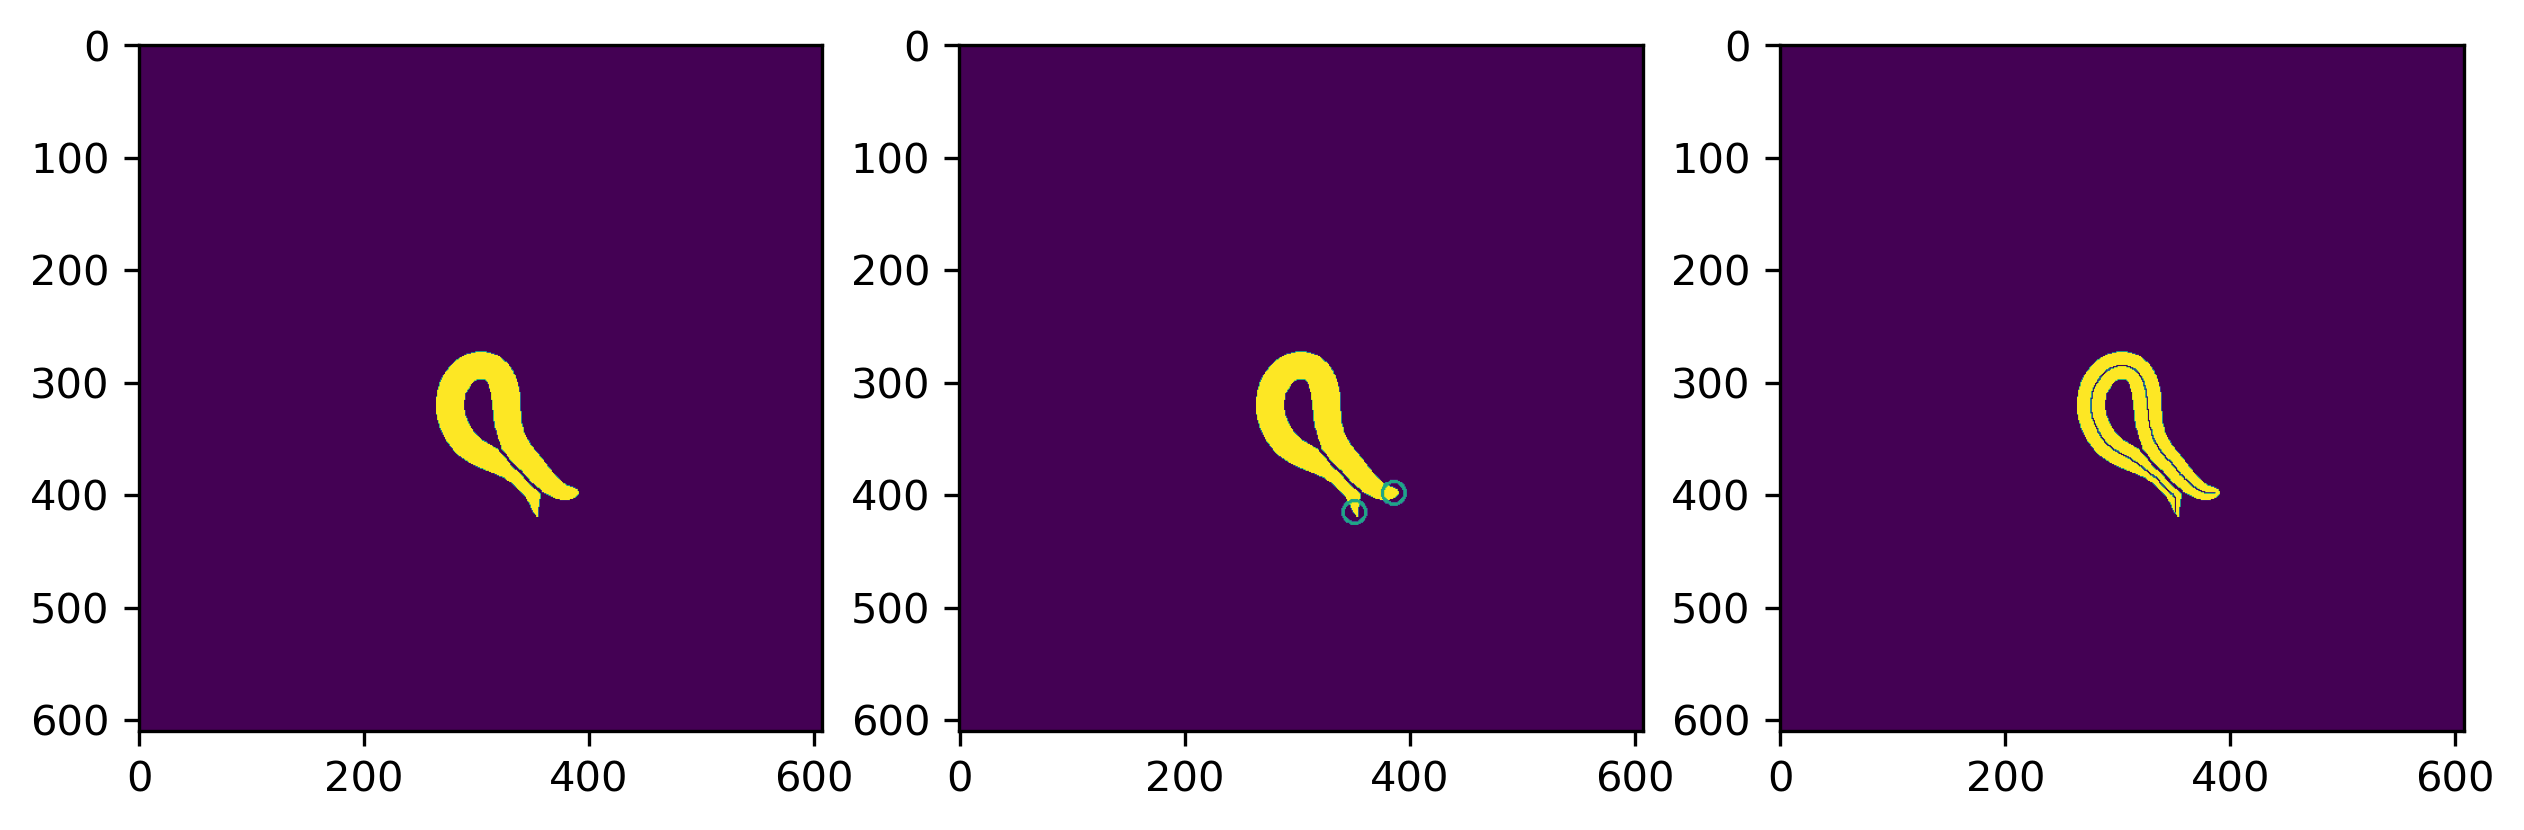

img27979.tif


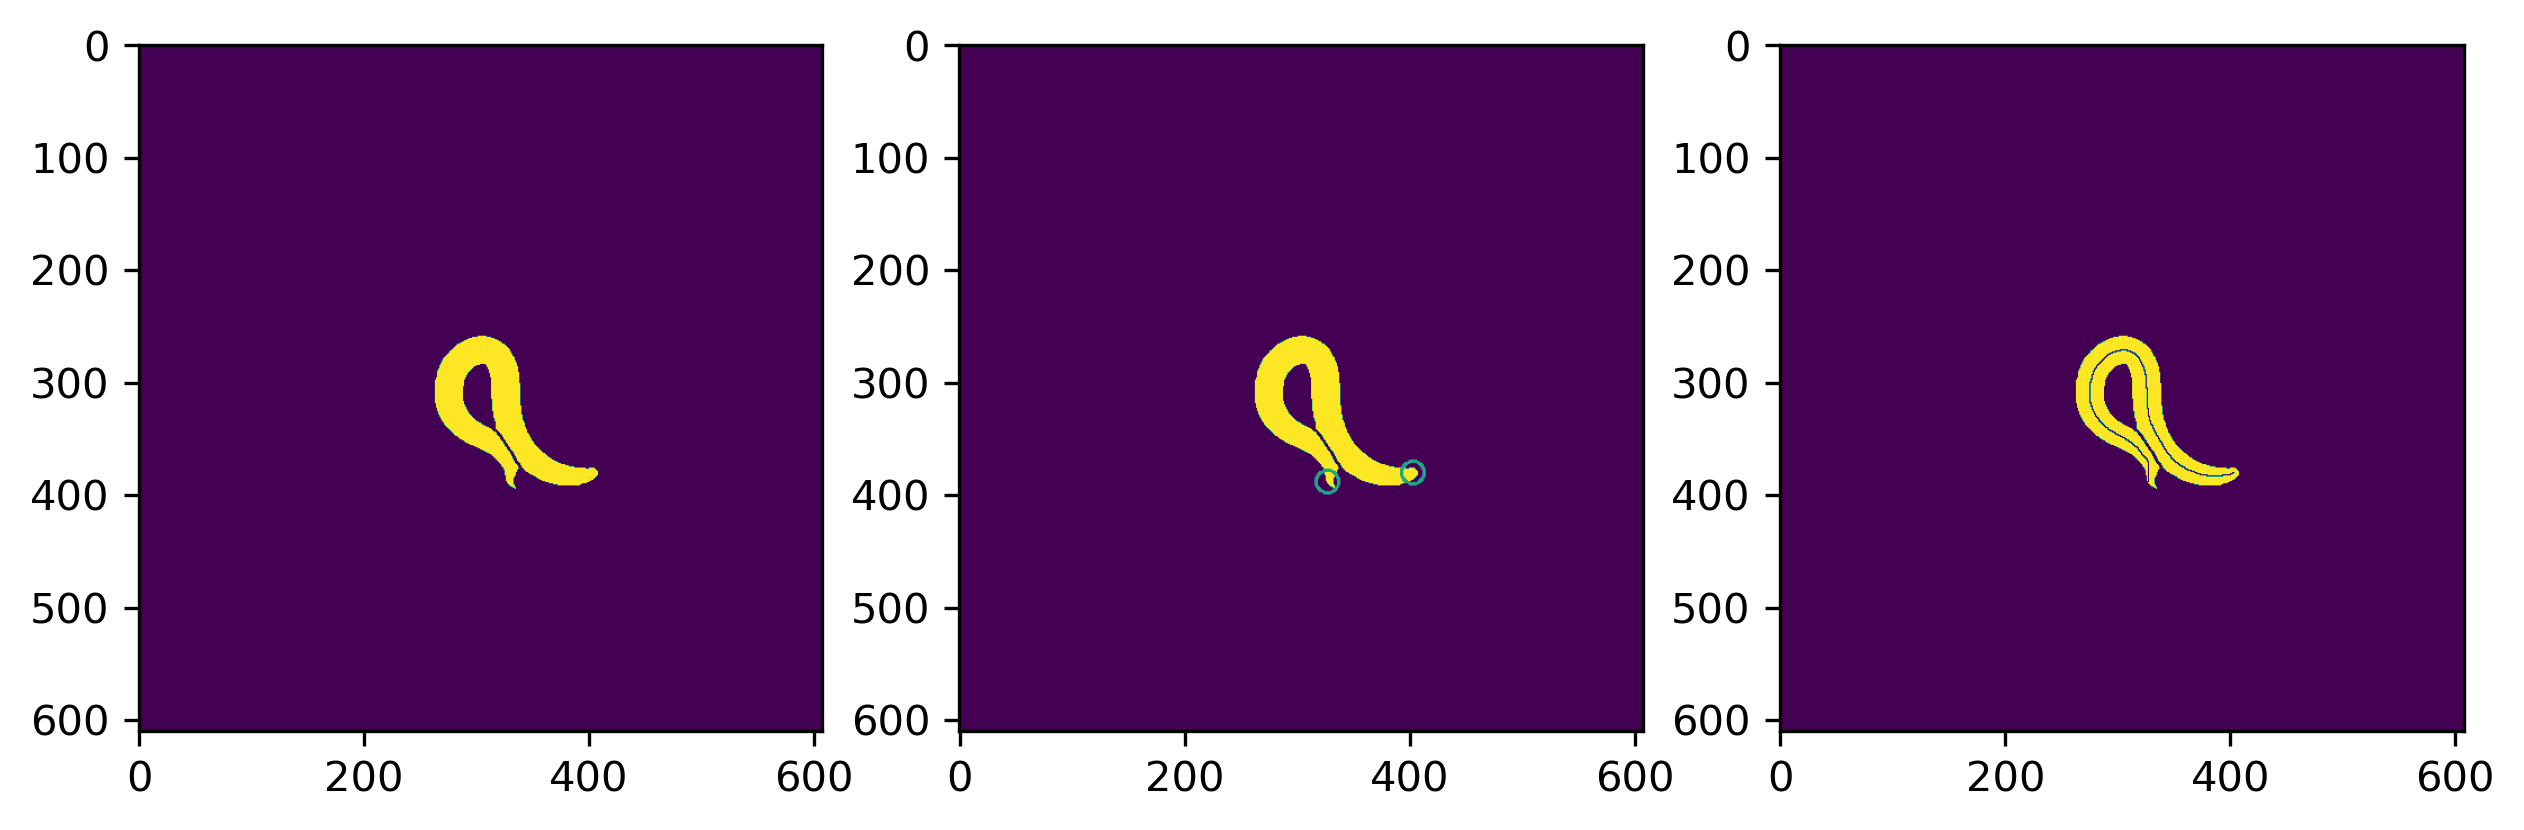

img28039.tif


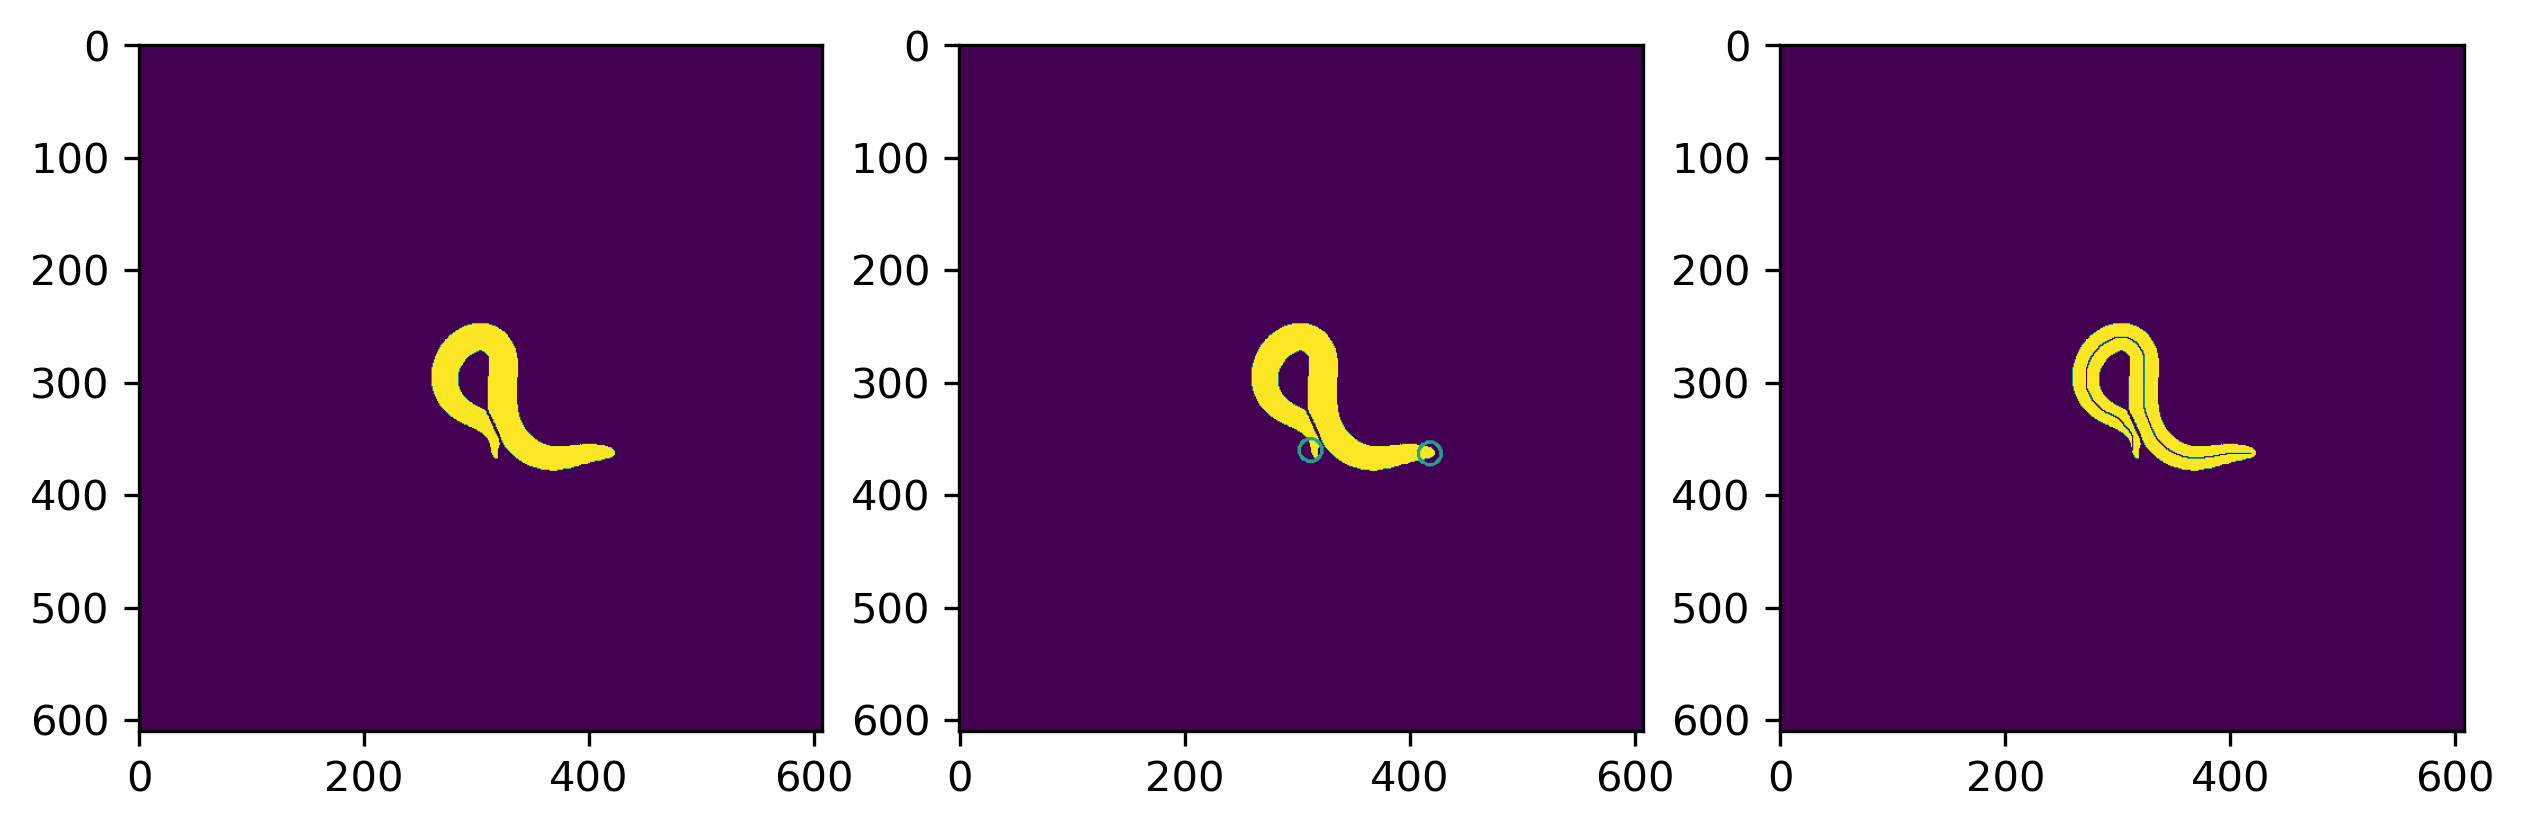

img28099.tif


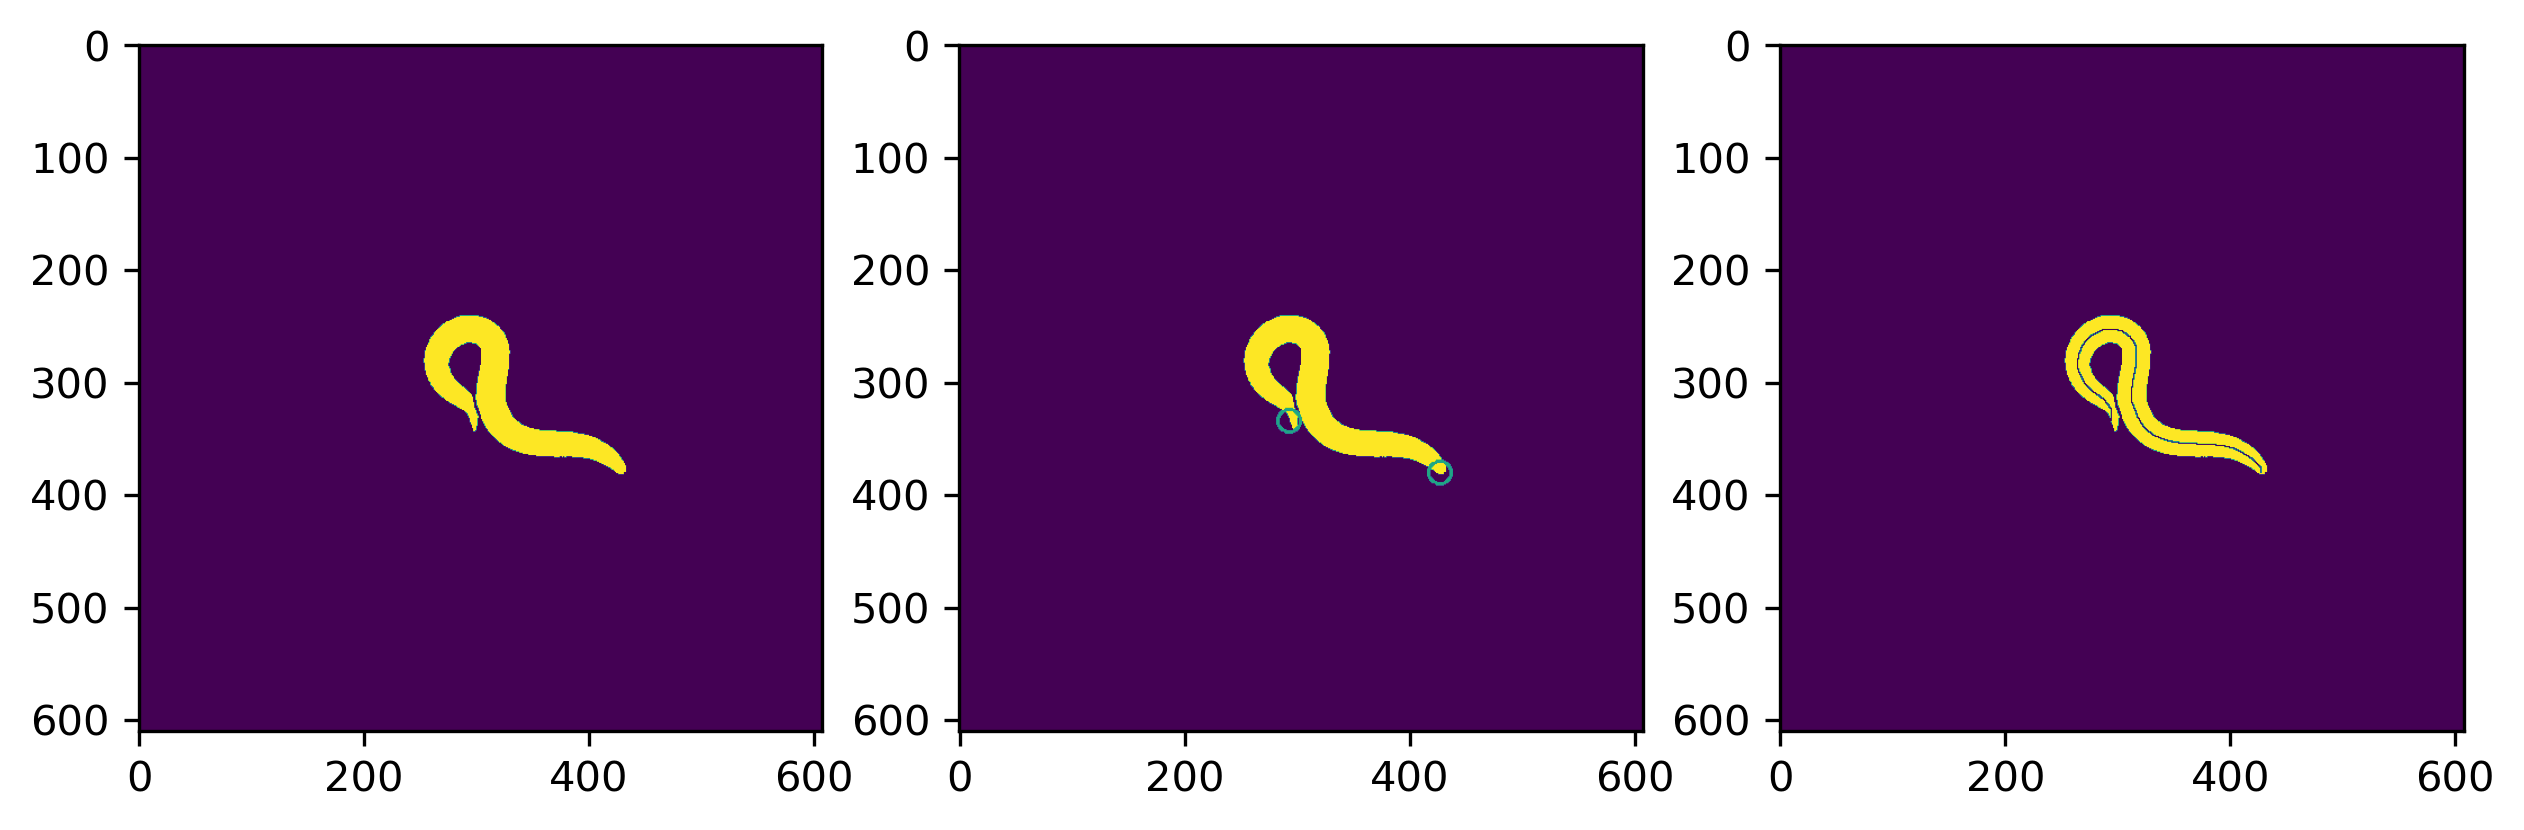

img34797.tif


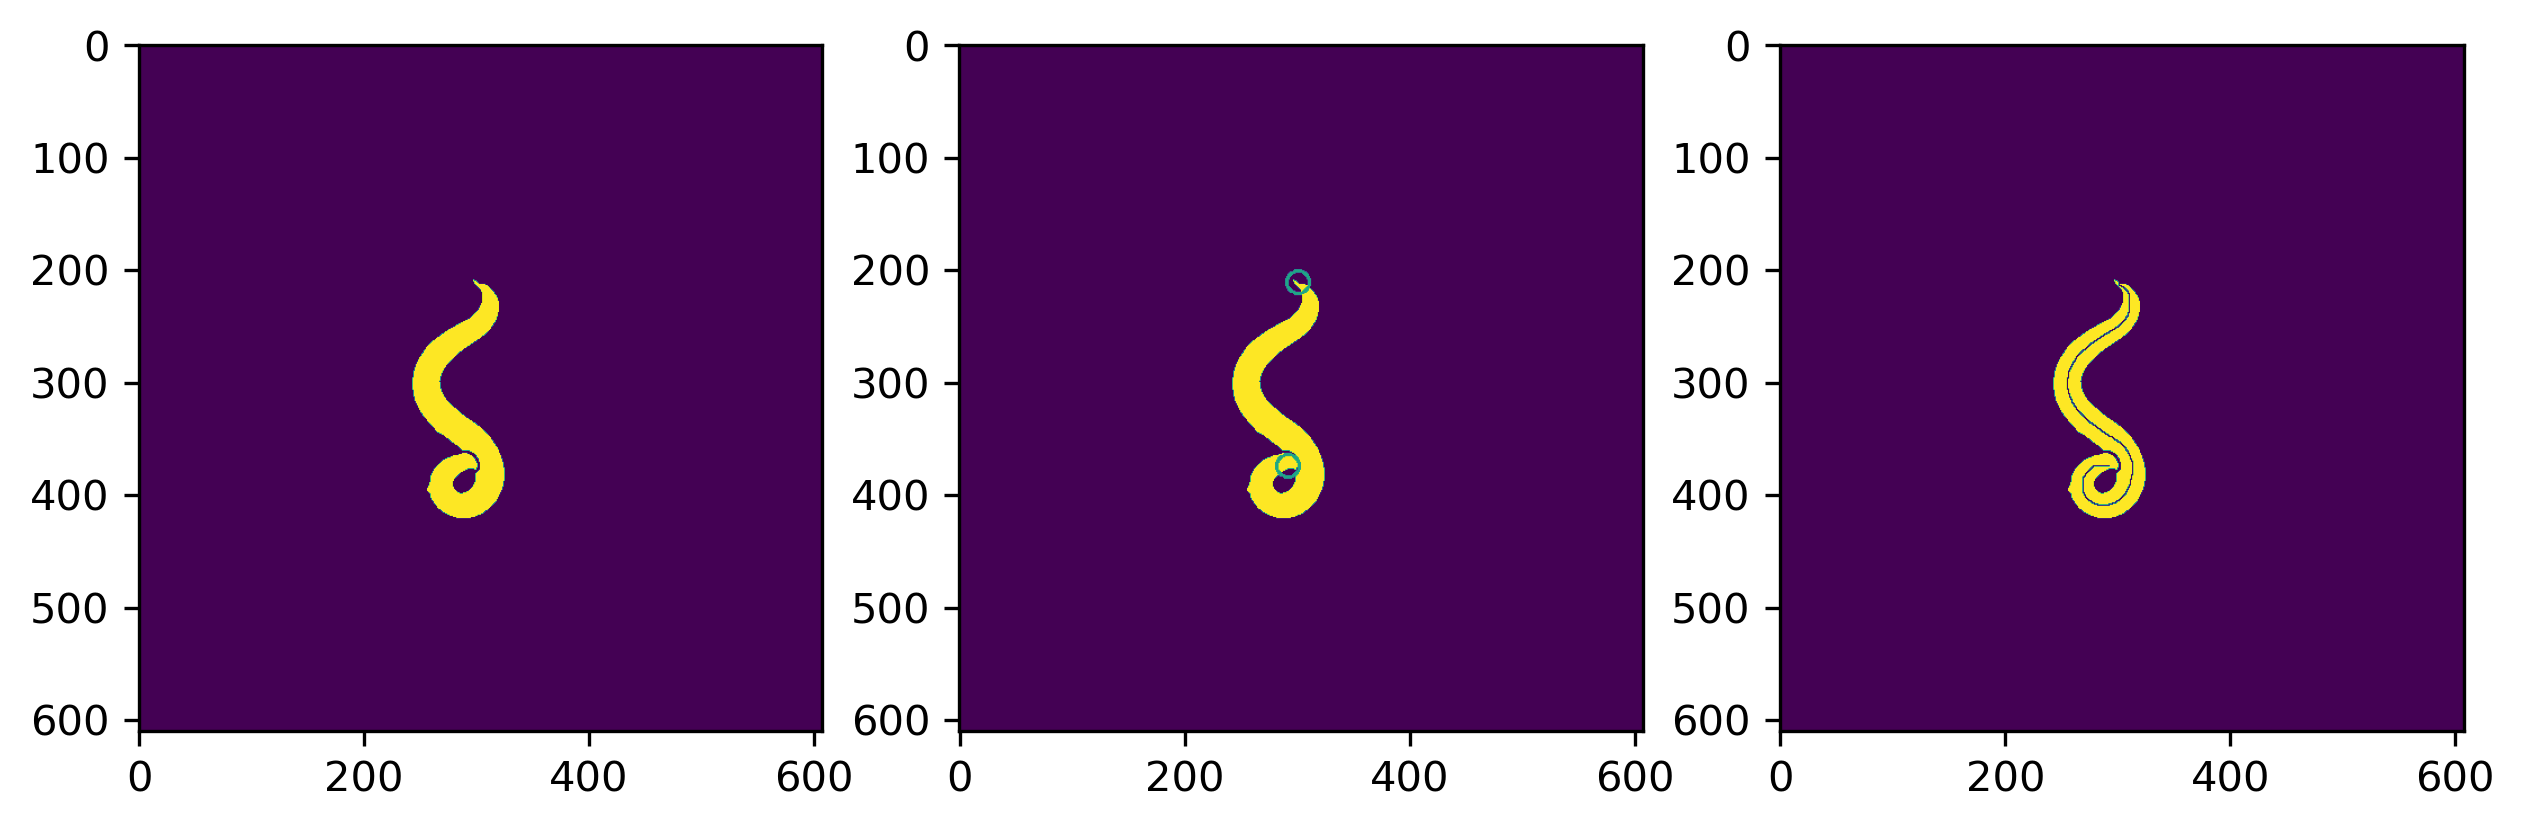

img34917.tif


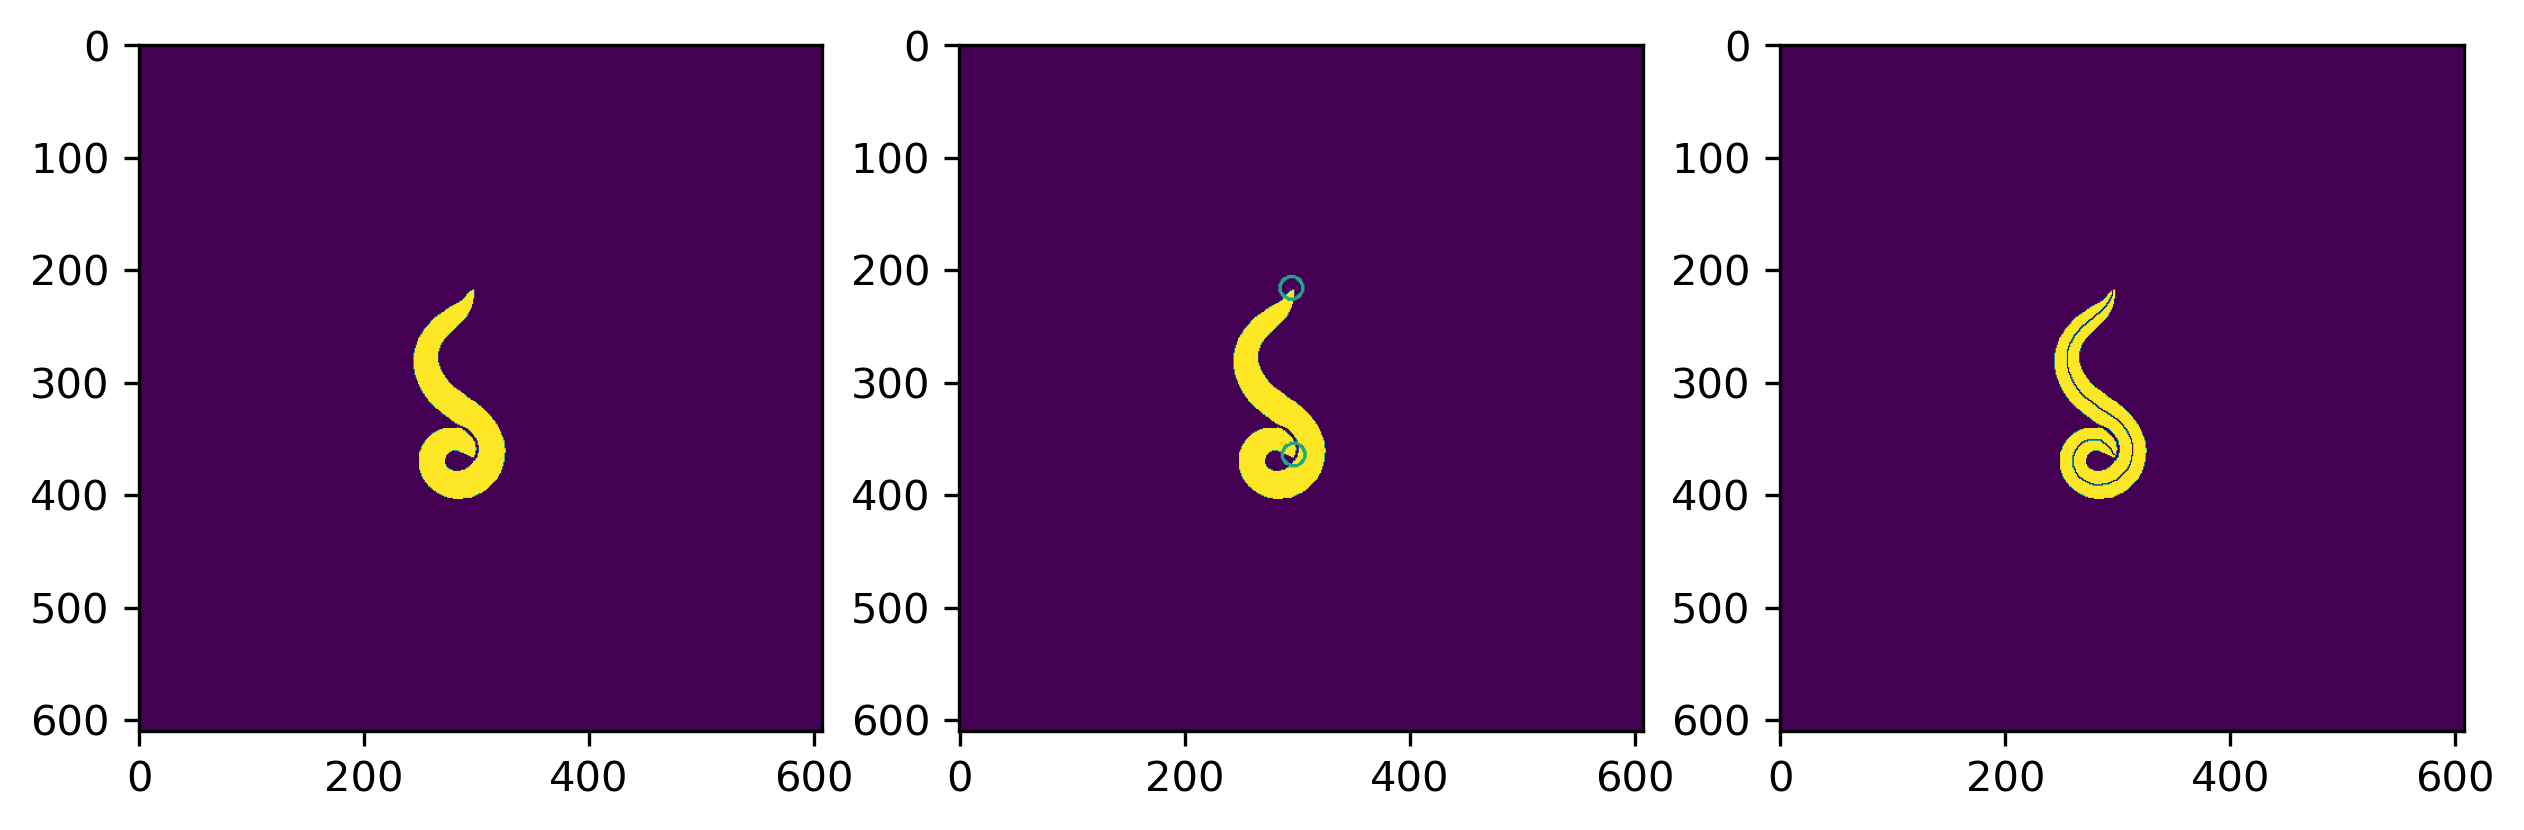

img34977.tif
head and tail were too close, no centerline could be created
img35037.tif
head and tail were too close, no centerline could be created
img35097.tif
head and tail were too close, no centerline could be created
img35157.tif
head and tail were too close, no centerline could be created
img35217.tif


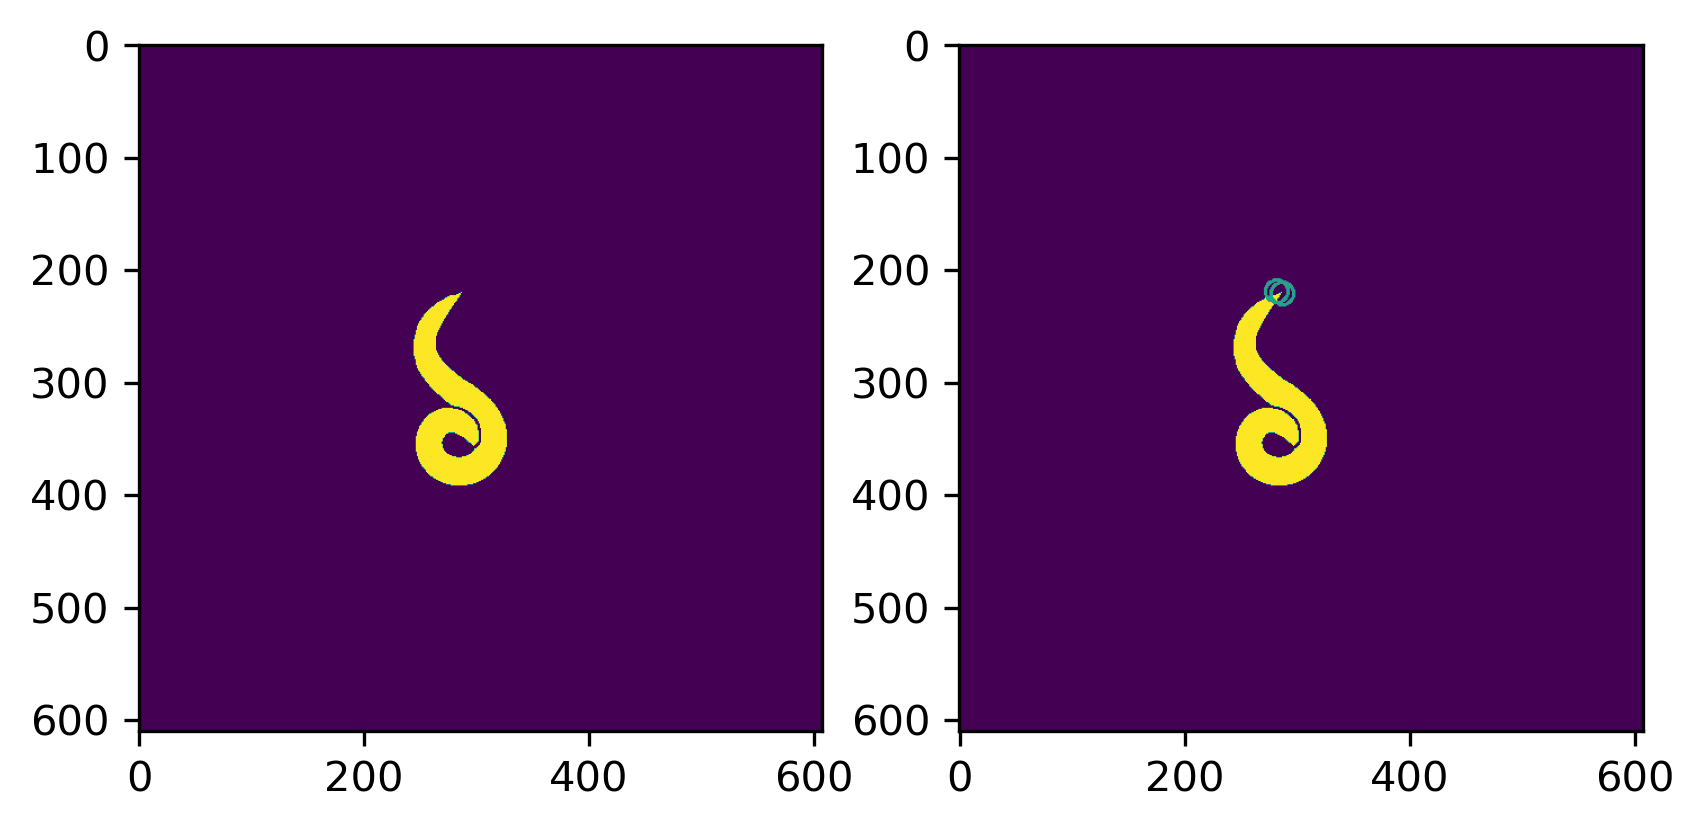

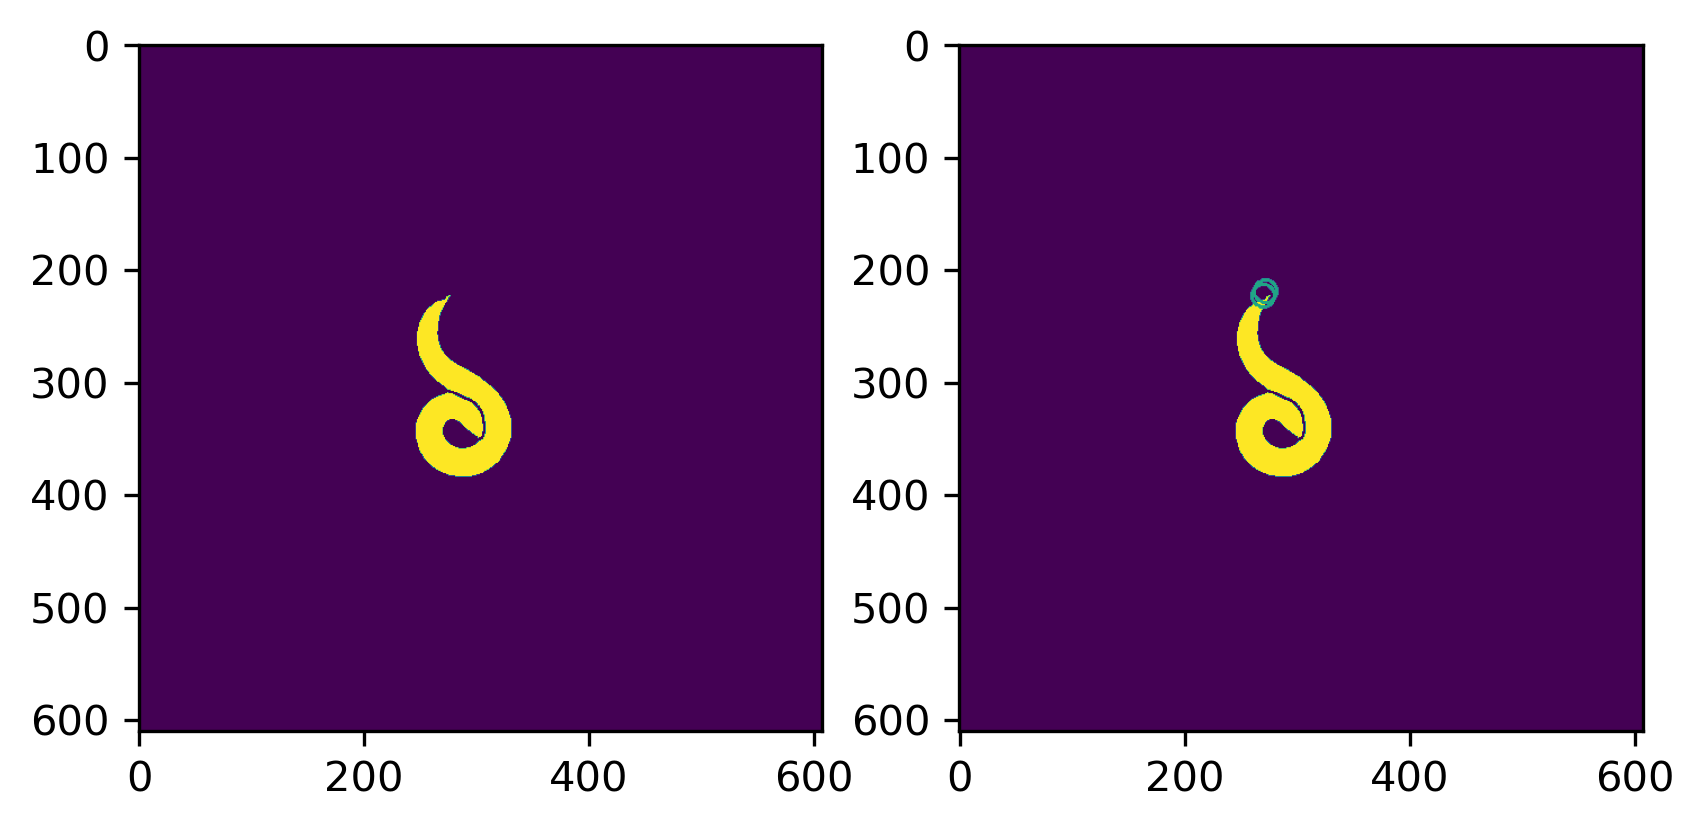

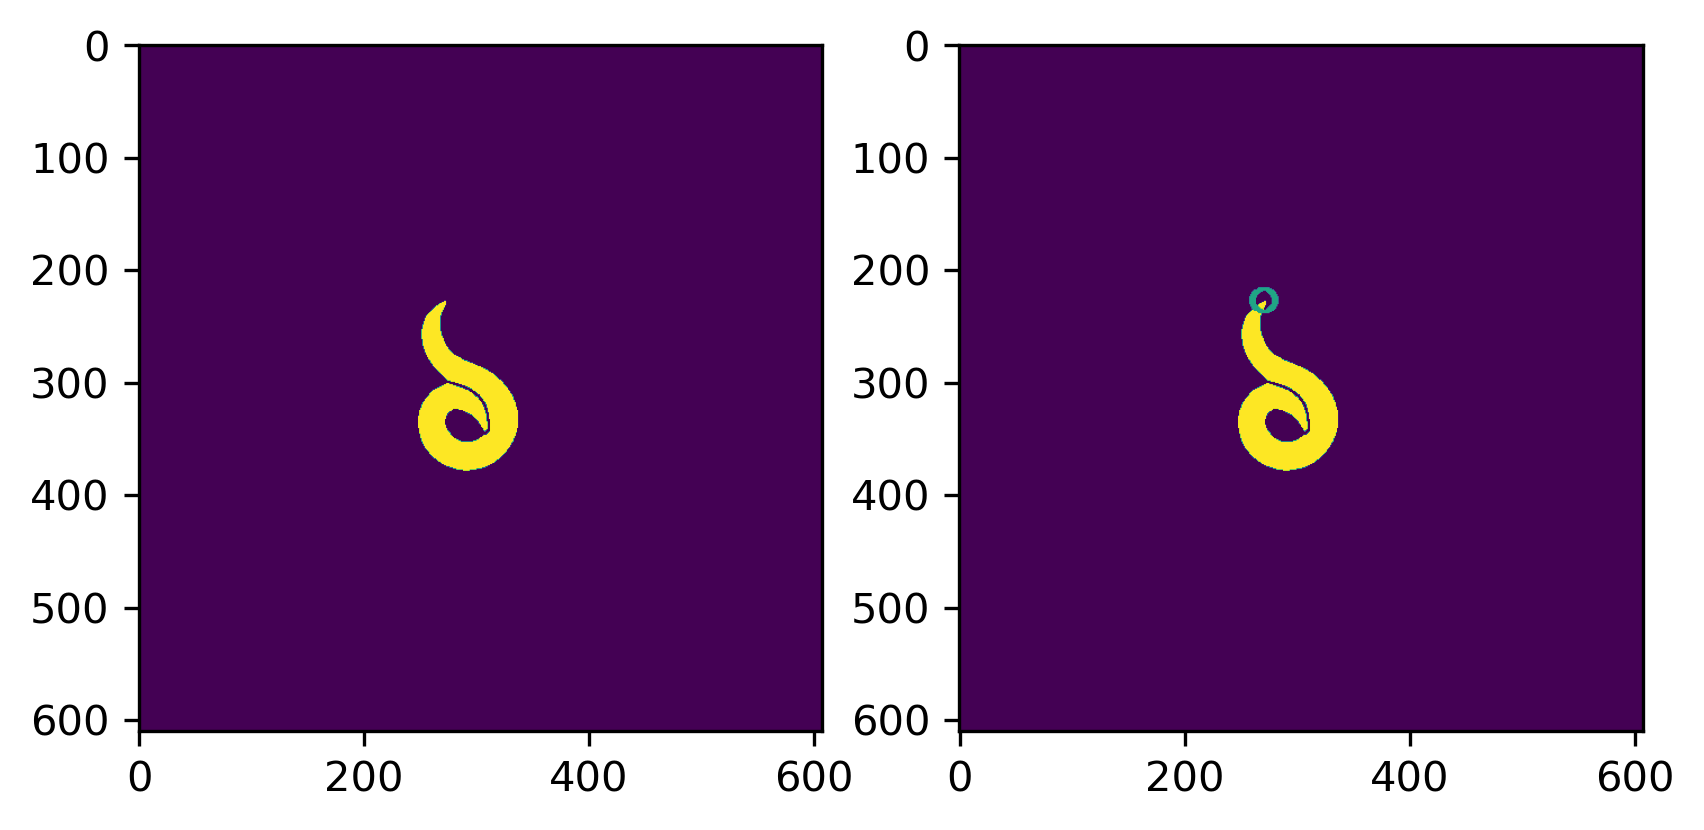

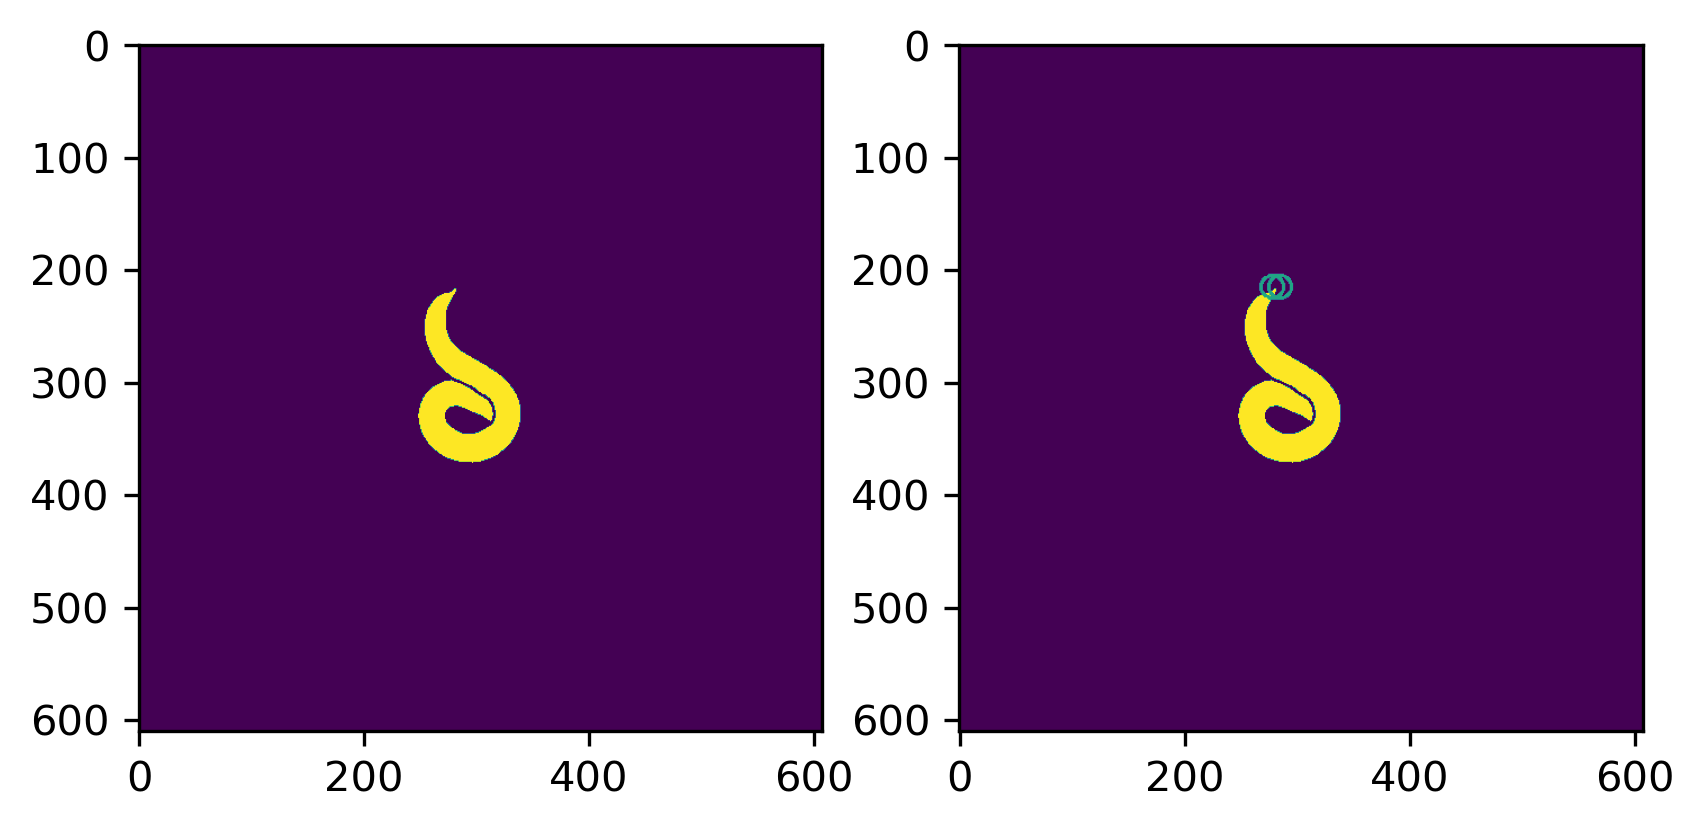

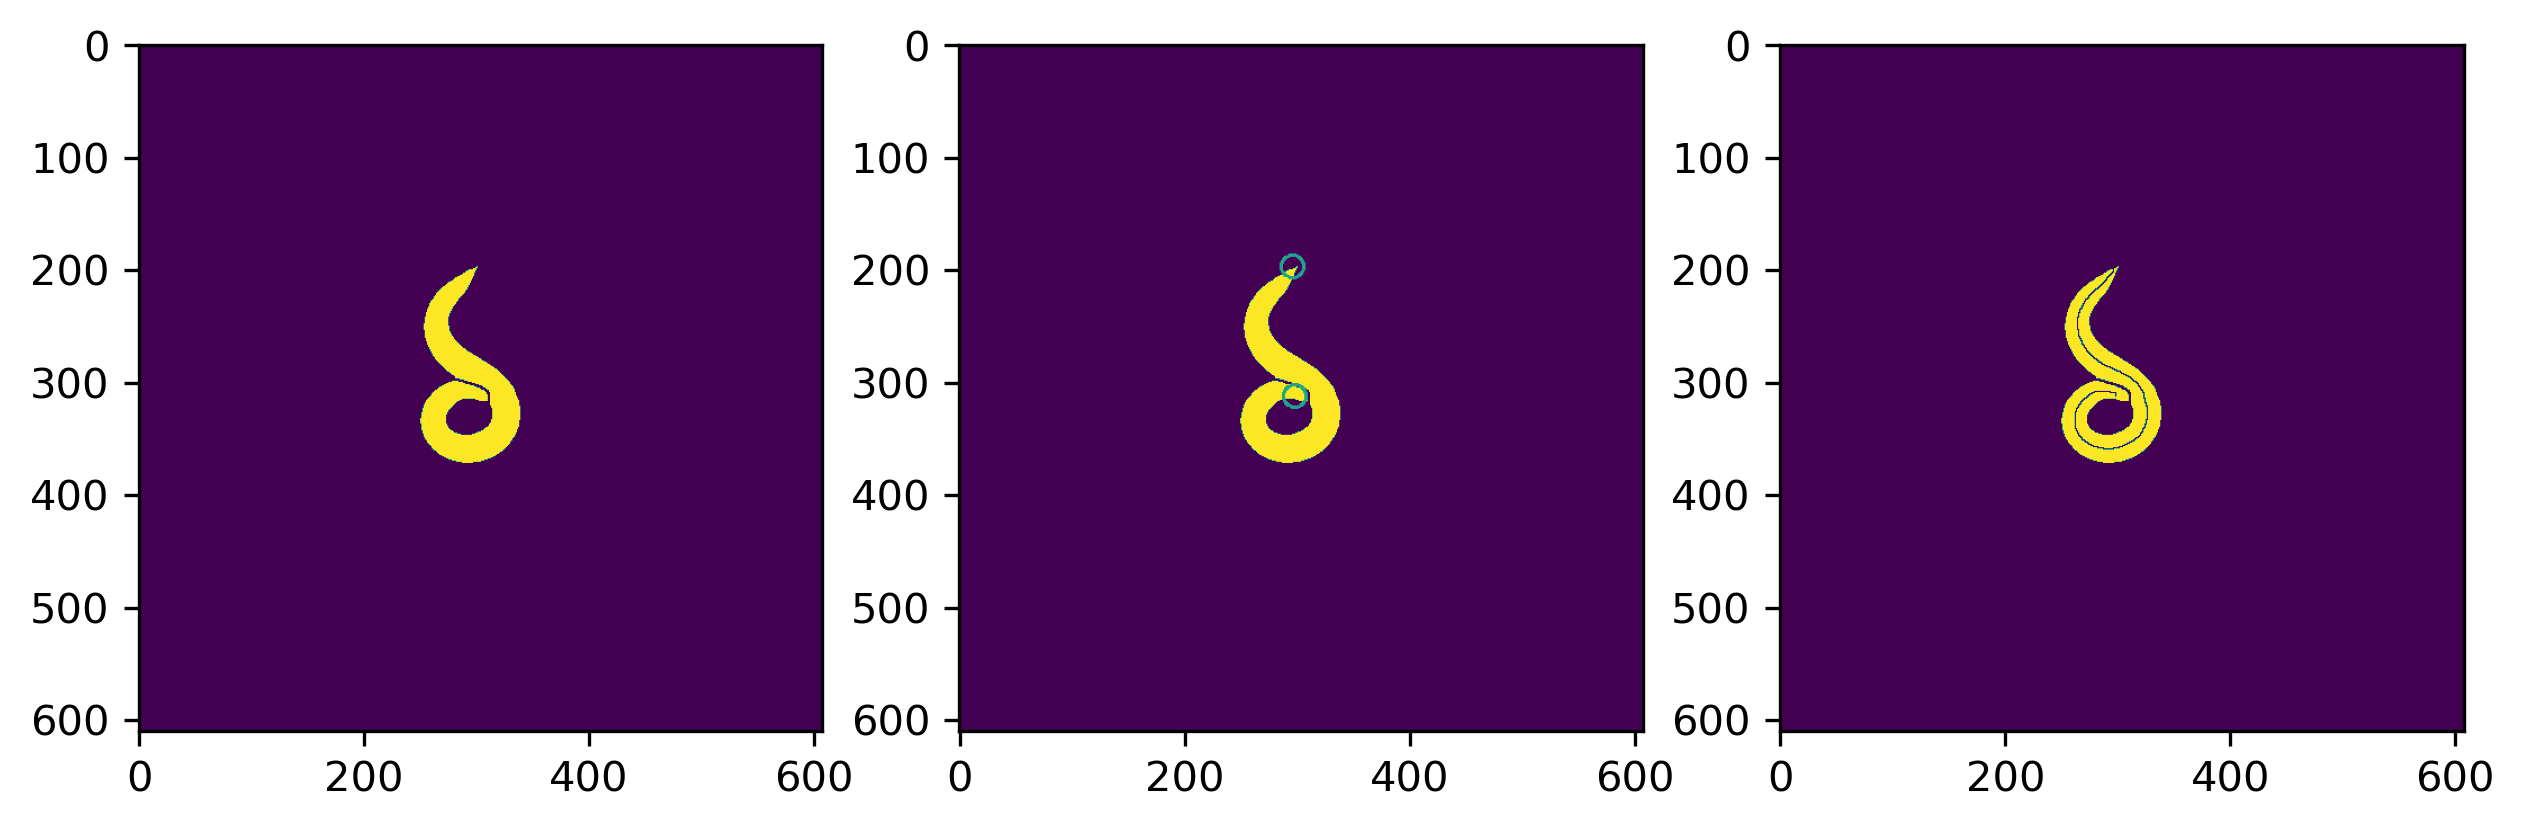

img35277.tif


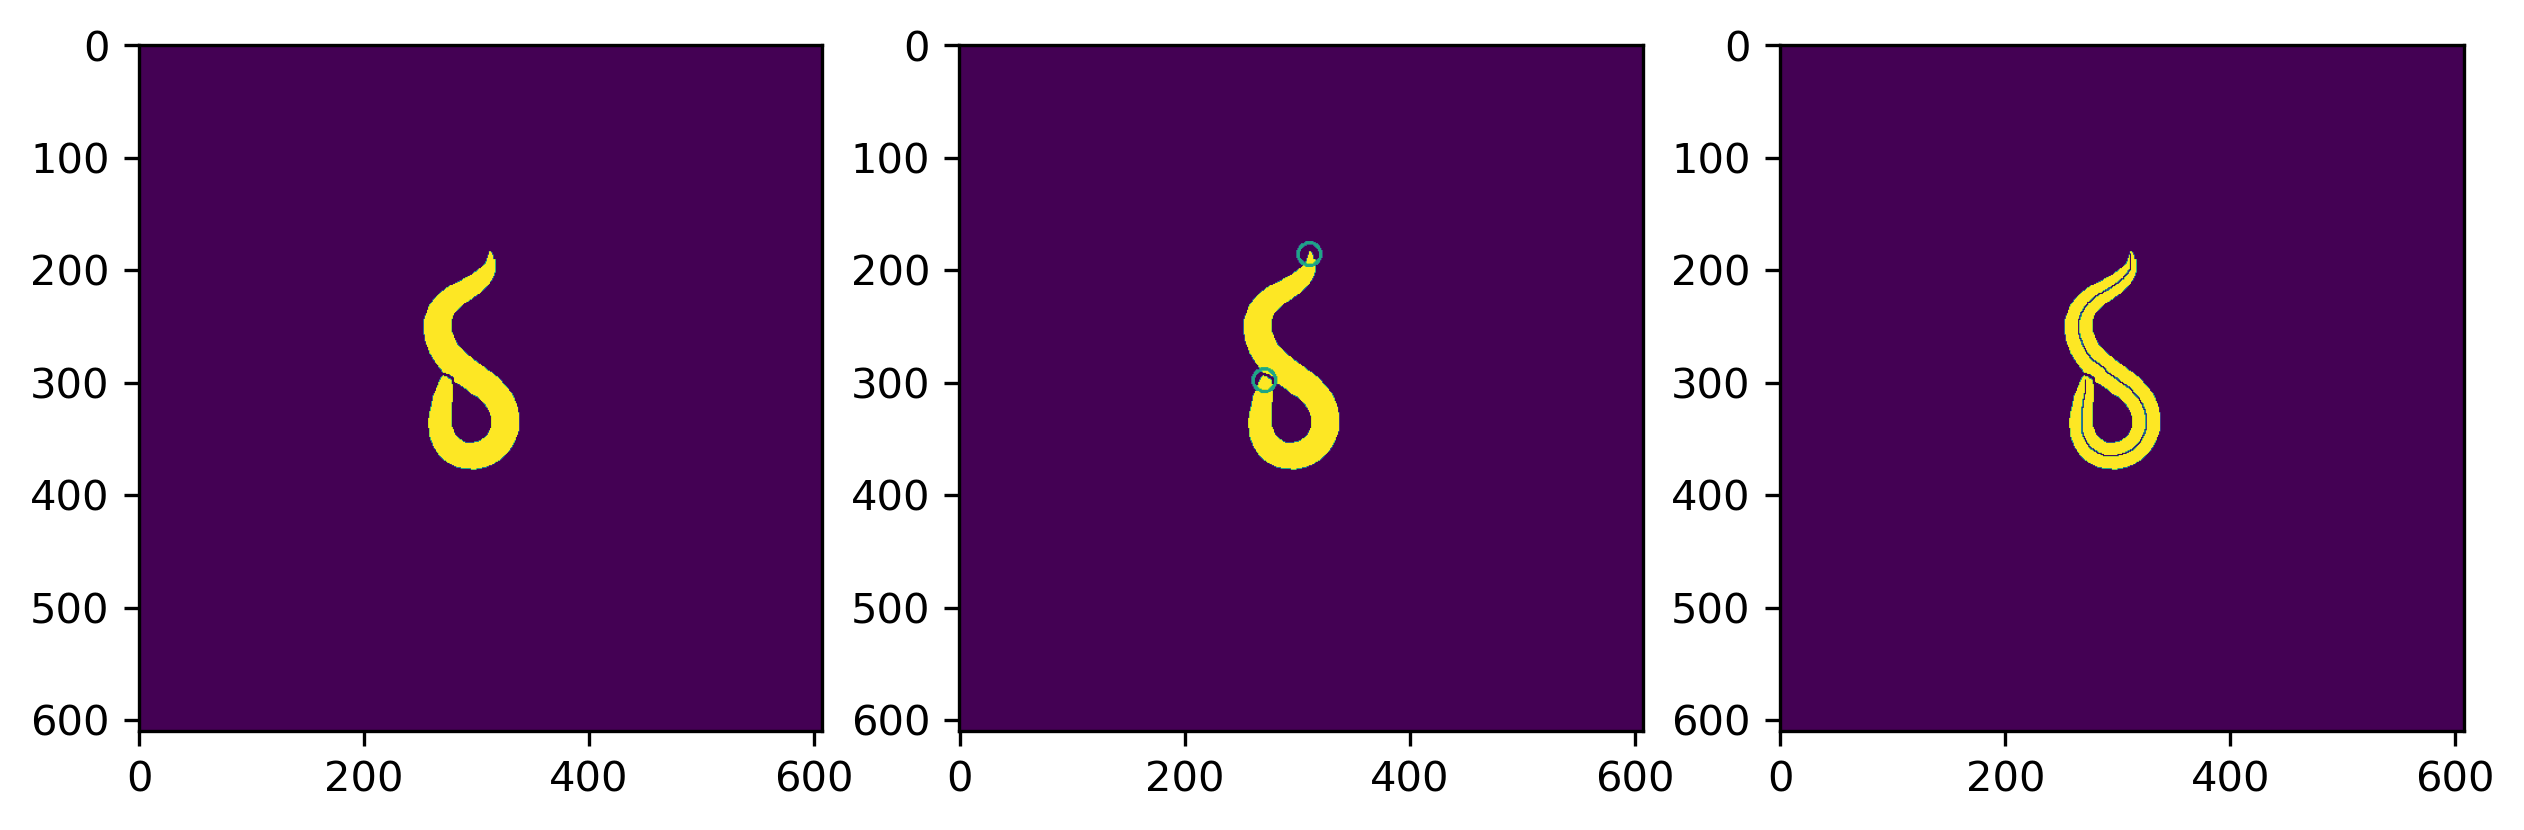

img39802.tif
head and tail were too close, no centerline could be created
img39862.tif
head and tail were too close, no centerline could be created
img39922.tif
head and tail were too close, no centerline could be created
img48080.tif


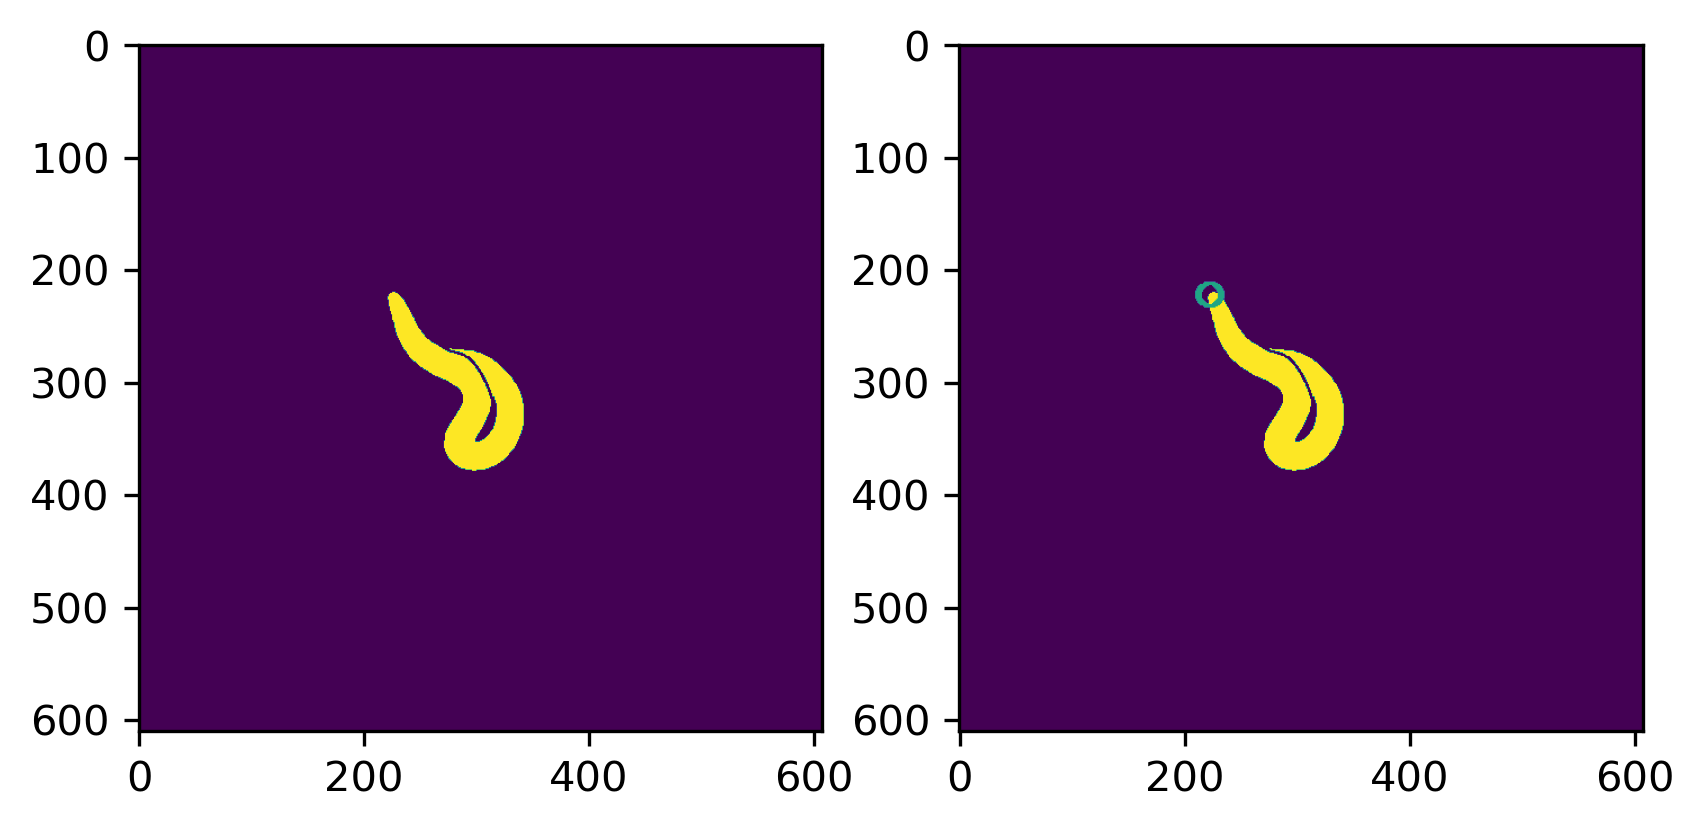

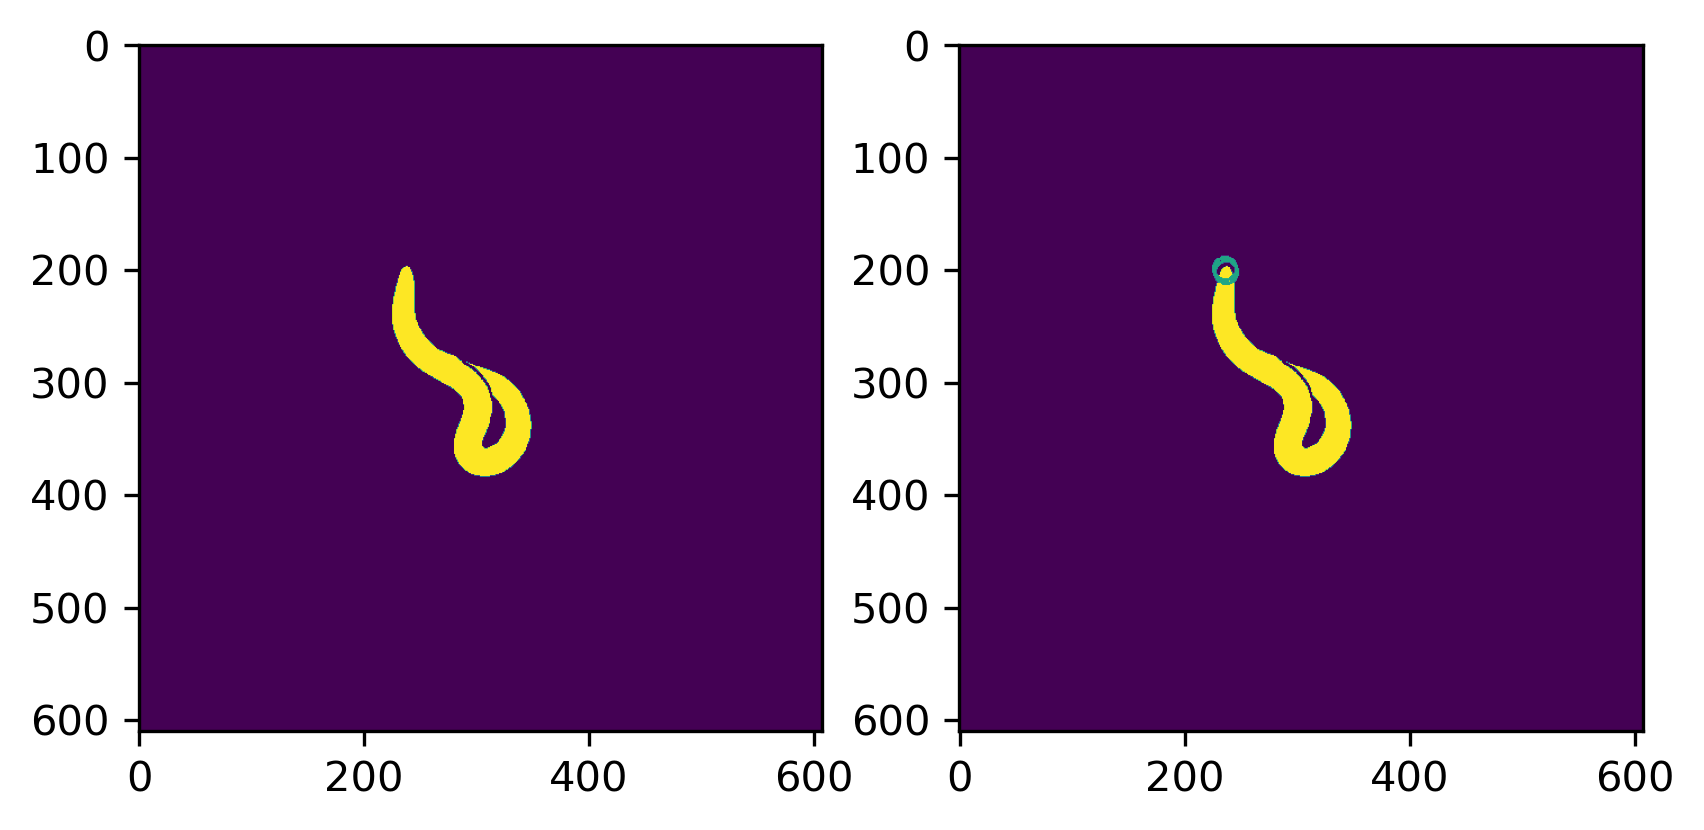

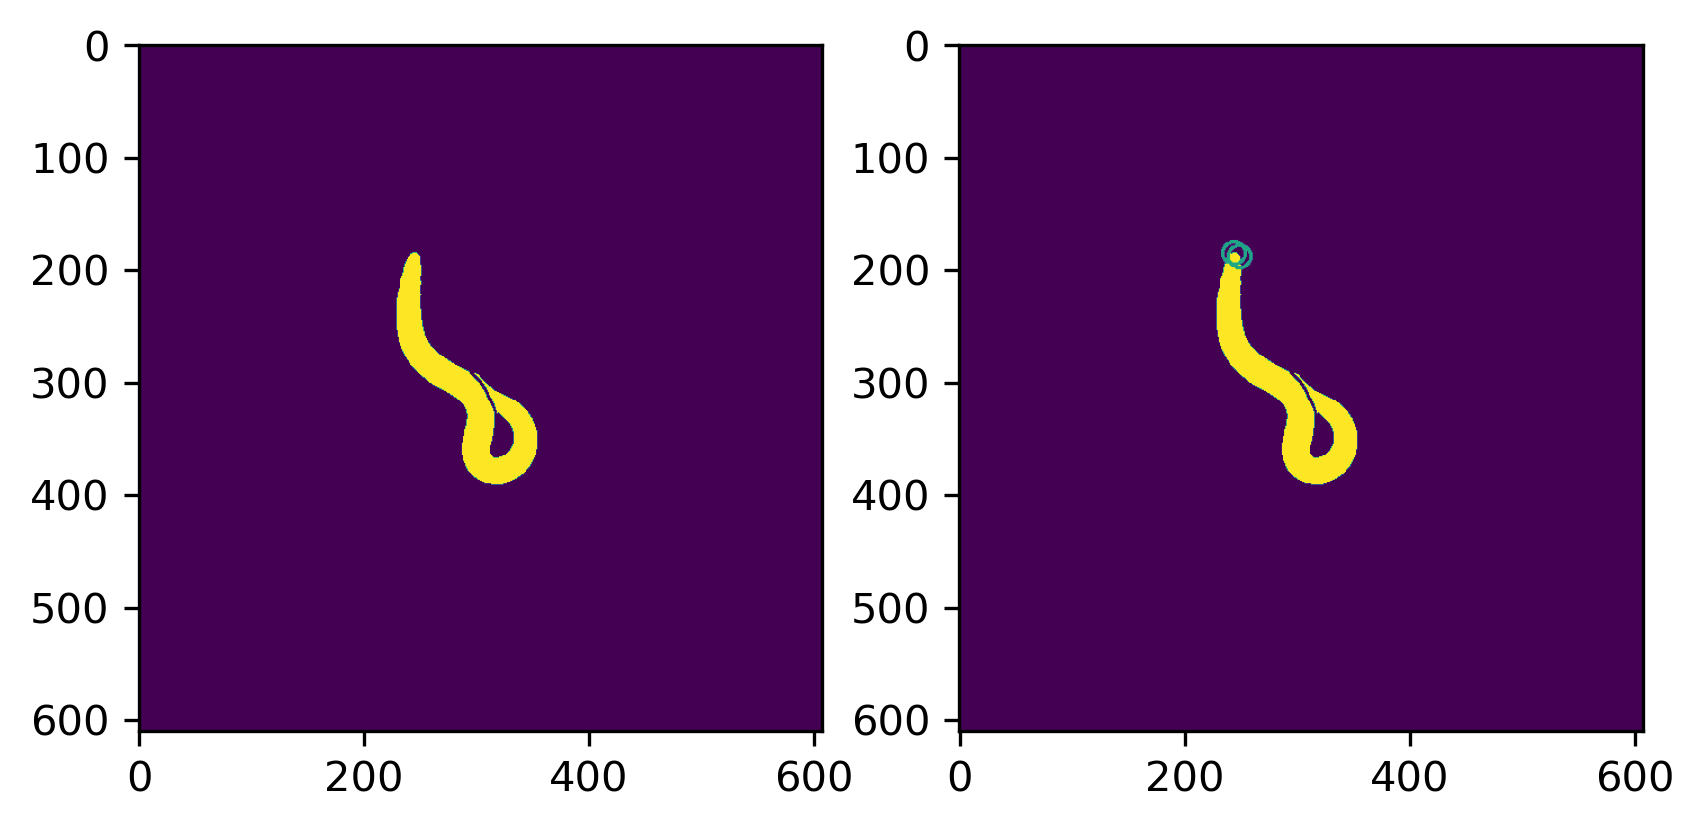

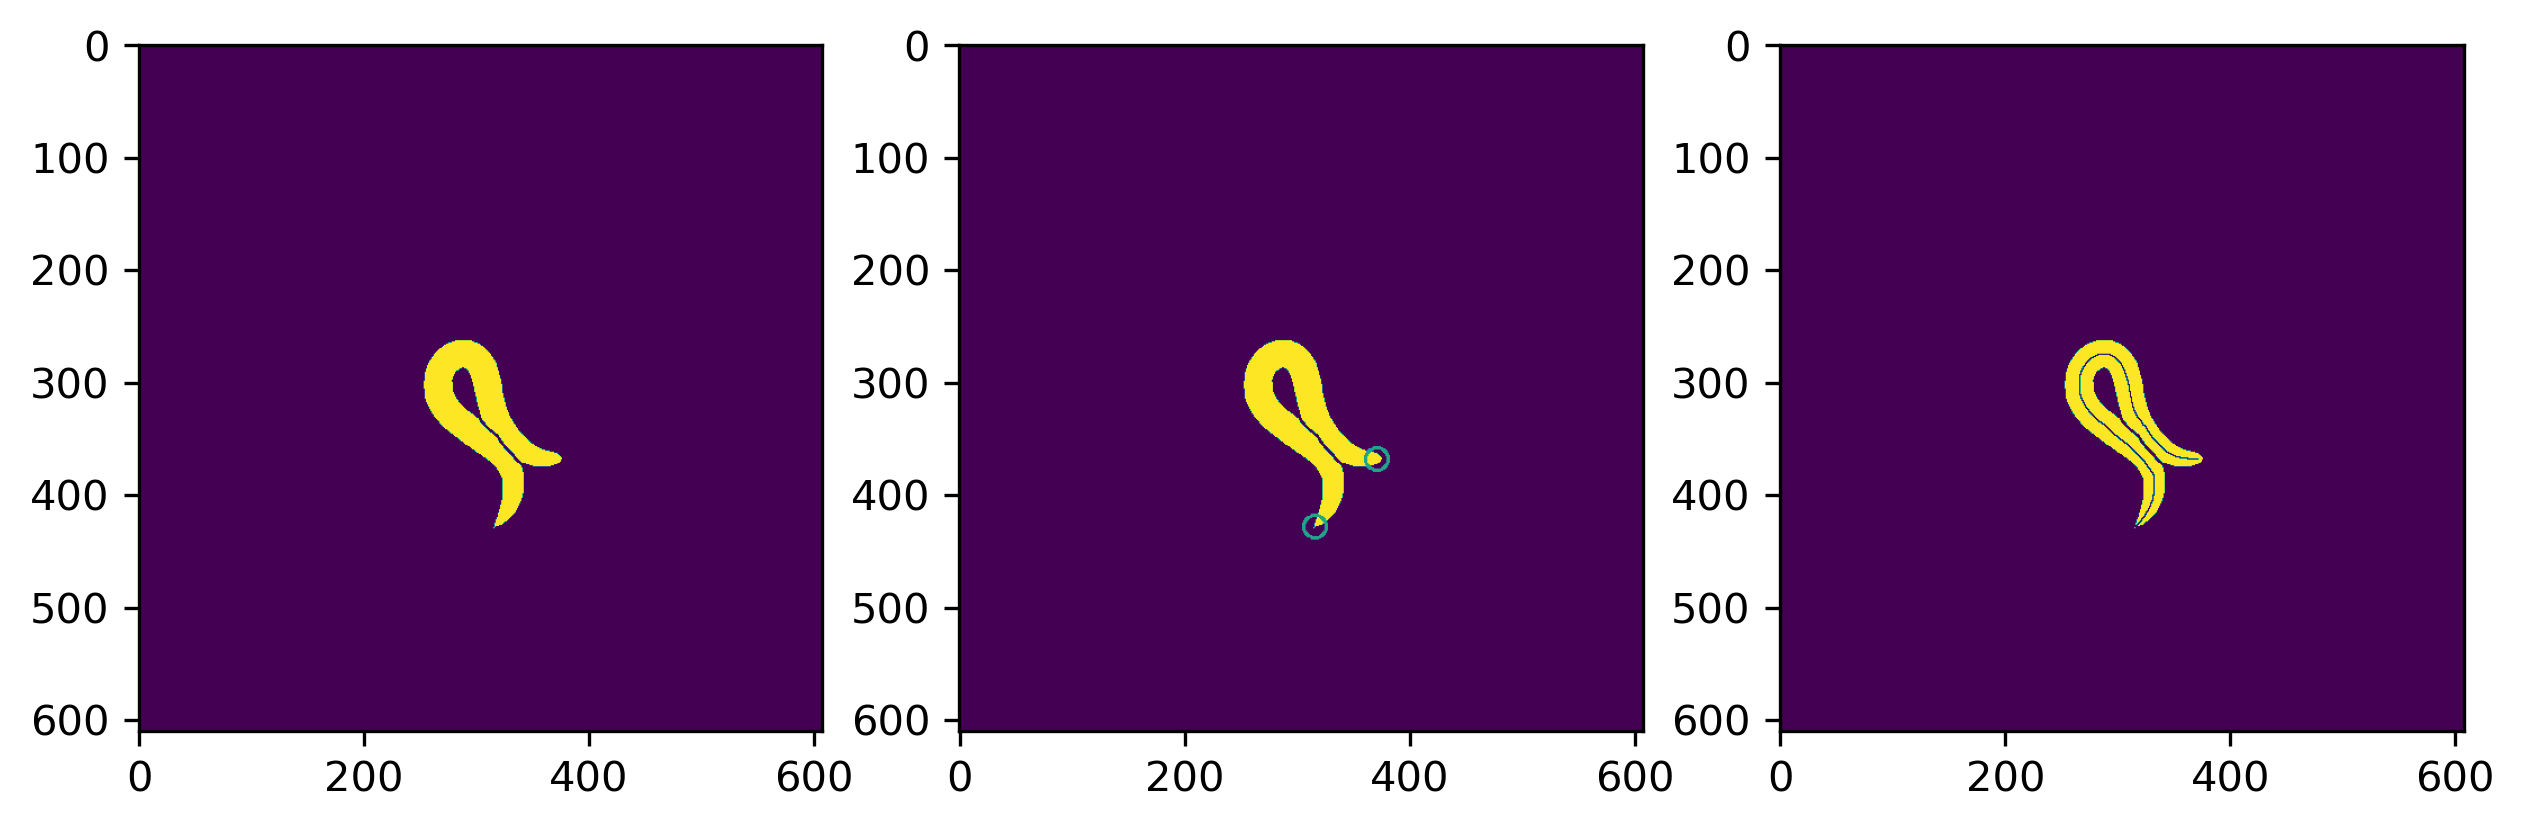

img48140.tif


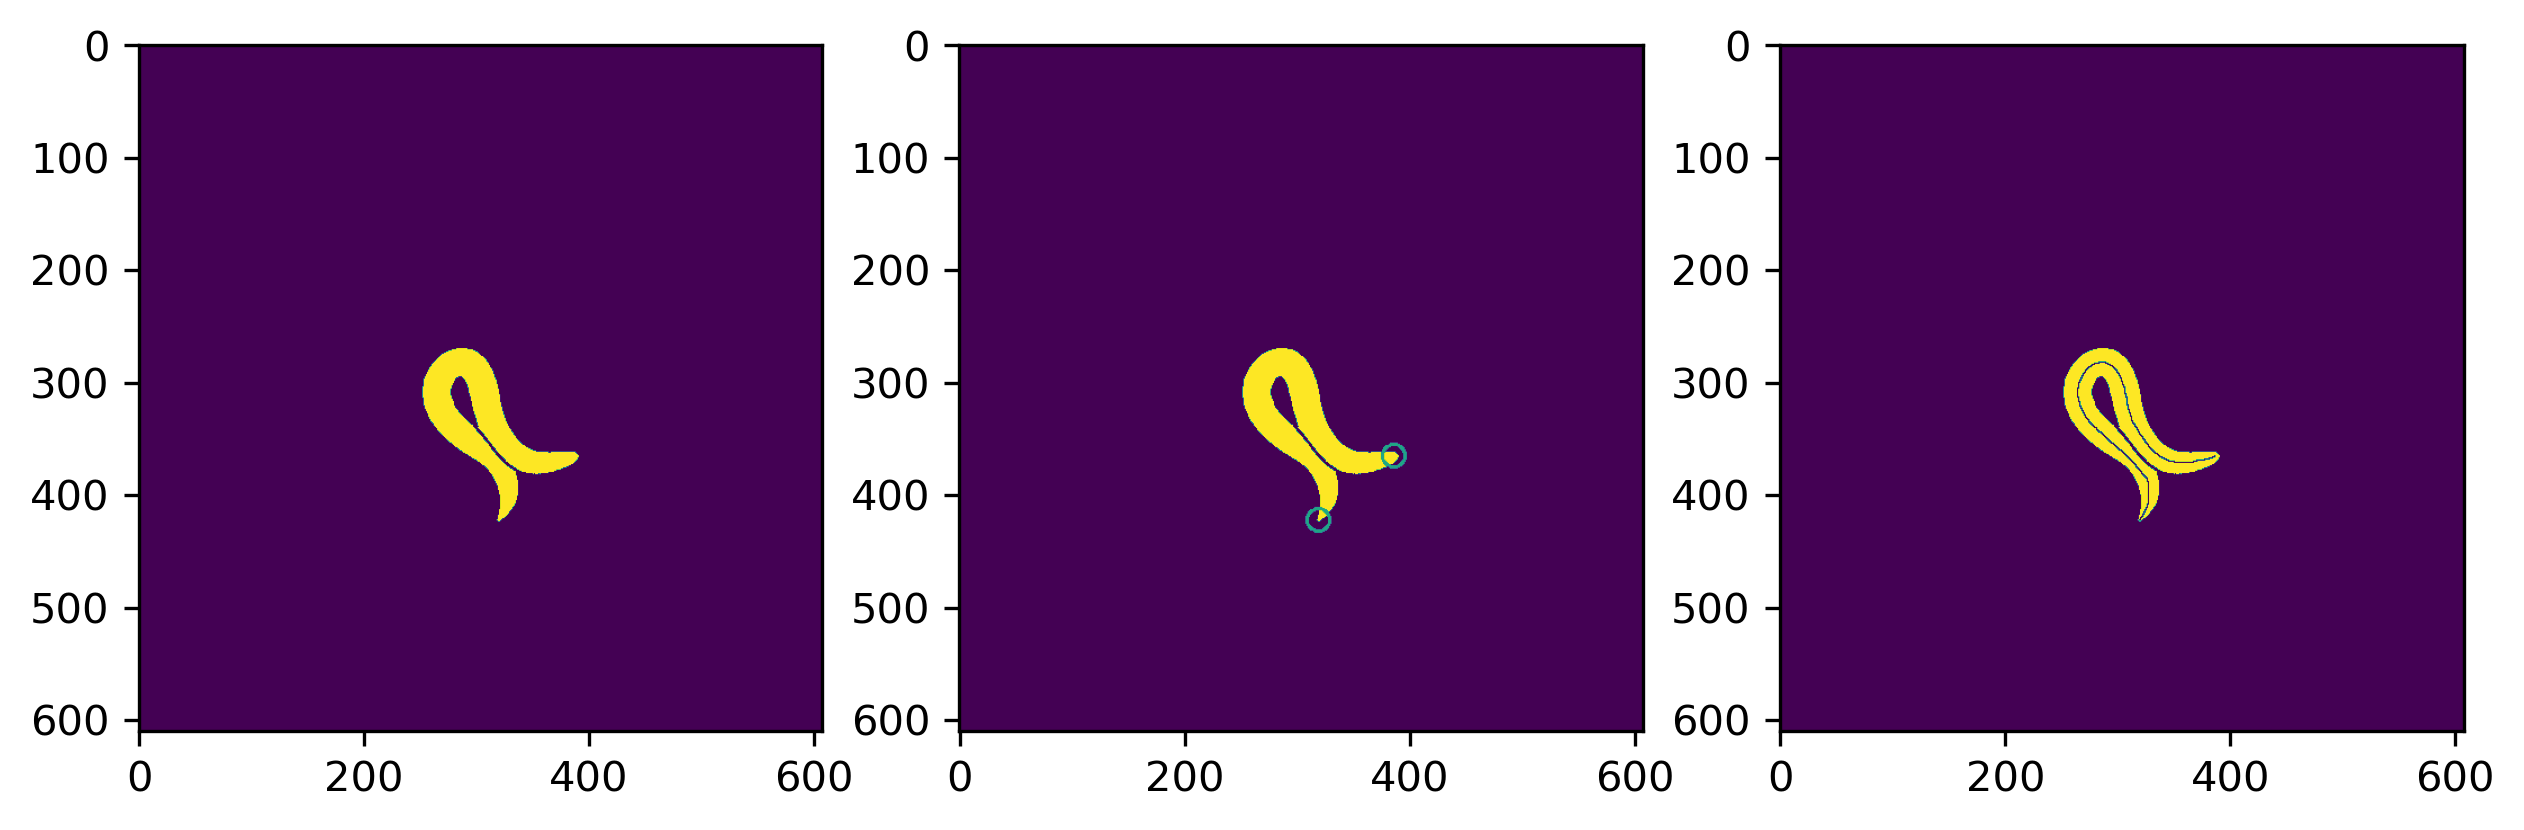

img48200.tif


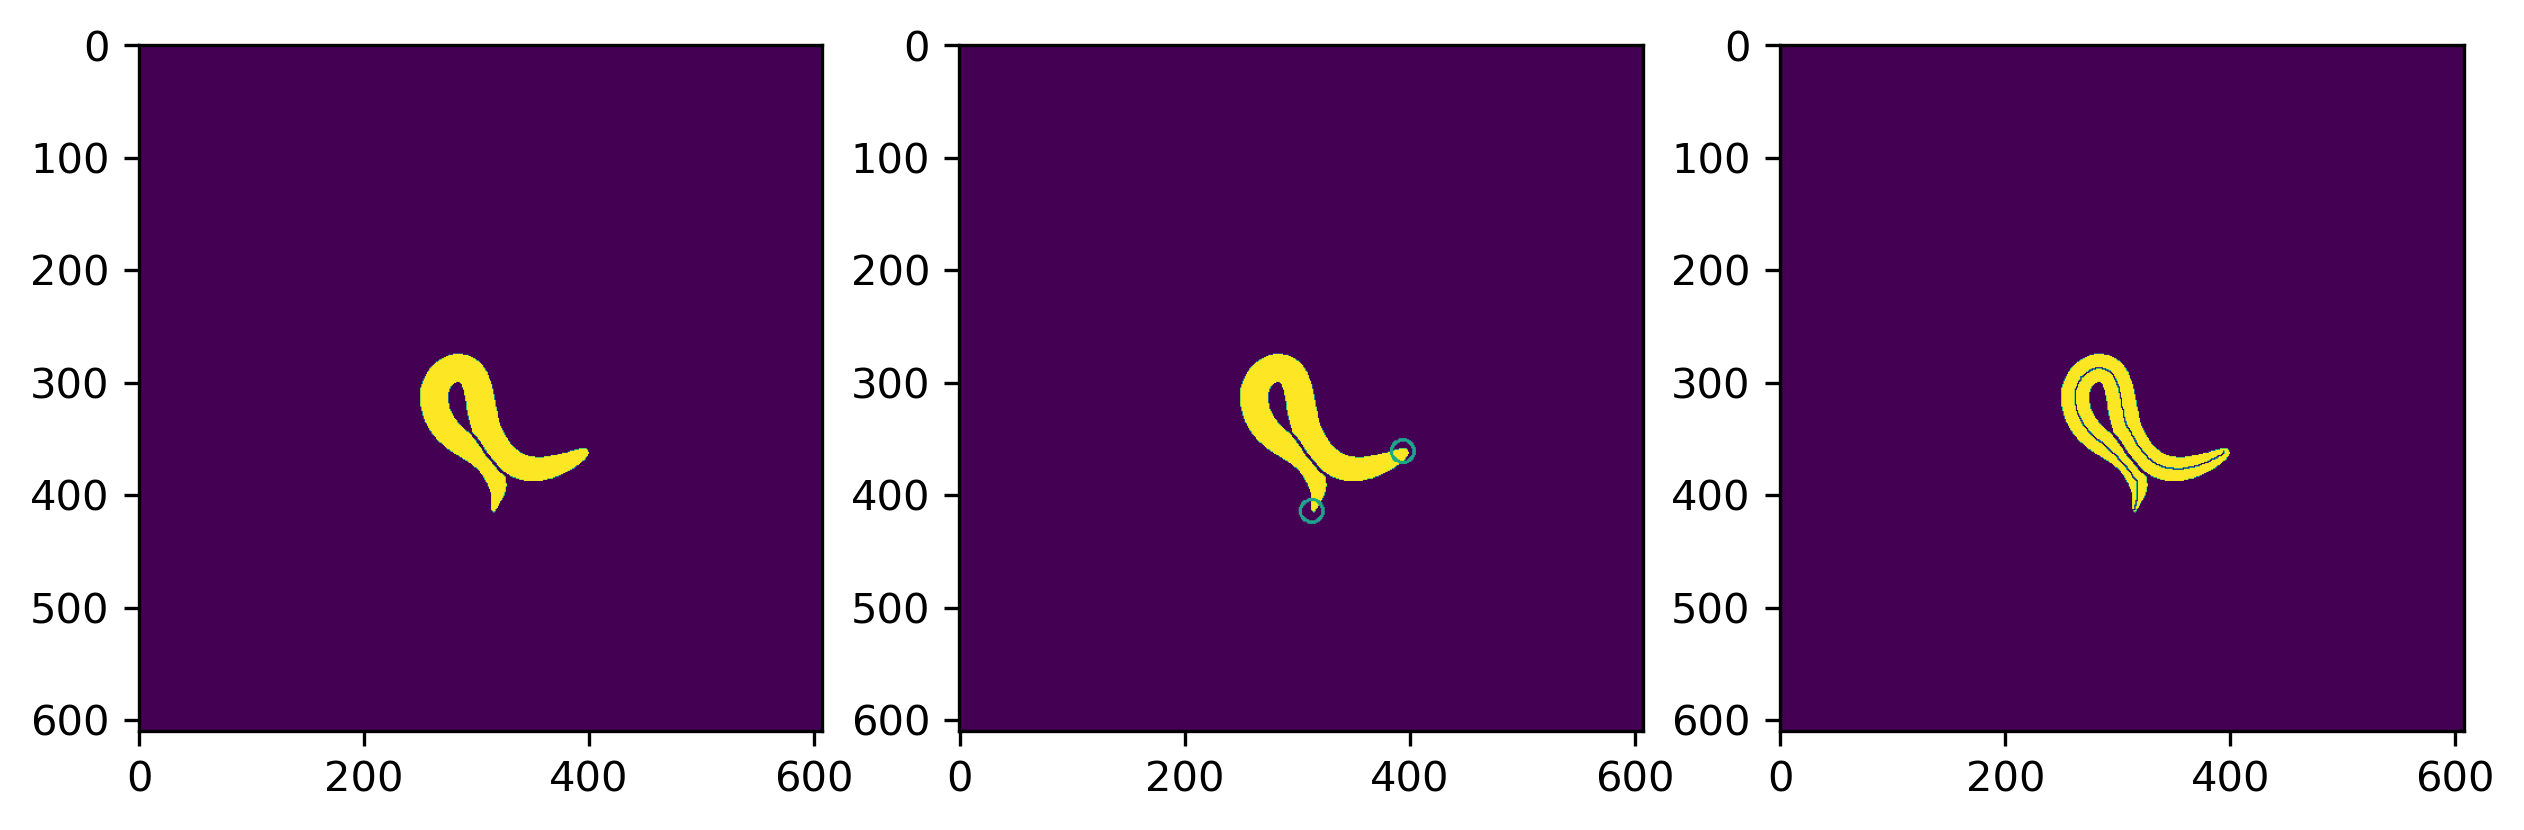

img48260.tif


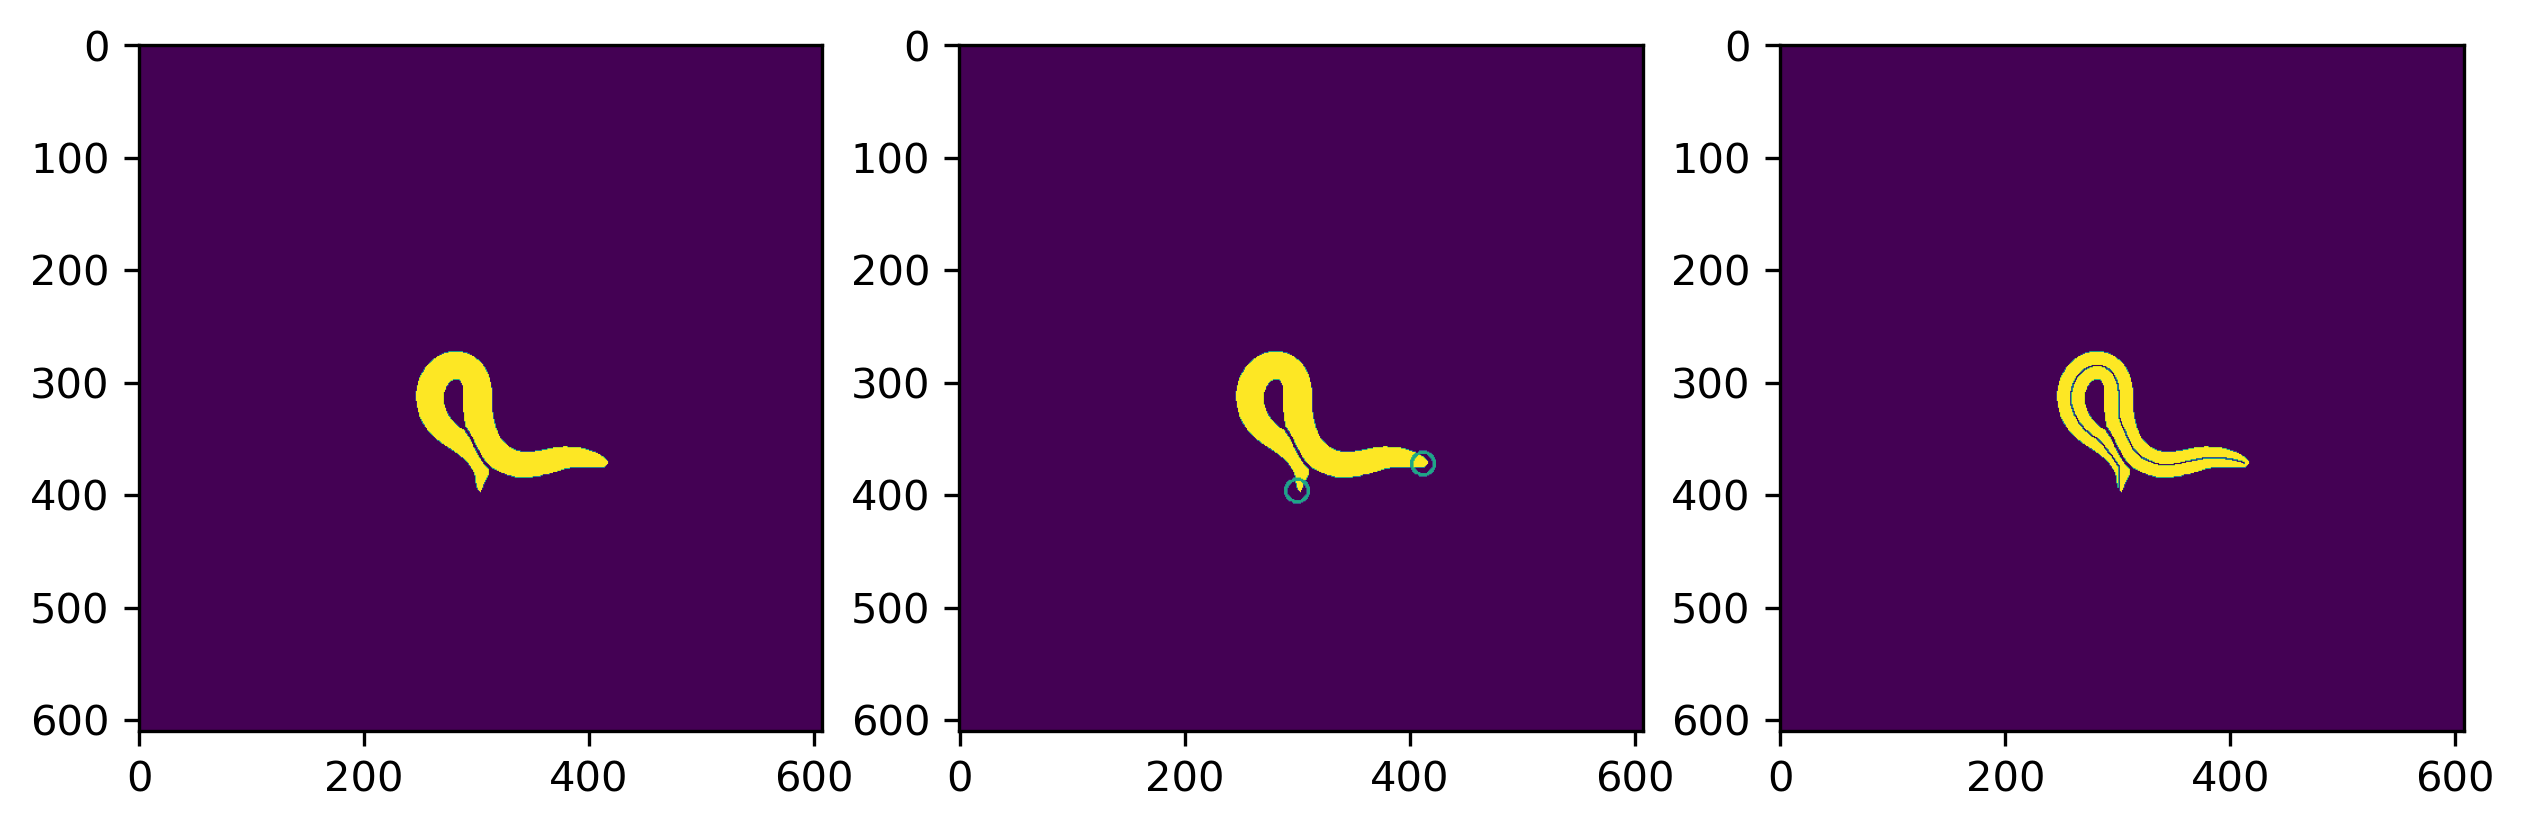

img48320.tif


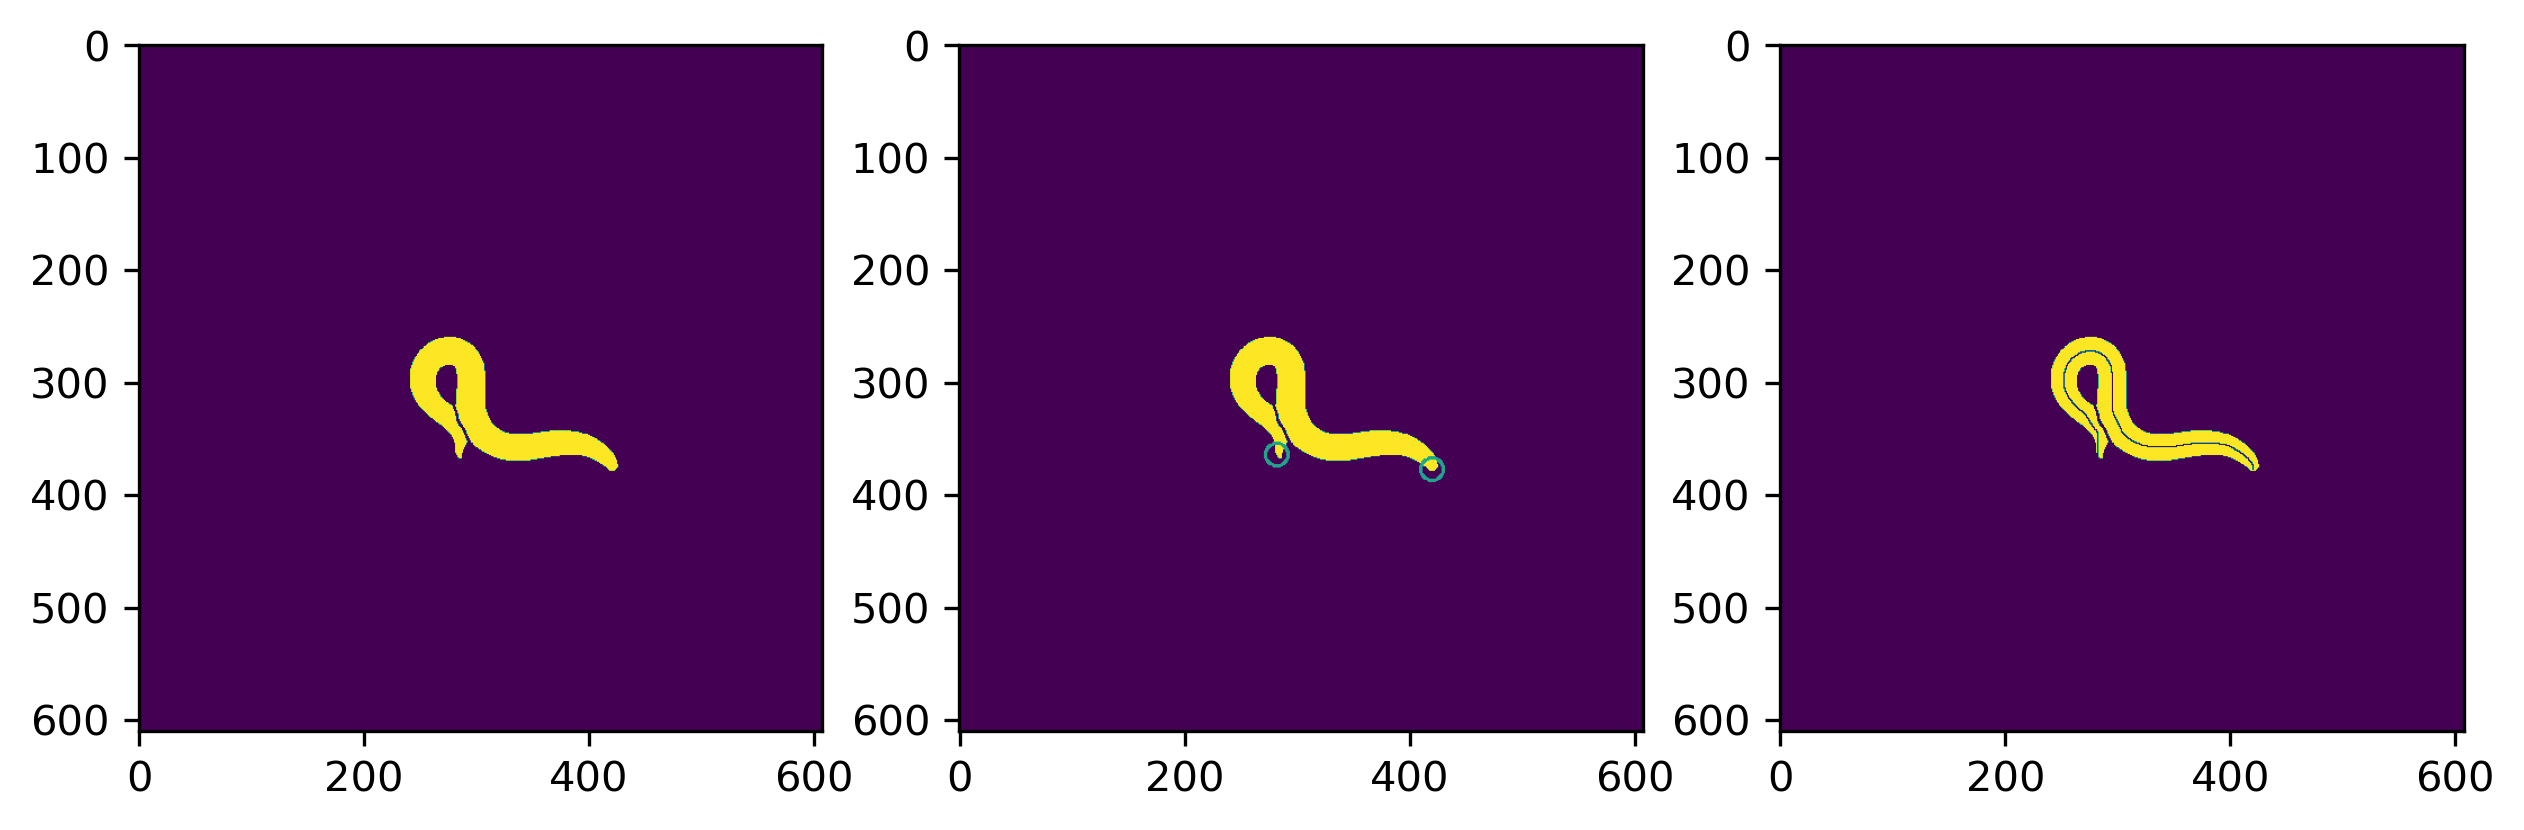

img59647.tif


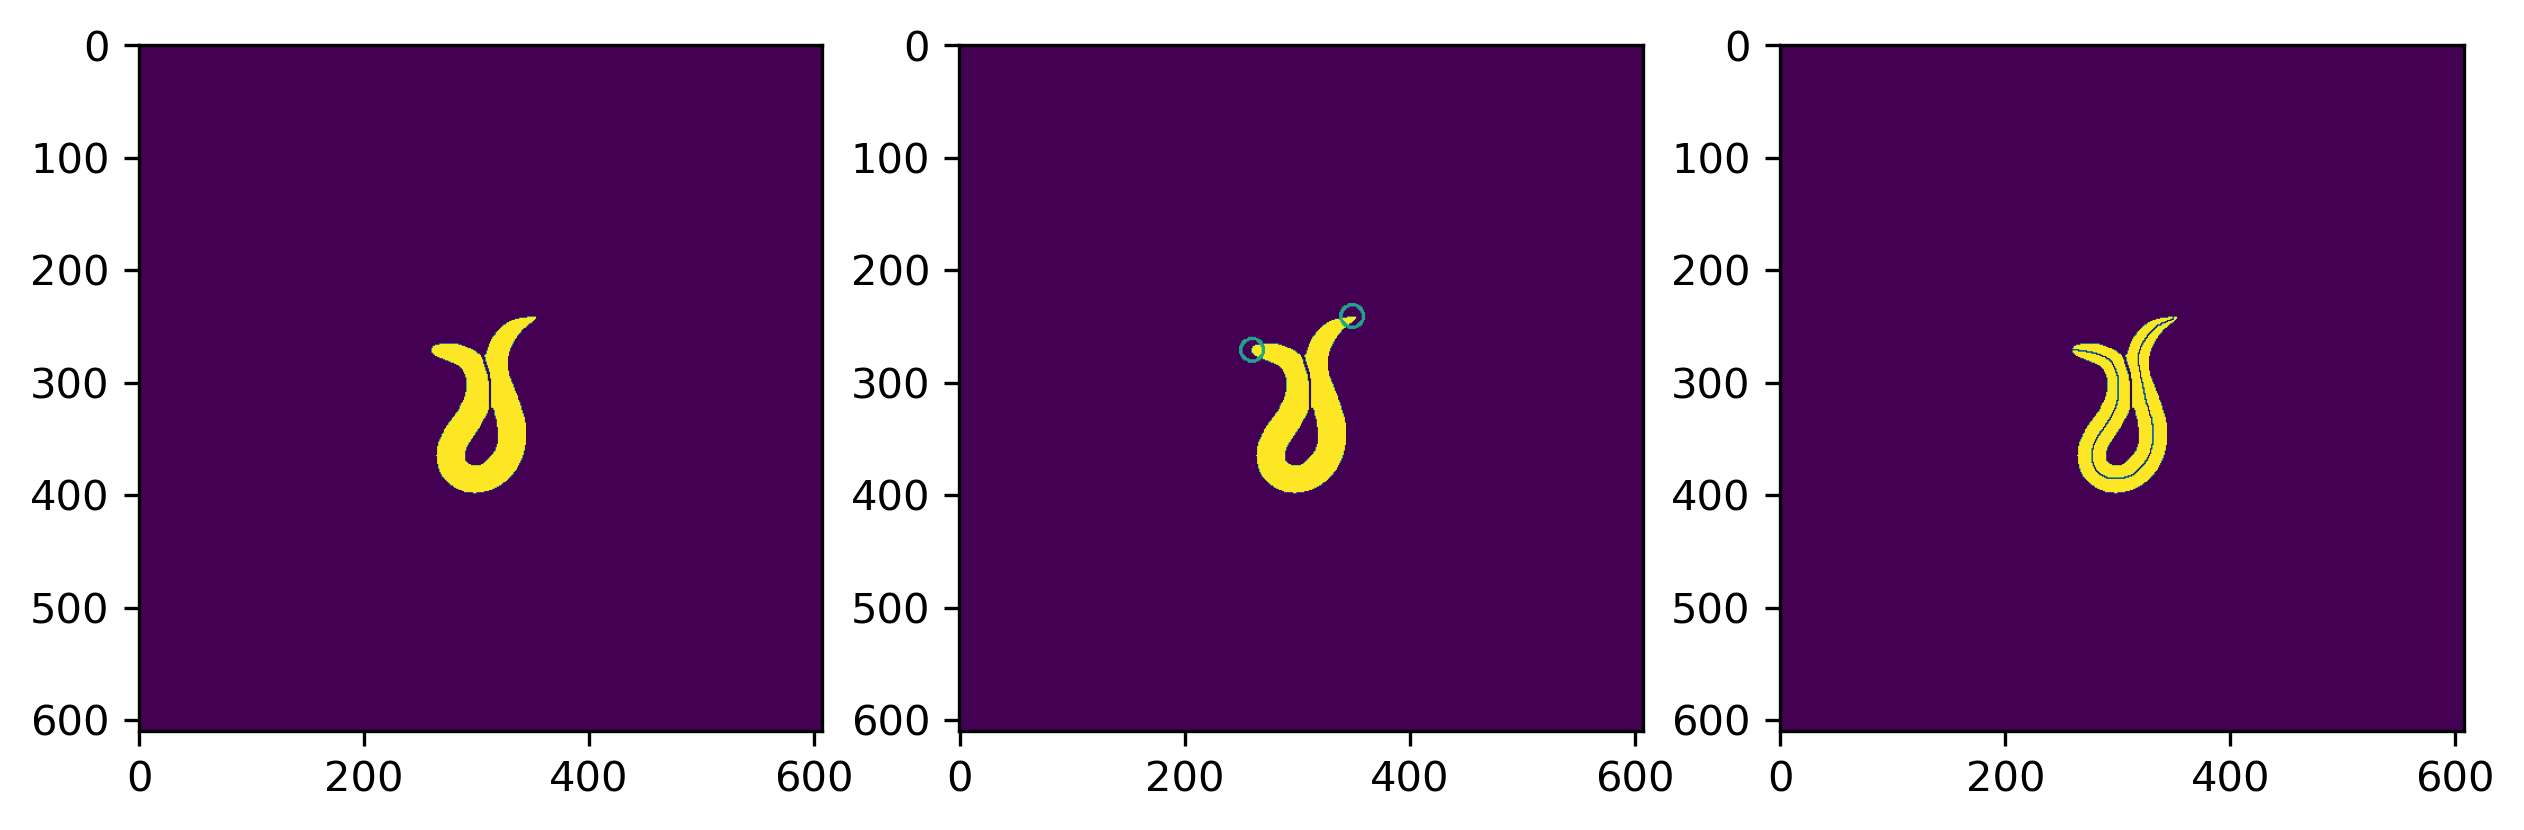

img59707.tif


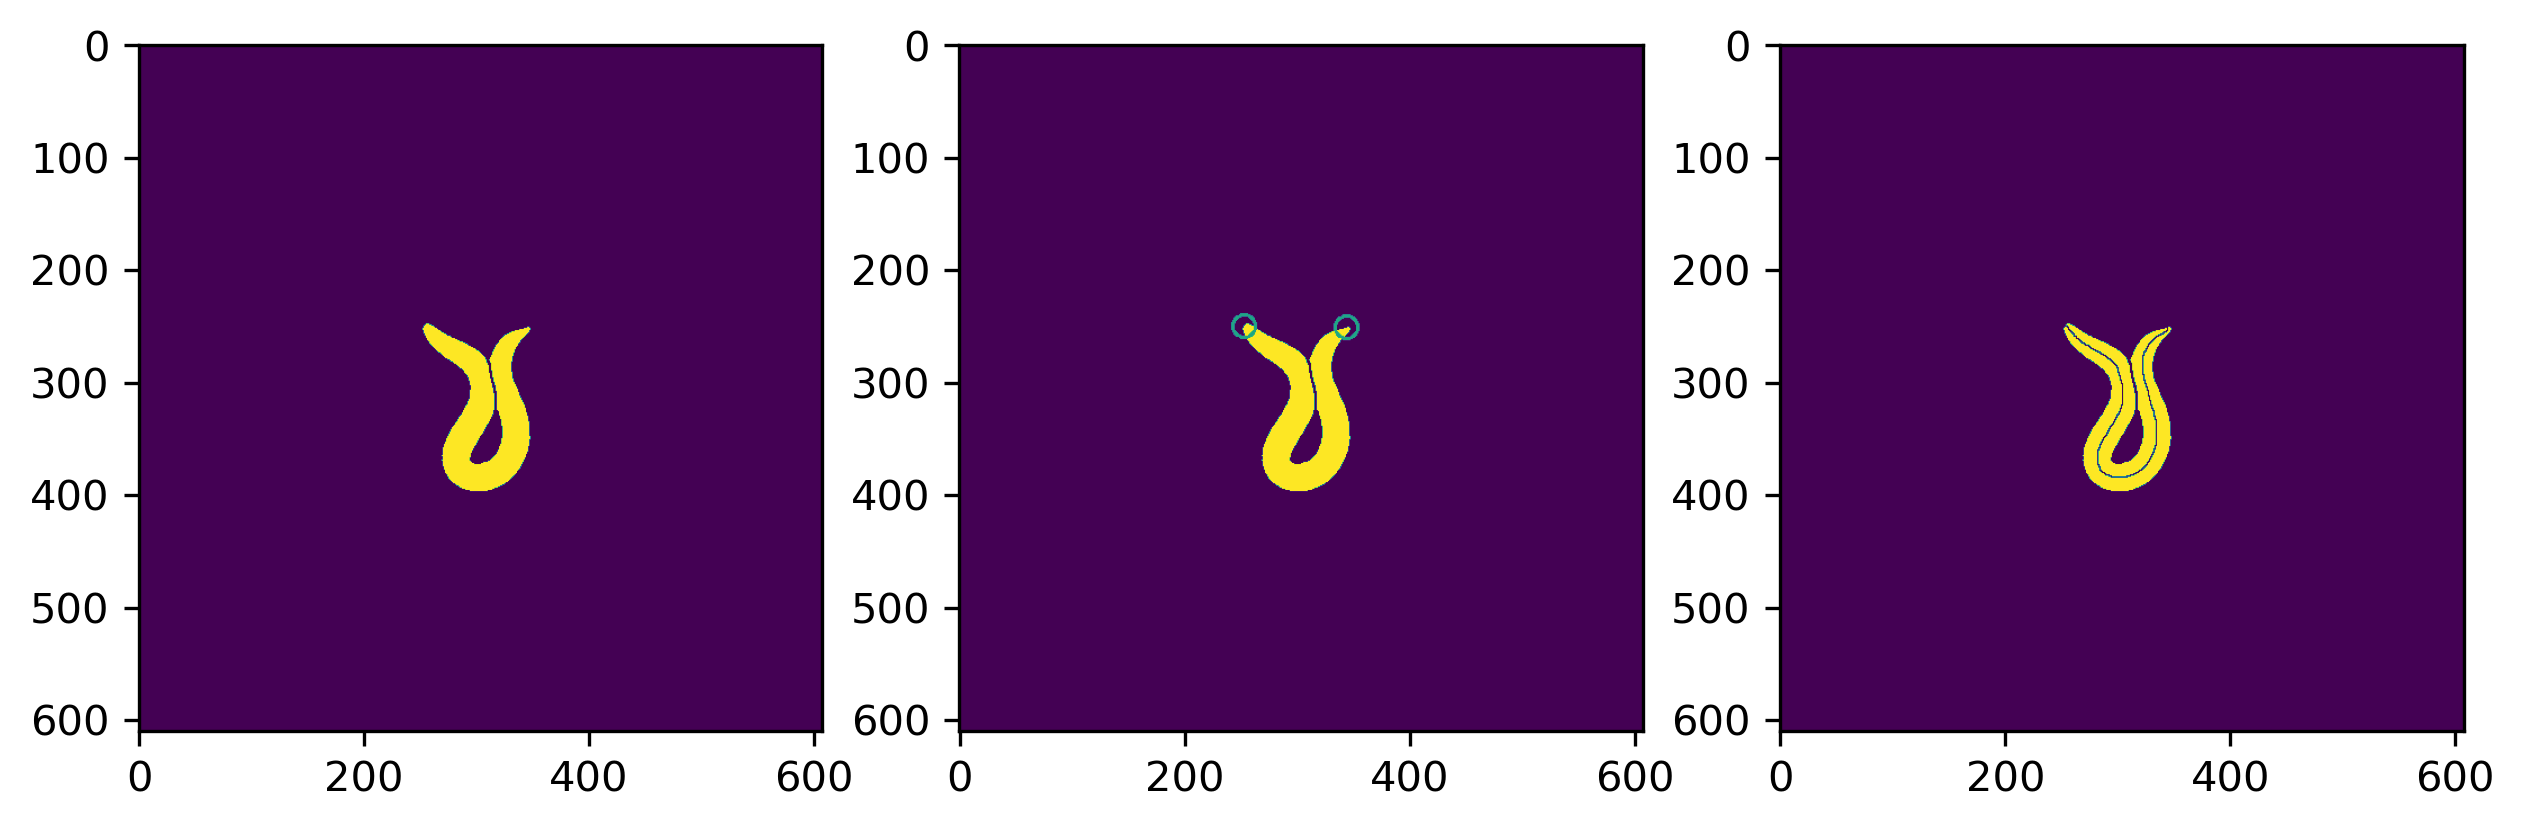

img59767.tif


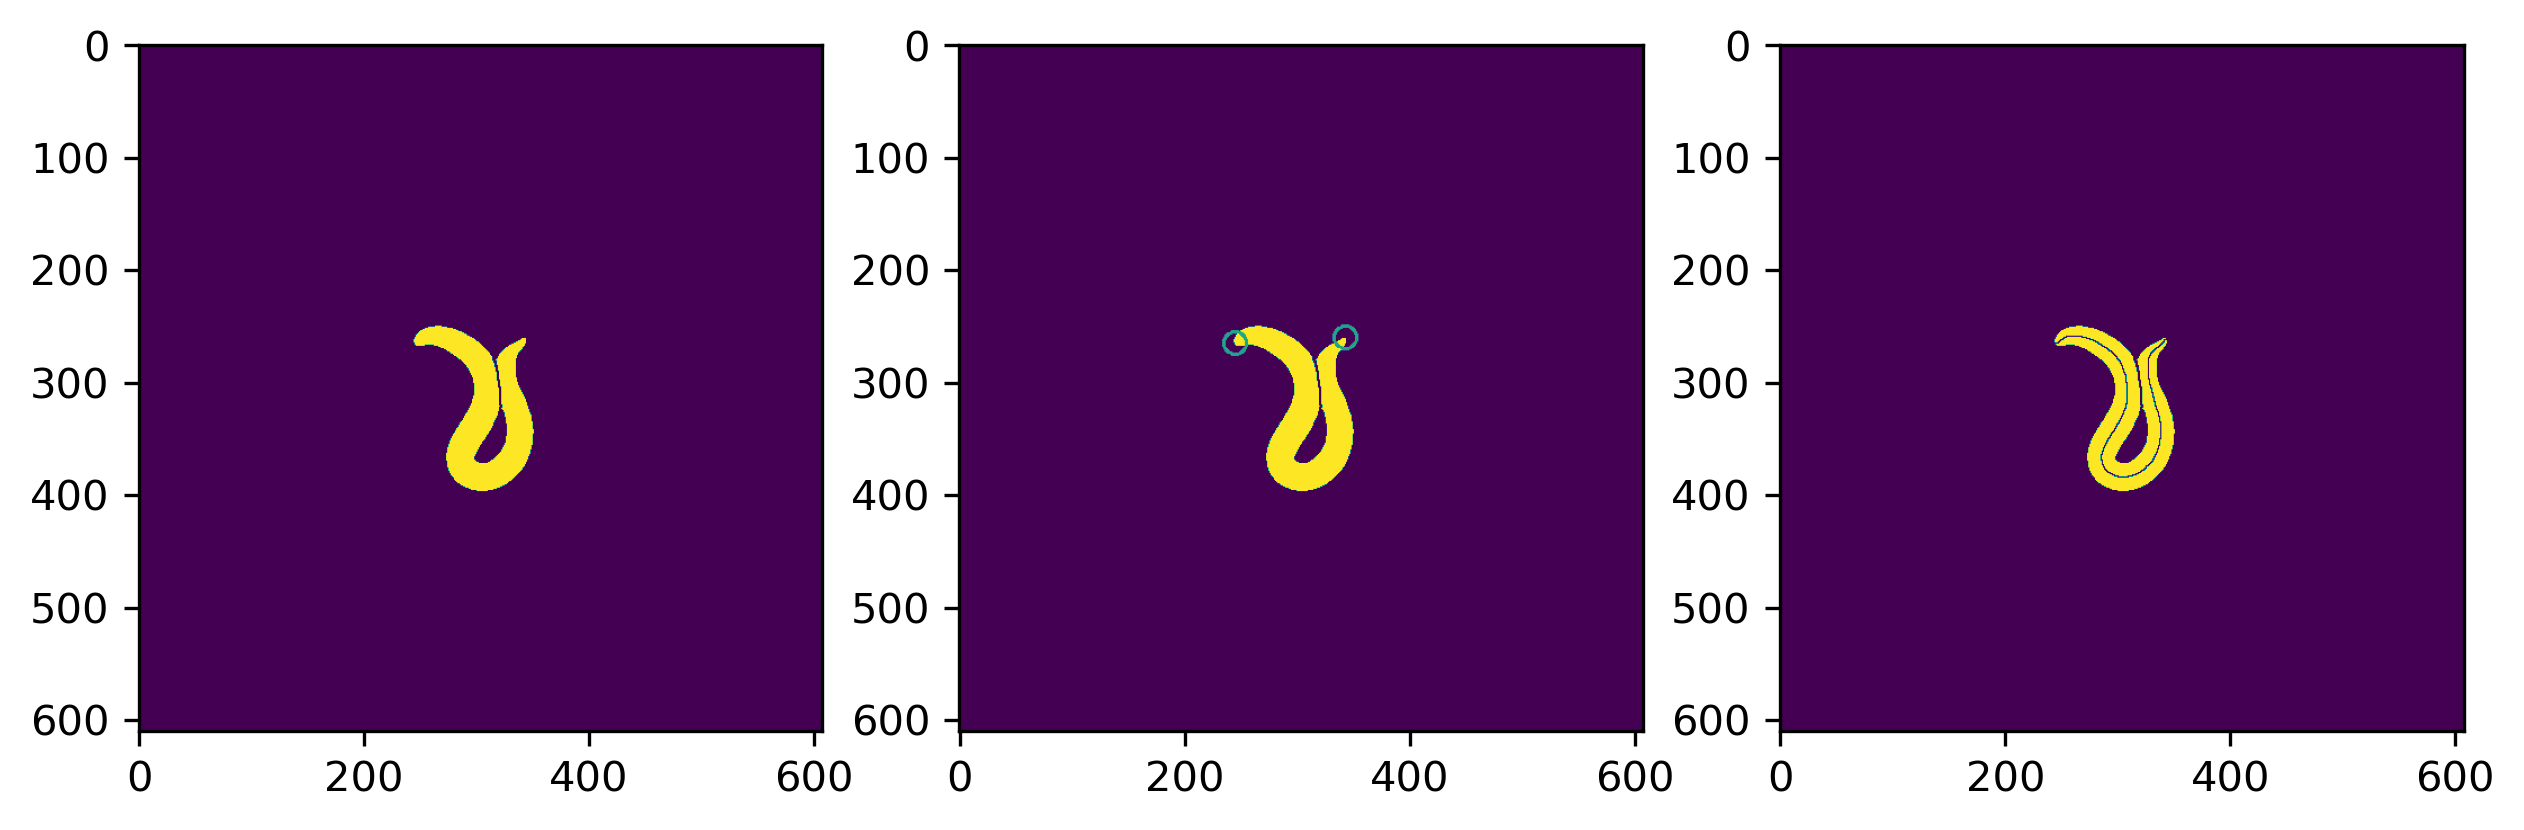

img59827.tif


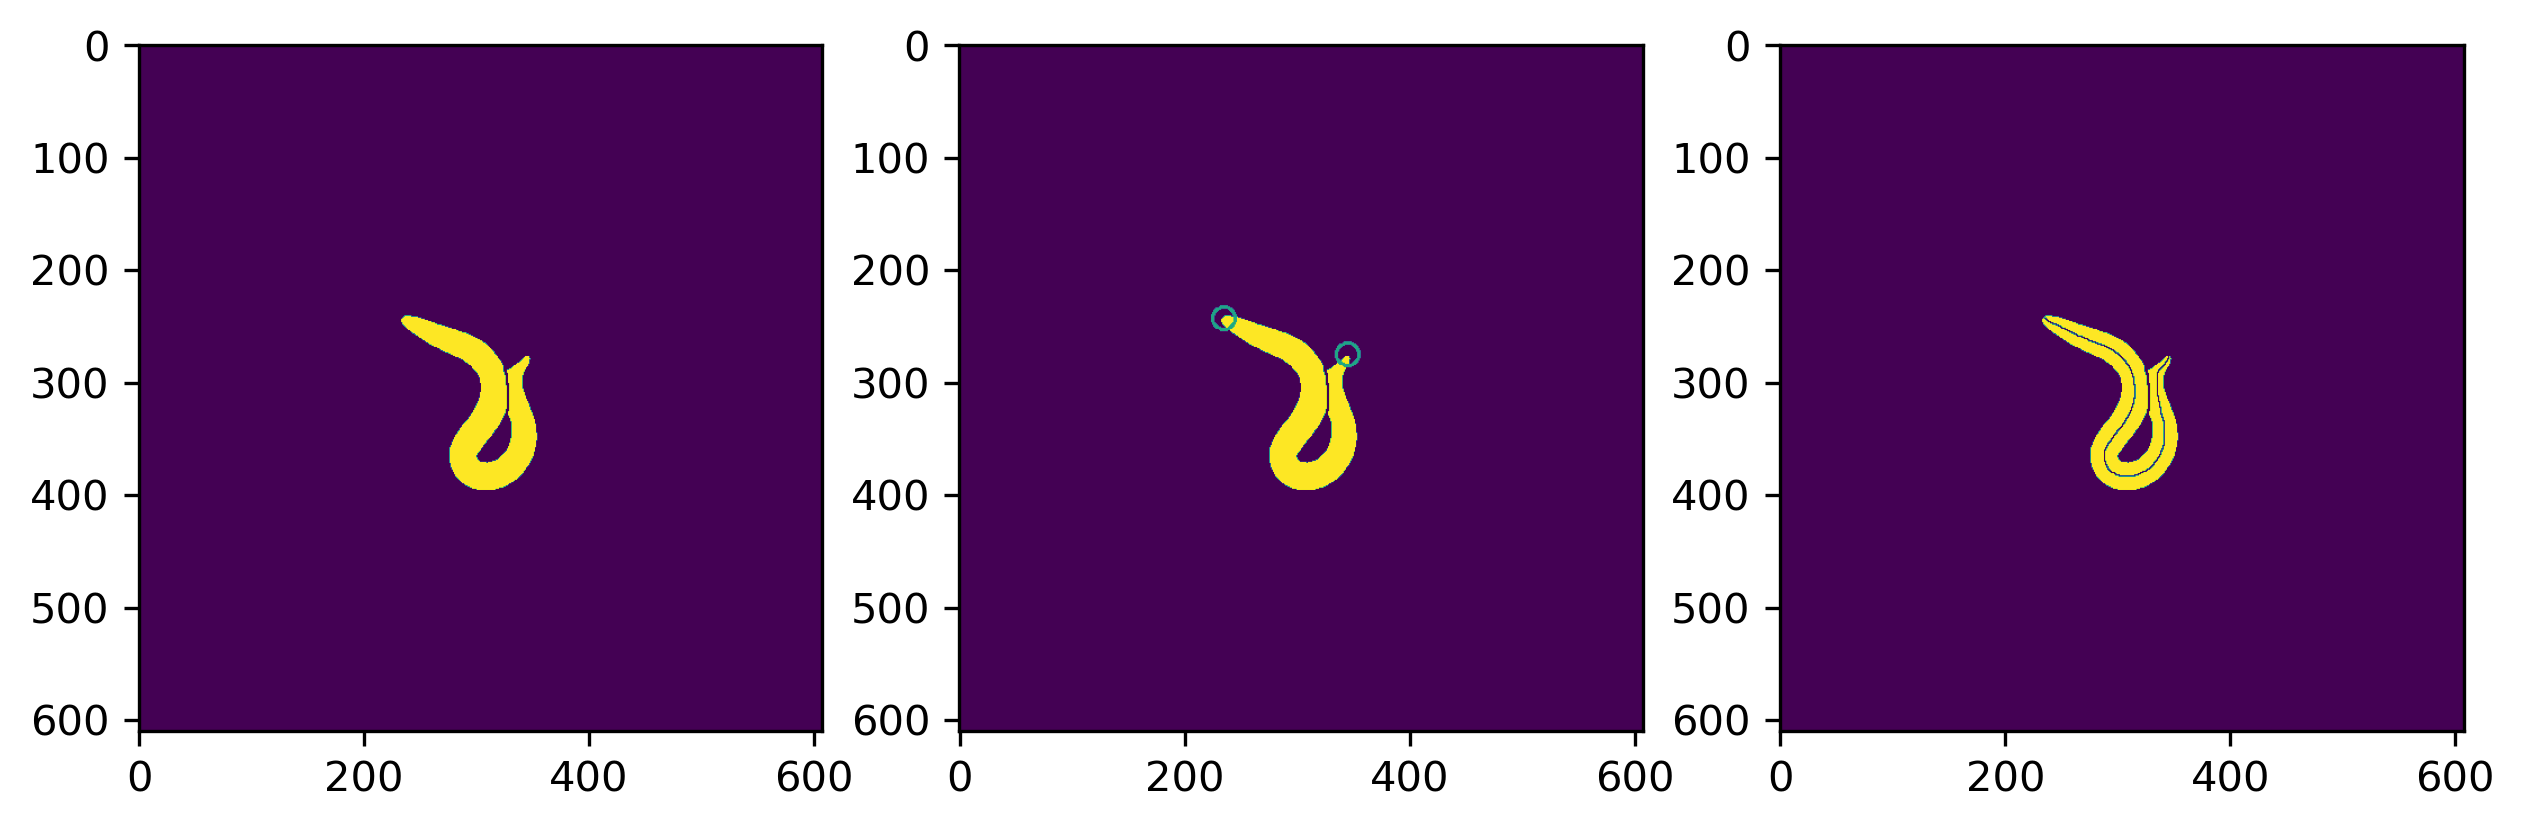

img59887.tif


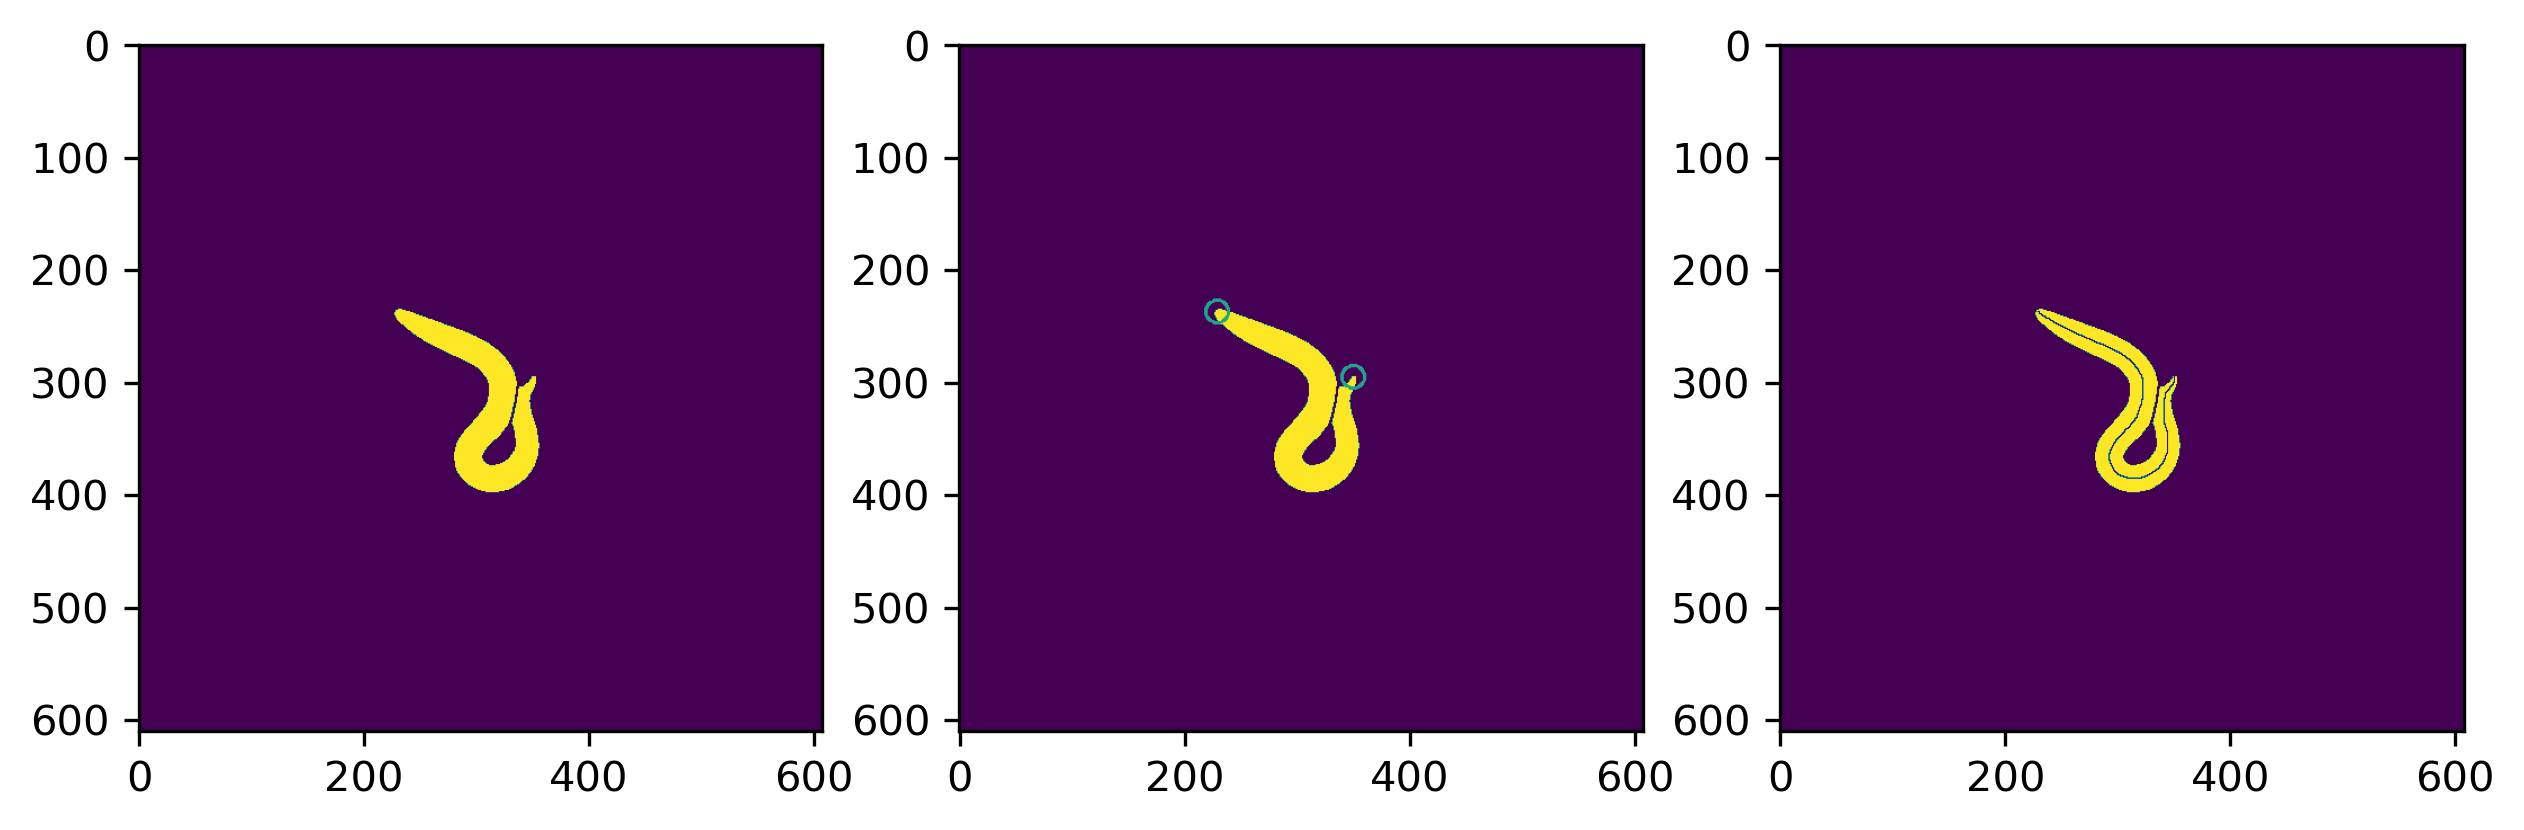

img62763.tif
head and tail were too close, no centerline could be created
img62823.tif
head and tail were too close, no centerline could be created
img62883.tif


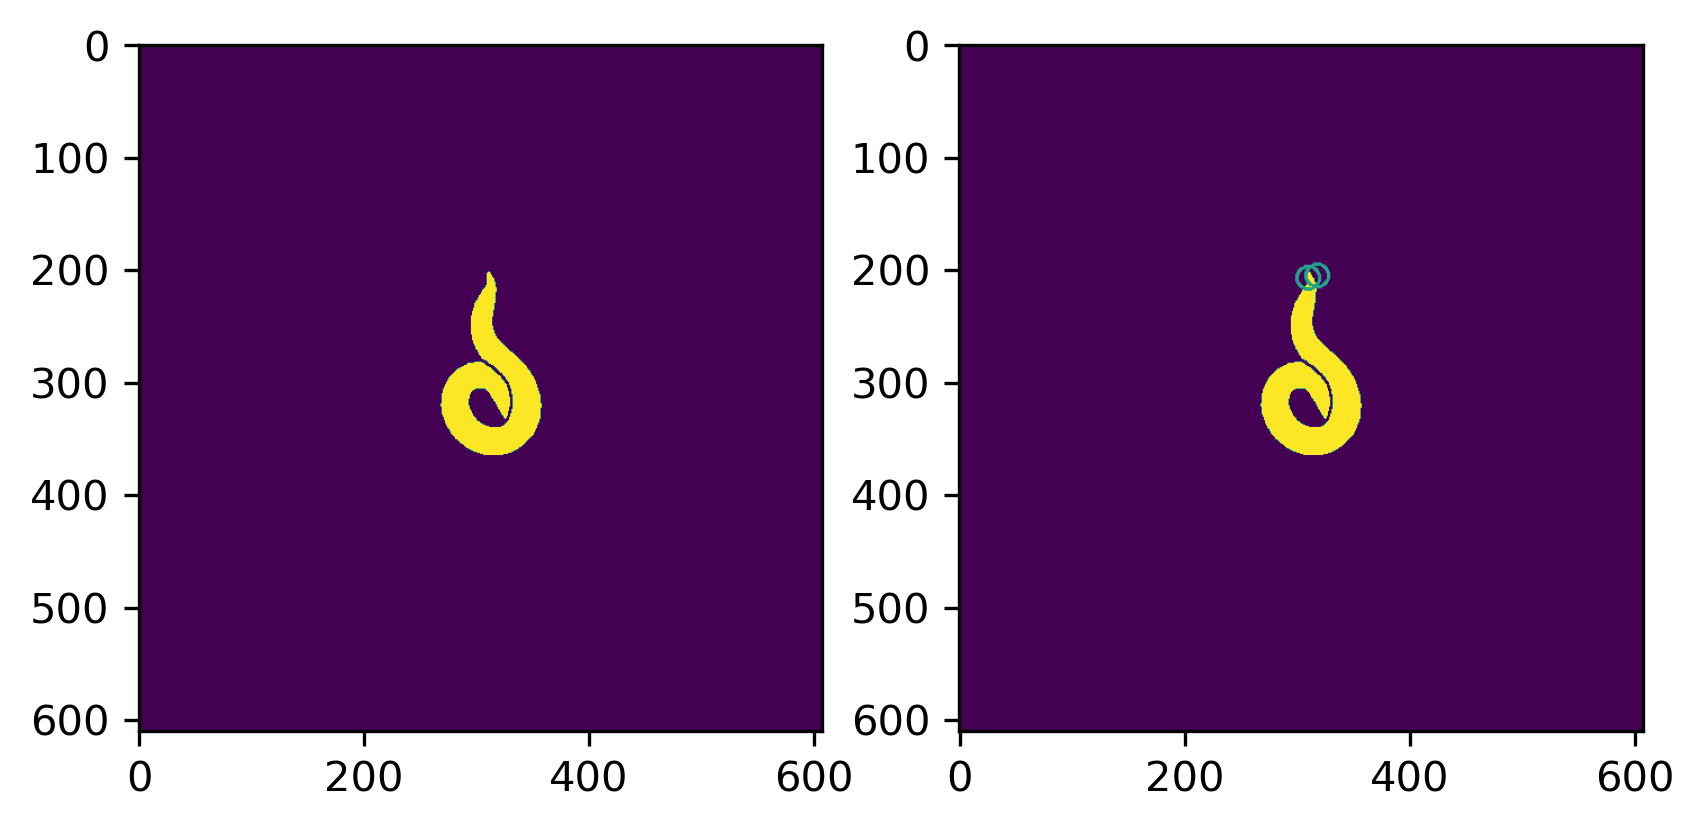

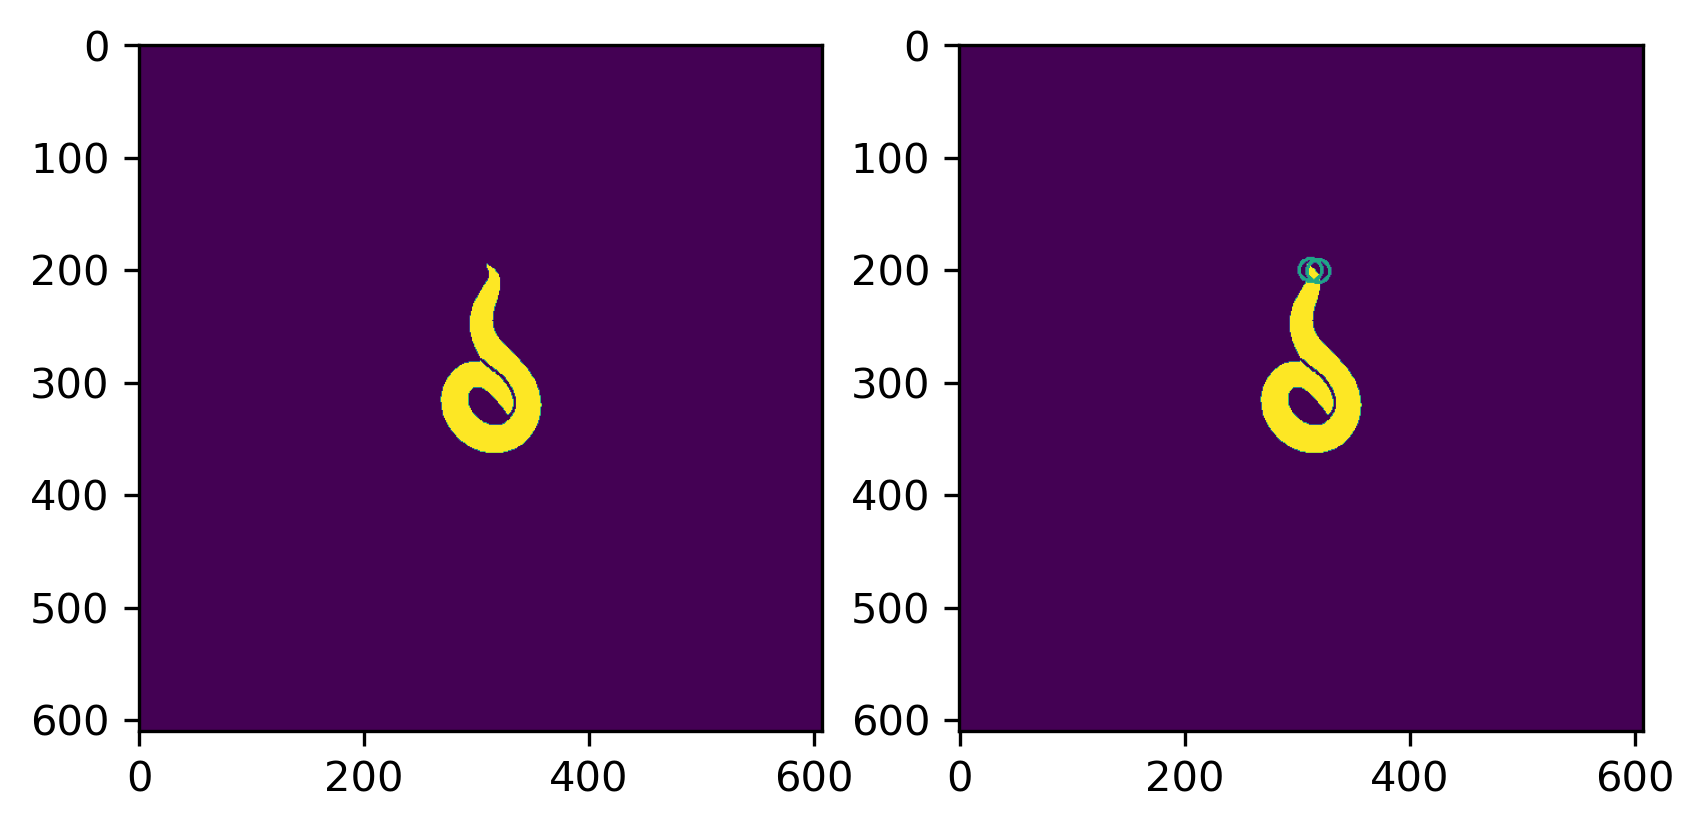

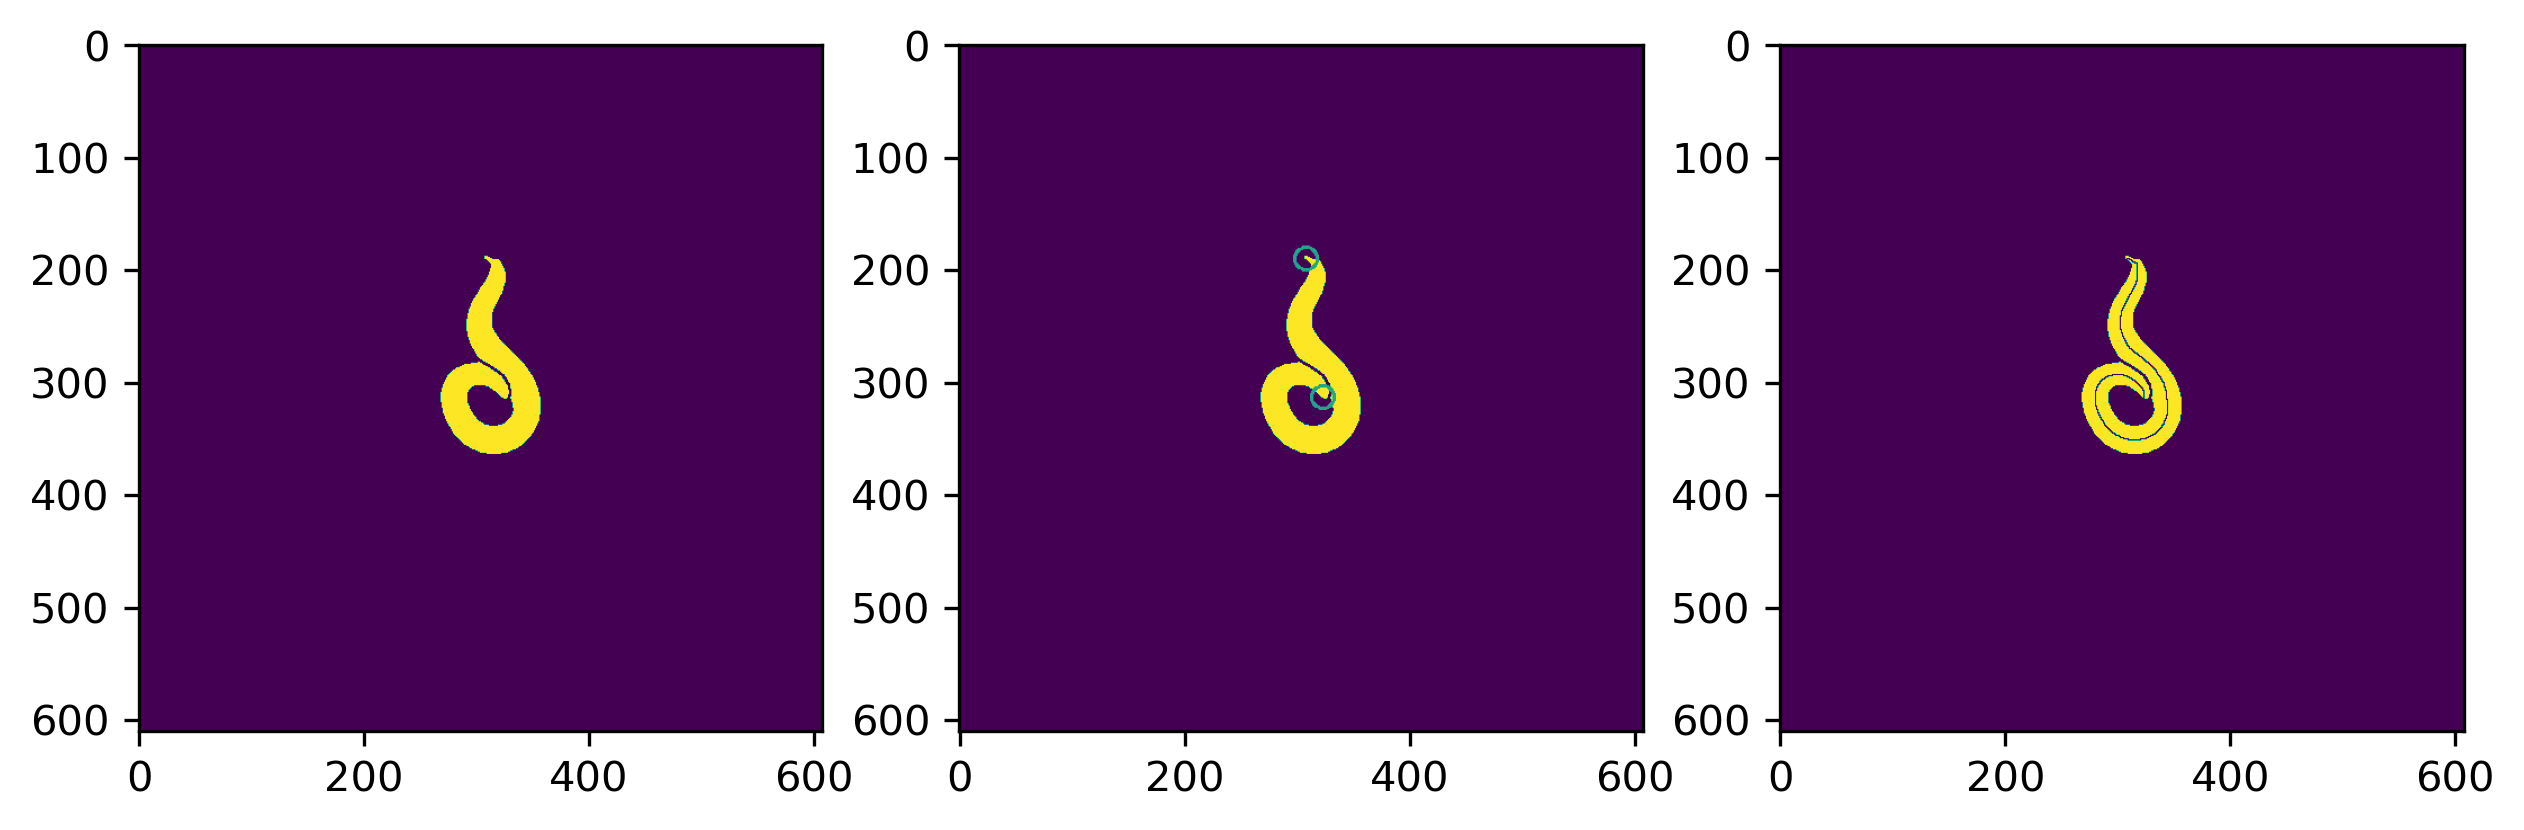

img62943.tif


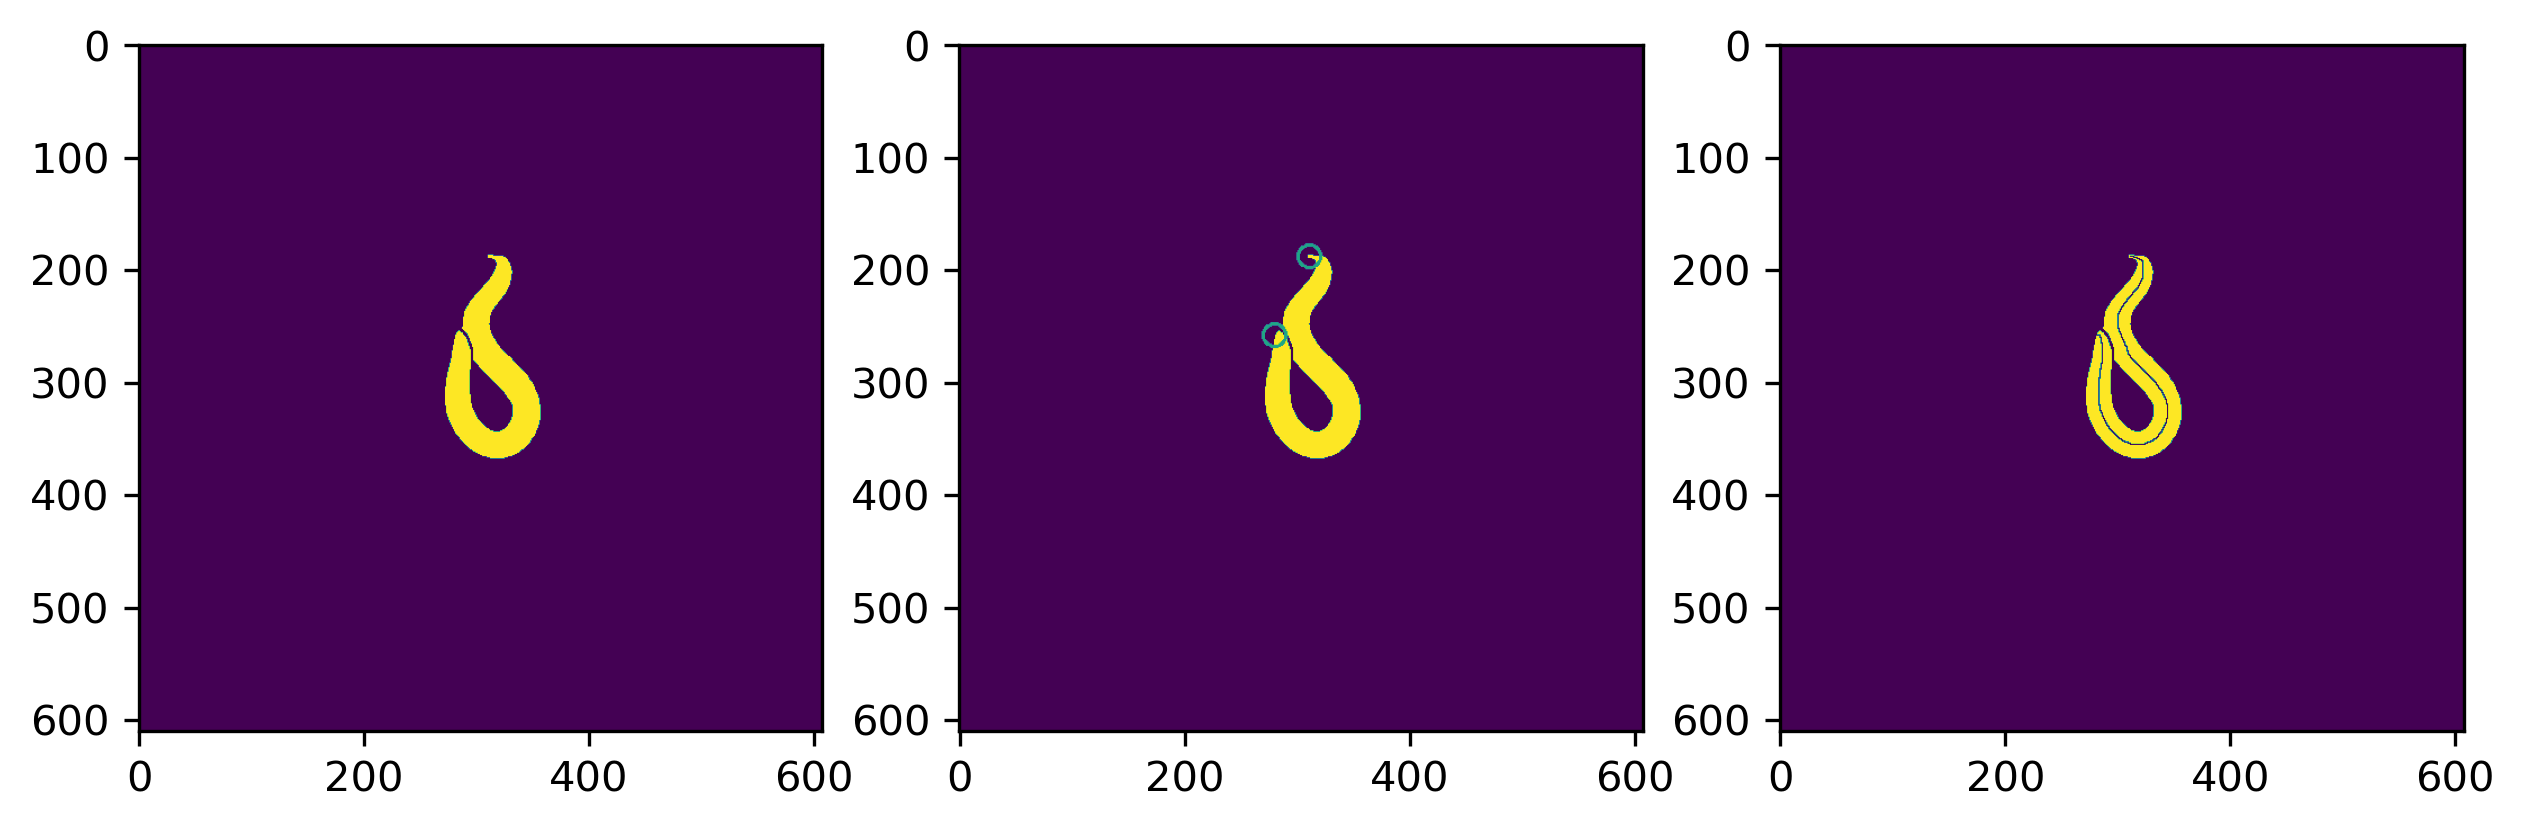

img63003.tif


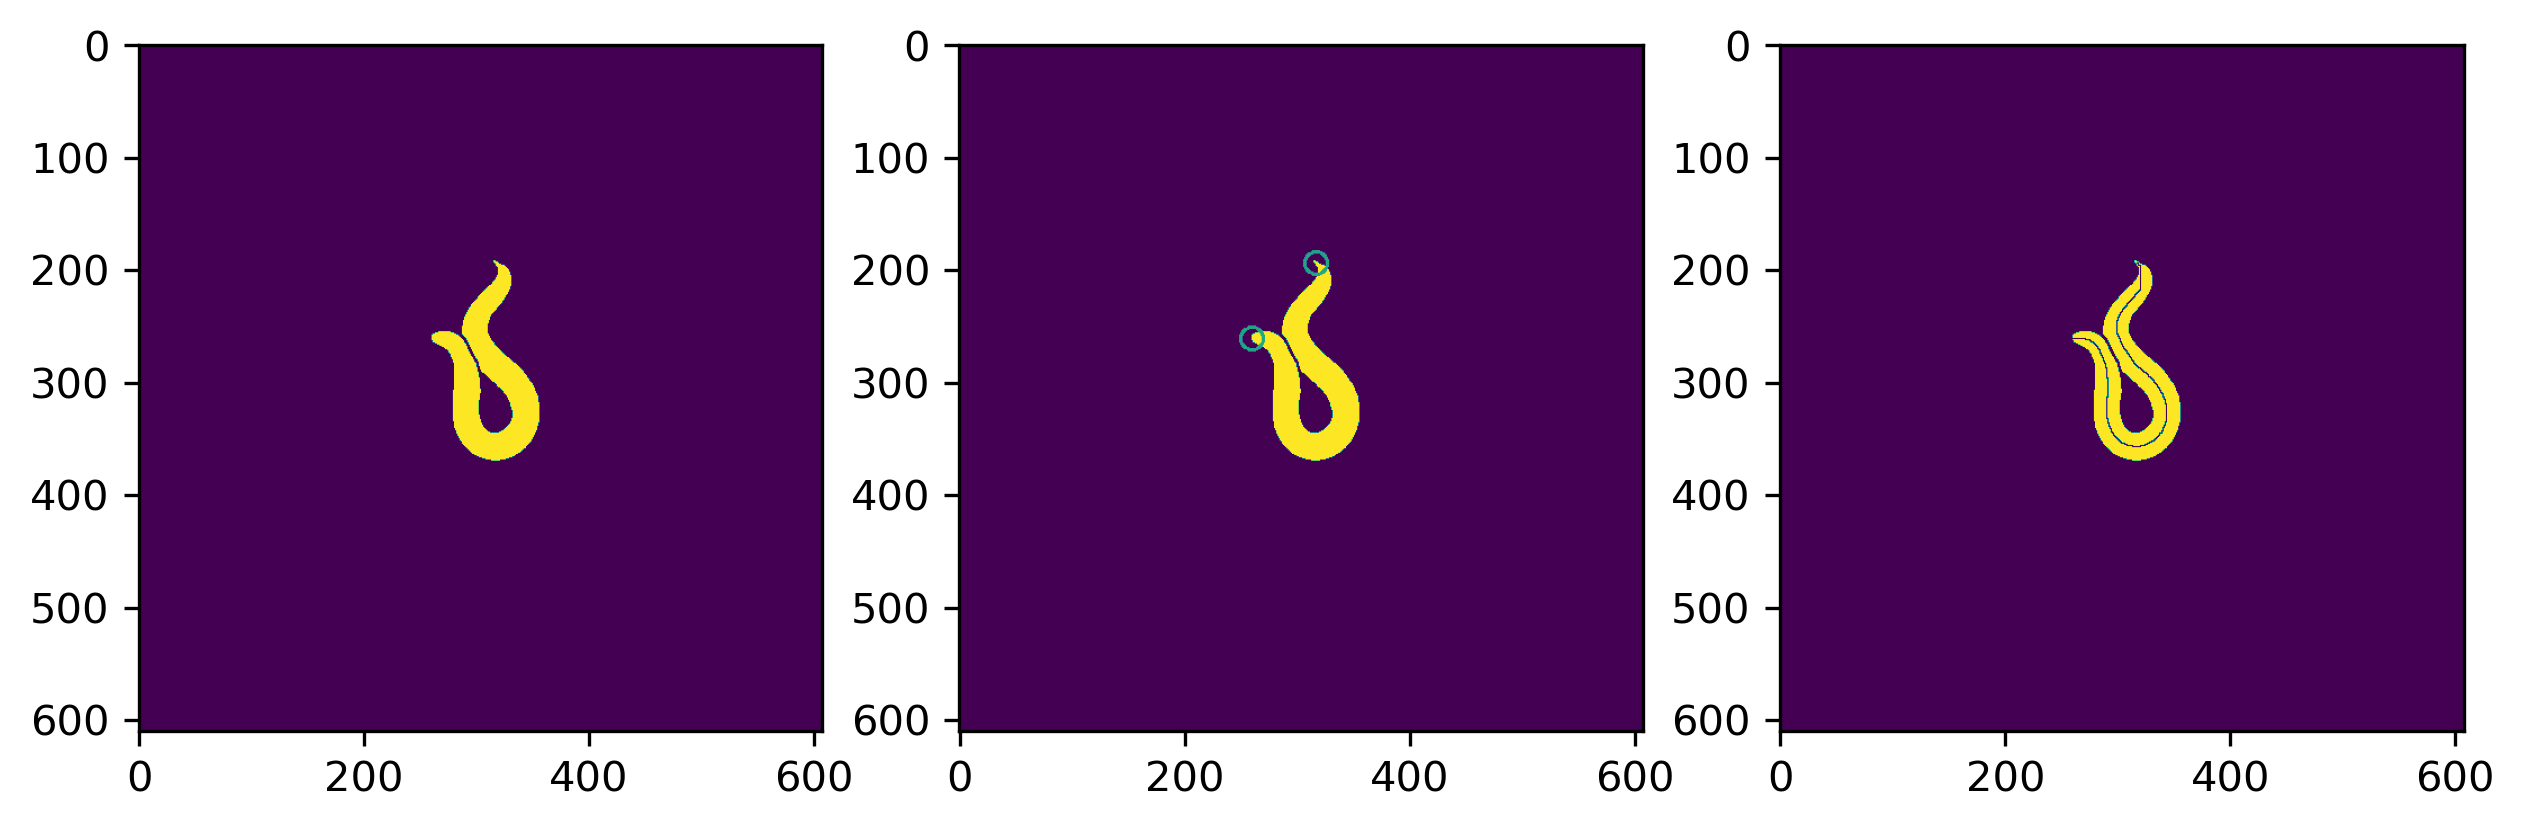

img63063.tif


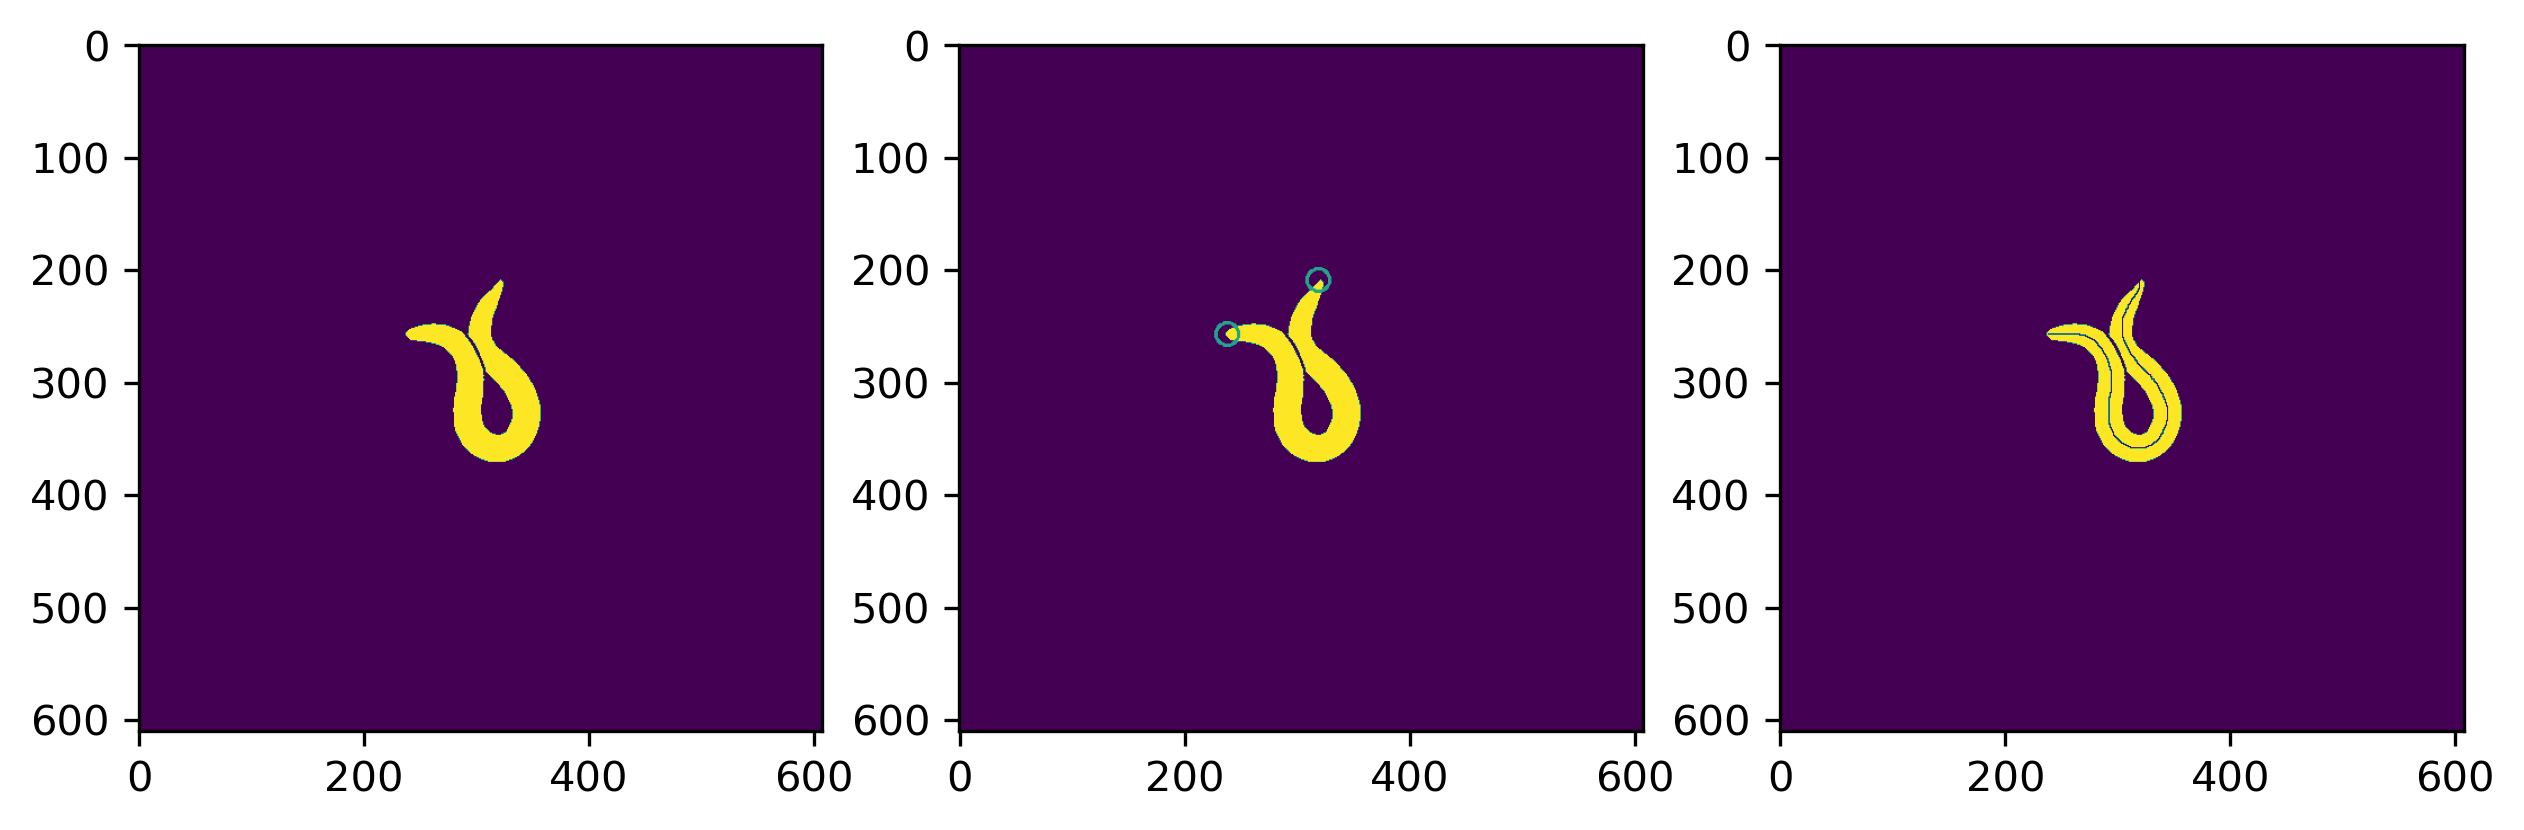

img63123.tif


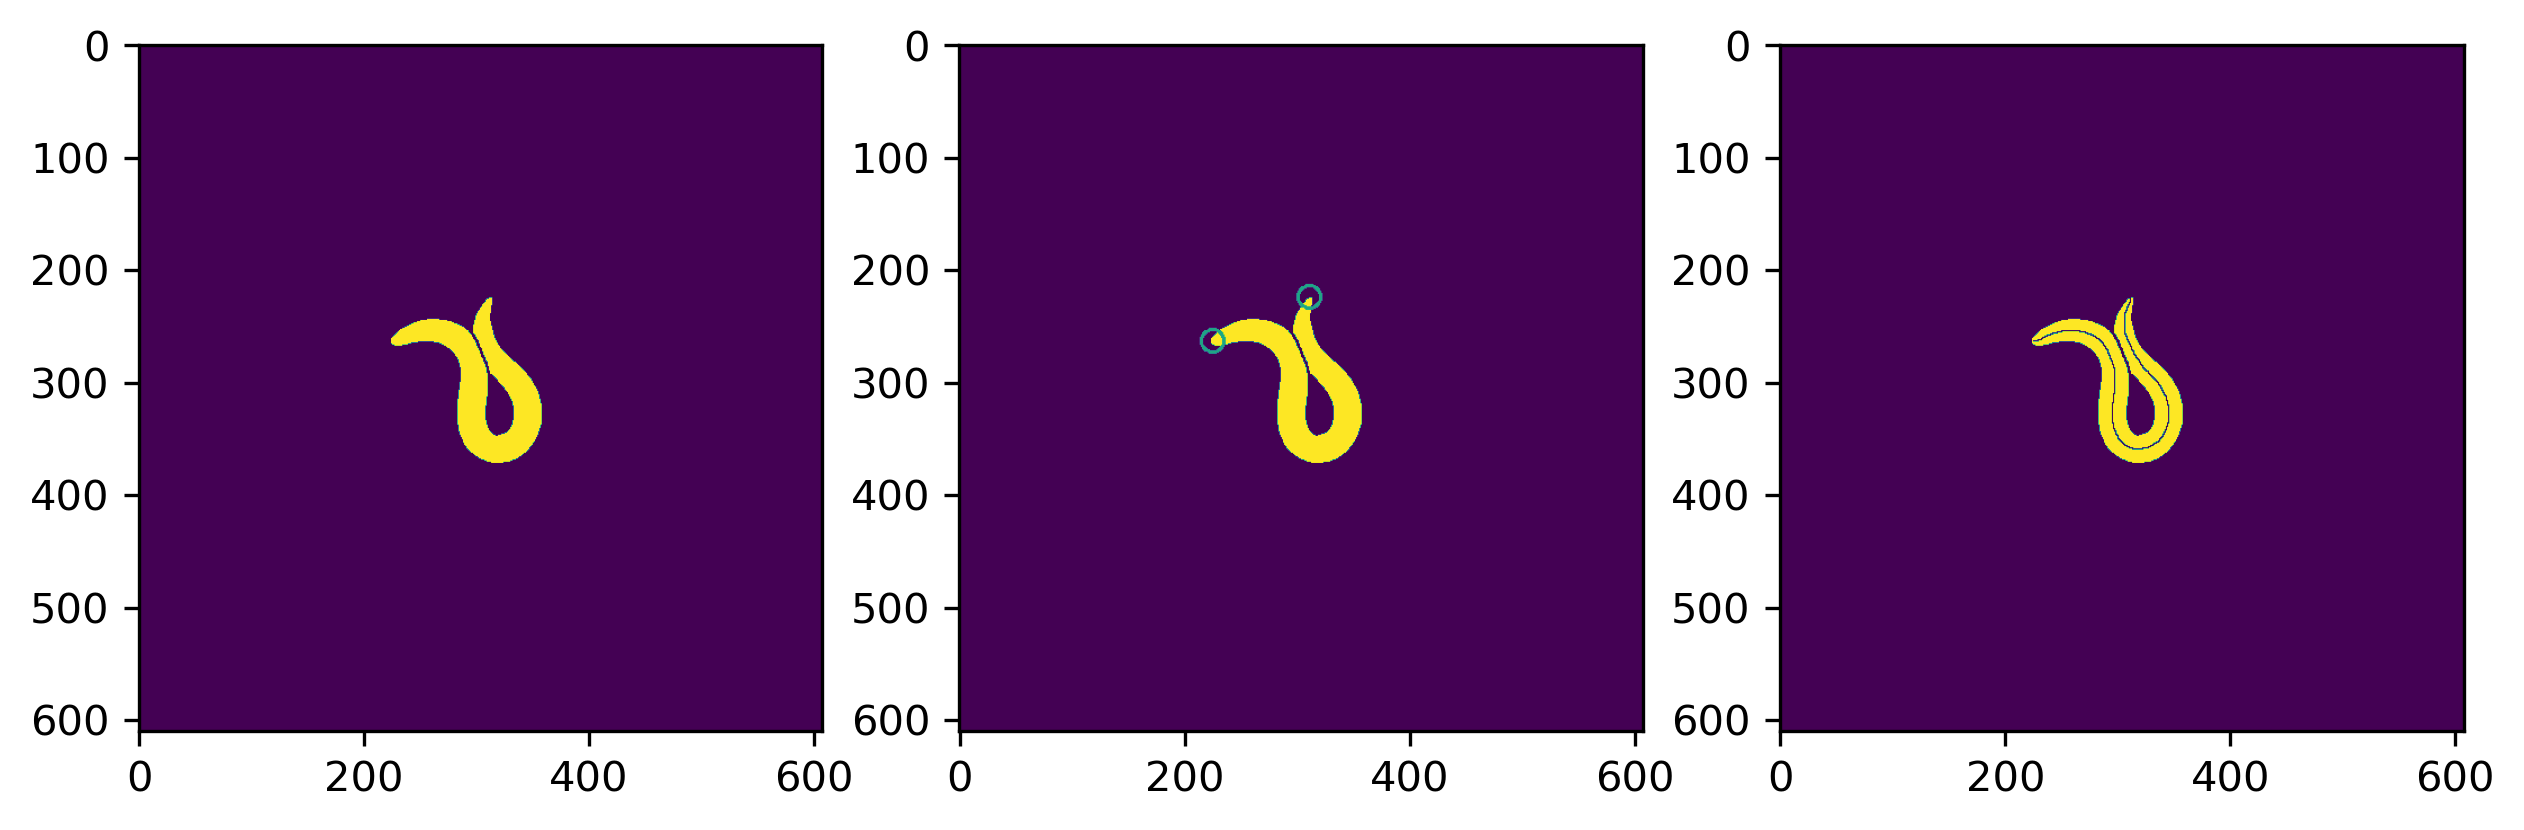

img63183.tif


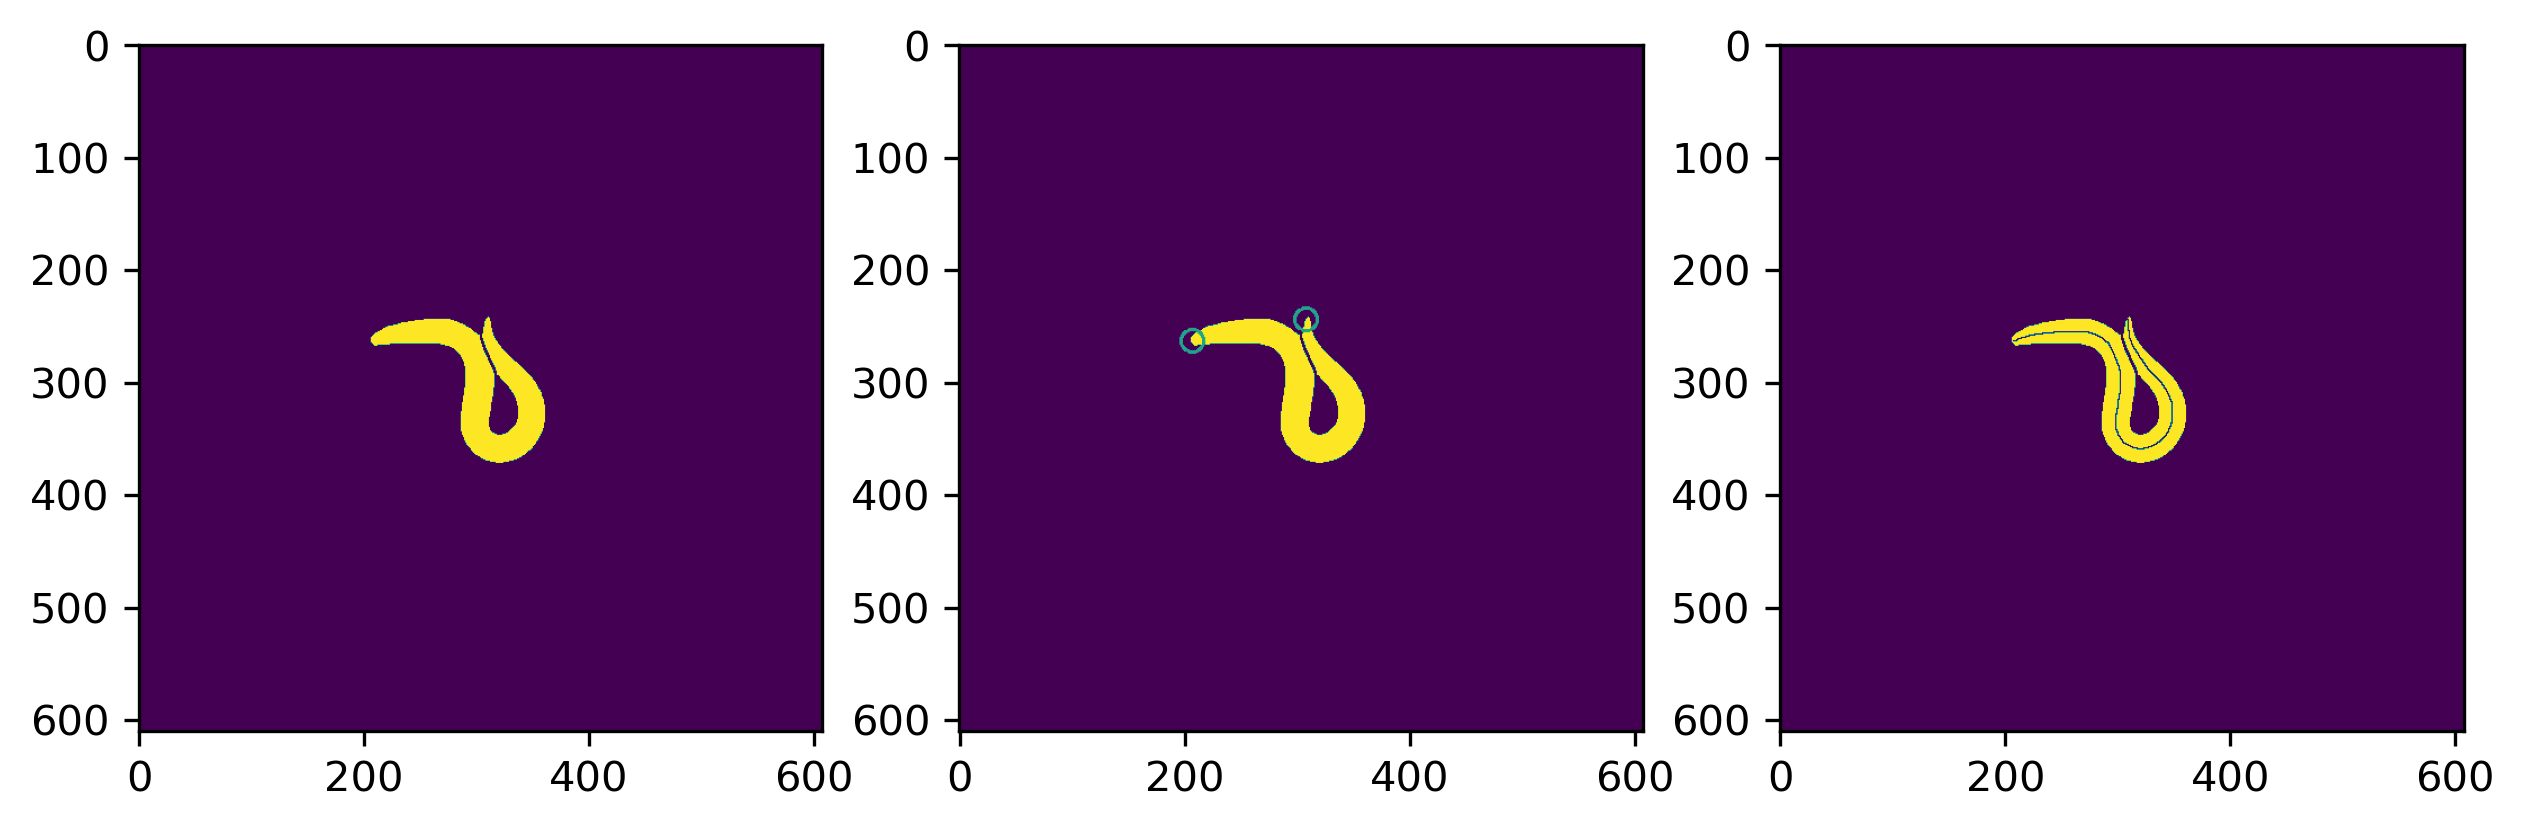

img63243.tif
head and tail were too close, no centerline could be created
img108725.tif
head and tail were too close, no centerline could be created
img108845.tif
head and tail were too close, no centerline could be created
img108905.tif


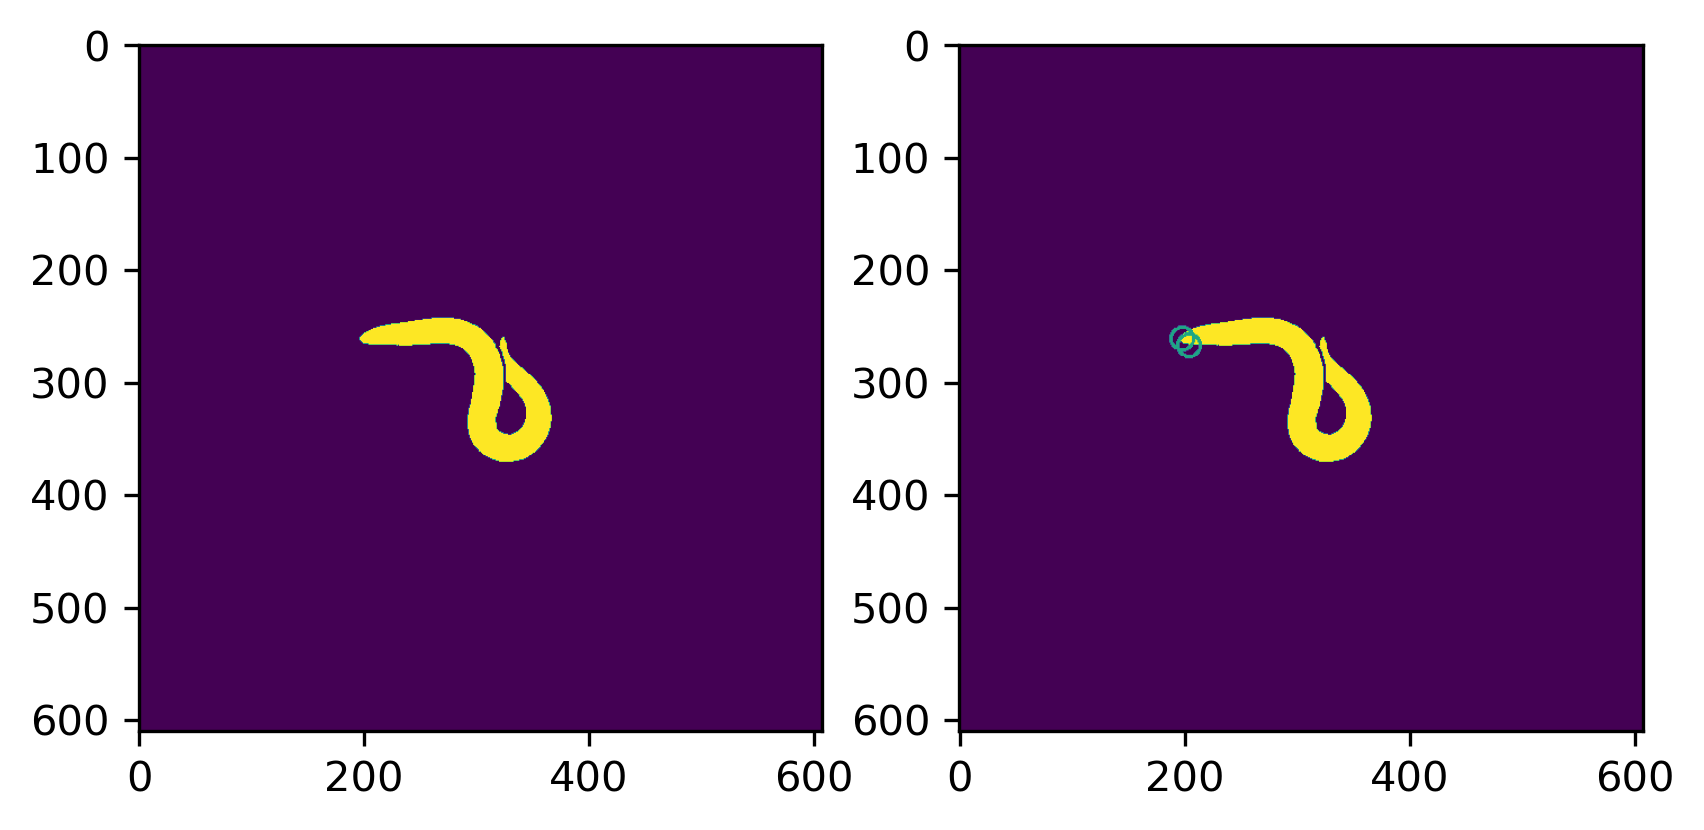

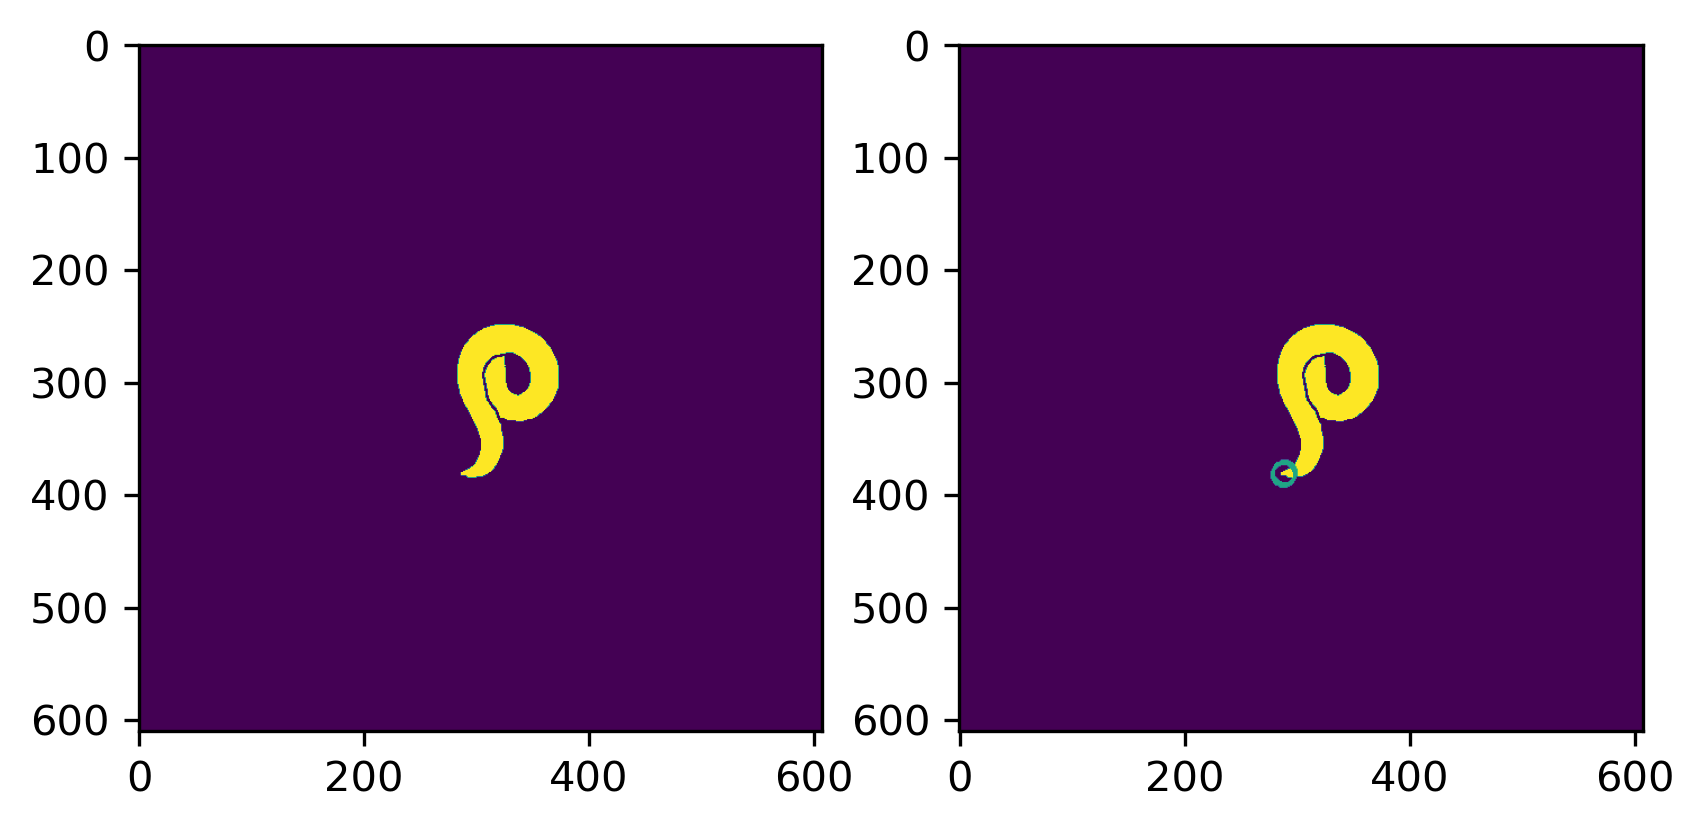

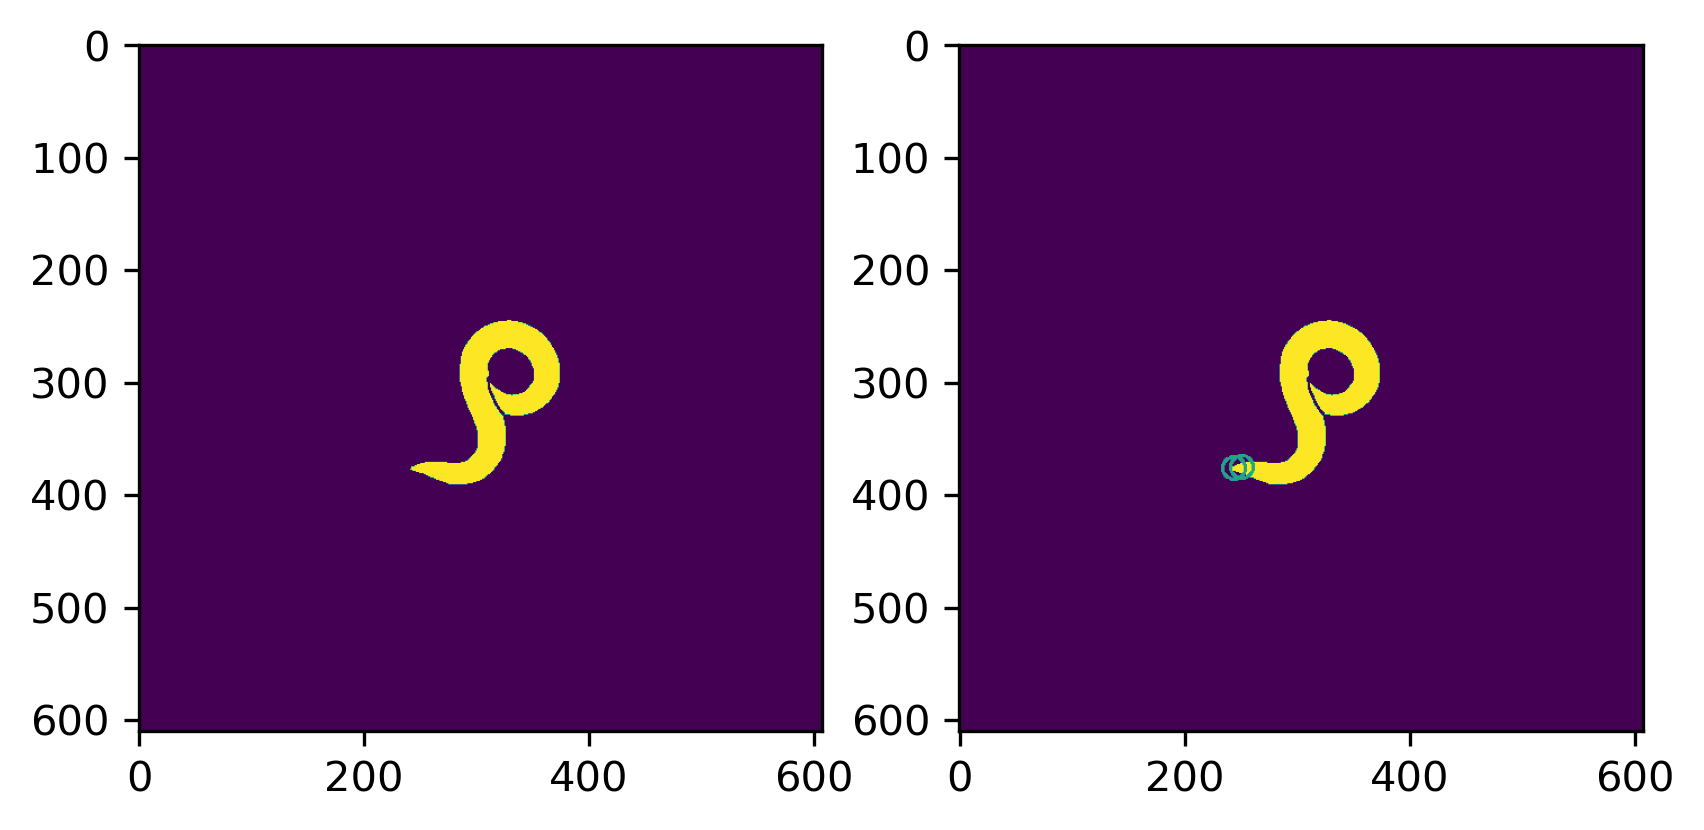

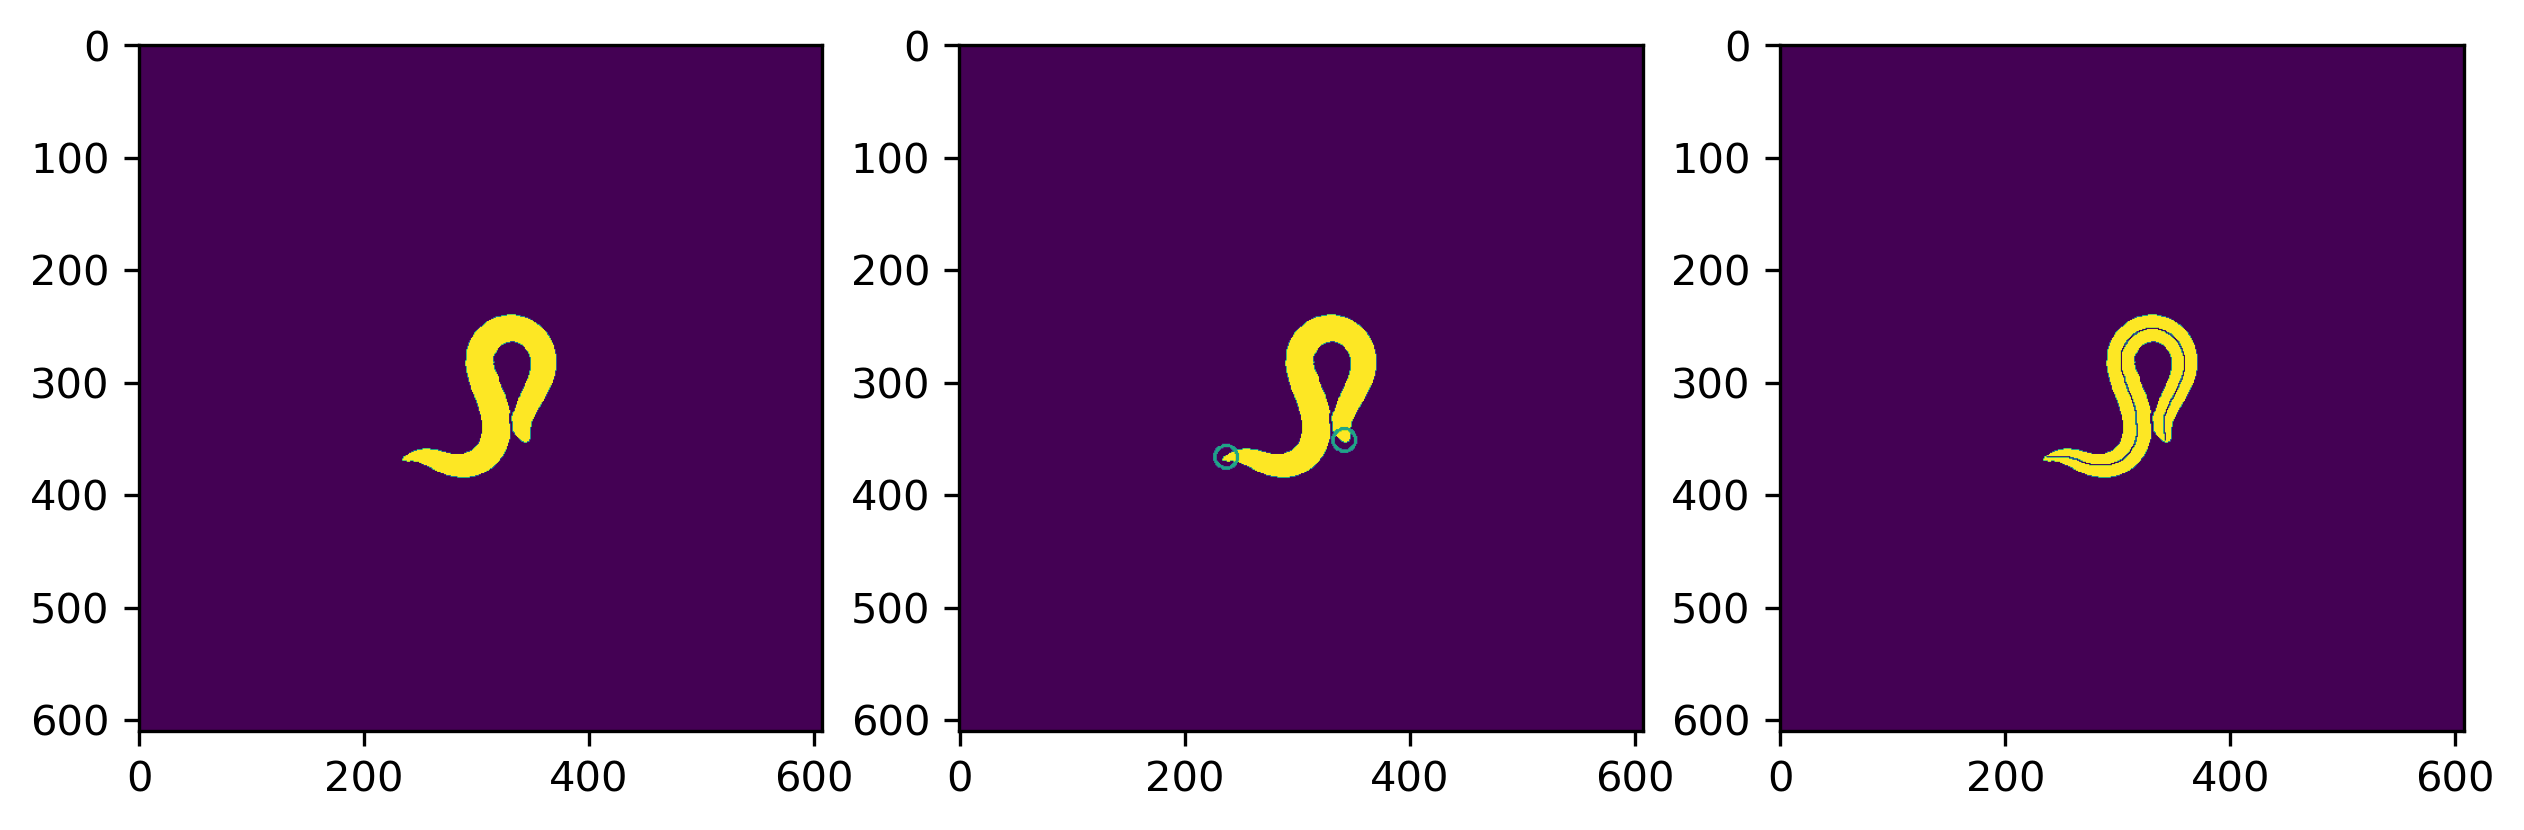

img109085.tif


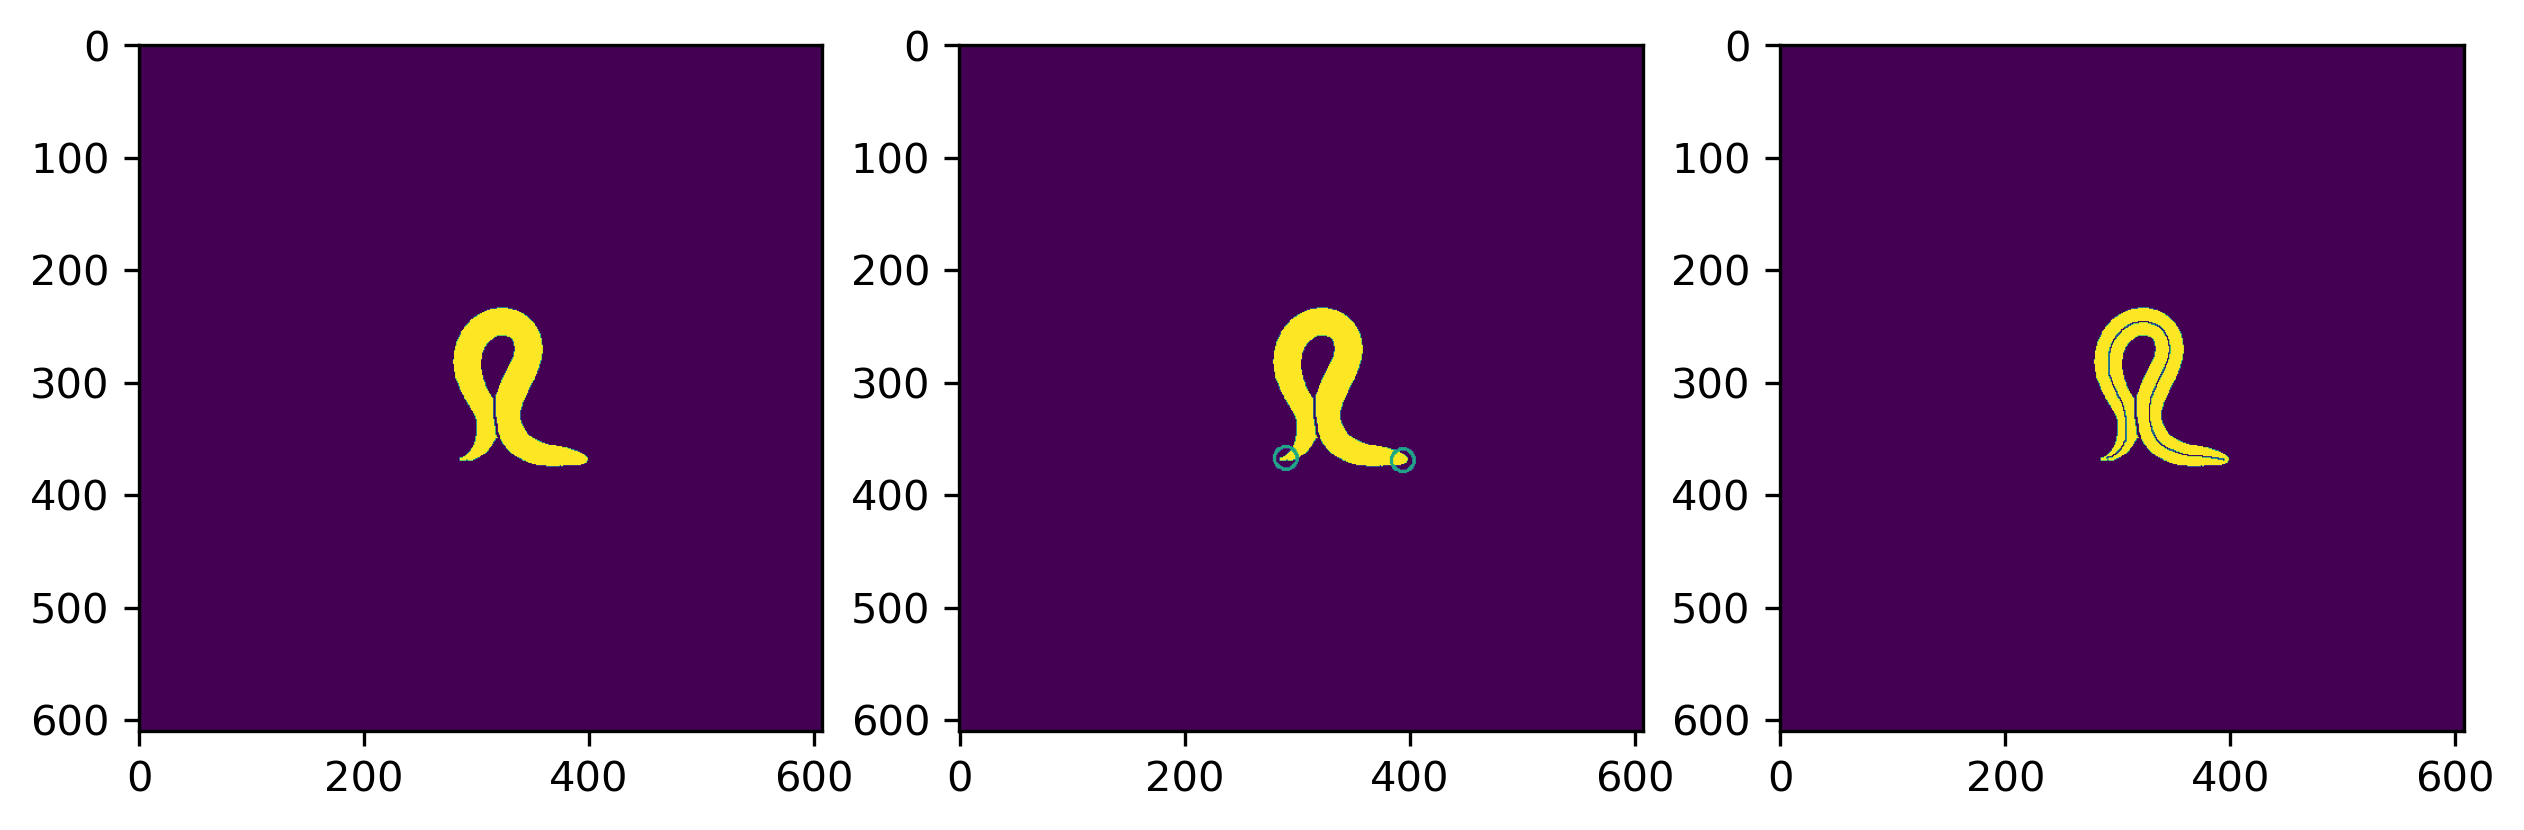

img109145.tif


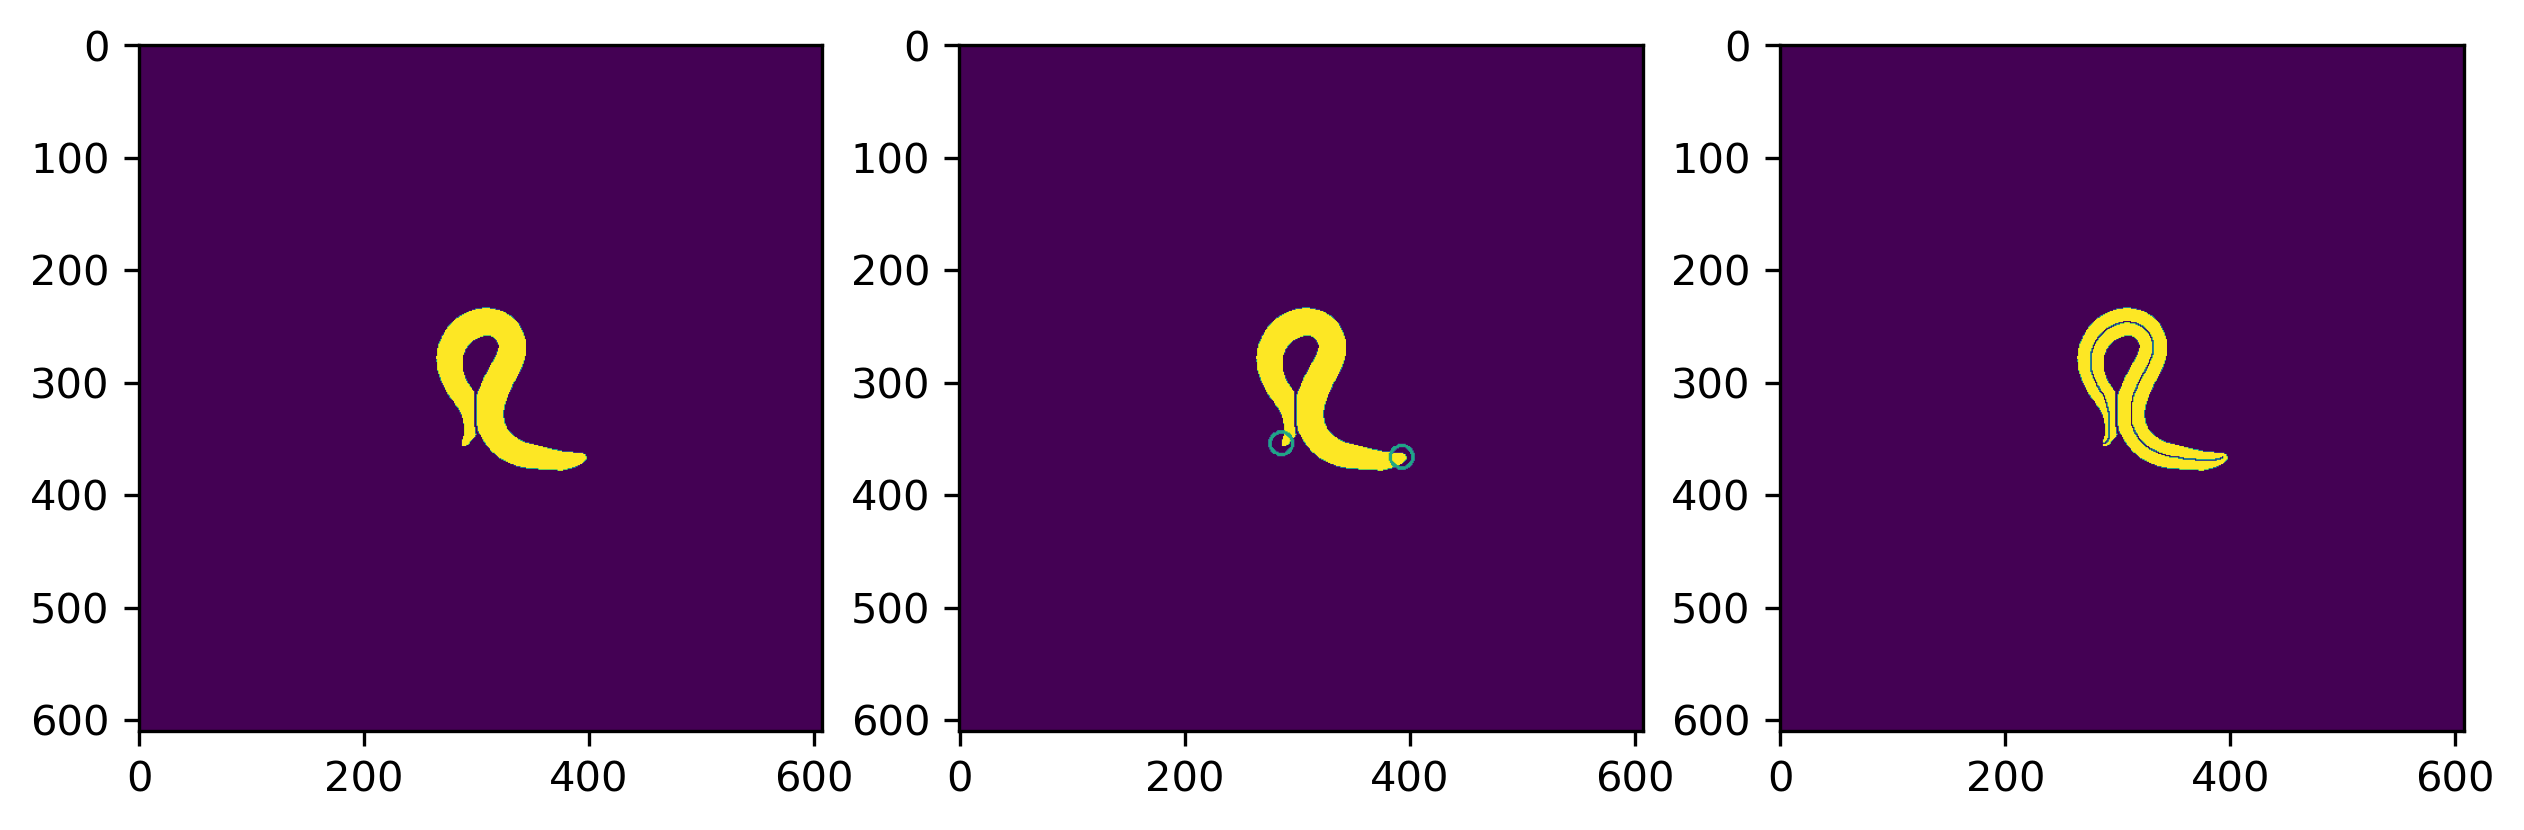

img109205.tif


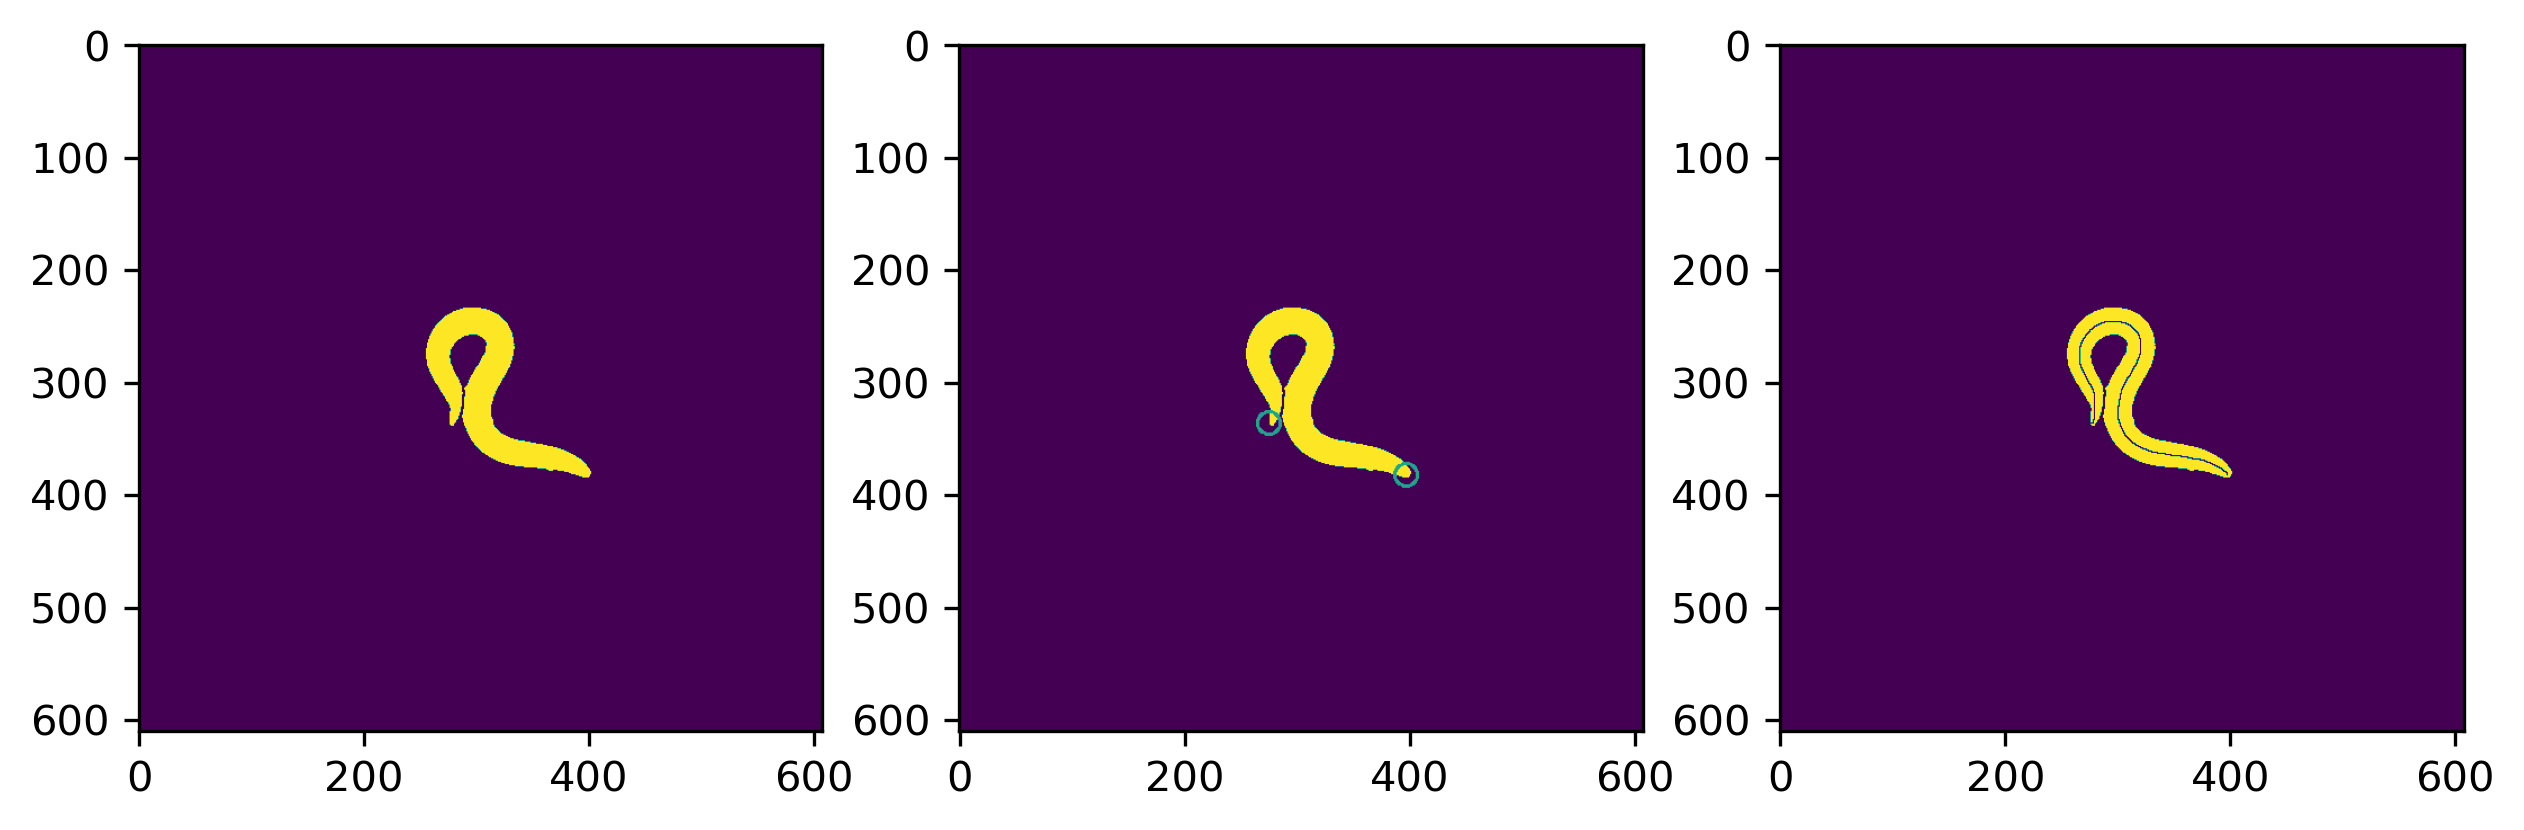

img117011.tif


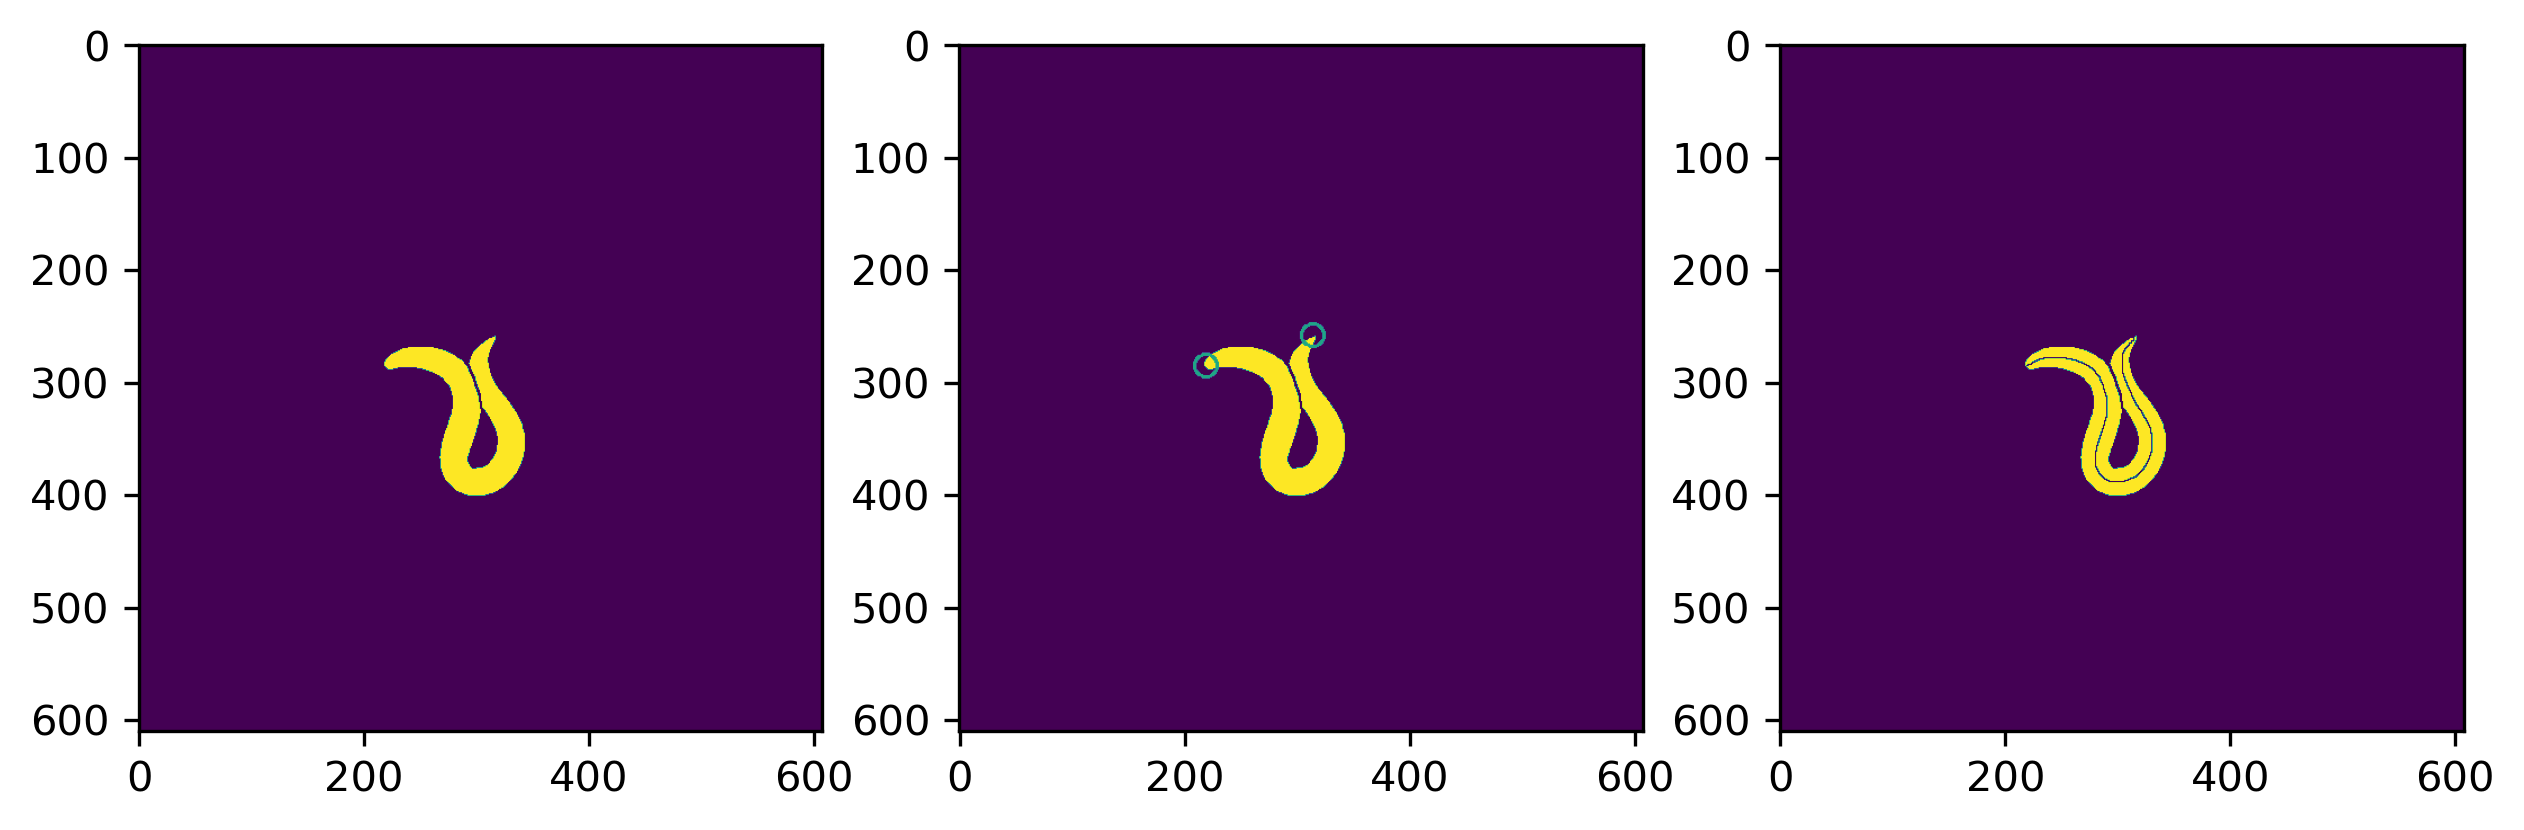

img117071.tif


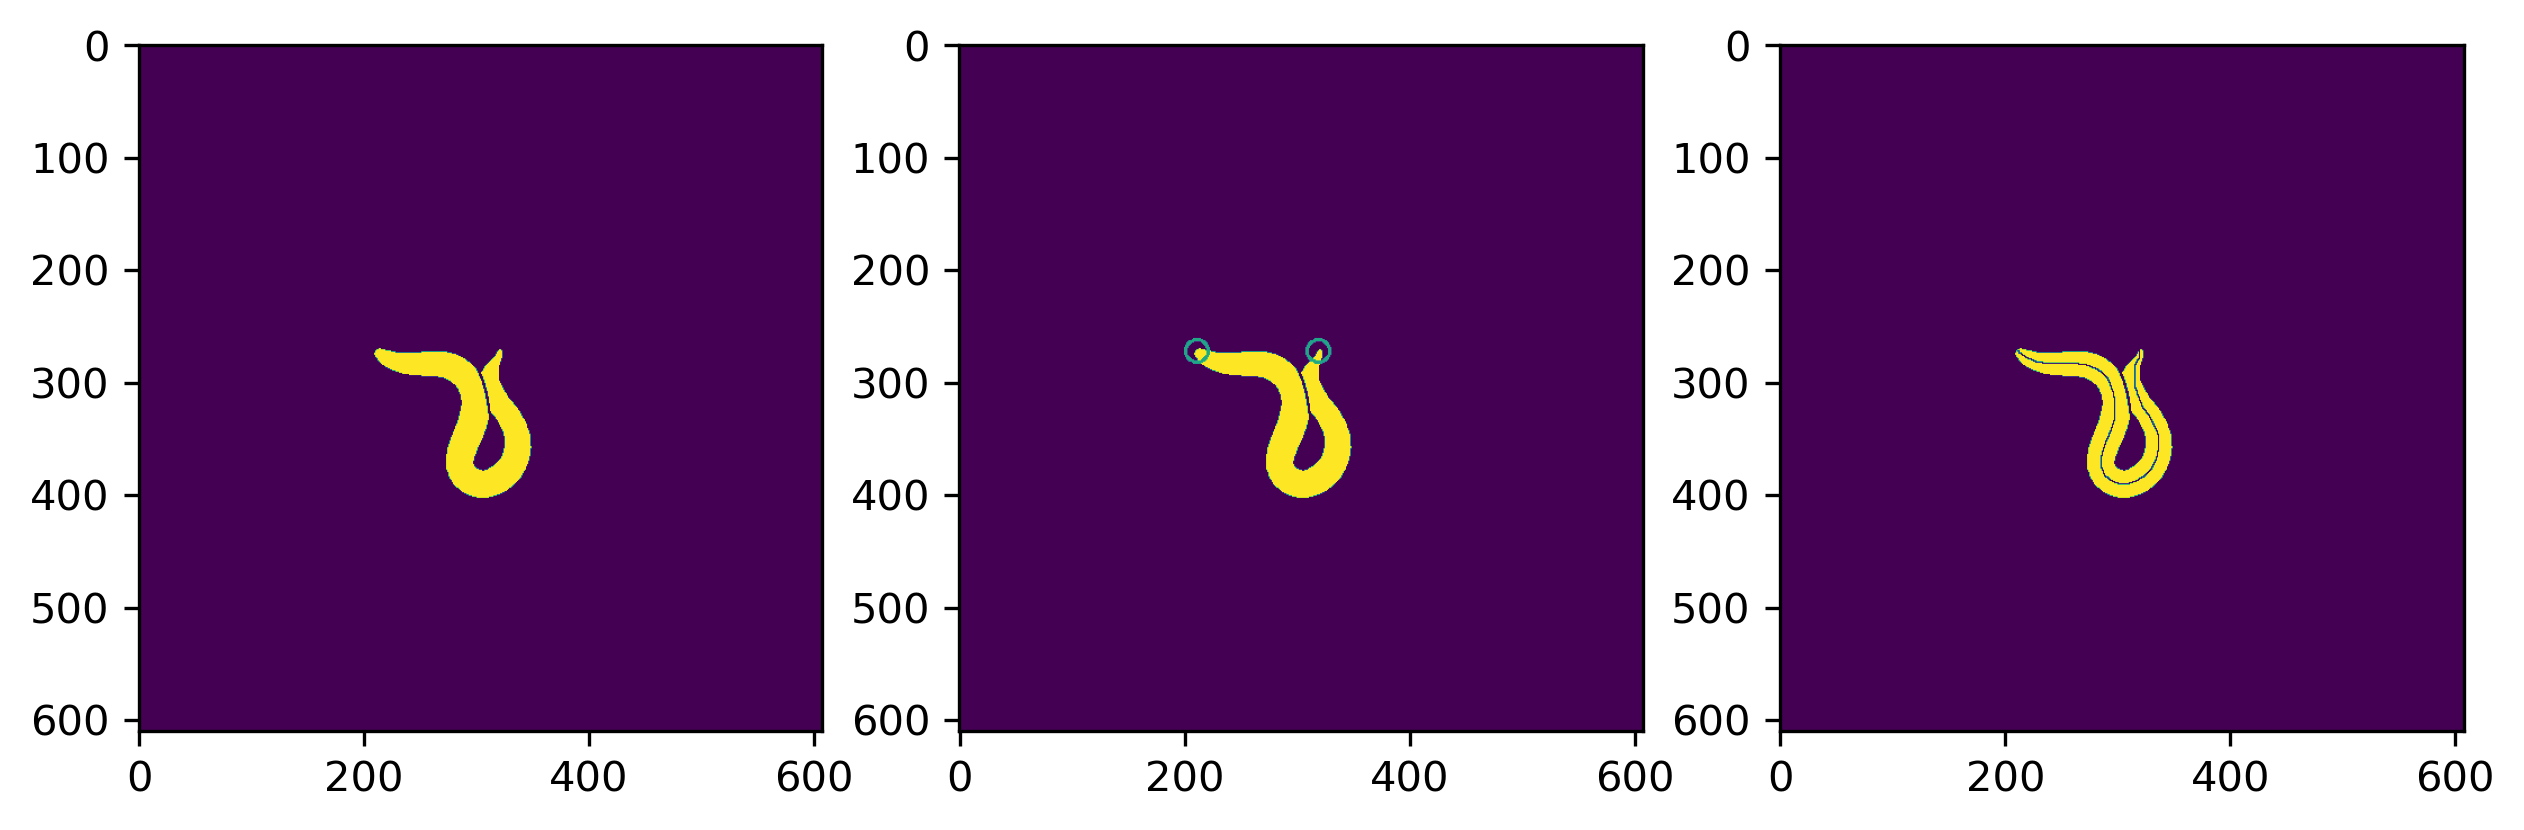

img117131.tif


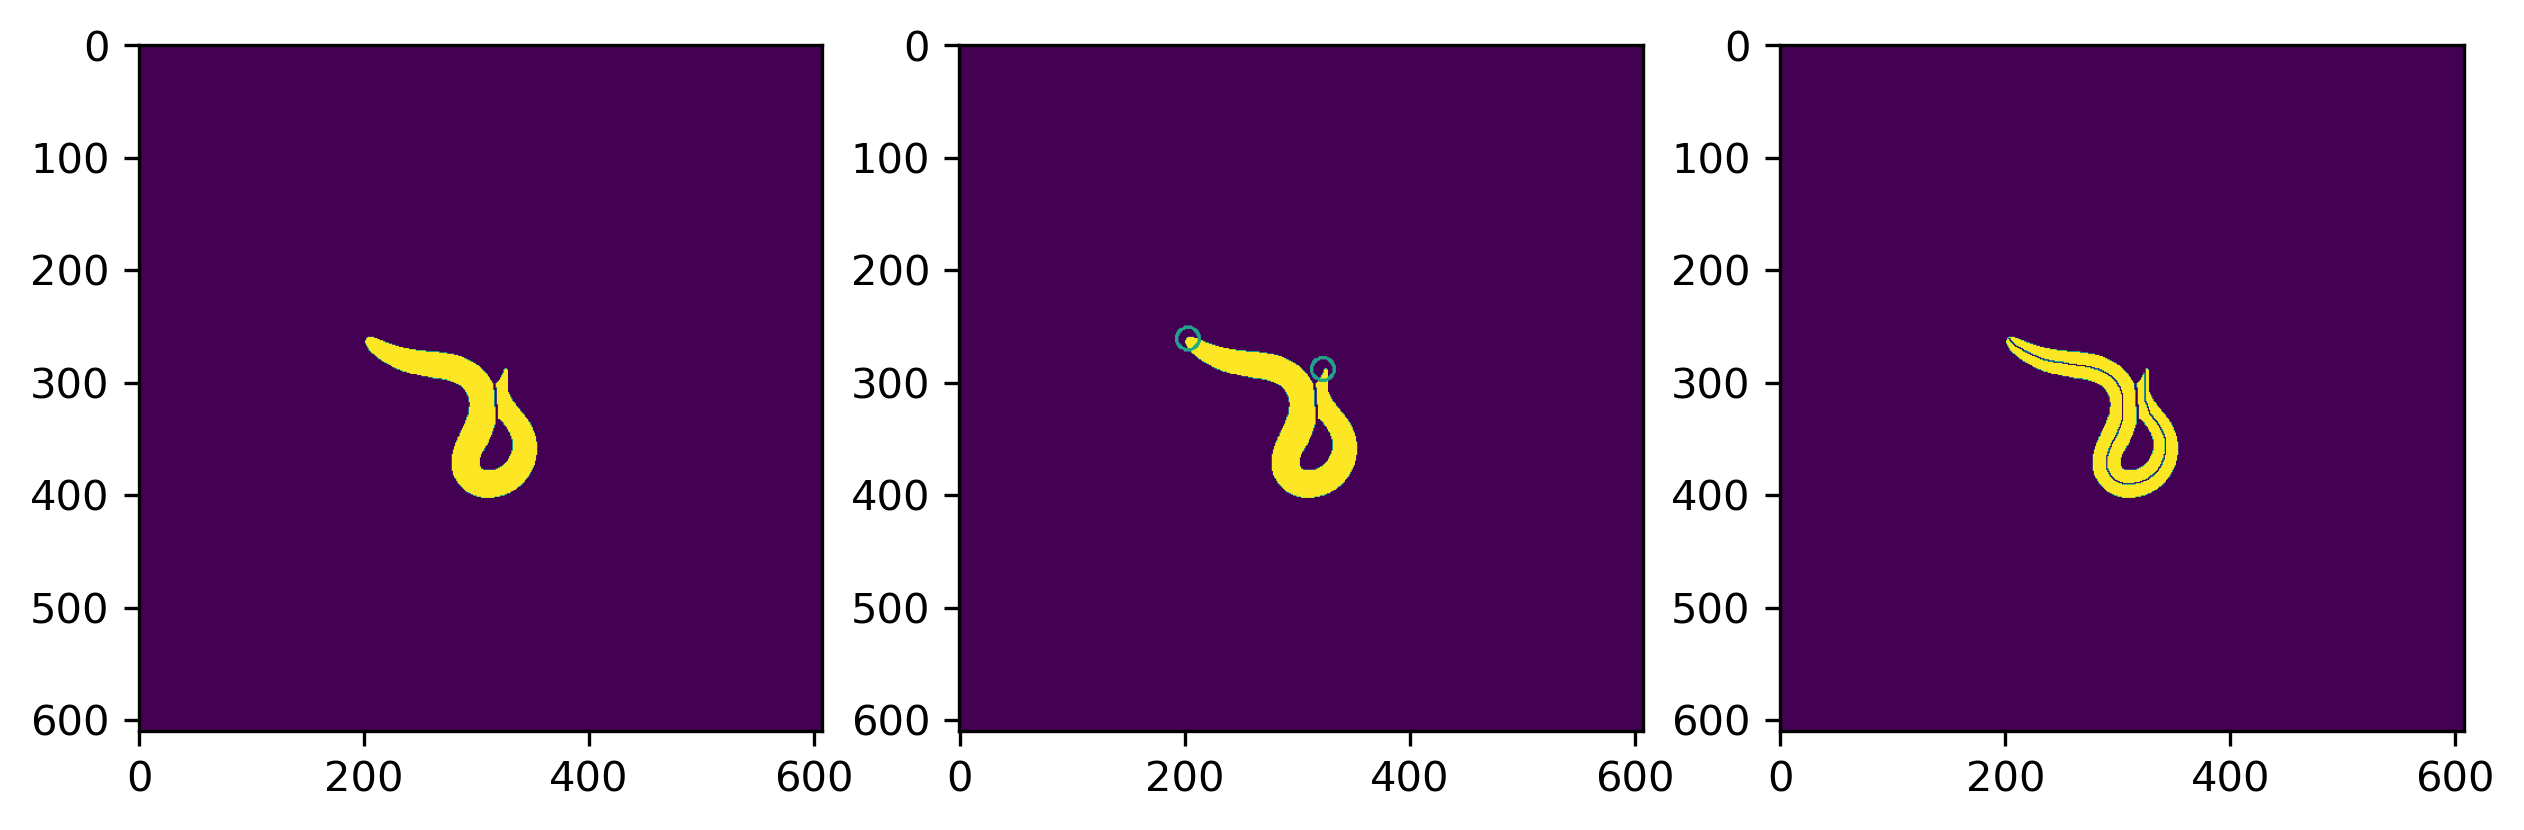

In [4]:
pts

NameError: name 'pts' is not defined

In [39]:
coords=np.asarray(list(zip(*skel_coords)), dtype=int)
for idx,coords in enumerate(coords):
    print(idx)
    print(coords)

0
[280 349]
1
[281 349]
2
[282 349]
3
[283 349]
4
[284 349]
5
[285 349]
6
[286 349]
7
[287 349]
8
[288 349]
9
[289 349]
10
[290 349]
11
[291 349]
12
[292 349]
13
[293 349]
14
[294 349]
15
[295 349]
16
[296 349]
17
[297 349]
18
[298 349]
19
[299 349]
20
[300 349]
21
[301 349]
22
[302 349]
23
[303 349]
24
[304 349]
25
[305 349]
26
[306 349]
27
[307 349]
28
[308 349]
29
[309 349]
30
[310 349]
31
[311 349]
32
[312 349]
33
[313 349]
34
[314 349]
35
[315 349]
36
[316 349]
37
[316 348]
38
[317 348]
39
[318 348]
40
[319 348]
41
[320 348]
42
[321 348]
43
[322 348]
44
[323 348]
45
[324 348]
46
[325 348]
47
[326 348]
48
[327 348]
49
[328 348]
50
[329 348]
51
[330 348]
52
[331 348]
53
[332 348]
54
[333 348]
55
[334 348]
56
[335 348]
57
[336 348]
58
[337 348]
59
[337 347]
60
[337 346]
61
[337 345]
62
[338 345]
63
[338 344]
64
[338 343]
65
[338 342]
66
[339 342]
67
[339 341]
68
[339 340]
69
[340 340]
70
[340 339]
71
[340 338]
72
[341 338]
73
[341 337]
74
[341 336]
75
[342 336]
76
[342 335]
77
[342 3

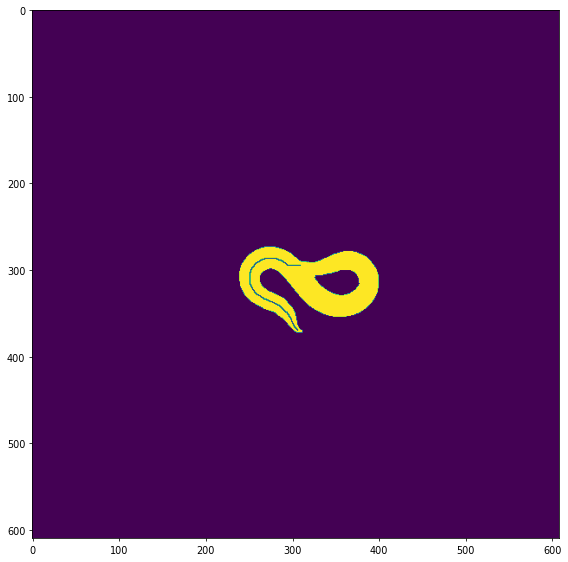

In [11]:
#coords=np.asarray(list(zip(*path)), dtype=int)
plt.figure(figsize=(10,10), dpi=70)
output_img=img.copy()
for x,y in path:
    #print(x,y)
    output_img[x][y]=50
plt.imshow(output_img)

In [7]:
u, skel_coord, spline_coord, K =make_skeleton_v2(start_point=start_point, end_point=end_point, num_splines=num_splines, img=img)
#output=make_skeleton_v2(start_point=start_point, end_point=end_point, num_splines=num_splines, img=img)

NameError: name 'make_skeleton_v2' is not defined

In [5]:
plt.plot(skel_coord[0],skel_coord[1])
plt.show()
plt.plot(spline_coord[1],spline_coord[0])
plt.show()
plt.plot(K)

NameError: name 'skel_coord' is not defined

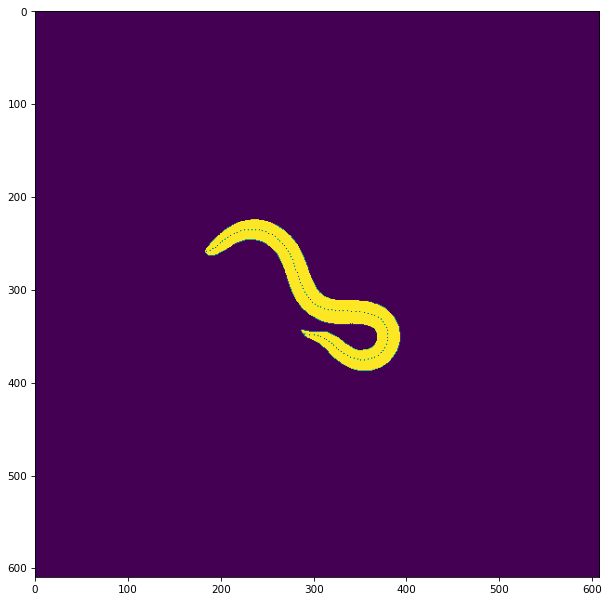

In [149]:
coords=np.asarray(list(zip(*spline_coord)), dtype=int)
plt.figure(figsize=(10,10), dpi=75)
for x,y in coords:
    #print(x,y)
    img[x][y]=0
plt.imshow(img)

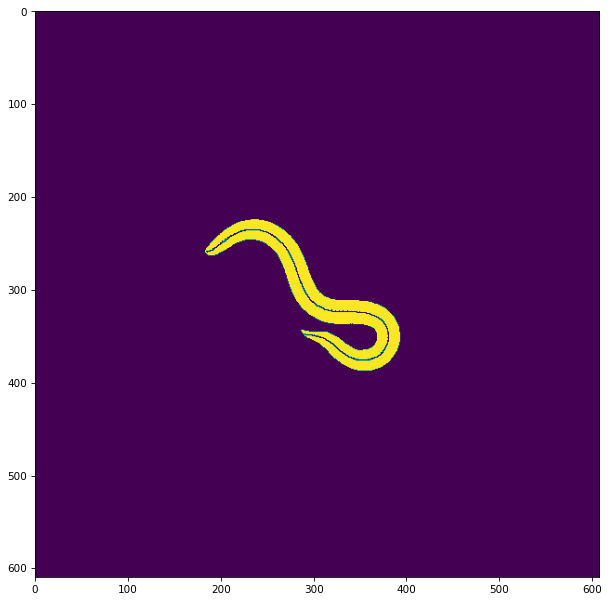

In [151]:
coords=np.asarray(list(zip(*skel_coord)), dtype=int)
plt.figure(figsize=(10,10), dpi=75)
for x,y in coords:
    #print(x,y)
    img[x][y]=0
plt.imshow(img)

In [2]:
from centerline import functions as imutils

ImportError: cannot import name 'functions' from 'centerline' (/users/ulises.rey/anaconda3/envs/openCV/lib/python3.7/site-packages/centerline/__init__.py)

In [3]:
from centerline import *

In [4]:
from centerline import imutils

ImportError: cannot import name 'imutils' from 'centerline' (/users/ulises.rey/anaconda3/envs/openCV/lib/python3.7/site-packages/centerline/__init__.py)

In [1]:
from centerline.imutils import *

ModuleNotFoundError: No module named 'centerline.imutils'

In [6]:
from centerline.src import make_skeleton_cluster

ModuleNotFoundError: No module named 'centerline.src'

## Skeleton Test Part

In [3]:
#import functions
def shortest_path2(start,end,binary,costs):
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=False)
    return path,cost

In [4]:
import pandas as pd

h5_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_hdf5/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_590000.h5'

df=pd.read_hdf(h5_path)

In [ ]:
df.head(2)

In [23]:
timepoint=28826#211
df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['x']

432.53619384765625

In [5]:
start_point =  (int(299.587006), int(282.180603))
end_point = (int(294.432922), int(373.210541))

In [6]:
start_point =  (int(282.180603), int(299.587006))
end_point = (int(373.210541), int(294.432922))

In [24]:
head_x=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['x']
head_y=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Head']['y']
tail_x=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Tail']['x']
tail_y=df.loc[timepoint,:]['DLC_resnet50_HeadTailAug10shuffle1_590000']['Tail']['y']
start_point =  (int(head_y), int(head_x))
end_point = (int(tail_y), int(tail_x))

In [25]:
print(start_point)
print(end_point)

(192, 432)
(417, 180)


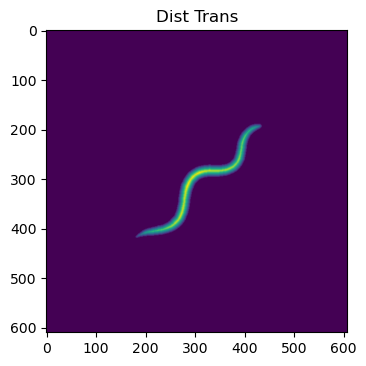

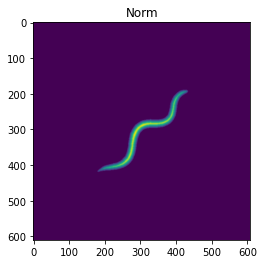

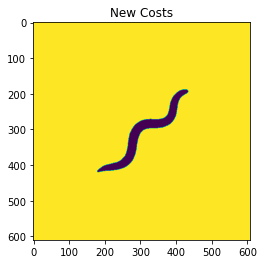

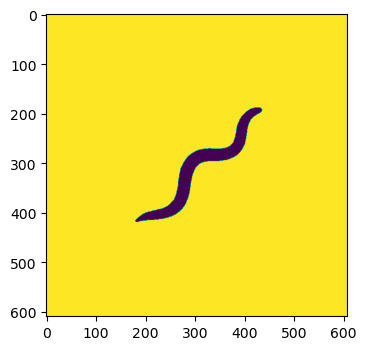

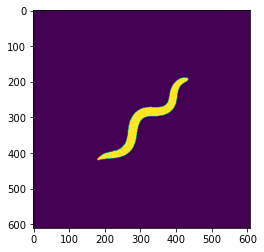

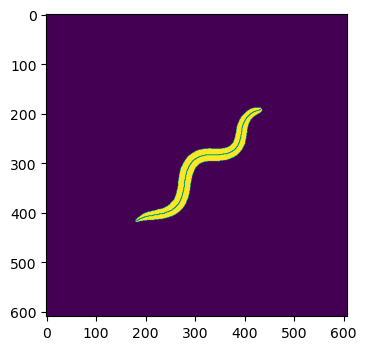

In [27]:
#skeleton part
plt.figure(dpi=100)
#img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0.tif')
#img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_manually_segmented.tif')
img=tiff.imread('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series1.tif')


#this defines the costs for the shortest path
costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
plt.imshow(costs)
plt.title('Dist Trans')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans.tif',data=costs)

cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
plt.imshow(costs)
plt.title('Norm')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans_Norm.tif',data=costs)

#does an inversion, background now is 255, worm is below 255
costs=costs.max()-costs
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_DistTrans_Norm_AS.tif',data=costs)

#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
costs=np.where(costs==255, 255**2, costs)
#costs=costs**2
plt.imshow(costs)
plt.title('New Costs')
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_New_costs.tif',data=costs)


#costs=np.where(costs==0,np.inf,costs)

plt.figure(dpi=100)
plt.imshow(costs)
plt.show()

path, cost=shortest_path2(start_point, end_point, img, costs)

x,y=np.asarray(list(zip(*path)), dtype=int)
plt.imshow(img)
plt.show()

for x,y in path:
    img[x][y]=20
plt.figure(dpi=100)
plt.imshow(img)
plt.show()
tiff.imwrite('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/200001 - Series0_Result.tif',data=img)


TypeError: Invalid shape (10, 1, 2) for image data

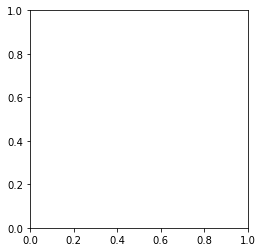

In [77]:
#read and write tiff video for binary

#import pckgs
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv

import os
from natsort import natsorted
import re
import argparse

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

#import functions
def shortest_path2(start,end,binary,costs):
    path, cost = skimage.graph.route_through_array(costs, start=start, end=end, fully_connected=False)
    return path,cost


ap = argparse.ArgumentParser()
ap.add_argument("-i", "--input_filename", required=True, help="path to input file")
ap.add_argument("-h5", "--h5", required=True, help="path to the DLC hdf5 file")

args = vars(ap.parse_args())

input_filename=args['input_filename']
print(input_filename)
print('\n')
h5_path=args['h5']
print(h5_path)
print('\n')

df = pd.read_hdf(h5_path)

scorer=df.columns.get_level_values(0)[0]
head_x=df[scorer]['Head']['x'].values
head_y=df[scorer]['Head']['y'].values
tail_x=df[scorer]['Tail']['x'].values
tail_y=df[scorer]['Tail']['y'].values


# #create csv objects
output_path=os.path.join('/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/new_skeleton/',re.split('-channel',re.split('/',input_filename)[-1])[0])
print('\noutput:')
print(output_path)
print('\noutput2:')
print(output_path+'_spline_Y_coords.csv')
csvfilePathX=open(output_path+'_skeleton_X_coords.csv','w', newline='')
csv_writerPathX=csv.writer(csvfilePathX)

csvfilePathY=open(output_path+'_skeleton_Y_coords.csv','w', newline='')
csv_writerPathY=csv.writer(csvfilePathY)

csvfileX=open(output_path+'_spline_X_coords.csv','w', newline='')
csv_writerX=csv.writer(csvfileX)

csvfileY=open(output_path+'_spline_Y_coords.csv','w', newline='')
csv_writerY=csv.writer(csvfileY)

csvfileK=open(output_path+'_spline_K.csv','w', newline='')
csv_writerK=csv.writer(csvfileK)

knots=100

with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        img=page.asarray()
        #Skeleton approach
        #skeleton = skeletonize(img/255)
        #skeleton=np.asarray(skeleton, dtype="uint8")

        #Scikit graph approach - Shortest Path
        start_point =  (int(head_y[i]), int(head_x[i]))#(286, 124)#
        end_point = (int(tail_y[i]), int(tail_x[i]))#(332,480)#

        #Shortest Path default:
        #path, cost, costs=shortest_path(start_point, end_point, skeleton)

        #Shortest Path 2:
        #I modified the original shortest_path function, now costs are defined outside
        #it works on the img instead of the skeleton, which is then in fact not used

        #this defines the costs for the shortest path
        costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
        cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
        costs=costs.max()-costs  
        
#to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
        costs=np.where(costs==255, 255**2, costs)

        path, cost=shortest_path2(start_point, end_point, img, costs)

        x,y=np.asarray(list(zip(*path)), dtype=int)

#         for x,y in path:
#             img[x][y]=0

        pts=np.asarray(path, dtype=np.int)
        #fill K with NaNs if the skeleton is not good
        if len(pts)<knots:
            #print('Knots are Nans in: '+str(i))
            K=np.full(knots, np.nan)
            x=np.full(knots, np.nan)
            y=np.full(knots, np.nan)
            x_new=np.full(knots, np.nan)
            y_new=np.full(knots, np.nan)
        else:
            ####
            #s is the smoothing condition should have around the size of points/2 (keep it low)
            #k is the degree of freedom for the polynom it fits, 5 is good
            #splprep calculates automatically the number of knots. One can see how many in tck.shape[1].
            #everytime splprep is run the number by differ
            tck, u = splprep(pts.T, u=None, s=pts.shape[0]/2, per=0, k=5) 
            u_new = np.linspace(u.min(), u.max(), knots)#1000)

            x_new, y_new = splev(u_new, tck, der=0)

            #this returns x'(s), y'(s)
            x_der, y_der = splev(u_new, tck, der=1)
            #to have y'(x):
            der=y_der/x_der

            #this returns x''(s), y''(s)
            x_der2, y_der2 = splev(u_new, tck, der=2)
            #to have y''(x), also called K for Curvature:
            #we need the following equation:
            #ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
            K=(x_der*y_der2-y_der*x_der2)/np.sqrt(x_der**2+y_der**2)**3

        #csv writer
        csv_writerPathX.writerow(x)
        csv_writerPathY.writerow(y)
        csv_writerX.writerow(x_new)
        csv_writerY.writerow(y_new)
        csv_writerK.writerow(K)

        #if i==00:
        #    break
csvfilePathX.close()
csvfilePathY.close()
csvfileX.close()
csvfileY.close()
csvfileK.close()
print('end')

In [66]:
len(contours[1])

26

In [65]:
contours[2]

array([[[269, 273]],

       [[268, 274]],

       [[262, 274]],

       [[261, 275]],

       [[258, 275]],

       [[257, 276]],

       [[255, 276]],

       [[254, 277]],

       [[252, 277]],

       [[251, 278]],

       [[250, 278]],

       [[248, 280]],

       [[247, 280]],

       [[237, 290]],

       [[237, 291]],

       [[236, 292]],

       [[236, 293]],

       [[235, 294]],

       [[235, 295]],

       [[234, 296]],

       [[234, 298]],

       [[233, 299]],

       [[233, 301]],

       [[232, 302]],

       [[232, 320]],

       [[233, 321]],

       [[233, 322]],

       [[234, 323]],

       [[234, 324]],

       [[235, 325]],

       [[235, 326]],

       [[236, 327]],

       [[236, 328]],

       [[237, 329]],

       [[237, 330]],

       [[239, 332]],

       [[239, 333]],

       [[243, 337]],

       [[244, 337]],

       [[247, 340]],

       [[248, 340]],

       [[249, 341]],

       [[250, 341]],

       [[251, 342]],

       [[252, 342]],

       [[2

In [67]:
contours[3]

array([[[263, 299]],

       [[264, 298]],

       [[274, 298]],

       [[275, 299]],

       [[277, 299]],

       [[278, 300]],

       [[279, 300]],

       [[280, 301]],

       [[281, 301]],

       [[283, 303]],

       [[284, 303]],

       [[293, 312]],

       [[293, 313]],

       [[295, 315]],

       [[295, 316]],

       [[297, 318]],

       [[297, 319]],

       [[300, 322]],

       [[300, 323]],

       [[301, 324]],

       [[300, 325]],

       [[300, 326]],

       [[299, 327]],

       [[295, 327]],

       [[294, 326]],

       [[287, 326]],

       [[286, 327]],

       [[269, 327]],

       [[268, 326]],

       [[266, 326]],

       [[264, 324]],

       [[263, 324]],

       [[256, 317]],

       [[256, 316]],

       [[255, 315]],

       [[255, 308]],

       [[256, 307]],

       [[256, 305]],

       [[257, 304]],

       [[257, 303]],

       [[260, 300]],

       [[261, 300]],

       [[262, 299]]], dtype=int32)

In [18]:
worm_contour

array([[2]])

In [50]:
test=np.empty(shape=img.shape)
test=cv2.drawContours(img_contours,contours, 2, 255, -1, hierarchy=0)
plt.imshow(test)

error: OpenCV(3.4.2) /tmp/build/80754af9/opencv-suite_1535558553474/work/modules/imgproc/src/drawing.cpp:2529: error: (-215:Assertion failed) hierarchy.total() == ncontours && hierarchy.type() == (((4) & ((1 << 3) - 1)) + (((4)-1) << 3)) in function 'drawContours'


### First generate binary image

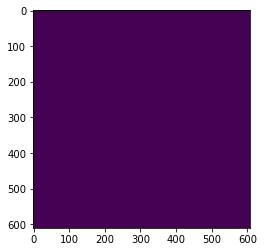

In [6]:
plt.imshow(img)

### Then generate skeleton

I have cleaned this notebook. The code is in the python files. Please use the code in the .py files

## Plottting Derivative

In [ ]:
for frame, k_v in enumerate(all_K):
    x_new=all_x_new[frame]
    y_new=all_y_new[frame]
    der=all_der[frame]
    K=all_K[frame]

    x_cord=np.arange(0,100,1)

    plt.figure(figsize=(20,10))
    r,c=2,2
    # ax1=plt.subplot(r,c,1)
    # plt.plot(x_cord, y_new, 'bo')
    # plt.title('Worm')

    #first der
    ax3=plt.subplot(r,c,1)
    #plt.plot(x_cord,der)
    plt.scatter(x_cord, der, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    ax3.set_ylim(-5, 5)

    plt.axhline(y=0, xmin=0, xmax=1)
    #ax3.set_ylim(-2, 2)
    #ax3.set_xlim(400, 450)
    plt.title('First Derivative')

    ax5=plt.subplot(r,c,2)
    #plt.plot(x_new, der2, 'o')
    plt.scatter(x_cord, K, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#, vmin=-5000, vmax=5000)#y_der2, marker='.', cmap='bwr')
    ax5.set_ylim(-0.1, 0.1)

    plt.axhline(y=0, xmin=0, xmax=1)
    plt.title('Second Derivative')

    #worm first der
    ax2=plt.subplot(r,c,3)
    sc=plt.scatter(x_new, y_new, c=der, marker='.', cmap='bwr', vmin=-2, vmax=2)
    #plt.colorbar(sc)
    plt.title('Color coded worm from First Derivative')



    ax4=plt.subplot(r,c,4)
    sc=plt.scatter(x_new, y_new, c=K, marker='.', cmap='bwr', vmin=-0.02, vmax=0.02)#y_der2, marker='.', cmap='bwr')
    #plt.colorbar(sc)
    plt.title('Color coded worm from Second Derivative')
    plt.savefig('derivatives/'+str(frame)+'.tiff')
    plt.close()

# Plot Kymograph

In [1]:
df=pd.read_csv('/groups/zimmer/Ulises/code/skeleton_outputs/second_der_np_new.csv', header=None)
print(df.shape)
df.head(5)
tdf=df[:1500].transpose()
print(tdf.shape)

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111)
ax.imshow(tdf, vmin=-0.05, vmax=0.05, cmap='bwr')
ax.can_pan=True

#ax.applyaspect()

NameError: name 'pd' is not defined

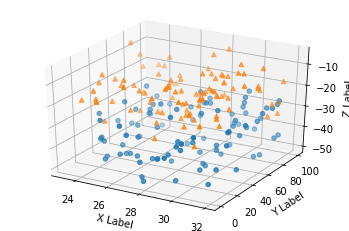

In [17]:
#3D plotting
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    '''
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    '''
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [ ]:

# Import pandas as pd
import pandas as pd

# Read in the CSV file: df
df=principalDf

# Import figure from bokeh.plotting
from bokeh.plotting import figure
from bokeh.io import push_notebook, show, output_notebook 

# Create the figure: p
p = figure(x_axis_label='PC2', y_axis_label='PC3')

# Plot mpg vs hp by color
p.circle(df['PC2'], df['PC3'], size=10)

# Specify the name of the output file and show the result
output_notebook()
show(p)

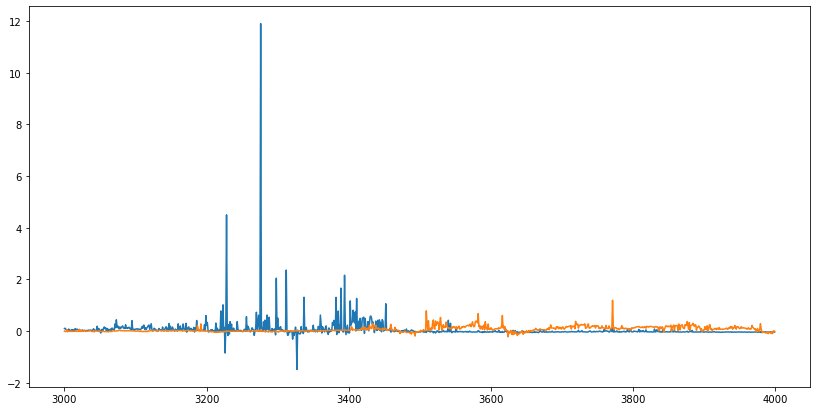

In [12]:
plt.figure(figsize=(14,7))
plt.plot(principalDf['PC1'][3000:4000])
plt.plot(principalDf['PC2'][3000:4000])

In [20]:
pca.explained_variance_ratio_

array([0.36016637, 0.16643133, 0.13146125, 0.10535605, 0.07447364])

(-1.0, 1.0)

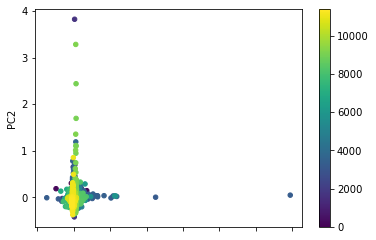

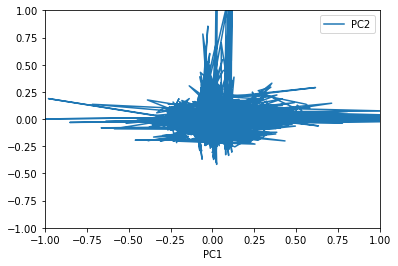

In [13]:
fig = principalDf.plot.scatter(x='PC1', y='PC2',c=principalDf.index, colormap='viridis')
fig= principalDf.plot(x='PC1', y='PC2')
fig.set_xlim([-1,1])
fig.set_ylim([-1,1])

In [14]:
plt.figure(figsize=(7,7))
for k,d in principalDf:
    plt.scatter(k,d)
#plt.scatter(principalDf['PC1'][0:10],principalDf['PC2'][0:10])
#plt.plot(principalDf['PC2'][3000:4000])

ValueError: too many values to unpack (expected 2)

<Figure size 504x504 with 0 Axes>

In [ ]:
k,d=principalDf

In [ ]:
d

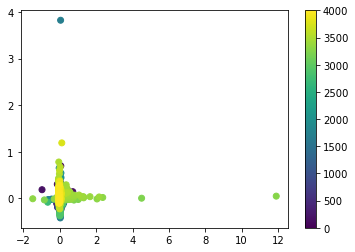

In [15]:
plt.scatter(principalDf['PC1'][0:4000],principalDf['PC2'][0:4000],c=np.arange(0,4000), vmin=0, vmax=4000)
plt.colorbar()
# ax_lim=0.2
# plt.xlim(-ax_lim,ax_lim)
# plt.ylim(-ax_lim,ax_lim)

(-0.2, 0.2)

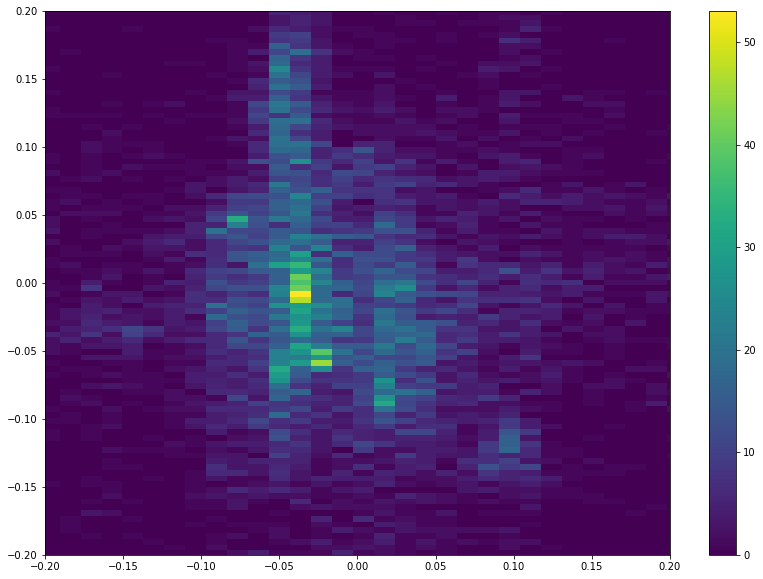

In [16]:
plt.figure(figsize=(14,10))
plt.hist2d(principalDf['PC1'],principalDf['PC2'], bins=1000)
plt.colorbar()
ax_lim=.2
plt.xlim(-ax_lim,ax_lim)
plt.ylim(-ax_lim,ax_lim)

(-0.5, 0.5)

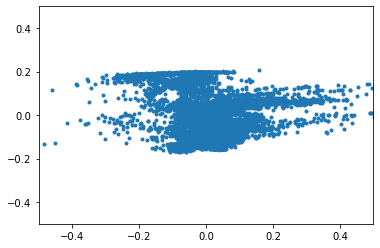

In [17]:
plt.scatter(principalDf['PC1'],principalDf['PC3'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

(-0.5, 0.5)

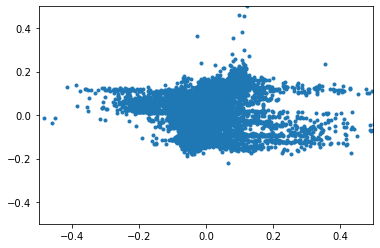

In [18]:
plt.scatter(principalDf['PC1'],principalDf['PC4'],marker='.')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)

In [99]:
import re
dir=re.split('-channel',re.split('/',input_filename)[-1])[0]

In [102]:
dir+'_skeleton_X_coords.csv'

'2020-06-05_16-46-41_worm1_skeleton_X_coords.csv'

In [12]:
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/'

In [15]:
output_path=os.path.join(input_filename, 'skeletons')


In [16]:
output_path

'/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/skeletons'